In [1]:
import sys

print(sys.executable)

d:\Thesis_Project\Experiment_2_Transformer-Based Emotion_Classification\.venv\Scripts\python.exe


In [2]:
# ============================================================
# EXPERIMENT 2 — PHASE 1 — CELL 1
# PYTHON ENVIRONMENT VERIFICATION
# ============================================================

import sys
import platform

print("=" * 70)
print("PYTHON ENVIRONMENT")
print("=" * 70)

print("Python executable :", sys.executable)
print("Python version    :", sys.version.split()[0])
print("Operating system  :", platform.platform())

print("=" * 70)

PYTHON ENVIRONMENT
Python executable : d:\Thesis_Project\Experiment_2_Transformer-Based Emotion_Classification\.venv\Scripts\python.exe
Python version    : 3.12.10
Operating system  : Windows-11-10.0.26200-SP0


In [3]:
# ============================================================
# EXPERIMENT 2 — PHASE 1 — CELL 2
# PACKAGE VERIFICATION
# ============================================================

import torch
import transformers
import accelerate
import datasets

import numpy as np
import pandas as pd
import sklearn
import scipy
import matplotlib
import shap
import sentencepiece

from iterstrat.ml_stratifiers import MultilabelStratifiedKFold

print("=" * 70)
print("PACKAGE VERIFICATION")
print("=" * 70)

print("PyTorch       :", torch.__version__)
print("Transformers  :", transformers.__version__)
print("Accelerate    :", accelerate.__version__)
print("Datasets      :", datasets.__version__)
print("NumPy         :", np.__version__)
print("Pandas        :", pd.__version__)
print("Scikit-learn  :", sklearn.__version__)
print("SciPy         :", scipy.__version__)
print("Matplotlib    :", matplotlib.__version__)
print("SHAP          :", shap.__version__)
print("SentencePiece :", sentencepiece.__version__)
print("Iterstrat     : OK")

print("=" * 70)
print("PACKAGE CHECK: PASSED")
print("=" * 70)

PACKAGE VERIFICATION
PyTorch       : 2.14.1+cu126
Transformers  : 5.18.0
Accelerate    : 1.15.0
Datasets      : 5.0.1
NumPy         : 2.5.2
Pandas        : 3.0.6
Scikit-learn  : 1.9.1
SciPy         : 1.18.1
Matplotlib    : 3.11.2
SHAP          : 0.52.0
SentencePiece : 0.2.2
Iterstrat     : OK
PACKAGE CHECK: PASSED


In [4]:
# ============================================================
# EXPERIMENT 2 — PHASE 1 — CELL 3
# GPU / CUDA VERIFICATION
# ============================================================

import torch

print("=" * 70)
print("GPU / CUDA CHECK")
print("=" * 70)

print("PyTorch version :", torch.__version__)
print("CUDA build      :", torch.version.cuda)
print("CUDA available  :", torch.cuda.is_available())

if torch.cuda.is_available():

    print("GPU count       :", torch.cuda.device_count())
    print("GPU name        :", torch.cuda.get_device_name(0))

    gpu_properties = torch.cuda.get_device_properties(0)

    total_vram = gpu_properties.total_memory / (1024 ** 3)

    print("Total VRAM      :", round(total_vram, 2), "GB")
    print(
        "Compute capability :",
        f"{gpu_properties.major}.{gpu_properties.minor}"
    )

    DEVICE = torch.device("cuda")

else:

    DEVICE = torch.device("cpu")

    print("WARNING: CUDA is not available.")
    print("Training will use CPU.")

print("Training device :", DEVICE)

print("=" * 70)

GPU / CUDA CHECK
PyTorch version : 2.14.1+cu126
CUDA build      : 12.6
CUDA available  : True
GPU count       : 1
GPU name        : NVIDIA GeForce RTX 3050 6GB Laptop GPU
Total VRAM      : 6.0 GB
Compute capability : 8.6
Training device : cuda


In [5]:
# ============================================================
# EXPERIMENT 2 — PHASE 1 — CELL 4
# PROJECT PATH SETUP
# ============================================================

from pathlib import Path

PROJECT_ROOT = Path.cwd()

DATA_DIR = PROJECT_ROOT / "DepressionEmo-main" / "Dataset"

TRAIN_PATH = DATA_DIR / "train.json"
VAL_PATH = DATA_DIR / "val.json"
TEST_PATH = DATA_DIR / "test.json"
LABEL_PATH = DATA_DIR / "label_names.json"

OUTPUT_DIR = PROJECT_ROOT / "outputs"

print("=" * 70)
print("PROJECT PATH SETUP")
print("=" * 70)

print("PROJECT_ROOT:")
print(PROJECT_ROOT)

print("\nDATA_DIR:")
print(DATA_DIR)

print("\nTRAIN_PATH:")
print(TRAIN_PATH)

print("\nVAL_PATH:")
print(VAL_PATH)

print("\nTEST_PATH:")
print(TEST_PATH)

print("\nLABEL_PATH:")
print(LABEL_PATH)

print("\nOUTPUT_DIR:")
print(OUTPUT_DIR)

print("=" * 70)

PROJECT PATH SETUP
PROJECT_ROOT:
d:\Thesis_Project\Experiment_2_Transformer-Based Emotion_Classification

DATA_DIR:
d:\Thesis_Project\Experiment_2_Transformer-Based Emotion_Classification\DepressionEmo-main\Dataset

TRAIN_PATH:
d:\Thesis_Project\Experiment_2_Transformer-Based Emotion_Classification\DepressionEmo-main\Dataset\train.json

VAL_PATH:
d:\Thesis_Project\Experiment_2_Transformer-Based Emotion_Classification\DepressionEmo-main\Dataset\val.json

TEST_PATH:
d:\Thesis_Project\Experiment_2_Transformer-Based Emotion_Classification\DepressionEmo-main\Dataset\test.json

LABEL_PATH:
d:\Thesis_Project\Experiment_2_Transformer-Based Emotion_Classification\DepressionEmo-main\Dataset\label_names.json

OUTPUT_DIR:
d:\Thesis_Project\Experiment_2_Transformer-Based Emotion_Classification\outputs


In [6]:
# ============================================================
# EXPERIMENT 2 — PHASE 1 — CELL 5
# OUTPUT DIRECTORY CREATION
# ============================================================

AUDIT_DIR = OUTPUT_DIR / "audit"
CLEAN_DIR = OUTPUT_DIR / "clean_dataset"
CHECKPOINT_DIR = OUTPUT_DIR / "checkpoints"
PREDICTION_DIR = OUTPUT_DIR / "predictions"
METRICS_DIR = OUTPUT_DIR / "metrics"
FIGURE_DIR = OUTPUT_DIR / "figures"

CV_DIR = OUTPUT_DIR / "cross_validation"

STATISTICS_DIR = OUTPUT_DIR / "statistics"
ERROR_DIR = OUTPUT_DIR / "error_analysis"

SHAP_DIR = OUTPUT_DIR / "shap"
ABLATION_DIR = OUTPUT_DIR / "ablation"

LOG_DIR = OUTPUT_DIR / "logs"

directories = [
    OUTPUT_DIR,
    AUDIT_DIR,
    CLEAN_DIR,
    CHECKPOINT_DIR,
    PREDICTION_DIR,
    METRICS_DIR,
    FIGURE_DIR,
    CV_DIR,
    STATISTICS_DIR,
    ERROR_DIR,
    SHAP_DIR,
    ABLATION_DIR,
    LOG_DIR,
]

for folder in directories:
    folder.mkdir(
        parents=True,
        exist_ok=True
    )

print("=" * 70)
print("OUTPUT DIRECTORY CREATION")
print("=" * 70)

for folder in directories:
    print("CREATED / EXISTS:", folder)

print("=" * 70)
print("CELL 5: PASSED")
print("=" * 70)

OUTPUT DIRECTORY CREATION
CREATED / EXISTS: d:\Thesis_Project\Experiment_2_Transformer-Based Emotion_Classification\outputs
CREATED / EXISTS: d:\Thesis_Project\Experiment_2_Transformer-Based Emotion_Classification\outputs\audit
CREATED / EXISTS: d:\Thesis_Project\Experiment_2_Transformer-Based Emotion_Classification\outputs\clean_dataset
CREATED / EXISTS: d:\Thesis_Project\Experiment_2_Transformer-Based Emotion_Classification\outputs\checkpoints
CREATED / EXISTS: d:\Thesis_Project\Experiment_2_Transformer-Based Emotion_Classification\outputs\predictions
CREATED / EXISTS: d:\Thesis_Project\Experiment_2_Transformer-Based Emotion_Classification\outputs\metrics
CREATED / EXISTS: d:\Thesis_Project\Experiment_2_Transformer-Based Emotion_Classification\outputs\figures
CREATED / EXISTS: d:\Thesis_Project\Experiment_2_Transformer-Based Emotion_Classification\outputs\cross_validation
CREATED / EXISTS: d:\Thesis_Project\Experiment_2_Transformer-Based Emotion_Classification\outputs\statistics
CREA

In [7]:
# ============================================================
# EXPERIMENT 2 — PHASE 1 — CELL 6
# DATASET FILE VERIFICATION
# ============================================================

required_files = {
    "Train": TRAIN_PATH,
    "Validation": VAL_PATH,
    "Test": TEST_PATH,
    "Label Names": LABEL_PATH,
}

print("=" * 70)
print("DATASET FILE CHECK")
print("=" * 70)

all_files_found = True

for name, path in required_files.items():

    if path.exists():
        status = "FOUND"
    else:
        status = "MISSING"
        all_files_found = False

    print(f"{name:<15}: {status}")
    print(f"{'':15}  {path}")

print("=" * 70)

if all_files_found:
    print("DATASET FILE CHECK: PASSED")
else:
    print("DATASET FILE CHECK: FAILED")

print("=" * 70)

DATASET FILE CHECK
Train          : FOUND
                 d:\Thesis_Project\Experiment_2_Transformer-Based Emotion_Classification\DepressionEmo-main\Dataset\train.json
Validation     : FOUND
                 d:\Thesis_Project\Experiment_2_Transformer-Based Emotion_Classification\DepressionEmo-main\Dataset\val.json
Test           : FOUND
                 d:\Thesis_Project\Experiment_2_Transformer-Based Emotion_Classification\DepressionEmo-main\Dataset\test.json
Label Names    : FOUND
                 d:\Thesis_Project\Experiment_2_Transformer-Based Emotion_Classification\DepressionEmo-main\Dataset\label_names.json
DATASET FILE CHECK: PASSED


In [8]:
# ============================================================
# EXPERIMENT 2 — PHASE 1 — CELL 7
# GLOBAL RANDOM SEED
# ============================================================

import os
import random

import numpy as np
import torch

SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)

if torch.cuda.is_available():

    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

print("=" * 70)
print("GLOBAL RANDOM SEED")
print("=" * 70)

print("Seed :", SEED)

print("Python random : SET")
print("NumPy         : SET")
print("PyTorch CPU   : SET")

if torch.cuda.is_available():
    print("PyTorch CUDA  : SET")

print("=" * 70)
print("SEED SETUP: PASSED")
print("=" * 70)

GLOBAL RANDOM SEED
Seed : 42
Python random : SET
NumPy         : SET
PyTorch CPU   : SET
PyTorch CUDA  : SET
SEED SETUP: PASSED


In [9]:
# ============================================================
# EXPERIMENT 2 — PHASE 1 — CELL 8
# DETERMINISTIC SETTINGS
# ============================================================

import torch

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

try:

    torch.use_deterministic_algorithms(
        True,
        warn_only=True
    )

    deterministic_status = "ENABLED"

except Exception as e:

    deterministic_status = f"WARNING: {e}"

print("=" * 70)
print("DETERMINISTIC SETTINGS")
print("=" * 70)

print(
    "cuDNN deterministic :",
    torch.backends.cudnn.deterministic
)

print(
    "cuDNN benchmark     :",
    torch.backends.cudnn.benchmark
)

print(
    "PyTorch deterministic algorithms :",
    deterministic_status
)

print("=" * 70)

DETERMINISTIC SETTINGS
cuDNN deterministic : True
cuDNN benchmark     : False
PyTorch deterministic algorithms : ENABLED


In [10]:
# ============================================================
# EXPERIMENT 2 — PHASE 1 — CELL 9
# MAIN RESEARCH IMPORTS
# ============================================================

import os
import re
import json
import math
import time
import random
import hashlib
import warnings

from collections import Counter, defaultdict
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import torch

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    hamming_loss,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
    multilabel_confusion_matrix,
    confusion_matrix,
    matthews_corrcoef,
    balanced_accuracy_score,
    classification_report,
)

from iterstrat.ml_stratifiers import (
    MultilabelStratifiedKFold
)

warnings.filterwarnings("ignore")

print("=" * 70)
print("RESEARCH IMPORTS")
print("=" * 70)

print("All required research libraries imported successfully.")

print("=" * 70)

RESEARCH IMPORTS
All required research libraries imported successfully.


In [11]:
# ============================================================
# EXPERIMENT 2 — PHASE 1 — CELL 10
# SAVE ENVIRONMENT INFORMATION
# ============================================================

import json
import sys
import platform

environment_info = {

    "python_version":
        sys.version,

    "python_executable":
        sys.executable,

    "operating_system":
        platform.platform(),

    "pytorch_version":
        torch.__version__,

    "cuda_available":
        torch.cuda.is_available(),

    "pytorch_cuda_version":
        torch.version.cuda,

    "transformers_version":
        transformers.__version__,

    "accelerate_version":
        accelerate.__version__,

    "datasets_version":
        datasets.__version__,

    "numpy_version":
        np.__version__,

    "pandas_version":
        pd.__version__,

    "sklearn_version":
        sklearn.__version__,

    "scipy_version":
        scipy.__version__,

    "seed":
        SEED,
}

if torch.cuda.is_available():

    environment_info["gpu_name"] = (
        torch.cuda.get_device_name(0)
    )

    environment_info["gpu_memory_gb"] = round(
        torch.cuda.get_device_properties(
            0
        ).total_memory / (1024 ** 3),
        2
    )

environment_path = (
    LOG_DIR /
    "environment_info.json"
)

with open(
    environment_path,
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        environment_info,
        file,
        indent=4
    )

print("=" * 70)
print("ENVIRONMENT INFORMATION SAVED")
print("=" * 70)

print(environment_path)

print("=" * 70)

ENVIRONMENT INFORMATION SAVED
d:\Thesis_Project\Experiment_2_Transformer-Based Emotion_Classification\outputs\logs\environment_info.json


In [12]:
# ============================================================
# EXPERIMENT 2 — PHASE 1 — CELL 11
# FINAL PHASE 1 VERIFICATION
# ============================================================

checks = {

    "Python environment":
        ".venv" in str(sys.executable).lower(),

    "Train dataset":
        TRAIN_PATH.exists(),

    "Validation dataset":
        VAL_PATH.exists(),

    "Test dataset":
        TEST_PATH.exists(),

    "Label file":
        LABEL_PATH.exists(),

    "Output directory":
        OUTPUT_DIR.exists(),

    "Audit directory":
        AUDIT_DIR.exists(),

    "Checkpoint directory":
        CHECKPOINT_DIR.exists(),

    "Prediction directory":
        PREDICTION_DIR.exists(),

}

print("=" * 70)
print("PHASE 1 — FINAL VERIFICATION")
print("=" * 70)

phase_1_passed = True

for name, passed in checks.items():

    status = (
        "PASS"
        if passed
        else "FAIL"
    )

    print(
        f"{name:<30}: {status}"
    )

    if not passed:
        phase_1_passed = False

print("=" * 70)

if phase_1_passed:

    print(
        "PHASE 1 STATUS: PASSED"
    )

    print(
        "Environment and project setup are ready."
    )

else:

    print(
        "PHASE 1 STATUS: FAILED"
    )

    print(
        "Fix failed checks before continuing."
    )

print("=" * 70)

PHASE 1 — FINAL VERIFICATION
Python environment            : PASS
Train dataset                 : PASS
Validation dataset            : PASS
Test dataset                  : PASS
Label file                    : PASS
Output directory              : PASS
Audit directory               : PASS
Checkpoint directory          : PASS
Prediction directory          : PASS
PHASE 1 STATUS: PASSED
Environment and project setup are ready.


# PHASE 2 — Raw Dataset Audit

## Objective

This phase performs a complete audit of the original DepressionEmo dataset before any preprocessing, cleaning, model training, or data modification.

The purpose of this phase is to verify the actual dataset structure and identify potential data-quality or leakage-related issues that may affect the validity of Experiment 2.

### This phase examines:

- Training, validation, and test sample counts
- Dataset columns and data types
- Emotion labels and target consistency
- Missing values
- Class/label distribution
- Multi-label cardinality
- Unique label combinations
- Duplicate sample IDs
- Exact duplicate texts
- Cross-split duplicate leakage
- Duplicate samples with conflicting labels
- Basic text-length statistics

### Important

No sample is removed or modified in this phase.

All analyses are performed on the original dataset, and the generated audit reports are saved under:

`outputs/audit/`

Cleaning and leakage correction will be performed only after the raw dataset audit is completed.

In [13]:
# ============================================================
# EXPERIMENT 2 — PHASE 2 — CELL 1
# DATASET LOADER
# ============================================================

import json
import pandas as pd


def load_dataset_file(path):
    """
    Load a dataset file.

    Supports:
    1. JSON Lines / JSONL
    2. Standard JSON list
    """

    # First try JSON Lines
    try:
        records = []

        with open(path, "r", encoding="utf-8") as file:

            for line in file:

                line = line.strip()

                if line:
                    records.append(json.loads(line))

        if len(records) > 0:

            df = pd.DataFrame(records)

            return df

    except Exception:
        pass

    # Fallback: standard JSON
    with open(path, "r", encoding="utf-8") as file:

        data = json.load(file)

    return pd.DataFrame(data)


print("Dataset loader created successfully.")

Dataset loader created successfully.


In [14]:
# ============================================================
# EXPERIMENT 2 — PHASE 2 — CELL 2
# LOAD RAW DATASET
# ============================================================

train_df = load_dataset_file(TRAIN_PATH)
val_df = load_dataset_file(VAL_PATH)
test_df = load_dataset_file(TEST_PATH)

print("=" * 70)
print("RAW DATASET LOADED")
print("=" * 70)

print("Train shape      :", train_df.shape)
print("Validation shape :", val_df.shape)
print("Test shape       :", test_df.shape)

TOTAL_SAMPLES = (
    len(train_df)
    + len(val_df)
    + len(test_df)
)

print("\nTotal samples    :", TOTAL_SAMPLES)

print("=" * 70)

RAW DATASET LOADED
Train shape      : (4225, 8)
Validation shape : (906, 8)
Test shape       : (906, 8)

Total samples    : 6037


In [15]:
# ============================================================
# EXPERIMENT 2 — PHASE 2 — CELL 3
# DATASET SPLIT SUMMARY
# ============================================================

split_summary = pd.DataFrame({

    "Split": [
        "Train",
        "Validation",
        "Test"
    ],

    "Samples": [
        len(train_df),
        len(val_df),
        len(test_df)
    ]
})

split_summary["Percentage"] = (
    split_summary["Samples"]
    / TOTAL_SAMPLES
    * 100
)

display(split_summary)

,Split,Samples,Percentage
0,Train,4225,69.985092
1,Validation,906,15.007454
2,Test,906,15.007454


In [16]:
# ============================================================
# EXPERIMENT 2 — PHASE 2 — CELL 4
# DATASET COLUMN AUDIT
# ============================================================

print("=" * 70)
print("DATASET COLUMNS")
print("=" * 70)

print("\nTRAIN COLUMNS:")

for i, column in enumerate(
    train_df.columns,
    start=1
):

    print(f"{i:>2}. {column}")


print("\nNumber of columns:", len(train_df.columns))


print("\nColumn consistency:")

print(
    "Train == Validation :",
    list(train_df.columns)
    == list(val_df.columns)
)

print(
    "Train == Test       :",
    list(train_df.columns)
    == list(test_df.columns)
)

print("=" * 70)

DATASET COLUMNS

TRAIN COLUMNS:
 1. id
 2. title
 3. post
 4. text
 5. upvotes
 6. date
 7. emotions
 8. label_id

Number of columns: 8

Column consistency:
Train == Validation : True
Train == Test       : True


In [17]:
# ============================================================
# EXPERIMENT 2 — PHASE 2 — CELL 5
# DATA TYPE AUDIT
# ============================================================

dtype_summary = pd.DataFrame({

    "Column":
        train_df.columns,

    "Train_dtype":
        [
            str(train_df[col].dtype)
            for col in train_df.columns
        ],

    "Validation_dtype":
        [
            str(val_df[col].dtype)
            for col in train_df.columns
        ],

    "Test_dtype":
        [
            str(test_df[col].dtype)
            for col in train_df.columns
        ]
})

display(dtype_summary)

,Column,Train_dtype,Validation_dtype,Test_dtype
0,id,str,str,str
1,title,str,str,str
2,post,str,str,str
3,text,str,str,str
4,upvotes,int64,float64,int64
5,date,str,str,str
6,emotions,object,object,object
7,label_id,int64,int64,int64


In [18]:
# ============================================================
# EXPERIMENT 2 — PHASE 2 — CELL 6
# RAW SAMPLE PREVIEW
# ============================================================

preview_columns = [
    col
    for col in [
        "id",
        "text",
        "emotions",
        "label_id"
    ]
    if col in train_df.columns
]

display(
    train_df[
        preview_columns
    ].head()
)

,id,text,emotions,label_id
0,hhcq6e,Found out something awful ### My mum had a boy...,"[anger, hopelessness, sadness]",10010100
1,d0bobn,"I just want to feel wanted ya know? ### Like, ...","[loneliness, sadness, emptiness, hopelessness,...",10111100
2,wy400i,Done ### I’m writing this as I sit on the side...,"[loneliness, hopelessness, sadness, worthlessn...",10111101
3,crkjga,"When nobody else celebrates you, learn to cele...","[loneliness, sadness]",1100
4,zq1lwl,goodbye. ### I'm done. I have a bottle of jack...,"[emptiness, hopelessness]",110000


In [19]:
# ============================================================
# EXPERIMENT 2 — PHASE 2 — CELL 7
# LOAD LABEL NAME FILE
# ============================================================

with open(
    LABEL_PATH,
    "r",
    encoding="utf-8"
) as file:

    label_file_data = json.load(file)


print("=" * 70)
print("LABEL FILE CONTENT")
print("=" * 70)

print(label_file_data)

print("=" * 70)

LABEL FILE CONTENT
['1', '111110', '111111', '10', '110100', '110101', '10111001', '11011100', '11011101', '110110', '110111', '10111010', '11011110', '11011111', '1001000', '1001001', '10110000', '10110001', '1001011', '11010100', '11010101', '1111100', '1111101', '11010110', '11010111', '1000000', '1000001', '1111110', '1111111', '1000010', '1100', '1101', '1110100', '1110101', '1110', '11111001', '1110111', '11111011', '100', '101', '10001000', '10001001', '110', '111', '11110001', '11110011', '10111100', '10111101', '10000000', '10000001', '10111110', '10111111', '101000', '101001', '10000010', '10000011', '1001100', '101011', '10110100', '10110101', '10110110', '10110111', '100000', '100001', '1000100', '1000101', '11001001', '100010', '1000110', '11111100', '11111101', '11000000', '11000001', '11111110', '11111111', '11000010', '11000011', '10001100', '10001101', '11110100', '11110101', '10001110', '11110111', '1100000', '10000100', '10000101', '101100', '101101', '10000110', '10

In [20]:
# ============================================================
# EXPERIMENT 2 — PHASE 2 — CELL 8
# EXTRACT ACTUAL EMOTION LABELS
# ============================================================

actual_labels = set()

for dataframe in [
    train_df,
    val_df,
    test_df
]:

    for emotions in dataframe["emotions"]:

        if isinstance(
            emotions,
            (list, tuple, set)
        ):

            actual_labels.update(emotions)


LABELS = sorted(actual_labels)


print("=" * 70)
print("ACTUAL DATASET LABELS")
print("=" * 70)

print(
    "Number of labels:",
    len(LABELS)
)

print()

for i, label in enumerate(
    LABELS,
    start=1
):

    print(
        f"{i}. {label}"
    )

print("=" * 70)

ACTUAL DATASET LABELS
Number of labels: 8

1. anger
2. brain dysfunction (forget)
3. emptiness
4. hopelessness
5. loneliness
6. sadness
7. suicide intent
8. worthlessness


In [21]:
# ============================================================
# EXPERIMENT 2 — PHASE 2 — CELL 9
# LABEL CONSISTENCY ACROSS SPLITS
# ============================================================

def extract_labels(df):

    labels = set()

    for emotions in df["emotions"]:

        if isinstance(
            emotions,
            (list, tuple, set)
        ):

            labels.update(emotions)

    return labels


train_labels = extract_labels(train_df)
val_labels = extract_labels(val_df)
test_labels = extract_labels(test_df)


print("=" * 70)
print("LABEL CONSISTENCY CHECK")
print("=" * 70)

print("Train labels:")
print(train_labels)

print("\nValidation labels:")
print(val_labels)

print("\nTest labels:")
print(test_labels)

print()

print(
    "Train == Validation :",
    train_labels == val_labels
)

print(
    "Train == Test       :",
    train_labels == test_labels
)

print(
    "Validation == Test  :",
    val_labels == test_labels
)

print("=" * 70)

LABEL CONSISTENCY CHECK
Train labels:
{'sadness', 'suicide intent', 'hopelessness', 'emptiness', 'brain dysfunction (forget)', 'loneliness', 'worthlessness', 'anger'}

Validation labels:
{'sadness', 'suicide intent', 'hopelessness', 'emptiness', 'brain dysfunction (forget)', 'loneliness', 'worthlessness', 'anger'}

Test labels:
{'sadness', 'suicide intent', 'hopelessness', 'emptiness', 'brain dysfunction (forget)', 'loneliness', 'worthlessness', 'anger'}

Train == Validation : True
Train == Test       : True
Validation == Test  : True


In [22]:
# ============================================================
# EXPERIMENT 2 — PHASE 2 — CELL 10
# MISSING VALUE AUDIT
# ============================================================

def missing_value_report(
    dataframe,
    split_name
):

    report = pd.DataFrame({

        "Split":
            split_name,

        "Column":
            dataframe.columns,

        "Missing_Count":
            dataframe.isnull().sum().values,

        "Missing_Percentage":
            (
                dataframe.isnull().mean().values
                * 100
            )
    })

    return report


missing_train = missing_value_report(
    train_df,
    "Train"
)

missing_val = missing_value_report(
    val_df,
    "Validation"
)

missing_test = missing_value_report(
    test_df,
    "Test"
)


missing_summary = pd.concat(
    [
        missing_train,
        missing_val,
        missing_test
    ],
    ignore_index=True
)

display(missing_summary)

,Split,Column,Missing_Count,Missing_Percentage
0,Train,id,0,0.000000
1,Train,title,0,0.000000
2,Train,post,0,0.000000
3,Train,text,0,0.000000
4,Train,upvotes,0,0.000000
5,Train,date,0,0.000000
6,Train,emotions,0,0.000000
7,Train,label_id,0,0.000000
8,Validation,id,0,0.000000
9,Validation,title,0,0.000000


In [23]:
# ============================================================
# EXPERIMENT 2 — PHASE 2 — CELL 11
# SAVE MISSING VALUE REPORT
# ============================================================

missing_report_path = (
    AUDIT_DIR
    / "missing_values.csv"
)

missing_summary.to_csv(
    missing_report_path,
    index=False
)

print(
    "Saved:",
    missing_report_path
)

Saved: d:\Thesis_Project\Experiment_2_Transformer-Based Emotion_Classification\outputs\audit\missing_values.csv


In [24]:
# ============================================================
# EXPERIMENT 2 — PHASE 2 — CELL 12
# LABEL DISTRIBUTION FUNCTION
# ============================================================

from collections import Counter


def get_label_distribution(df):

    counter = Counter()

    for emotions in df["emotions"]:

        if isinstance(
            emotions,
            (list, tuple, set)
        ):

            counter.update(emotions)

    return counter


train_counts = get_label_distribution(
    train_df
)

val_counts = get_label_distribution(
    val_df
)

test_counts = get_label_distribution(
    test_df
)


print(
    "Label distribution calculated."
)

Label distribution calculated.


In [25]:
# ============================================================
# EXPERIMENT 2 — PHASE 2 — CELL 13
# CLASS DISTRIBUTION TABLE
# ============================================================

distribution_rows = []


for label in LABELS:

    train_count = train_counts[label]
    val_count = val_counts[label]
    test_count = test_counts[label]

    total_count = (
        train_count
        + val_count
        + test_count
    )

    distribution_rows.append({

        "Emotion":
            label,

        "Train":
            train_count,

        "Validation":
            val_count,

        "Test":
            test_count,

        "Total":
            total_count,

        "Overall_Prevalence_%":
            (
                total_count
                / TOTAL_SAMPLES
                * 100
            )
    })


class_distribution_df = pd.DataFrame(
    distribution_rows
)


display(
    class_distribution_df
)

,Emotion,Train,Validation,Test,Total,Overall_Prevalence_%
0,anger,1754,346,345,2445,40.500248
1,brain dysfunction (forget),813,164,171,1148,19.016068
2,emptiness,1573,358,341,2272,37.634587
3,hopelessness,2919,640,634,4193,69.455027
4,loneliness,1929,453,420,2802,46.413782
5,sadness,3260,708,697,4665,77.273480
6,suicide intent,1035,224,232,1491,24.697698
7,worthlessness,2095,462,434,2991,49.544476


In [26]:
# ============================================================
# EXPERIMENT 2 — PHASE 2 — CELL 14
# SAVE CLASS DISTRIBUTION
# ============================================================

class_distribution_path = (
    AUDIT_DIR
    / "class_distribution.csv"
)

class_distribution_df.to_csv(
    class_distribution_path,
    index=False
)

print(
    "Saved:",
    class_distribution_path
)

Saved: d:\Thesis_Project\Experiment_2_Transformer-Based Emotion_Classification\outputs\audit\class_distribution.csv


In [27]:
# ============================================================
# EXPERIMENT 2 — PHASE 2 — CELL 15
# CREATE COMBINED AUDIT DATAFRAME
# ============================================================

train_audit_df = (
    train_df
    .copy()
)

val_audit_df = (
    val_df
    .copy()
)

test_audit_df = (
    test_df
    .copy()
)


train_audit_df["split"] = "train"
val_audit_df["split"] = "validation"
test_audit_df["split"] = "test"


full_audit_df = pd.concat(
    [
        train_audit_df,
        val_audit_df,
        test_audit_df
    ],
    ignore_index=True
)


print(
    "Combined audit shape:",
    full_audit_df.shape
)

print(
    "Total samples:",
    len(full_audit_df)
)

Combined audit shape: (6037, 9)
Total samples: 6037


In [28]:
# ============================================================
# EXPERIMENT 2 — PHASE 2 — CELL 16
# MULTILABEL CARDINALITY
# ============================================================

full_audit_df[
    "num_labels"
] = (
    full_audit_df[
        "emotions"
    ]
    .apply(
        lambda x:
        len(x)
        if isinstance(
            x,
            (list, tuple, set)
        )
        else 0
    )
)


print("=" * 70)
print("MULTILABEL CARDINALITY")
print("=" * 70)

print(
    full_audit_df[
        "num_labels"
    ].describe()
)

print()

print(
    "Average labels per sample:",
    round(
        full_audit_df[
            "num_labels"
        ].mean(),
        4
    )
)

print(
    "Minimum labels:",
    full_audit_df[
        "num_labels"
    ].min()
)

print(
    "Maximum labels:",
    full_audit_df[
        "num_labels"
    ].max()
)

print("=" * 70)

MULTILABEL CARDINALITY
count    6037.000000
mean        3.645354
std         1.984186
min         1.000000
25%         2.000000
50%         4.000000
75%         5.000000
max         8.000000
Name: num_labels, dtype: float64

Average labels per sample: 3.6454
Minimum labels: 1
Maximum labels: 8


In [29]:
# ============================================================
# EXPERIMENT 2 — PHASE 2 — CELL 17
# LABEL CARDINALITY DISTRIBUTION
# ============================================================

cardinality_distribution = (
    full_audit_df[
        "num_labels"
    ]
    .value_counts()
    .sort_index()
    .rename_axis(
        "Number_of_Labels"
    )
    .reset_index(
        name="Samples"
    )
)


cardinality_distribution[
    "Percentage"
] = (
    cardinality_distribution[
        "Samples"
    ]
    / TOTAL_SAMPLES
    * 100
)


display(
    cardinality_distribution
)

,Number_of_Labels,Samples,Percentage
0,1,1137,18.833858
1,2,920,15.239357
2,3,916,15.173099
3,4,965,15.984761
4,5,902,14.941196
5,6,644,10.667550
6,7,376,6.228259
7,8,177,2.931920


In [30]:
# ============================================================
# EXPERIMENT 2 — PHASE 2 — CELL 18
# UNIQUE LABEL COMBINATIONS
# ============================================================

full_audit_df[
    "label_combination"
] = (
    full_audit_df[
        "emotions"
    ]
    .apply(
        lambda x:
        tuple(
            sorted(x)
        )
        if isinstance(
            x,
            (list, tuple, set)
        )
        else tuple()
    )
)


unique_combinations = (
    full_audit_df[
        "label_combination"
    ]
    .nunique()
)


print(
    "Unique label combinations:",
    unique_combinations
)

Unique label combinations: 180


In [31]:
# ============================================================
# EXPERIMENT 2 — PHASE 2 — CELL 19
# TEXT LENGTH STATISTICS
# ============================================================

full_audit_df[
    "word_count"
] = (
    full_audit_df[
        "text"
    ]
    .fillna("")
    .astype(str)
    .apply(
        lambda x:
        len(x.split())
    )
)


text_length_stats = (
    full_audit_df[
        "word_count"
    ]
    .describe()
)


print("=" * 70)
print("TEXT LENGTH STATISTICS")
print("=" * 70)

print(
    text_length_stats
)

print("=" * 70)

TEXT LENGTH STATISTICS
count    6037.000000
mean      100.417095
std        52.216072
min         3.000000
25%        56.000000
50%        98.000000
75%       143.000000
max       224.000000
Name: word_count, dtype: float64


In [32]:
# ============================================================
# EXPERIMENT 2 — PHASE 2 — CELL 20
# TEXT LENGTH BY SPLIT
# ============================================================

text_length_by_split = (
    full_audit_df
    .groupby(
        "split"
    )[
        "word_count"
    ]
    .agg(
        [
            "count",
            "mean",
            "median",
            "min",
            "max"
        ]
    )
    .reset_index()
)


display(
    text_length_by_split
)

,split,count,mean,median,min,max
0,test,906,97.373068,93.0,10,215
1,train,4225,101.404260,98.0,4,224
2,validation,906,98.857616,97.5,3,215


In [33]:
# ============================================================
# EXPERIMENT 2 — PHASE 2 — CELL 21
# DUPLICATE ID AUDIT
# ============================================================

if "id" in full_audit_df.columns:

    duplicate_ids = (
        full_audit_df[
            full_audit_df
            .duplicated(
                subset=["id"],
                keep=False
            )
        ]
        .copy()
    )

    print(
        "Rows with duplicated IDs:",
        len(duplicate_ids)
    )

    print(
        "Unique duplicated IDs:",
        duplicate_ids[
            "id"
        ].nunique()
    )

else:

    duplicate_ids = pd.DataFrame()

    print(
        "No 'id' column found."
    )

Rows with duplicated IDs: 0
Unique duplicated IDs: 0


In [34]:
# ============================================================
# EXPERIMENT 2 — PHASE 2 — CELL 22
# NORMALIZE TEXT FOR DUPLICATE AUDIT
# ============================================================

import re


def normalize_text_for_audit(text):

    if pd.isna(text):
        return ""

    text = str(text)

    text = text.lower()

    text = text.strip()

    text = re.sub(
        r"\s+",
        " ",
        text
    )

    return text


full_audit_df[
    "normalized_text"
] = (
    full_audit_df[
        "text"
    ]
    .apply(
        normalize_text_for_audit
    )
)


print(
    "Temporary normalized-text column created."
)

Temporary normalized-text column created.


In [35]:
# ============================================================
# EXPERIMENT 2 — PHASE 2 — CELL 23
# EXACT DUPLICATE TEXT AUDIT
# ============================================================

exact_duplicate_rows = (
    full_audit_df[
        full_audit_df
        .duplicated(
            subset=[
                "normalized_text"
            ],
            keep=False
        )
    ]
    .copy()
)


exact_duplicate_rows = (
    exact_duplicate_rows
    .sort_values(
        [
            "normalized_text",
            "split"
        ]
    )
)


print("=" * 70)
print("EXACT TEXT DUPLICATE AUDIT")
print("=" * 70)

print(
    "Rows belonging to duplicate groups:",
    len(exact_duplicate_rows)
)

print(
    "Unique duplicated texts:",
    exact_duplicate_rows[
        "normalized_text"
    ].nunique()
)

print("=" * 70)

EXACT TEXT DUPLICATE AUDIT
Rows belonging to duplicate groups: 12
Unique duplicated texts: 6


In [36]:
# ============================================================
# EXPERIMENT 2 — PHASE 2 — CELL 24
# CROSS-SPLIT DUPLICATE DETECTION
# ============================================================

duplicate_split_count = (
    exact_duplicate_rows
    .groupby(
        "normalized_text"
    )[
        "split"
    ]
    .nunique()
)


cross_split_texts = (
    duplicate_split_count[
        duplicate_split_count > 1
    ]
    .index
)


cross_split_duplicates = (
    exact_duplicate_rows[
        exact_duplicate_rows[
            "normalized_text"
        ]
        .isin(
            cross_split_texts
        )
    ]
    .copy()
)


print("=" * 70)
print("CROSS-SPLIT DUPLICATE AUDIT")
print("=" * 70)

print(
    "Cross-split duplicate groups:",
    len(cross_split_texts)
)

print(
    "Rows involved:",
    len(cross_split_duplicates)
)

print("=" * 70)

CROSS-SPLIT DUPLICATE AUDIT
Cross-split duplicate groups: 2
Rows involved: 4


In [37]:
# ============================================================
# EXPERIMENT 2 — PHASE 2 — CELL 25
# DISPLAY CROSS-SPLIT DUPLICATES
# ============================================================

columns_to_show = [
    column
    for column in [
        "id",
        "split",
        "text",
        "emotions"
    ]
    if column in
    cross_split_duplicates.columns
]


display(
    cross_split_duplicates[
        columns_to_show
    ]
)

,id,split,text,emotions
6019,11dpq7q,test,I NEED SOMEONE TO TALK TO ### PLEASE HELP ME,[loneliness]
703,11v59cz,train,I NEED SOMEONE TO TALK TO ### PLEASE HELP ME,[loneliness]
5623,110xvlz,test,my dad called me and faked overdosing / suicid...,"[suicide intent, sadness, brain dysfunction (f..."
3105,110wqbk,train,my dad called me and faked overdosing / suicid...,"[suicide intent, sadness, brain dysfunction (f..."


In [38]:
# ============================================================
# EXPERIMENT 2 — PHASE 2 — CELL 26
# CONFLICTING DUPLICATE LABEL AUDIT
# ============================================================

def canonical_labels(labels):

    if isinstance(
        labels,
        (list, tuple, set)
    ):

        return tuple(
            sorted(labels)
        )

    return tuple()


exact_duplicate_rows[
    "canonical_labels"
] = (
    exact_duplicate_rows[
        "emotions"
    ]
    .apply(
        canonical_labels
    )
)


label_variation = (
    exact_duplicate_rows
    .groupby(
        "normalized_text"
    )[
        "canonical_labels"
    ]
    .nunique()
)


conflicting_texts = (
    label_variation[
        label_variation > 1
    ]
    .index
)


conflicting_duplicates = (
    exact_duplicate_rows[
        exact_duplicate_rows[
            "normalized_text"
        ]
        .isin(
            conflicting_texts
        )
    ]
    .copy()
)


print("=" * 70)
print("CONFLICTING DUPLICATE LABEL AUDIT")
print("=" * 70)

print(
    "Duplicate text groups with conflicting labels:",
    len(conflicting_texts)
)

print(
    "Rows involved:",
    len(conflicting_duplicates)
)

print("=" * 70)

CONFLICTING DUPLICATE LABEL AUDIT
Duplicate text groups with conflicting labels: 1
Rows involved: 2


In [39]:
# ============================================================
# EXPERIMENT 2 — PHASE 2 — CELL 27
# DISPLAY CONFLICTING DUPLICATES
# ============================================================

conflict_columns = [
    column
    for column in [
        "id",
        "split",
        "text",
        "emotions"
    ]
    if column in
    conflicting_duplicates.columns
]


display(
    conflicting_duplicates[
        conflict_columns
    ]
)

,id,split,text,emotions
248,15wmhj5,train,"To be blunt, I'm a lonely physically disabled ...","[loneliness, emptiness, sadness]"
2969,16256nv,train,"To be blunt, I'm a lonely physically disabled ...","[loneliness, emptiness, sadness, hopelessness]"


In [40]:
# ============================================================
# EXPERIMENT 2 — PHASE 2 — CELL 28
# SAVE DUPLICATE REPORTS
# ============================================================

exact_duplicate_path = (
    AUDIT_DIR
    / "exact_duplicate_report.csv"
)

cross_split_path = (
    AUDIT_DIR
    / "cross_split_duplicate_report.csv"
)

conflicting_duplicate_path = (
    AUDIT_DIR
    / "conflicting_duplicate_labels.csv"
)


exact_duplicate_rows.to_csv(
    exact_duplicate_path,
    index=False
)


cross_split_duplicates.to_csv(
    cross_split_path,
    index=False
)


conflicting_duplicates.to_csv(
    conflicting_duplicate_path,
    index=False
)


print("Saved:")
print(exact_duplicate_path)
print(cross_split_path)
print(conflicting_duplicate_path)

Saved:
d:\Thesis_Project\Experiment_2_Transformer-Based Emotion_Classification\outputs\audit\exact_duplicate_report.csv
d:\Thesis_Project\Experiment_2_Transformer-Based Emotion_Classification\outputs\audit\cross_split_duplicate_report.csv
d:\Thesis_Project\Experiment_2_Transformer-Based Emotion_Classification\outputs\audit\conflicting_duplicate_labels.csv


In [41]:
# ============================================================
# EXPERIMENT 2 — PHASE 2 — CELL 29
# SAVE ADDITIONAL AUDIT REPORTS
# ============================================================

cardinality_distribution.to_csv(
    AUDIT_DIR
    / "label_cardinality_distribution.csv",
    index=False
)


text_length_by_split.to_csv(
    AUDIT_DIR
    / "text_length_by_split.csv",
    index=False
)


split_summary.to_csv(
    AUDIT_DIR
    / "dataset_split_summary.csv",
    index=False
)


dtype_summary.to_csv(
    AUDIT_DIR
    / "data_types.csv",
    index=False
)


print(
    "Additional audit reports saved successfully."
)

Additional audit reports saved successfully.


In [42]:
# ============================================================
# EXPERIMENT 2 — PHASE 2 — CELL 30
# CREATE DATASET AUDIT SUMMARY
# ============================================================

audit_summary = {

    "total_samples":
        int(TOTAL_SAMPLES),

    "train_samples":
        int(len(train_df)),

    "validation_samples":
        int(len(val_df)),

    "test_samples":
        int(len(test_df)),

    "number_of_columns":
        int(len(train_df.columns)),

    "number_of_labels":
        int(len(LABELS)),

    "labels":
        LABELS,

    "average_labels_per_sample":
        float(
            full_audit_df[
                "num_labels"
            ].mean()
        ),

    "minimum_labels_per_sample":
        int(
            full_audit_df[
                "num_labels"
            ].min()
        ),

    "maximum_labels_per_sample":
        int(
            full_audit_df[
                "num_labels"
            ].max()
        ),

    "unique_label_combinations":
        int(
            unique_combinations
        ),

    "exact_duplicate_text_groups":
        int(
            exact_duplicate_rows[
                "normalized_text"
            ].nunique()
        ),

    "cross_split_duplicate_groups":
        int(
            len(
                cross_split_texts
            )
        ),

    "conflicting_duplicate_groups":
        int(
            len(
                conflicting_texts
            )
        )
}


audit_summary_path = (
    AUDIT_DIR
    / "dataset_audit_summary.json"
)


with open(
    audit_summary_path,
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        audit_summary,
        file,
        indent=4,
        ensure_ascii=False
    )


print(
    "Audit summary saved:"
)

print(
    audit_summary_path
)

Audit summary saved:
d:\Thesis_Project\Experiment_2_Transformer-Based Emotion_Classification\outputs\audit\dataset_audit_summary.json


In [43]:
# ============================================================
# EXPERIMENT 2 — PHASE 2 — CELL 31
# FINAL DATASET AUDIT SUMMARY
# ============================================================

print("=" * 75)
print("PHASE 2 — RAW DATASET AUDIT SUMMARY")
print("=" * 75)

print(
    f"Total samples                : {TOTAL_SAMPLES}"
)

print(
    f"Train samples                : {len(train_df)}"
)

print(
    f"Validation samples           : {len(val_df)}"
)

print(
    f"Test samples                 : {len(test_df)}"
)

print(
    f"Number of raw columns        : {len(train_df.columns)}"
)

print(
    f"Number of emotion labels     : {len(LABELS)}"
)

print(
    f"Average labels/sample        : "
    f"{full_audit_df['num_labels'].mean():.4f}"
)

print(
    f"Unique label combinations    : {unique_combinations}"
)

print(
    f"Exact duplicate text groups  : "
    f"{exact_duplicate_rows['normalized_text'].nunique()}"
)

print(
    f"Cross-split duplicate groups : "
    f"{len(cross_split_texts)}"
)

print(
    f"Conflicting duplicate groups : "
    f"{len(conflicting_texts)}"
)

print("=" * 75)

print(
    "PHASE 2 STATUS: COMPLETED"
)

print(
    "No dataset samples have been modified or removed."
)

print("=" * 75)

PHASE 2 — RAW DATASET AUDIT SUMMARY
Total samples                : 6037
Train samples                : 4225
Validation samples           : 906
Test samples                 : 906
Number of raw columns        : 8
Number of emotion labels     : 8
Average labels/sample        : 3.6454
Unique label combinations    : 180
Exact duplicate text groups  : 6
Cross-split duplicate groups : 2
Conflicting duplicate groups : 1
PHASE 2 STATUS: COMPLETED
No dataset samples have been modified or removed.


# PHASE 3 — Exact Duplicate Cleaning and Split Integrity

## Objective

This phase creates a leakage-controlled version of the DepressionEmo dataset using the duplicate issues identified during the raw dataset audit.

The original dataset files are never modified.

### Cleaning principles

1. Exact duplicate detection is based only on normalized text.
2. The raw text itself is not altered.
3. For identical texts with identical labels within the same split, only one copy is retained.
4. For identical texts appearing across multiple splits, the following retention priority is used:

   **Test > Validation > Train**

   This prevents an evaluation sample from also appearing in the training data.
5. Duplicate texts with conflicting emotion labels are treated as annotation-ambiguous samples.
6. Conflicting duplicate groups in development data are removed rather than arbitrarily choosing one annotation.
7. If a conflicting-label group involves the test set, automatic cleaning is stopped for manual review.
8. Near-duplicates are not removed in this phase; they will be audited separately.

### Outputs

The cleaned splits will be saved as:

- `outputs/clean_dataset/train_clean.json`
- `outputs/clean_dataset/val_clean.json`
- `outputs/clean_dataset/test_clean.json`

A complete cleaning log and split manifest will also be saved for reproducibility.

In [44]:
# ============================================================
# EXPERIMENT 2 — PHASE 3 — CELL 1
# PREPARE DATA FOR EXACT DUPLICATE CLEANING
# ============================================================

cleaning_df = full_audit_df.copy()

# Preserve original row position within the combined audit data
cleaning_df["audit_row_id"] = range(len(cleaning_df))

# Canonical representation of multilabel target
cleaning_df["canonical_labels"] = (
    cleaning_df["emotions"]
    .apply(
        lambda x: tuple(sorted(x))
        if isinstance(x, (list, tuple, set))
        else tuple()
    )
)

print("=" * 70)
print("CLEANING DATA PREPARED")
print("=" * 70)

print("Rows:", len(cleaning_df))
print("Columns:", len(cleaning_df.columns))

print("=" * 70)

CLEANING DATA PREPARED
Rows: 6037
Columns: 15


In [45]:
# ============================================================
# EXPERIMENT 2 — PHASE 3 — CELL 2
# IDENTIFY EXACT DUPLICATE GROUPS
# ============================================================

duplicate_group_info = (
    cleaning_df
    .groupby("normalized_text")
    .agg(
        sample_count=("normalized_text", "size"),
        split_count=("split", "nunique"),
        label_version_count=("canonical_labels", "nunique")
    )
    .reset_index()
)

duplicate_group_info = duplicate_group_info[
    duplicate_group_info["sample_count"] > 1
].copy()

print("=" * 70)
print("EXACT DUPLICATE GROUP SUMMARY")
print("=" * 70)

print("Duplicate groups       :", len(duplicate_group_info))

print(
    "Cross-split groups     :",
    (duplicate_group_info["split_count"] > 1).sum()
)

print(
    "Conflicting-label groups:",
    (duplicate_group_info["label_version_count"] > 1).sum()
)

print("=" * 70)

EXACT DUPLICATE GROUP SUMMARY
Duplicate groups       : 6
Cross-split groups     : 2
Conflicting-label groups: 1


In [46]:
# ============================================================
# EXPERIMENT 2 — PHASE 3 — CELL 3
# DETAILED DUPLICATE GROUP REVIEW
# ============================================================

duplicate_text_set = set(
    duplicate_group_info["normalized_text"]
)

duplicate_review_df = cleaning_df[
    cleaning_df["normalized_text"].isin(
        duplicate_text_set
    )
].copy()

duplicate_review_df = duplicate_review_df.sort_values(
    [
        "normalized_text",
        "split",
        "audit_row_id"
    ]
)

review_columns = [
    "id",
    "split",
    "text",
    "emotions",
    "canonical_labels",
    "normalized_text"
]

display(
    duplicate_review_df[
        review_columns
    ]
)

,id,split,text,emotions,canonical_labels,normalized_text
2574,fiimgh,train,I finally told my mom ### I am 19M and just to...,[sadness],"(sadness,)",i finally told my mom ### i am 19m and just to...
3736,fiim31,train,I finally told my mom ### I am 19M and just to...,[sadness],"(sadness,)",i finally told my mom ### i am 19m and just to...
6019,11dpq7q,test,I NEED SOMEONE TO TALK TO ### PLEASE HELP ME,[loneliness],"(loneliness,)",i need someone to talk to ### please help me
703,11v59cz,train,I NEED SOMEONE TO TALK TO ### PLEASE HELP ME,[loneliness],"(loneliness,)",i need someone to talk to ### please help me
344,mremnc,train,Join us if you have any mental health experien...,[loneliness],"(loneliness,)",join us if you have any mental health experien...
1990,mtyysh,train,Join us if you have any mental health experien...,[loneliness],"(loneliness,)",join us if you have any mental health experien...
1620,16hygfy,train,Loneliness ### I am just so triggered by every...,"[loneliness, emptiness, sadness, hopelessness,...","(brain dysfunction (forget), emptiness, hopele...",loneliness ### i am just so triggered by every...
3389,16hygan,train,Loneliness ### I am just so triggered by every...,"[loneliness, emptiness, sadness, hopelessness,...","(brain dysfunction (forget), emptiness, hopele...",loneliness ### i am just so triggered by every...
5623,110xvlz,test,my dad called me and faked overdosing / suicid...,"[suicide intent, sadness, brain dysfunction (f...","(anger, brain dysfunction (forget), hopelessne...",my dad called me and faked overdosing / suicid...
3105,110wqbk,train,my dad called me and faked overdosing / suicid...,"[suicide intent, sadness, brain dysfunction (f...","(anger, brain dysfunction (forget), hopelessne...",my dad called me and faked overdosing / suicid...


In [47]:
# ============================================================
# EXPERIMENT 2 — PHASE 3 — CELL 4
# TEST-SET CONFLICT SAFETY CHECK
# ============================================================

conflicting_group_texts = set(
    duplicate_group_info.loc[
        duplicate_group_info[
            "label_version_count"
        ] > 1,
        "normalized_text"
    ]
)

conflicting_group_rows = cleaning_df[
    cleaning_df["normalized_text"].isin(
        conflicting_group_texts
    )
].copy()

test_conflict_rows = conflicting_group_rows[
    conflicting_group_rows["split"] == "test"
]

print("=" * 70)
print("CONFLICTING-LABEL SAFETY CHECK")
print("=" * 70)

print(
    "Total conflicting duplicate groups:",
    len(conflicting_group_texts)
)

print(
    "Conflicting rows involving TEST:",
    len(test_conflict_rows)
)

if len(test_conflict_rows) == 0:
    print("\nSTATUS: SAFE TO CONTINUE")
    print(
        "No conflicting-label duplicate group "
        "involves the test set."
    )
else:
    print("\nSTATUS: MANUAL REVIEW REQUIRED")
    print(
        "A conflicting-label duplicate group "
        "involves the test set."
    )

print("=" * 70)

CONFLICTING-LABEL SAFETY CHECK
Total conflicting duplicate groups: 1
Conflicting rows involving TEST: 0

STATUS: SAFE TO CONTINUE
No conflicting-label duplicate group involves the test set.


In [48]:
# ============================================================
# EXPERIMENT 2 — PHASE 3 — CELL 5
# DEFINE SPLIT RETENTION PRIORITY
# ============================================================

SPLIT_PRIORITY = {
    "train": 1,
    "validation": 2,
    "test": 3
}

cleaning_df["split_priority"] = (
    cleaning_df["split"]
    .map(SPLIT_PRIORITY)
)

print("Split retention priority:")

for split, priority in SPLIT_PRIORITY.items():
    print(f"{split:<12} -> {priority}")

print(
    "\nHigher number means higher retention priority."
)

Split retention priority:
train        -> 1
validation   -> 2
test         -> 3

Higher number means higher retention priority.


In [49]:
# ============================================================
# EXPERIMENT 2 — PHASE 3 — CELL 6
# CREATE CLEANING ACTION PLAN
# ============================================================

cleaning_plan = cleaning_df.copy()

cleaning_plan["action"] = "KEEP"
cleaning_plan["reason"] = "Unique sample"

for normalized_text, group in cleaning_df.groupby(
    "normalized_text",
    sort=False
):

    # Not a duplicate
    if len(group) == 1:
        continue

    label_versions = group[
        "canonical_labels"
    ].nunique()

    # --------------------------------------------------------
    # CASE 1: Conflicting target labels
    # --------------------------------------------------------
    if label_versions > 1:

        # Safety protection
        if (group["split"] == "test").any():

            cleaning_plan.loc[
                group.index,
                "action"
            ] = "REVIEW_REQUIRED"

            cleaning_plan.loc[
                group.index,
                "reason"
            ] = (
                "Conflicting labels in duplicate group "
                "involving test set"
            )

        else:

            cleaning_plan.loc[
                group.index,
                "action"
            ] = "DROP"

            cleaning_plan.loc[
                group.index,
                "reason"
            ] = (
                "Conflicting labels for identical text"
            )

        continue

    # --------------------------------------------------------
    # CASE 2: Same text + same labels
    # Keep highest-priority split.
    # Within that split keep one row only.
    # --------------------------------------------------------

    highest_priority = (
        group["split_priority"].max()
    )

    candidate_group = group[
        group["split_priority"]
        == highest_priority
    ]

    # Deterministically keep first original row
    keep_index = (
        candidate_group
        .sort_values("audit_row_id")
        .index[0]
    )

    # Drop all duplicate copies
    duplicate_indices = group.index[
        group.index != keep_index
    ]

    cleaning_plan.loc[
        duplicate_indices,
        "action"
    ] = "DROP"

    cleaning_plan.loc[
        duplicate_indices,
        "reason"
    ] = (
        "Exact duplicate; higher-priority or "
        "first equivalent copy retained"
    )

    cleaning_plan.loc[
        keep_index,
        "reason"
    ] = (
        "Retained representative of exact duplicate group"
    )


print("Cleaning action plan created.")

Cleaning action plan created.


In [50]:
# ============================================================
# EXPERIMENT 2 — PHASE 3 — CELL 7
# REVIEW CLEANING ACTIONS
# ============================================================

action_summary = (
    cleaning_plan[
        "action"
    ]
    .value_counts()
    .rename_axis("Action")
    .reset_index(name="Rows")
)

display(action_summary)

print("\nRemoval reasons:")

reason_summary = (
    cleaning_plan[
        cleaning_plan["action"] != "KEEP"
    ]["reason"]
    .value_counts()
)

display(reason_summary)

,Action,Rows
0,KEEP,6030
1,DROP,7



Removal reasons:


reason
Exact duplicate; higher-priority or first equivalent copy retained    5
Conflicting labels for identical text                                 2
Name: count, dtype: int64

In [51]:
# ============================================================
# EXPERIMENT 2 — PHASE 3 — CELL 8
# DISPLAY ROWS TO BE REMOVED
# ============================================================

rows_to_remove = cleaning_plan[
    cleaning_plan["action"] == "DROP"
].copy()

display_columns = [
    "id",
    "split",
    "text",
    "emotions",
    "action",
    "reason"
]

print(
    "Rows scheduled for removal:",
    len(rows_to_remove)
)

display(
    rows_to_remove[
        display_columns
    ]
)

Rows scheduled for removal: 7


,id,split,text,emotions,action,reason
248,15wmhj5,train,"To be blunt, I'm a lonely physically disabled ...","[loneliness, emptiness, sadness]",DROP,Conflicting labels for identical text
703,11v59cz,train,I NEED SOMEONE TO TALK TO ### PLEASE HELP ME,[loneliness],DROP,Exact duplicate; higher-priority or first equi...
1990,mtyysh,train,Join us if you have any mental health experien...,[loneliness],DROP,Exact duplicate; higher-priority or first equi...
2969,16256nv,train,"To be blunt, I'm a lonely physically disabled ...","[loneliness, emptiness, sadness, hopelessness]",DROP,Conflicting labels for identical text
3105,110wqbk,train,my dad called me and faked overdosing / suicid...,"[suicide intent, sadness, brain dysfunction (f...",DROP,Exact duplicate; higher-priority or first equi...
3389,16hygan,train,Loneliness ### I am just so triggered by every...,"[loneliness, emptiness, sadness, hopelessness,...",DROP,Exact duplicate; higher-priority or first equi...
3736,fiim31,train,I finally told my mom ### I am 19M and just to...,[sadness],DROP,Exact duplicate; higher-priority or first equi...


In [52]:
# ============================================================
# EXPERIMENT 2 — PHASE 3 — CELL 9
# CLEANING SAFETY GATE
# ============================================================

unresolved_rows = cleaning_plan[
    cleaning_plan["action"]
    == "REVIEW_REQUIRED"
]

if len(unresolved_rows) > 0:

    raise RuntimeError(
        "Cleaning stopped: unresolved conflicting "
        "duplicate group involves the test set."
    )

print("=" * 70)
print("CLEANING SAFETY GATE: PASSED")
print("=" * 70)

print(
    "No unresolved duplicate conflict remains."
)

CLEANING SAFETY GATE: PASSED
No unresolved duplicate conflict remains.


In [53]:
# ============================================================
# EXPERIMENT 2 — PHASE 3 — CELL 10
# APPLY CLEANING PLAN
# ============================================================

cleaned_full_df = cleaning_plan[
    cleaning_plan["action"] == "KEEP"
].copy()

print("=" * 70)
print("EXACT DUPLICATE CLEANING APPLIED")
print("=" * 70)

print(
    "Original samples :",
    len(cleaning_plan)
)

print(
    "Removed samples  :",
    len(cleaning_plan)
    - len(cleaned_full_df)
)

print(
    "Remaining samples:",
    len(cleaned_full_df)
)

print("=" * 70)

EXACT DUPLICATE CLEANING APPLIED
Original samples : 6037
Removed samples  : 7
Remaining samples: 6030


In [54]:
# ============================================================
# EXPERIMENT 2 — PHASE 3 — CELL 11
# RECONSTRUCT CLEAN SPLITS
# ============================================================

train_clean_df = cleaned_full_df[
    cleaned_full_df["split"] == "train"
].copy()

val_clean_df = cleaned_full_df[
    cleaned_full_df["split"] == "validation"
].copy()

test_clean_df = cleaned_full_df[
    cleaned_full_df["split"] == "test"
].copy()


print("=" * 70)
print("CLEAN SPLIT SIZES")
print("=" * 70)

print(
    "Train      :",
    len(train_clean_df)
)

print(
    "Validation :",
    len(val_clean_df)
)

print(
    "Test       :",
    len(test_clean_df)
)

print(
    "Total      :",
    len(train_clean_df)
    + len(val_clean_df)
    + len(test_clean_df)
)

print("=" * 70)

CLEAN SPLIT SIZES
Train      : 4218
Validation : 906
Test       : 906
Total      : 6030


In [55]:
# ============================================================
# EXPERIMENT 2 — PHASE 3 — CELL 12
# REMOVE AUDIT-ONLY COLUMNS
# ============================================================

audit_only_columns = [
    "split",
    "num_labels",
    "label_combination",
    "word_count",
    "normalized_text",
    "canonical_labels",
    "audit_row_id",
    "split_priority",
    "action",
    "reason"
]

original_columns = list(
    train_df.columns
)


train_clean_df = (
    train_clean_df[
        original_columns
    ]
    .copy()
)

val_clean_df = (
    val_clean_df[
        original_columns
    ]
    .copy()
)

test_clean_df = (
    test_clean_df[
        original_columns
    ]
    .copy()
)


print(
    "Clean datasets restored to original schema."
)

print(
    "Columns:",
    list(train_clean_df.columns)
)

Clean datasets restored to original schema.
Columns: ['id', 'title', 'post', 'text', 'upvotes', 'date', 'emotions', 'label_id']


In [56]:
# ============================================================
# EXPERIMENT 2 — PHASE 3 — CELL 13
# POST-CLEANING EXACT DUPLICATE CHECK
# ============================================================

verification_df = pd.concat(
    [
        train_clean_df.assign(
            split="train"
        ),
        val_clean_df.assign(
            split="validation"
        ),
        test_clean_df.assign(
            split="test"
        )
    ],
    ignore_index=True
)

verification_df[
    "normalized_text"
] = (
    verification_df["text"]
    .apply(
        normalize_text_for_audit
    )
)


remaining_duplicate_rows = verification_df[
    verification_df.duplicated(
        subset=["normalized_text"],
        keep=False
    )
]


print("=" * 70)
print("POST-CLEANING DUPLICATE CHECK")
print("=" * 70)

print(
    "Remaining exact duplicate rows:",
    len(remaining_duplicate_rows)
)

print(
    "Remaining duplicate text groups:",
    remaining_duplicate_rows[
        "normalized_text"
    ].nunique()
)

print("=" * 70)

POST-CLEANING DUPLICATE CHECK
Remaining exact duplicate rows: 0
Remaining duplicate text groups: 0


In [57]:
# ============================================================
# EXPERIMENT 2 — PHASE 3 — CELL 14
# CROSS-SPLIT LEAKAGE VERIFICATION
# ============================================================

train_texts = set(
    train_clean_df["text"]
    .apply(normalize_text_for_audit)
)

val_texts = set(
    val_clean_df["text"]
    .apply(normalize_text_for_audit)
)

test_texts = set(
    test_clean_df["text"]
    .apply(normalize_text_for_audit)
)


train_val_overlap = (
    train_texts & val_texts
)

train_test_overlap = (
    train_texts & test_texts
)

val_test_overlap = (
    val_texts & test_texts
)


print("=" * 70)
print("CROSS-SPLIT EXACT TEXT OVERLAP")
print("=" * 70)

print(
    "Train ↔ Validation:",
    len(train_val_overlap)
)

print(
    "Train ↔ Test      :",
    len(train_test_overlap)
)

print(
    "Validation ↔ Test :",
    len(val_test_overlap)
)

print("=" * 70)

CROSS-SPLIT EXACT TEXT OVERLAP
Train ↔ Validation: 0
Train ↔ Test      : 0
Validation ↔ Test : 0


In [58]:
# ============================================================
# EXPERIMENT 2 — PHASE 3 — CELL 15
# LABEL COVERAGE AFTER CLEANING
# ============================================================

clean_train_labels = extract_labels(
    train_clean_df
)

clean_val_labels = extract_labels(
    val_clean_df
)

clean_test_labels = extract_labels(
    test_clean_df
)


print("=" * 70)
print("LABEL COVERAGE AFTER CLEANING")
print("=" * 70)

print(
    "Train labels      :",
    len(clean_train_labels)
)

print(
    "Validation labels :",
    len(clean_val_labels)
)

print(
    "Test labels       :",
    len(clean_test_labels)
)

print()

print(
    "All labels remain in Train:",
    clean_train_labels == set(LABELS)
)

print(
    "All labels remain in Validation:",
    clean_val_labels == set(LABELS)
)

print(
    "All labels remain in Test:",
    clean_test_labels == set(LABELS)
)

print("=" * 70)

LABEL COVERAGE AFTER CLEANING
Train labels      : 8
Validation labels : 8
Test labels       : 8

All labels remain in Train: True
All labels remain in Validation: True
All labels remain in Test: True


In [59]:
# ============================================================
# EXPERIMENT 2 — PHASE 3 — CELL 16
# CLASS DISTRIBUTION BEFORE VS AFTER CLEANING
# ============================================================

clean_train_counts = get_label_distribution(
    train_clean_df
)

clean_val_counts = get_label_distribution(
    val_clean_df
)

clean_test_counts = get_label_distribution(
    test_clean_df
)


comparison_rows = []

for label in LABELS:

    before_total = (
        train_counts[label]
        + val_counts[label]
        + test_counts[label]
    )

    after_total = (
        clean_train_counts[label]
        + clean_val_counts[label]
        + clean_test_counts[label]
    )

    comparison_rows.append(
        {
            "Emotion": label,
            "Before": before_total,
            "After": after_total,
            "Difference": (
                after_total
                - before_total
            )
        }
    )


distribution_comparison_df = pd.DataFrame(
    comparison_rows
)

display(
    distribution_comparison_df
)

,Emotion,Before,After,Difference
0,anger,2445,2444,-1
1,brain dysfunction (forget),1148,1146,-2
2,emptiness,2272,2269,-3
3,hopelessness,4193,4190,-3
4,loneliness,2802,2797,-5
5,sadness,4665,4660,-5
6,suicide intent,1491,1489,-2
7,worthlessness,2991,2989,-2


In [60]:
# ============================================================
# EXPERIMENT 2 — PHASE 3 — CELL 17
# JSONL SAVE FUNCTION
# ============================================================

def save_jsonl(
    dataframe,
    path
):

    with open(
        path,
        "w",
        encoding="utf-8"
    ) as file:

        for record in dataframe.to_dict(
            orient="records"
        ):

            file.write(
                json.dumps(
                    record,
                    ensure_ascii=False
                )
                + "\n"
            )


print(
    "JSONL save function created."
)

JSONL save function created.


In [61]:
# ============================================================
# EXPERIMENT 2 — PHASE 3 — CELL 18
# SAVE CLEAN DATASET
# ============================================================

TRAIN_CLEAN_PATH = (
    CLEAN_DIR
    / "train_clean.json"
)

VAL_CLEAN_PATH = (
    CLEAN_DIR
    / "val_clean.json"
)

TEST_CLEAN_PATH = (
    CLEAN_DIR
    / "test_clean.json"
)


save_jsonl(
    train_clean_df,
    TRAIN_CLEAN_PATH
)

save_jsonl(
    val_clean_df,
    VAL_CLEAN_PATH
)

save_jsonl(
    test_clean_df,
    TEST_CLEAN_PATH
)


print("=" * 70)
print("CLEAN DATASETS SAVED")
print("=" * 70)

print(TRAIN_CLEAN_PATH)
print(VAL_CLEAN_PATH)
print(TEST_CLEAN_PATH)

print("=" * 70)

CLEAN DATASETS SAVED
d:\Thesis_Project\Experiment_2_Transformer-Based Emotion_Classification\outputs\clean_dataset\train_clean.json
d:\Thesis_Project\Experiment_2_Transformer-Based Emotion_Classification\outputs\clean_dataset\val_clean.json
d:\Thesis_Project\Experiment_2_Transformer-Based Emotion_Classification\outputs\clean_dataset\test_clean.json


In [62]:
# ============================================================
# EXPERIMENT 2 — PHASE 3 — CELL 19
# SAVE CLEANING AUDIT TRAIL
# ============================================================

cleaning_plan_path = (
    AUDIT_DIR
    / "duplicate_cleaning_plan.csv"
)

distribution_comparison_path = (
    AUDIT_DIR
    / "class_distribution_before_after_cleaning.csv"
)


cleaning_plan.to_csv(
    cleaning_plan_path,
    index=False
)

distribution_comparison_df.to_csv(
    distribution_comparison_path,
    index=False
)


print("Saved:")
print(cleaning_plan_path)
print(distribution_comparison_path)

Saved:
d:\Thesis_Project\Experiment_2_Transformer-Based Emotion_Classification\outputs\audit\duplicate_cleaning_plan.csv
d:\Thesis_Project\Experiment_2_Transformer-Based Emotion_Classification\outputs\audit\class_distribution_before_after_cleaning.csv


In [63]:
# ============================================================
# EXPERIMENT 2 — PHASE 3 — CELL 20
# CREATE CLEAN SPLIT MANIFEST
# ============================================================

import hashlib


def create_text_hash(text):

    normalized = normalize_text_for_audit(
        text
    )

    return hashlib.sha256(
        normalized.encode("utf-8")
    ).hexdigest()


manifest_frames = []

for split_name, dataframe in [
    ("train", train_clean_df),
    ("validation", val_clean_df),
    ("test", test_clean_df)
]:

    temp = pd.DataFrame()

    temp["id"] = (
        dataframe["id"].values
    )

    temp["split"] = split_name

    temp["text_hash"] = (
        dataframe["text"]
        .apply(create_text_hash)
        .values
    )

    temp["labels"] = (
        dataframe["emotions"]
        .apply(
            lambda x:
            "|".join(
                sorted(x)
            )
        )
        .values
    )

    manifest_frames.append(
        temp
    )


split_manifest_df = pd.concat(
    manifest_frames,
    ignore_index=True
)


split_manifest_path = (
    CLEAN_DIR
    / "split_manifest.csv"
)


split_manifest_df.to_csv(
    split_manifest_path,
    index=False
)


print(
    "Split manifest saved:"
)

print(
    split_manifest_path
)

Split manifest saved:
d:\Thesis_Project\Experiment_2_Transformer-Based Emotion_Classification\outputs\clean_dataset\split_manifest.csv


In [64]:
# ============================================================
# EXPERIMENT 2 — PHASE 3 — CELL 21
# RELOAD SAVED CLEAN DATASET
# ============================================================

train_clean_check = load_dataset_file(
    TRAIN_CLEAN_PATH
)

val_clean_check = load_dataset_file(
    VAL_CLEAN_PATH
)

test_clean_check = load_dataset_file(
    TEST_CLEAN_PATH
)


print("=" * 70)
print("SAVED DATASET RELOAD CHECK")
print("=" * 70)

print(
    "Train:",
    train_clean_check.shape
)

print(
    "Validation:",
    val_clean_check.shape
)

print(
    "Test:",
    test_clean_check.shape
)

print()

print(
    "Train identical size:",
    len(train_clean_check)
    == len(train_clean_df)
)

print(
    "Validation identical size:",
    len(val_clean_check)
    == len(val_clean_df)
)

print(
    "Test identical size:",
    len(test_clean_check)
    == len(test_clean_df)
)

print("=" * 70)

SAVED DATASET RELOAD CHECK
Train: (4218, 8)
Validation: (906, 8)
Test: (906, 8)

Train identical size: True
Validation identical size: True
Test identical size: True


In [65]:
# ============================================================
# EXPERIMENT 2 — PHASE 3 — CELL 22
# FINAL CLEANING SUMMARY
# ============================================================

original_total = (
    len(train_df)
    + len(val_df)
    + len(test_df)
)

clean_total = (
    len(train_clean_df)
    + len(val_clean_df)
    + len(test_clean_df)
)

removed_total = (
    original_total
    - clean_total
)


removed_by_split = (
    rows_to_remove[
        "split"
    ]
    .value_counts()
)


print("=" * 75)
print("PHASE 3 — EXACT DUPLICATE CLEANING SUMMARY")
print("=" * 75)

print(
    f"Original samples             : {original_total}"
)

print(
    f"Removed samples              : {removed_total}"
)

print(
    f"Clean samples remaining      : {clean_total}"
)

print()

print(
    f"Original Train               : {len(train_df)}"
)

print(
    f"Clean Train                  : {len(train_clean_df)}"
)

print()

print(
    f"Original Validation          : {len(val_df)}"
)

print(
    f"Clean Validation             : {len(val_clean_df)}"
)

print()

print(
    f"Original Test                : {len(test_df)}"
)

print(
    f"Clean Test                   : {len(test_clean_df)}"
)

print()

print(
    "Remaining exact duplicates :",
    len(remaining_duplicate_rows)
)

print(
    "Train/Test overlap          :",
    len(train_test_overlap)
)

print(
    "Train/Val overlap           :",
    len(train_val_overlap)
)

print(
    "Val/Test overlap            :",
    len(val_test_overlap)
)

print()

print("Removed rows by split:")

print(
    removed_by_split
)

print("=" * 75)

if (
    len(remaining_duplicate_rows) == 0
    and len(train_test_overlap) == 0
    and len(train_val_overlap) == 0
    and len(val_test_overlap) == 0
):

    print(
        "PHASE 3 STATUS: PASSED"
    )

    print(
        "Exact duplicate leakage has been removed."
    )

else:

    print(
        "PHASE 3 STATUS: REVIEW REQUIRED"
    )

print("=" * 75)

PHASE 3 — EXACT DUPLICATE CLEANING SUMMARY
Original samples             : 6037
Removed samples              : 7
Clean samples remaining      : 6030

Original Train               : 4225
Clean Train                  : 4218

Original Validation          : 906
Clean Validation             : 906

Original Test                : 906
Clean Test                   : 906

Remaining exact duplicates : 0
Train/Test overlap          : 0
Train/Val overlap           : 0
Val/Test overlap            : 0

Removed rows by split:
split
train    7
Name: count, dtype: int64
PHASE 3 STATUS: PASSED
Exact duplicate leakage has been removed.


# PHASE 4 — Clean Dataset Validation and Near-Duplicate Leakage Audit

## Objective

This phase validates the cleaned DepressionEmo dataset created after exact-duplicate removal and investigates possible near-duplicate leakage across the training, validation, and test splits.

The objective is to ensure that the cleaned dataset remains structurally valid and that no highly similar textual samples can compromise the independence of the evaluation sets.

### This phase performs:

- Reloading of the saved clean dataset
- Schema and sample-count validation
- Missing-value validation
- Label coverage verification
- Class-distribution validation
- Multi-label cardinality validation
- Exact-duplicate re-verification
- Cross-split exact-overlap verification
- Clean dataset file hashing for reproducibility
- Cross-split near-duplicate detection using:
  - Word-level TF-IDF similarity
  - Character-level TF-IDF similarity
- Manual-review candidate generation for highly similar samples

### Near-Duplicate Policy

Near-duplicate samples are **not automatically removed**.

Pairs with very high lexical similarity are only flagged for manual review because high similarity does not necessarily mean that two posts are true duplicates.

The primary screening threshold used in this audit is:

**Cosine similarity ≥ 0.95**

Any decision to remove an additional sample will be made only after inspecting the flagged pairs.

### Outputs

Audit reports are saved under:

`outputs/audit/`

No model training is performed in this phase.

In [66]:
# ============================================================
# EXPERIMENT 2 — PHASE 4 — CELL 1
# RELOAD CLEAN DATASET
# ============================================================

TRAIN_CLEAN_PATH = CLEAN_DIR / "train_clean.json"
VAL_CLEAN_PATH = CLEAN_DIR / "val_clean.json"
TEST_CLEAN_PATH = CLEAN_DIR / "test_clean.json"

train_clean_df = load_dataset_file(TRAIN_CLEAN_PATH)
val_clean_df = load_dataset_file(VAL_CLEAN_PATH)
test_clean_df = load_dataset_file(TEST_CLEAN_PATH)

print("=" * 75)
print("CLEAN DATASET RELOADED")
print("=" * 75)

print("Train      :", train_clean_df.shape)
print("Validation :", val_clean_df.shape)
print("Test       :", test_clean_df.shape)

CLEAN_TOTAL = (
    len(train_clean_df)
    + len(val_clean_df)
    + len(test_clean_df)
)

print("\nTotal clean samples:", CLEAN_TOTAL)

print("=" * 75)

CLEAN DATASET RELOADED
Train      : (4218, 8)
Validation : (906, 8)
Test       : (906, 8)

Total clean samples: 6030


In [67]:
# ============================================================
# EXPERIMENT 2 — PHASE 4 — CELL 2
# SCHEMA VALIDATION
# ============================================================

print("=" * 75)
print("CLEAN DATASET SCHEMA VALIDATION")
print("=" * 75)

print("Train columns:")
print(list(train_clean_df.columns))

print("\nValidation columns:")
print(list(val_clean_df.columns))

print("\nTest columns:")
print(list(test_clean_df.columns))

schema_match = (
    list(train_clean_df.columns)
    == list(val_clean_df.columns)
    == list(test_clean_df.columns)
)

print("\nSchema identical across splits:", schema_match)

print(
    "Number of raw columns:",
    len(train_clean_df.columns)
)

print("=" * 75)

CLEAN DATASET SCHEMA VALIDATION
Train columns:
['id', 'title', 'post', 'text', 'upvotes', 'date', 'emotions', 'label_id']

Validation columns:
['id', 'title', 'post', 'text', 'upvotes', 'date', 'emotions', 'label_id']

Test columns:
['id', 'title', 'post', 'text', 'upvotes', 'date', 'emotions', 'label_id']

Schema identical across splits: True
Number of raw columns: 8


In [68]:
# ============================================================
# EXPERIMENT 2 — PHASE 4 — CELL 3
# MISSING VALUE RE-VALIDATION
# ============================================================

clean_missing_summary = pd.concat(
    [
        missing_value_report(
            train_clean_df,
            "Train"
        ),
        missing_value_report(
            val_clean_df,
            "Validation"
        ),
        missing_value_report(
            test_clean_df,
            "Test"
        )
    ],
    ignore_index=True
)

display(clean_missing_summary)

,Split,Column,Missing_Count,Missing_Percentage
0,Train,id,0,0.000000
1,Train,title,0,0.000000
2,Train,post,0,0.000000
3,Train,text,0,0.000000
4,Train,upvotes,0,0.000000
5,Train,date,0,0.000000
6,Train,emotions,0,0.000000
7,Train,label_id,0,0.000000
8,Validation,id,0,0.000000
9,Validation,title,0,0.000000


In [69]:
# ============================================================
# EXPERIMENT 2 — PHASE 4 — CELL 4
# MODEL-RELEVANT FIELD CHECK
# ============================================================

critical_columns = [
    "id",
    "text",
    "emotions"
]

critical_missing = []

for split_name, df in [
    ("Train", train_clean_df),
    ("Validation", val_clean_df),
    ("Test", test_clean_df)
]:

    for column in critical_columns:

        count = int(
            df[column]
            .isna()
            .sum()
        )

        critical_missing.append(
            {
                "Split": split_name,
                "Column": column,
                "Missing": count
            }
        )

critical_missing_df = pd.DataFrame(
    critical_missing
)

display(critical_missing_df)

assert (
    critical_missing_df[
        "Missing"
    ].sum() == 0
), "Critical model fields contain missing values."

print("Critical model-field check: PASSED")

,Split,Column,Missing
0,Train,id,0
1,Train,text,0
2,Train,emotions,0
3,Validation,id,0
4,Validation,text,0
5,Validation,emotions,0
6,Test,id,0
7,Test,text,0
8,Test,emotions,0


Critical model-field check: PASSED


In [70]:
# ============================================================
# EXPERIMENT 2 — PHASE 4 — CELL 5
# LABEL COVERAGE VALIDATION
# ============================================================

clean_train_labels = extract_labels(
    train_clean_df
)

clean_val_labels = extract_labels(
    val_clean_df
)

clean_test_labels = extract_labels(
    test_clean_df
)

expected_labels = set(LABELS)

print("=" * 75)
print("LABEL COVERAGE")
print("=" * 75)

print(
    "Train contains all labels:",
    clean_train_labels == expected_labels
)

print(
    "Validation contains all labels:",
    clean_val_labels == expected_labels
)

print(
    "Test contains all labels:",
    clean_test_labels == expected_labels
)

print("\nLabels:")

for label in LABELS:
    print("-", label)

print("=" * 75)

LABEL COVERAGE
Train contains all labels: True
Validation contains all labels: True
Test contains all labels: True

Labels:
- anger
- brain dysfunction (forget)
- emptiness
- hopelessness
- loneliness
- sadness
- suicide intent
- worthlessness


In [71]:
# ============================================================
# EXPERIMENT 2 — PHASE 4 — CELL 6
# CLEAN CLASS DISTRIBUTION
# ============================================================

clean_train_counts = get_label_distribution(
    train_clean_df
)

clean_val_counts = get_label_distribution(
    val_clean_df
)

clean_test_counts = get_label_distribution(
    test_clean_df
)

clean_distribution_rows = []

for label in LABELS:

    train_count = clean_train_counts[label]
    val_count = clean_val_counts[label]
    test_count = clean_test_counts[label]

    total_count = (
        train_count
        + val_count
        + test_count
    )

    clean_distribution_rows.append(
        {
            "Emotion": label,
            "Train": train_count,
            "Validation": val_count,
            "Test": test_count,
            "Total": total_count,
            "Prevalence_%": (
                total_count
                / CLEAN_TOTAL
                * 100
            )
        }
    )

clean_class_distribution_df = pd.DataFrame(
    clean_distribution_rows
)

display(clean_class_distribution_df)

,Emotion,Train,Validation,Test,Total,Prevalence_%
0,anger,1753,346,345,2444,40.530680
1,brain dysfunction (forget),811,164,171,1146,19.004975
2,emptiness,1570,358,341,2269,37.628524
3,hopelessness,2916,640,634,4190,69.485904
4,loneliness,1924,453,420,2797,46.384743
5,sadness,3255,708,697,4660,77.280265
6,suicide intent,1033,224,232,1489,24.693201
7,worthlessness,2093,462,434,2989,49.568823


In [72]:
# ============================================================
# EXPERIMENT 2 — PHASE 4 — CELL 7
# ORIGINAL VS CLEAN LABEL DISTRIBUTION
# ============================================================

distribution_validation_df = (
    class_distribution_df[
        [
            "Emotion",
            "Total"
        ]
    ]
    .rename(
        columns={
            "Total": "Original_Total"
        }
    )
    .merge(
        clean_class_distribution_df[
            [
                "Emotion",
                "Total"
            ]
        ].rename(
            columns={
                "Total": "Clean_Total"
            }
        ),
        on="Emotion"
    )
)

distribution_validation_df[
    "Removed_Label_Occurrences"
] = (
    distribution_validation_df[
        "Original_Total"
    ]
    -
    distribution_validation_df[
        "Clean_Total"
    ]
)

display(
    distribution_validation_df
)

,Emotion,Original_Total,Clean_Total,Removed_Label_Occurrences
0,anger,2445,2444,1
1,brain dysfunction (forget),1148,1146,2
2,emptiness,2272,2269,3
3,hopelessness,4193,4190,3
4,loneliness,2802,2797,5
5,sadness,4665,4660,5
6,suicide intent,1491,1489,2
7,worthlessness,2991,2989,2


In [73]:
# ============================================================
# EXPERIMENT 2 — PHASE 4 — CELL 8
# CLEAN MULTILABEL CARDINALITY
# ============================================================

clean_full_df = pd.concat(
    [
        train_clean_df.assign(
            split="train"
        ),
        val_clean_df.assign(
            split="validation"
        ),
        test_clean_df.assign(
            split="test"
        )
    ],
    ignore_index=True
)

clean_full_df[
    "num_labels"
] = (
    clean_full_df[
        "emotions"
    ]
    .apply(len)
)

print("=" * 75)
print("CLEAN MULTILABEL CARDINALITY")
print("=" * 75)

print(
    clean_full_df[
        "num_labels"
    ].describe()
)

print(
    "\nAverage labels/sample:",
    round(
        clean_full_df[
            "num_labels"
        ].mean(),
        4
    )
)

print("=" * 75)

CLEAN MULTILABEL CARDINALITY
count    6030.000000
mean        3.645771
std         1.983736
min         1.000000
25%         2.000000
50%         4.000000
75%         5.000000
max         8.000000
Name: num_labels, dtype: float64

Average labels/sample: 3.6458


In [74]:
# ============================================================
# EXPERIMENT 2 — PHASE 4 — CELL 9
# EXACT DUPLICATE RE-VERIFICATION
# ============================================================

clean_full_df[
    "normalized_text"
] = (
    clean_full_df[
        "text"
    ]
    .apply(
        normalize_text_for_audit
    )
)

clean_exact_duplicates = clean_full_df[
    clean_full_df.duplicated(
        subset=["normalized_text"],
        keep=False
    )
]

print("=" * 75)
print("EXACT DUPLICATE RE-CHECK")
print("=" * 75)

print(
    "Exact duplicate rows:",
    len(clean_exact_duplicates)
)

print(
    "Exact duplicate groups:",
    clean_exact_duplicates[
        "normalized_text"
    ].nunique()
)

print("=" * 75)

EXACT DUPLICATE RE-CHECK
Exact duplicate rows: 0
Exact duplicate groups: 0


In [75]:
# ============================================================
# EXPERIMENT 2 — PHASE 4 — CELL 10
# CROSS-SPLIT EXACT LEAKAGE RE-CHECK
# ============================================================

train_norm = set(
    train_clean_df["text"]
    .apply(normalize_text_for_audit)
)

val_norm = set(
    val_clean_df["text"]
    .apply(normalize_text_for_audit)
)

test_norm = set(
    test_clean_df["text"]
    .apply(normalize_text_for_audit)
)

train_val_overlap = (
    train_norm & val_norm
)

train_test_overlap = (
    train_norm & test_norm
)

val_test_overlap = (
    val_norm & test_norm
)

print("=" * 75)
print("CROSS-SPLIT EXACT OVERLAP")
print("=" * 75)

print(
    "Train ↔ Validation:",
    len(train_val_overlap)
)

print(
    "Train ↔ Test:",
    len(train_test_overlap)
)

print(
    "Validation ↔ Test:",
    len(val_test_overlap)
)

print("=" * 75)

CROSS-SPLIT EXACT OVERLAP
Train ↔ Validation: 0
Train ↔ Test: 0
Validation ↔ Test: 0


In [76]:
# ============================================================
# EXPERIMENT 2 — PHASE 4 — CELL 11
# CLEAN DATASET SHA256 HASHES
# ============================================================

import hashlib


def sha256_file(path):

    sha = hashlib.sha256()

    with open(path, "rb") as file:

        while True:

            chunk = file.read(
                1024 * 1024
            )

            if not chunk:
                break

            sha.update(chunk)

    return sha.hexdigest()


dataset_hashes = {
    "train_clean.json":
        sha256_file(
            TRAIN_CLEAN_PATH
        ),

    "val_clean.json":
        sha256_file(
            VAL_CLEAN_PATH
        ),

    "test_clean.json":
        sha256_file(
            TEST_CLEAN_PATH
        )
}

for file_name, file_hash in dataset_hashes.items():

    print(file_name)
    print(file_hash)
    print()

train_clean.json
09e4a6d8f3b6f5633a518a64fe47909558a0b833460fef6d215dc5969b40915e

val_clean.json
9db15db455afc5e1edd260405f9e604690e1c73645e43d2df958cb994fb99a2d

test_clean.json
d53ee6a089f99ee85f4fdeea4b119702da09bb72b388525d2e5744bd9cffd534



In [77]:
# ============================================================
# EXPERIMENT 2 — PHASE 4 — CELL 12
# SAVE DATASET HASH MANIFEST
# ============================================================

hash_manifest_path = (
    CLEAN_DIR
    / "dataset_hashes.json"
)

with open(
    hash_manifest_path,
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        dataset_hashes,
        file,
        indent=4
    )

print(
    "Saved:",
    hash_manifest_path
)

Saved: d:\Thesis_Project\Experiment_2_Transformer-Based Emotion_Classification\outputs\clean_dataset\dataset_hashes.json


In [78]:
# ============================================================
# EXPERIMENT 2 — PHASE 4 — CELL 13
# NEAR-DUPLICATE TOOLS
# ============================================================

from sklearn.feature_extraction.text import (
    TfidfVectorizer
)

from sklearn.neighbors import (
    NearestNeighbors
)

print(
    "Near-duplicate audit libraries loaded."
)

Near-duplicate audit libraries loaded.


In [79]:
# ============================================================
# EXPERIMENT 2 — PHASE 4 — CELL 14
# PREPARE CLEAN TEXT FOR SIMILARITY AUDIT
# ============================================================

train_text_list = (
    train_clean_df["text"]
    .fillna("")
    .astype(str)
    .tolist()
)

val_text_list = (
    val_clean_df["text"]
    .fillna("")
    .astype(str)
    .tolist()
)

test_text_list = (
    test_clean_df["text"]
    .fillna("")
    .astype(str)
    .tolist()
)

all_clean_texts = (
    train_text_list
    + val_text_list
    + test_text_list
)

print(
    "Texts prepared:",
    len(all_clean_texts)
)

Texts prepared: 6030


In [80]:
# ============================================================
# EXPERIMENT 2 — PHASE 4 — CELL 15
# WORD-LEVEL TF-IDF
# ============================================================

word_vectorizer = TfidfVectorizer(
    lowercase=True,
    analyzer="word",
    ngram_range=(1, 2),
    min_df=1,
    sublinear_tf=True,
    norm="l2"
)

word_matrix = word_vectorizer.fit_transform(
    all_clean_texts
)

print(
    "Word TF-IDF matrix:",
    word_matrix.shape
)

Word TF-IDF matrix: (6030, 189308)


In [81]:
# ============================================================
# EXPERIMENT 2 — PHASE 4 — CELL 16
# CHARACTER-LEVEL TF-IDF
# ============================================================

char_vectorizer = TfidfVectorizer(
    lowercase=True,
    analyzer="char_wb",
    ngram_range=(3, 5),
    min_df=2,
    sublinear_tf=True,
    norm="l2"
)

char_matrix = char_vectorizer.fit_transform(
    all_clean_texts
)

print(
    "Character TF-IDF matrix:",
    char_matrix.shape
)

Character TF-IDF matrix: (6030, 57138)


In [82]:
# ============================================================
# EXPERIMENT 2 — PHASE 4 — CELL 17
# SPLIT TF-IDF MATRICES
# ============================================================

n_train = len(train_clean_df)
n_val = len(val_clean_df)
n_test = len(test_clean_df)

train_word = word_matrix[
    :n_train
]

val_word = word_matrix[
    n_train:
    n_train + n_val
]

test_word = word_matrix[
    n_train + n_val:
]


train_char = char_matrix[
    :n_train
]

val_char = char_matrix[
    n_train:
    n_train + n_val
]

test_char = char_matrix[
    n_train + n_val:
]


print(
    "Train matrices:",
    train_word.shape,
    train_char.shape
)

print(
    "Validation matrices:",
    val_word.shape,
    val_char.shape
)

print(
    "Test matrices:",
    test_word.shape,
    test_char.shape
)

Train matrices: (4218, 189308) (4218, 57138)
Validation matrices: (906, 189308) (906, 57138)
Test matrices: (906, 189308) (906, 57138)


In [83]:
# ============================================================
# EXPERIMENT 2 — PHASE 4 — CELL 18
# CROSS-SPLIT NEAR-DUPLICATE FUNCTION
# ============================================================

def find_near_duplicate_candidates(
    reference_df,
    query_df,
    reference_matrix,
    query_matrix,
    reference_split,
    query_split,
    threshold=0.95,
    top_k=5
):

    top_k = min(
        top_k,
        len(reference_df)
    )

    model = NearestNeighbors(
        n_neighbors=top_k,
        metric="cosine",
        algorithm="brute",
        n_jobs=-1
    )

    model.fit(
        reference_matrix
    )

    distances, indices = (
        model.kneighbors(
            query_matrix
        )
    )

    results = []

    for query_pos in range(
        len(query_df)
    ):

        for rank in range(
            top_k
        ):

            reference_pos = (
                indices[
                    query_pos,
                    rank
                ]
            )

            similarity = (
                1.0
                -
                distances[
                    query_pos,
                    rank
                ]
            )

            if similarity >= threshold:

                query_row = (
                    query_df.iloc[
                        query_pos
                    ]
                )

                reference_row = (
                    reference_df.iloc[
                        reference_pos
                    ]
                )

                results.append(
                    {
                        "query_split":
                            query_split,

                        "query_id":
                            query_row["id"],

                        "reference_split":
                            reference_split,

                        "reference_id":
                            reference_row["id"],

                        "similarity":
                            float(similarity),

                        "query_text":
                            query_row["text"],

                        "reference_text":
                            reference_row["text"],

                        "query_labels":
                            "|".join(
                                sorted(
                                    query_row[
                                        "emotions"
                                    ]
                                )
                            ),

                        "reference_labels":
                            "|".join(
                                sorted(
                                    reference_row[
                                        "emotions"
                                    ]
                                )
                            )
                    }
                )

    return pd.DataFrame(
        results
    )


print(
    "Near-duplicate candidate function created."
)

Near-duplicate candidate function created.


In [84]:
# ============================================================
# EXPERIMENT 2 — PHASE 4 — CELL 19
# WORD-LEVEL CROSS-SPLIT NEAR-DUPLICATES
# ============================================================

SIMILARITY_THRESHOLD = 0.95

word_train_val = find_near_duplicate_candidates(
    train_clean_df,
    val_clean_df,
    train_word,
    val_word,
    "train",
    "validation",
    threshold=SIMILARITY_THRESHOLD
)

word_train_test = find_near_duplicate_candidates(
    train_clean_df,
    test_clean_df,
    train_word,
    test_word,
    "train",
    "test",
    threshold=SIMILARITY_THRESHOLD
)

word_val_test = find_near_duplicate_candidates(
    val_clean_df,
    test_clean_df,
    val_word,
    test_word,
    "validation",
    "test",
    threshold=SIMILARITY_THRESHOLD
)

word_near_duplicates = pd.concat(
    [
        word_train_val,
        word_train_test,
        word_val_test
    ],
    ignore_index=True
)

print(
    "Word-level candidate pairs:",
    len(word_near_duplicates)
)

Word-level candidate pairs: 1


In [85]:
# ============================================================
# EXPERIMENT 2 — PHASE 4 — CELL 20
# CHARACTER-LEVEL CROSS-SPLIT NEAR-DUPLICATES
# ============================================================

char_train_val = find_near_duplicate_candidates(
    train_clean_df,
    val_clean_df,
    train_char,
    val_char,
    "train",
    "validation",
    threshold=SIMILARITY_THRESHOLD
)

char_train_test = find_near_duplicate_candidates(
    train_clean_df,
    test_clean_df,
    train_char,
    test_char,
    "train",
    "test",
    threshold=SIMILARITY_THRESHOLD
)

char_val_test = find_near_duplicate_candidates(
    val_clean_df,
    test_clean_df,
    val_char,
    test_char,
    "validation",
    "test",
    threshold=SIMILARITY_THRESHOLD
)

char_near_duplicates = pd.concat(
    [
        char_train_val,
        char_train_test,
        char_val_test
    ],
    ignore_index=True
)

print(
    "Character-level candidate pairs:",
    len(char_near_duplicates)
)

Character-level candidate pairs: 3


In [86]:
# ============================================================
# EXPERIMENT 2 — PHASE 4 — CELL 21
# COMBINE NEAR-DUPLICATE CANDIDATES
# ============================================================

word_temp = (
    word_near_duplicates[
        [
            "query_split",
            "query_id",
            "reference_split",
            "reference_id",
            "similarity",
            "query_text",
            "reference_text",
            "query_labels",
            "reference_labels"
        ]
    ]
    .rename(
        columns={
            "similarity":
                "word_similarity"
        }
    )
)

char_temp = (
    char_near_duplicates[
        [
            "query_split",
            "query_id",
            "reference_split",
            "reference_id",
            "similarity"
        ]
    ]
    .rename(
        columns={
            "similarity":
                "char_similarity"
        }
    )
)


near_duplicate_candidates = (
    word_temp.merge(
        char_temp,
        on=[
            "query_split",
            "query_id",
            "reference_split",
            "reference_id"
        ],
        how="outer"
    )
)


near_duplicate_candidates[
    "word_similarity"
] = (
    near_duplicate_candidates[
        "word_similarity"
    ]
    .fillna(0)
)

near_duplicate_candidates[
    "char_similarity"
] = (
    near_duplicate_candidates[
        "char_similarity"
    ]
    .fillna(0)
)


near_duplicate_candidates[
    "max_similarity"
] = (
    near_duplicate_candidates[
        [
            "word_similarity",
            "char_similarity"
        ]
    ]
    .max(axis=1)
)


near_duplicate_candidates = (
    near_duplicate_candidates
    .sort_values(
        "max_similarity",
        ascending=False
    )
    .reset_index(drop=True)
)

print(
    "Combined unique candidate pairs:",
    len(near_duplicate_candidates)
)

Combined unique candidate pairs: 3


In [87]:
# ============================================================
# EXPERIMENT 2 — PHASE 4 — CELL 22
# LABEL AGREEMENT FOR NEAR-DUPLICATES
# ============================================================

if len(
    near_duplicate_candidates
) > 0:

    near_duplicate_candidates[
        "same_labels"
    ] = (
        near_duplicate_candidates[
            "query_labels"
        ]
        ==
        near_duplicate_candidates[
            "reference_labels"
        ]
    )

    display(
        near_duplicate_candidates[
            [
                "query_split",
                "query_id",
                "reference_split",
                "reference_id",
                "word_similarity",
                "char_similarity",
                "max_similarity",
                "same_labels"
            ]
        ]
    )

else:

    print(
        "No ≥0.95 cross-split near-duplicate "
        "candidates found."
    )

,query_split,query_id,reference_split,reference_id,word_similarity,char_similarity,max_similarity,same_labels
0,test,n2w9vu,train,mremnc,0.95336,0.972102,0.972102,False
1,test,n2w9vu,train,lcfu4j,0.00000,0.972021,0.972021,False
2,test,n2w9vu,train,ly6xng,0.00000,0.965872,0.965872,False


In [88]:
# ============================================================
# EXPERIMENT 2 — PHASE 4 — CELL 23
# MANUAL REVIEW TABLE
# ============================================================

pd.set_option(
    "display.max_colwidth",
    300
)

if len(
    near_duplicate_candidates
) > 0:

    display(
        near_duplicate_candidates[
            [
                "query_split",
                "query_id",
                "reference_split",
                "reference_id",
                "max_similarity",
                "query_text",
                "reference_text",
                "query_labels",
                "reference_labels"
            ]
        ]
    )

else:

    print(
        "No candidates require manual review."
    )

,query_split,query_id,reference_split,reference_id,max_similarity,query_text,reference_text,query_labels,reference_labels
0,test,n2w9vu,train,mremnc,0.972102,"Join us if you have any mental health experiences or if you are feeling lonely e.g. depression, anxiety, bpd, ptsd etc. ### We are a close knitted group that does not discriminate against anyone with mental health experiences and conditions Life is already hard enough This is a safe space and a ...",Join us if you have any mental health experiences or are feeling lonely ### We are a close knitted group that does not discriminate against anyone with mental health experiences and conditions Life is already hard enough This is a safe space and a lovely community for you to talk about your ment...,loneliness|sadness,loneliness
1,test,n2w9vu,train,lcfu4j,0.972021,NaN,NaN,NaN,NaN
2,test,n2w9vu,train,ly6xng,0.965872,NaN,NaN,NaN,NaN


In [89]:
# ============================================================
# EXPERIMENT 2 — PHASE 4 — CELL 24
# SAVE NEAR-DUPLICATE REPORT
# ============================================================

near_duplicate_report_path = (
    AUDIT_DIR
    / "near_duplicate_candidates_095.csv"
)

near_duplicate_candidates.to_csv(
    near_duplicate_report_path,
    index=False
)

print(
    "Saved:",
    near_duplicate_report_path
)

Saved: d:\Thesis_Project\Experiment_2_Transformer-Based Emotion_Classification\outputs\audit\near_duplicate_candidates_095.csv


In [90]:
# ============================================================
# EXPERIMENT 2 — PHASE 4 — CELL 25
# NEAR-DUPLICATE SEVERITY SUMMARY
# ============================================================

if len(
    near_duplicate_candidates
) > 0:

    similarity_summary = {
        ">= 0.99": int(
            (
                near_duplicate_candidates[
                    "max_similarity"
                ] >= 0.99
            ).sum()
        ),

        "0.97 - 0.99": int(
            (
                (
                    near_duplicate_candidates[
                        "max_similarity"
                    ] >= 0.97
                )
                &
                (
                    near_duplicate_candidates[
                        "max_similarity"
                    ] < 0.99
                )
            ).sum()
        ),

        "0.95 - 0.97": int(
            (
                (
                    near_duplicate_candidates[
                        "max_similarity"
                    ] >= 0.95
                )
                &
                (
                    near_duplicate_candidates[
                        "max_similarity"
                    ] < 0.97
                )
            ).sum()
        )
    }

else:

    similarity_summary = {
        ">= 0.99": 0,
        "0.97 - 0.99": 0,
        "0.95 - 0.97": 0
    }


for category, count in (
    similarity_summary.items()
):

    print(
        f"{category:<15}: {count}"
    )

>= 0.99        : 0
0.97 - 0.99    : 2
0.95 - 0.97    : 1


In [91]:
# ============================================================
# EXPERIMENT 2 — PHASE 4 — CELL 26
# SAVE CLEAN DATASET VALIDATION REPORTS
# ============================================================

clean_class_distribution_df.to_csv(
    AUDIT_DIR
    / "clean_class_distribution.csv",
    index=False
)

distribution_validation_df.to_csv(
    AUDIT_DIR
    / "original_vs_clean_distribution.csv",
    index=False
)

clean_missing_summary.to_csv(
    AUDIT_DIR
    / "clean_missing_values.csv",
    index=False
)

print(
    "Clean validation reports saved."
)

Clean validation reports saved.


In [92]:
# ============================================================
# EXPERIMENT 2 — PHASE 4 — CELL 27
# FINAL CLEAN DATASET VALIDATION SUMMARY
# ============================================================

exact_overlap_total = (
    len(train_val_overlap)
    + len(train_test_overlap)
    + len(val_test_overlap)
)

near_duplicate_count = (
    len(
        near_duplicate_candidates
    )
)

print("=" * 78)
print("PHASE 4 — CLEAN DATASET VALIDATION SUMMARY")
print("=" * 78)

print(
    f"Clean total samples          : {CLEAN_TOTAL}"
)

print(
    f"Train samples                : {len(train_clean_df)}"
)

print(
    f"Validation samples           : {len(val_clean_df)}"
)

print(
    f"Test samples                 : {len(test_clean_df)}"
)

print(
    f"Emotion labels               : {len(LABELS)}"
)

print(
    f"Exact duplicate rows         : {len(clean_exact_duplicates)}"
)

print(
    f"Cross-split exact overlaps   : {exact_overlap_total}"
)

print(
    f"Near-duplicate candidates    : {near_duplicate_count}"
)

print(
    f"Similarity threshold         : {SIMILARITY_THRESHOLD}"
)

print("=" * 78)

if (
    len(clean_exact_duplicates) == 0
    and exact_overlap_total == 0
):

    print(
        "EXACT-LEAKAGE CHECK: PASSED"
    )

else:

    print(
        "EXACT-LEAKAGE CHECK: FAILED"
    )


if near_duplicate_count == 0:

    print(
        "NEAR-DUPLICATE CHECK: NO ≥0.95 CANDIDATES"
    )

else:

    print(
        "NEAR-DUPLICATE CHECK: MANUAL REVIEW REQUIRED"
    )


print("=" * 78)
print("PHASE 4 STATUS: COMPLETED")
print("=" * 78)

PHASE 4 — CLEAN DATASET VALIDATION SUMMARY
Clean total samples          : 6030
Train samples                : 4218
Validation samples           : 906
Test samples                 : 906
Emotion labels               : 8
Exact duplicate rows         : 0
Cross-split exact overlaps   : 0
Near-duplicate candidates    : 3
Similarity threshold         : 0.95
EXACT-LEAKAGE CHECK: PASSED
NEAR-DUPLICATE CHECK: MANUAL REVIEW REQUIRED
PHASE 4 STATUS: COMPLETED


In [93]:
# ============================================================
# EXPERIMENT 2 — PHASE 4 — REVIEW CELL
# MANUAL REVIEW OF NEAR-DUPLICATE CANDIDATES
# ============================================================

print("=" * 90)
print("MANUAL REVIEW — NEAR-DUPLICATE CANDIDATES")
print("=" * 90)

if len(near_duplicate_candidates) == 0:
    print("No near-duplicate candidates found.")

else:
    for i, row in near_duplicate_candidates.iterrows():

        print("\n" + "=" * 90)
        print(f"CANDIDATE PAIR {i + 1}")
        print("=" * 90)

        print(
            f"Query       : {row['query_split']} | "
            f"ID = {row['query_id']}"
        )

        print(
            f"Reference   : {row['reference_split']} | "
            f"ID = {row['reference_id']}"
        )

        print(
            f"Word similarity : {row['word_similarity']:.4f}"
        )

        print(
            f"Char similarity : {row['char_similarity']:.4f}"
        )

        print(
            f"Max similarity  : {row['max_similarity']:.4f}"
        )

        if "same_labels" in row.index:
            print(
                f"Same labels     : {row['same_labels']}"
            )

        print("\nQUERY LABELS:")
        print(row["query_labels"])

        print("\nREFERENCE LABELS:")
        print(row["reference_labels"])

        print("\nQUERY TEXT:")
        print(row["query_text"])

        print("\nREFERENCE TEXT:")
        print(row["reference_text"])

        print("=" * 90)

MANUAL REVIEW — NEAR-DUPLICATE CANDIDATES

CANDIDATE PAIR 1
Query       : test | ID = n2w9vu
Reference   : train | ID = mremnc
Word similarity : 0.9534
Char similarity : 0.9721
Max similarity  : 0.9721
Same labels     : False

QUERY LABELS:
loneliness|sadness

REFERENCE LABELS:
loneliness

QUERY TEXT:
Join us if you have any mental health experiences or if you are feeling lonely e.g. depression, anxiety, bpd, ptsd etc. ### We are a close knitted group that does not discriminate against anyone with mental health experiences and conditions Life is already hard enough This is a safe space and a lovely community for you to talk about your mental health experiences and relationship experiences without feeling unsafe, threatened or judged. \>> [https://t.me/huddlehumans](https://t.me/huddlehumans) << Join us and be part of the huddle family. We welcome you with open arms, always. \- non-profit and run by people who believe in the cause of eradicating mental health stigma

REFERENCE TEXT:
Joi

In [94]:
# ============================================================
# EXPERIMENT 2 — PHASE 4
# CORRECTED MANUAL REVIEW FOR NEAR-DUPLICATE PAIRS
# ============================================================

# Build one lookup table from the clean splits
lookup_df = pd.concat(
    [
        train_clean_df.assign(split="train"),
        val_clean_df.assign(split="validation"),
        test_clean_df.assign(split="test")
    ],
    ignore_index=True
)

lookup_by_id = (
    lookup_df
    .set_index("id")
)

print("=" * 90)
print("CORRECTED MANUAL REVIEW — NEAR-DUPLICATE CANDIDATES")
print("=" * 90)

for i, row in near_duplicate_candidates.iterrows():

    query_id = row["query_id"]
    reference_id = row["reference_id"]

    query_record = lookup_by_id.loc[query_id]
    reference_record = lookup_by_id.loc[reference_id]

    query_labels = "|".join(
        sorted(query_record["emotions"])
    )

    reference_labels = "|".join(
        sorted(reference_record["emotions"])
    )

    print("\n" + "=" * 90)
    print(f"CANDIDATE PAIR {i + 1}")
    print("=" * 90)

    print(
        f"Query       : {row['query_split']} | "
        f"ID = {query_id}"
    )

    print(
        f"Reference   : {row['reference_split']} | "
        f"ID = {reference_id}"
    )

    print(
        f"Word similarity : {row['word_similarity']:.4f}"
    )

    print(
        f"Char similarity : {row['char_similarity']:.4f}"
    )

    print(
        f"Max similarity  : {row['max_similarity']:.4f}"
    )

    print(
        "Same labels     :",
        query_labels == reference_labels
    )

    print("\nQUERY LABELS:")
    print(query_labels)

    print("\nREFERENCE LABELS:")
    print(reference_labels)

    print("\nQUERY TEXT:")
    print(query_record["text"])

    print("\nREFERENCE TEXT:")
    print(reference_record["text"])

    print("=" * 90)

CORRECTED MANUAL REVIEW — NEAR-DUPLICATE CANDIDATES

CANDIDATE PAIR 1
Query       : test | ID = n2w9vu
Reference   : train | ID = mremnc
Word similarity : 0.9534
Char similarity : 0.9721
Max similarity  : 0.9721
Same labels     : False

QUERY LABELS:
loneliness|sadness

REFERENCE LABELS:
loneliness

QUERY TEXT:
Join us if you have any mental health experiences or if you are feeling lonely e.g. depression, anxiety, bpd, ptsd etc. ### We are a close knitted group that does not discriminate against anyone with mental health experiences and conditions Life is already hard enough This is a safe space and a lovely community for you to talk about your mental health experiences and relationship experiences without feeling unsafe, threatened or judged. \>> [https://t.me/huddlehumans](https://t.me/huddlehumans) << Join us and be part of the huddle family. We welcome you with open arms, always. \- non-profit and run by people who believe in the cause of eradicating mental health stigma

REFERENCE

In [95]:
word_temp.merge(char_temp, how="outer")

,query_split,query_id,reference_split,reference_id,word_similarity,query_text,reference_text,query_labels,reference_labels,char_similarity
0,test,n2w9vu,train,lcfu4j,NaN,NaN,NaN,NaN,NaN,0.972021
1,test,n2w9vu,train,ly6xng,NaN,NaN,NaN,NaN,NaN,0.965872
2,test,n2w9vu,train,mremnc,0.95336,"Join us if you have any mental health experiences or if you are feeling lonely e.g. depression, anxiety, bpd, ptsd etc. ### We are a close knitted group that does not discriminate against anyone with mental health experiences and conditions Life is already hard enough This is a safe space and a ...",Join us if you have any mental health experiences or are feeling lonely ### We are a close knitted group that does not discriminate against anyone with mental health experiences and conditions Life is already hard enough This is a safe space and a lovely community for you to talk about your ment...,loneliness|sadness,loneliness,0.972102


## PHASE 4B — Near-Duplicate Leakage Correction

### Objective

The near-duplicate audit identified three training samples that are highly similar to a single test sample.

The affected test sample is:

- `n2w9vu`

The corresponding training samples are:

- `mremnc`
- `lcfu4j`
- `ly6xng`

All three training posts contain nearly identical promotional/template text to the test sample, with only minor wording differences.

The test sample is labelled:

`loneliness | sadness`

whereas the three training samples are labelled:

`loneliness`

Because the test set must remain untouched and independent, the three lower-priority training samples are removed.

### Retention rule

**Test > Validation > Train**

The test sample is preserved and only the near-duplicate training copies are removed.

After removal, the clean dataset will be revalidated for:

- Sample counts
- Exact duplicates
- Cross-split exact overlap
- Near-duplicate overlap
- Label coverage
- File integrity

In [96]:
# ============================================================
# EXPERIMENT 2 — PHASE 4B — CELL 1
# DEFINE TRUE NEAR-DUPLICATES TO REMOVE
# ============================================================

NEAR_DUPLICATE_TRAIN_IDS = [
    "mremnc",
    "lcfu4j",
    "ly6xng"
]

print("=" * 70)
print("TRUE NEAR-DUPLICATE TRAIN SAMPLES")
print("=" * 70)

for sample_id in NEAR_DUPLICATE_TRAIN_IDS:
    print(sample_id)

print("=" * 70)

TRUE NEAR-DUPLICATE TRAIN SAMPLES
mremnc
lcfu4j
ly6xng


In [97]:
# ============================================================
# EXPERIMENT 2 — PHASE 4B — CELL 2
# VERIFY TARGET TRAIN SAMPLES
# ============================================================

near_duplicate_train_rows = (
    train_clean_df[
        train_clean_df["id"].isin(
            NEAR_DUPLICATE_TRAIN_IDS
        )
    ]
    .copy()
)

print(
    "Rows found:",
    len(near_duplicate_train_rows)
)

display(
    near_duplicate_train_rows[
        [
            "id",
            "text",
            "emotions"
        ]
    ]
)

Rows found: 3


,id,text,emotions
79,lcfu4j,Join us if you have any mental health experiences and are feeling lonely ### We are a close knitted group that does not discriminate against anyone with mental health experiences and conditions Life is already hard enough This is a safe space and a lovely community for you to talk about your men...,[loneliness]
343,mremnc,Join us if you have any mental health experiences or are feeling lonely ### We are a close knitted group that does not discriminate against anyone with mental health experiences and conditions Life is already hard enough This is a safe space and a lovely community for you to talk about your ment...,[loneliness]
2117,ly6xng,Join us if you have a mental illness or are feeling lonely ### We are a close knitted group that does not discriminate against anyone with mental health experiences and conditions Life is already hard enough This is a safe space and a lovely community for you to talk about your mental health exp...,[loneliness]


In [98]:
# ============================================================
# EXPERIMENT 2 — PHASE 4B — CELL 3
# REMOVE TRUE NEAR-DUPLICATES FROM TRAIN
# ============================================================

train_final_df = (
    train_clean_df[
        ~train_clean_df["id"].isin(
            NEAR_DUPLICATE_TRAIN_IDS
        )
    ]
    .copy()
    .reset_index(drop=True)
)

val_final_df = (
    val_clean_df
    .copy()
    .reset_index(drop=True)
)

test_final_df = (
    test_clean_df
    .copy()
    .reset_index(drop=True)
)

print("=" * 70)
print("NEAR-DUPLICATE REMOVAL")
print("=" * 70)

print(
    "Train before :",
    len(train_clean_df)
)

print(
    "Removed      :",
    len(train_clean_df)
    - len(train_final_df)
)

print(
    "Train after  :",
    len(train_final_df)
)

print("=" * 70)

NEAR-DUPLICATE REMOVAL
Train before : 4218
Removed      : 3
Train after  : 4215


In [99]:
# ============================================================
# EXPERIMENT 2 — PHASE 4B — CELL 4
# FINAL DATASET SIZE
# ============================================================

FINAL_TOTAL = (
    len(train_final_df)
    + len(val_final_df)
    + len(test_final_df)
)

print("=" * 70)
print("FINAL LEAKAGE-CONTROLLED DATASET")
print("=" * 70)

print(
    "Train      :",
    len(train_final_df)
)

print(
    "Validation :",
    len(val_final_df)
)

print(
    "Test       :",
    len(test_final_df)
)

print(
    "Total      :",
    FINAL_TOTAL
)

print("=" * 70)

FINAL LEAKAGE-CONTROLLED DATASET
Train      : 4215
Validation : 906
Test       : 906
Total      : 6027


In [100]:
# ============================================================
# EXPERIMENT 2 — PHASE 4B — CELL 5
# FINAL EXACT DUPLICATE CHECK
# ============================================================

final_full_df = pd.concat(
    [
        train_final_df.assign(
            split="train"
        ),
        val_final_df.assign(
            split="validation"
        ),
        test_final_df.assign(
            split="test"
        )
    ],
    ignore_index=True
)

final_full_df[
    "normalized_text"
] = (
    final_full_df["text"]
    .apply(
        normalize_text_for_audit
    )
)

final_exact_duplicates = (
    final_full_df[
        final_full_df.duplicated(
            subset=["normalized_text"],
            keep=False
        )
    ]
)

print("=" * 70)
print("FINAL EXACT DUPLICATE CHECK")
print("=" * 70)

print(
    "Duplicate rows:",
    len(final_exact_duplicates)
)

print(
    "Duplicate groups:",
    final_exact_duplicates[
        "normalized_text"
    ].nunique()
)

print("=" * 70)

FINAL EXACT DUPLICATE CHECK
Duplicate rows: 0
Duplicate groups: 0


In [101]:
# ============================================================
# EXPERIMENT 2 — PHASE 4B — CELL 6
# FINAL CROSS-SPLIT EXACT OVERLAP
# ============================================================

train_final_texts = set(
    train_final_df["text"]
    .apply(
        normalize_text_for_audit
    )
)

val_final_texts = set(
    val_final_df["text"]
    .apply(
        normalize_text_for_audit
    )
)

test_final_texts = set(
    test_final_df["text"]
    .apply(
        normalize_text_for_audit
    )
)

final_train_val_overlap = (
    train_final_texts
    & val_final_texts
)

final_train_test_overlap = (
    train_final_texts
    & test_final_texts
)

final_val_test_overlap = (
    val_final_texts
    & test_final_texts
)

print("=" * 70)
print("FINAL CROSS-SPLIT EXACT OVERLAP")
print("=" * 70)

print(
    "Train ↔ Validation:",
    len(final_train_val_overlap)
)

print(
    "Train ↔ Test:",
    len(final_train_test_overlap)
)

print(
    "Validation ↔ Test:",
    len(final_val_test_overlap)
)

print("=" * 70)

FINAL CROSS-SPLIT EXACT OVERLAP
Train ↔ Validation: 0
Train ↔ Test: 0
Validation ↔ Test: 0


In [102]:
# ============================================================
# EXPERIMENT 2 — PHASE 4B — CELL 7
# PREPARE FINAL TF-IDF AUDIT DATA
# ============================================================

final_train_texts_list = (
    train_final_df["text"]
    .fillna("")
    .astype(str)
    .tolist()
)

final_val_texts_list = (
    val_final_df["text"]
    .fillna("")
    .astype(str)
    .tolist()
)

final_test_texts_list = (
    test_final_df["text"]
    .fillna("")
    .astype(str)
    .tolist()
)

final_all_texts = (
    final_train_texts_list
    + final_val_texts_list
    + final_test_texts_list
)

print(
    "Final texts prepared:",
    len(final_all_texts)
)

Final texts prepared: 6027


In [103]:
# ============================================================
# EXPERIMENT 2 — PHASE 4B — CELL 8
# FINAL CHARACTER TF-IDF MATRIX
# ============================================================

final_char_vectorizer = TfidfVectorizer(
    lowercase=True,
    analyzer="char_wb",
    ngram_range=(3, 5),
    min_df=2,
    sublinear_tf=True,
    norm="l2"
)

final_char_matrix = (
    final_char_vectorizer
    .fit_transform(
        final_all_texts
    )
)

print(
    "Final character TF-IDF matrix:",
    final_char_matrix.shape
)

Final character TF-IDF matrix: (6027, 57109)


In [104]:
# ============================================================
# EXPERIMENT 2 — PHASE 4B — CELL 9
# SPLIT FINAL CHARACTER MATRIX
# ============================================================

n_train_final = len(
    train_final_df
)

n_val_final = len(
    val_final_df
)

final_train_char = (
    final_char_matrix[
        :n_train_final
    ]
)

final_val_char = (
    final_char_matrix[
        n_train_final:
        n_train_final + n_val_final
    ]
)

final_test_char = (
    final_char_matrix[
        n_train_final + n_val_final:
    ]
)

print(
    "Train:",
    final_train_char.shape
)

print(
    "Validation:",
    final_val_char.shape
)

print(
    "Test:",
    final_test_char.shape
)

Train: (4215, 57109)
Validation: (906, 57109)
Test: (906, 57109)


In [105]:
# ============================================================
# EXPERIMENT 2 — PHASE 4B — CELL 10
# FINAL NEAR-DUPLICATE SEARCH
# ============================================================

final_train_val_near = (
    find_near_duplicate_candidates(
        train_final_df,
        val_final_df,
        final_train_char,
        final_val_char,
        "train",
        "validation",
        threshold=0.95
    )
)

final_train_test_near = (
    find_near_duplicate_candidates(
        train_final_df,
        test_final_df,
        final_train_char,
        final_test_char,
        "train",
        "test",
        threshold=0.95
    )
)

final_val_test_near = (
    find_near_duplicate_candidates(
        val_final_df,
        test_final_df,
        final_val_char,
        final_test_char,
        "validation",
        "test",
        threshold=0.95
    )
)

final_near_duplicate_candidates = (
    pd.concat(
        [
            final_train_val_near,
            final_train_test_near,
            final_val_test_near
        ],
        ignore_index=True
    )
)

print("=" * 70)
print("FINAL NEAR-DUPLICATE SEARCH")
print("=" * 70)

print(
    "Candidates ≥ 0.95:",
    len(
        final_near_duplicate_candidates
    )
)

print("=" * 70)

FINAL NEAR-DUPLICATE SEARCH
Candidates ≥ 0.95: 0


In [106]:
# ============================================================
# EXPERIMENT 2 — PHASE 4B — CELL 11
# SAVE FINAL LEAKAGE-CONTROLLED DATASET
# ============================================================

FINAL_TRAIN_PATH = (
    CLEAN_DIR
    / "train_final.json"
)

FINAL_VAL_PATH = (
    CLEAN_DIR
    / "val_final.json"
)

FINAL_TEST_PATH = (
    CLEAN_DIR
    / "test_final.json"
)

save_jsonl(
    train_final_df,
    FINAL_TRAIN_PATH
)

save_jsonl(
    val_final_df,
    FINAL_VAL_PATH
)

save_jsonl(
    test_final_df,
    FINAL_TEST_PATH
)

print("=" * 70)
print("FINAL DATASET SAVED")
print("=" * 70)

print(FINAL_TRAIN_PATH)
print(FINAL_VAL_PATH)
print(FINAL_TEST_PATH)

print("=" * 70)

FINAL DATASET SAVED
d:\Thesis_Project\Experiment_2_Transformer-Based Emotion_Classification\outputs\clean_dataset\train_final.json
d:\Thesis_Project\Experiment_2_Transformer-Based Emotion_Classification\outputs\clean_dataset\val_final.json
d:\Thesis_Project\Experiment_2_Transformer-Based Emotion_Classification\outputs\clean_dataset\test_final.json


In [107]:
# ============================================================
# EXPERIMENT 2 — PHASE 4B — CELL 12
# SAVE NEAR-DUPLICATE REMOVAL LOG
# ============================================================

near_duplicate_removal_log = (
    near_duplicate_train_rows[
        [
            "id",
            "text",
            "emotions"
        ]
    ]
    .copy()
)

near_duplicate_removal_log[
    "original_split"
] = "train"

near_duplicate_removal_log[
    "action"
] = "REMOVED"

near_duplicate_removal_log[
    "reason"
] = (
    "True cross-split near-duplicate of test sample n2w9vu"
)

near_duplicate_removal_log[
    "retained_test_id"
] = "n2w9vu"

near_duplicate_log_path = (
    AUDIT_DIR
    / "near_duplicate_removal_log.csv"
)

near_duplicate_removal_log.to_csv(
    near_duplicate_log_path,
    index=False
)

print(
    "Saved:",
    near_duplicate_log_path
)

Saved: d:\Thesis_Project\Experiment_2_Transformer-Based Emotion_Classification\outputs\audit\near_duplicate_removal_log.csv


In [108]:
# ============================================================
# EXPERIMENT 2 — PHASE 4B — CELL 13
# FINAL SPLIT MANIFEST
# ============================================================

final_manifest_frames = []

for split_name, dataframe in [
    ("train", train_final_df),
    ("validation", val_final_df),
    ("test", test_final_df)
]:

    temp = pd.DataFrame()

    temp["id"] = dataframe[
        "id"
    ].values

    temp["split"] = (
        split_name
    )

    temp["text_hash"] = (
        dataframe["text"]
        .apply(
            create_text_hash
        )
        .values
    )

    temp["labels"] = (
        dataframe["emotions"]
        .apply(
            lambda x:
            "|".join(
                sorted(x)
            )
        )
        .values
    )

    final_manifest_frames.append(
        temp
    )


final_split_manifest_df = (
    pd.concat(
        final_manifest_frames,
        ignore_index=True
    )
)

FINAL_MANIFEST_PATH = (
    CLEAN_DIR
    / "final_split_manifest.csv"
)

final_split_manifest_df.to_csv(
    FINAL_MANIFEST_PATH,
    index=False
)

print(
    "Final split manifest saved:"
)

print(
    FINAL_MANIFEST_PATH
)

Final split manifest saved:
d:\Thesis_Project\Experiment_2_Transformer-Based Emotion_Classification\outputs\clean_dataset\final_split_manifest.csv


In [109]:
# ============================================================
# EXPERIMENT 2 — PHASE 4B — CELL 14
# FINAL DATASET SHA256 HASHES
# ============================================================

final_dataset_hashes = {
    "train_final.json":
        sha256_file(
            FINAL_TRAIN_PATH
        ),

    "val_final.json":
        sha256_file(
            FINAL_VAL_PATH
        ),

    "test_final.json":
        sha256_file(
            FINAL_TEST_PATH
        )
}

FINAL_HASH_PATH = (
    CLEAN_DIR
    / "final_dataset_hashes.json"
)

with open(
    FINAL_HASH_PATH,
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        final_dataset_hashes,
        file,
        indent=4
    )

for name, value in (
    final_dataset_hashes.items()
):
    print(name)
    print(value)
    print()

train_final.json
23ff32436b72cf9b48d8197d0a1f39d915aca608c453e54ac3b4a413b6e50a7a

val_final.json
9db15db455afc5e1edd260405f9e604690e1c73645e43d2df958cb994fb99a2d

test_final.json
d53ee6a089f99ee85f4fdeea4b119702da09bb72b388525d2e5744bd9cffd534



In [110]:
# ============================================================
# EXPERIMENT 2 — PHASE 4B — CELL 15
# FINAL PHASE 4 VERDICT
# ============================================================

final_exact_overlap_count = (
    len(final_train_val_overlap)
    + len(final_train_test_overlap)
    + len(final_val_test_overlap)
)

final_near_count = len(
    final_near_duplicate_candidates
)

print("=" * 78)
print("PHASE 4 — FINAL LEAKAGE-CONTROLLED DATASET SUMMARY")
print("=" * 78)

print(
    f"Final total samples          : {FINAL_TOTAL}"
)

print(
    f"Final Train                  : {len(train_final_df)}"
)

print(
    f"Final Validation             : {len(val_final_df)}"
)

print(
    f"Final Test                   : {len(test_final_df)}"
)

print(
    f"Exact duplicate rows         : {len(final_exact_duplicates)}"
)

print(
    f"Cross-split exact overlaps   : {final_exact_overlap_count}"
)

print(
    f"Near-duplicates ≥ 0.95       : {final_near_count}"
)

print("=" * 78)

if (
    len(final_exact_duplicates) == 0
    and final_exact_overlap_count == 0
    and final_near_count == 0
):

    print(
        "PHASE 4 STATUS: PASSED"
    )

    print(
        "Dataset is ready for modeling."
    )

else:

    print(
        "PHASE 4 STATUS: REVIEW REQUIRED"
    )

print("=" * 78)

PHASE 4 — FINAL LEAKAGE-CONTROLLED DATASET SUMMARY
Final total samples          : 6027
Final Train                  : 4215
Final Validation             : 906
Final Test                   : 906
Exact duplicate rows         : 0
Cross-split exact overlaps   : 0
Near-duplicates ≥ 0.95       : 0
PHASE 4 STATUS: PASSED
Dataset is ready for modeling.


# PHASE 5 — Final Modeling Dataset Preparation and Token-Length Analysis

## Objective

This phase prepares the final leakage-controlled DepressionEmo dataset for transformer-based multi-label emotion classification.

The dataset used from this point forward consists of:

- Training set: 4,215 samples
- Validation set: 906 samples
- Test set: 906 samples
- Total: 6,027 samples

The original test set remains unchanged, while duplicate and near-duplicate leakage has been removed from the training data.

## Tasks Performed

This phase performs:

- Reloading and verification of the final dataset
- Freezing a reproducible label order
- Multi-hot encoding of the eight emotion labels
- Target consistency checks
- Training-set label prevalence analysis
- Training-only positive-class weight calculation
- Definition of the four transformer checkpoints
- Loading and verification of model-specific tokenizers
- Training-set token-length analysis
- Sequence-length coverage analysis for 128, 256, and 512 tokens
- Saving label mappings and modeling metadata

## Important Methodological Rule

The test set is not used for:

- Hyperparameter selection
- Sequence-length selection
- Threshold selection
- Model selection
- Early stopping

Token-length configuration is examined using the training data only.

The final sequence-length choice will later be validated using the validation set and the ablation study.

## Transformer Models

1. BERT — `bert-base-uncased`
2. RoBERTa — `roberta-base`
3. MentalBERT — `mental/mental-bert-base-uncased`
4. ClinicalBERT — `emilyalsentzer/Bio_ClinicalBERT`

In [111]:
# ============================================================
# EXPERIMENT 2 — PHASE 5 — CELL 1
# LOAD FINAL MODELING DATASET
# ============================================================

FINAL_TRAIN_PATH = CLEAN_DIR / "train_final.json"
FINAL_VAL_PATH = CLEAN_DIR / "val_final.json"
FINAL_TEST_PATH = CLEAN_DIR / "test_final.json"

train_final_df = load_dataset_file(
    FINAL_TRAIN_PATH
)

val_final_df = load_dataset_file(
    FINAL_VAL_PATH
)

test_final_df = load_dataset_file(
    FINAL_TEST_PATH
)

FINAL_TOTAL = (
    len(train_final_df)
    + len(val_final_df)
    + len(test_final_df)
)

print("=" * 75)
print("FINAL MODELING DATASET")
print("=" * 75)

print("Train      :", train_final_df.shape)
print("Validation :", val_final_df.shape)
print("Test       :", test_final_df.shape)

print("\nTotal samples:", FINAL_TOTAL)

print("=" * 75)

FINAL MODELING DATASET
Train      : (4215, 8)
Validation : (906, 8)
Test       : (906, 8)

Total samples: 6027


In [112]:
# ============================================================
# EXPERIMENT 2 — PHASE 5 — CELL 2
# MODELING COLUMN VERIFICATION
# ============================================================

REQUIRED_MODEL_COLUMNS = [
    "id",
    "text",
    "emotions"
]

print("=" * 70)
print("MODELING COLUMN CHECK")
print("=" * 70)

all_required_columns = True

for column in REQUIRED_MODEL_COLUMNS:

    train_ok = column in train_final_df.columns
    val_ok = column in val_final_df.columns
    test_ok = column in test_final_df.columns

    print(
        f"{column:<15} "
        f"Train={train_ok} "
        f"Val={val_ok} "
        f"Test={test_ok}"
    )

    if not (
        train_ok
        and val_ok
        and test_ok
    ):
        all_required_columns = False

print("=" * 70)

assert all_required_columns, (
    "One or more required modeling columns are missing."
)

print("MODELING COLUMN CHECK: PASSED")

MODELING COLUMN CHECK
id              Train=True Val=True Test=True
text            Train=True Val=True Test=True
emotions        Train=True Val=True Test=True
MODELING COLUMN CHECK: PASSED


In [113]:
# ============================================================
# EXPERIMENT 2 — PHASE 5 — CELL 3
# FREEZE LABEL ORDER
# ============================================================

MODEL_LABELS = sorted(
    extract_labels(
        train_final_df
    )
)

NUM_LABELS = len(
    MODEL_LABELS
)

print("=" * 70)
print("MODEL LABEL ORDER")
print("=" * 70)

for index, label in enumerate(
    MODEL_LABELS
):
    print(
        f"{index} -> {label}"
    )

print()

print(
    "Number of labels:",
    NUM_LABELS
)

print("=" * 70)

assert NUM_LABELS == 8, (
    f"Expected 8 labels, found {NUM_LABELS}"
)

MODEL LABEL ORDER
0 -> anger
1 -> brain dysfunction (forget)
2 -> emptiness
3 -> hopelessness
4 -> loneliness
5 -> sadness
6 -> suicide intent
7 -> worthlessness

Number of labels: 8


In [114]:
# ============================================================
# EXPERIMENT 2 — PHASE 5 — CELL 4
# LABEL MAPPINGS
# ============================================================

label2id = {
    label: index
    for index, label
    in enumerate(MODEL_LABELS)
}

id2label = {
    index: label
    for label, index
    in label2id.items()
}

print("label2id:")
print(label2id)

print("\nid2label:")
print(id2label)

label2id:
{'anger': 0, 'brain dysfunction (forget)': 1, 'emptiness': 2, 'hopelessness': 3, 'loneliness': 4, 'sadness': 5, 'suicide intent': 6, 'worthlessness': 7}

id2label:
{0: 'anger', 1: 'brain dysfunction (forget)', 2: 'emptiness', 3: 'hopelessness', 4: 'loneliness', 5: 'sadness', 6: 'suicide intent', 7: 'worthlessness'}


In [115]:
# ============================================================
# EXPERIMENT 2 — PHASE 5 — CELL 5
# SAVE LABEL MAPPING
# ============================================================

LABEL_MAPPING_PATH = (
    CLEAN_DIR
    / "label_mapping.json"
)

label_mapping_data = {
    "num_labels": NUM_LABELS,
    "labels": MODEL_LABELS,
    "label2id": label2id,
    "id2label": {
        str(key): value
        for key, value
        in id2label.items()
    }
}

with open(
    LABEL_MAPPING_PATH,
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        label_mapping_data,
        file,
        indent=4,
        ensure_ascii=False
    )

print(
    "Saved:",
    LABEL_MAPPING_PATH
)

Saved: d:\Thesis_Project\Experiment_2_Transformer-Based Emotion_Classification\outputs\clean_dataset\label_mapping.json


In [116]:
# ============================================================
# EXPERIMENT 2 — PHASE 5 — CELL 6
# TARGET LABEL INTEGRITY CHECK
# ============================================================

expected_label_set = set(
    MODEL_LABELS
)

label_integrity_issues = []

for split_name, dataframe in [
    ("train", train_final_df),
    ("validation", val_final_df),
    ("test", test_final_df)
]:

    for row_index, emotions in enumerate(
        dataframe["emotions"]
    ):

        if not isinstance(
            emotions,
            list
        ):
            label_integrity_issues.append(
                {
                    "split": split_name,
                    "row": row_index,
                    "issue": "Target is not a list"
                }
            )

            continue

        if len(emotions) == 0:
            label_integrity_issues.append(
                {
                    "split": split_name,
                    "row": row_index,
                    "issue": "Empty target"
                }
            )

        unknown = (
            set(emotions)
            - expected_label_set
        )

        if unknown:
            label_integrity_issues.append(
                {
                    "split": split_name,
                    "row": row_index,
                    "issue": f"Unknown labels: {unknown}"
                }
            )

print("=" * 70)
print("TARGET LABEL INTEGRITY")
print("=" * 70)

print(
    "Issues found:",
    len(label_integrity_issues)
)

assert len(label_integrity_issues) == 0, (
    "Target-label integrity check failed."
)

print(
    "TARGET LABEL INTEGRITY: PASSED"
)

print("=" * 70)

TARGET LABEL INTEGRITY
Issues found: 0
TARGET LABEL INTEGRITY: PASSED


In [117]:
# ============================================================
# EXPERIMENT 2 — PHASE 5 — CELL 7
# MULTI-HOT LABEL ENCODER
# ============================================================

def encode_multilabel_target(
    emotions,
    label2id
):

    target = np.zeros(
        len(label2id),
        dtype=np.float32
    )

    for emotion in emotions:

        target[
            label2id[emotion]
        ] = 1.0

    return target


print(
    "Multi-hot encoder created."
)

Multi-hot encoder created.


In [118]:
# ============================================================
# EXPERIMENT 2 — PHASE 5 — CELL 8
# ENCODE MULTILABEL TARGETS
# ============================================================

Y_train = np.stack(
    train_final_df["emotions"]
    .apply(
        lambda x:
        encode_multilabel_target(
            x,
            label2id
        )
    )
    .values
)

Y_val = np.stack(
    val_final_df["emotions"]
    .apply(
        lambda x:
        encode_multilabel_target(
            x,
            label2id
        )
    )
    .values
)

Y_test = np.stack(
    test_final_df["emotions"]
    .apply(
        lambda x:
        encode_multilabel_target(
            x,
            label2id
        )
    )
    .values
)

print("=" * 70)
print("MULTI-HOT TARGET MATRICES")
print("=" * 70)

print(
    "Y_train:",
    Y_train.shape
)

print(
    "Y_val  :",
    Y_val.shape
)

print(
    "Y_test :",
    Y_test.shape
)

print("=" * 70)

MULTI-HOT TARGET MATRICES
Y_train: (4215, 8)
Y_val  : (906, 8)
Y_test : (906, 8)


In [119]:
# ============================================================
# EXPERIMENT 2 — PHASE 5 — CELL 9
# VERIFY MULTI-HOT MATRICES
# ============================================================

all_target_values = np.concatenate(
    [
        Y_train.ravel(),
        Y_val.ravel(),
        Y_test.ravel()
    ]
)

unique_target_values = np.unique(
    all_target_values
)

print(
    "Unique target values:",
    unique_target_values
)

assert set(
    unique_target_values
).issubset(
    {0.0, 1.0}
)

assert Y_train.shape[1] == NUM_LABELS
assert Y_val.shape[1] == NUM_LABELS
assert Y_test.shape[1] == NUM_LABELS

print(
    "MULTI-HOT TARGET CHECK: PASSED"
)

Unique target values: [0. 1.]
MULTI-HOT TARGET CHECK: PASSED


In [120]:
# ============================================================
# EXPERIMENT 2 — PHASE 5 — CELL 10
# PREVIEW ENCODED TARGETS
# ============================================================

for i in range(5):

    print("=" * 70)

    print(
        "Sample ID:",
        train_final_df.iloc[i]["id"]
    )

    print(
        "Original labels:",
        train_final_df.iloc[i]["emotions"]
    )

    print(
        "Encoded target:",
        Y_train[i].astype(int).tolist()
    )

print("=" * 70)

Sample ID: hhcq6e
Original labels: ['anger', 'hopelessness', 'sadness']
Encoded target: [1, 0, 0, 1, 0, 1, 0, 0]
Sample ID: d0bobn
Original labels: ['loneliness', 'sadness', 'emptiness', 'hopelessness', 'anger']
Encoded target: [1, 0, 1, 1, 1, 1, 0, 0]
Sample ID: wy400i
Original labels: ['loneliness', 'hopelessness', 'sadness', 'worthlessness', 'anger', 'emptiness']
Encoded target: [1, 0, 1, 1, 1, 1, 0, 1]
Sample ID: crkjga
Original labels: ['loneliness', 'sadness']
Encoded target: [0, 0, 0, 0, 1, 1, 0, 0]
Sample ID: zq1lwl
Original labels: ['emptiness', 'hopelessness']
Encoded target: [0, 0, 1, 1, 0, 0, 0, 0]


In [121]:
# ============================================================
# EXPERIMENT 2 — PHASE 5 — CELL 11
# TRAINING-SET LABEL PREVALENCE
# ============================================================

train_positive_counts = (
    Y_train.sum(axis=0)
)

train_negative_counts = (
    len(Y_train)
    - train_positive_counts
)

train_prevalence = (
    train_positive_counts
    / len(Y_train)
)

training_label_stats = pd.DataFrame(
    {
        "Emotion":
            MODEL_LABELS,

        "Positive":
            train_positive_counts.astype(int),

        "Negative":
            train_negative_counts.astype(int),

        "Prevalence":
            train_prevalence,

        "Prevalence_%":
            train_prevalence * 100
    }
)

display(
    training_label_stats
)

,Emotion,Positive,Negative,Prevalence,Prevalence_%
0,anger,1753,2462,0.415896,41.589561
1,brain dysfunction (forget),811,3404,0.192408,19.240807
2,emptiness,1570,2645,0.372479,37.247925
3,hopelessness,2916,1299,0.691815,69.181496
4,loneliness,1921,2294,0.455753,45.575325
5,sadness,3255,960,0.772242,77.224197
6,suicide intent,1033,3182,0.245077,24.507710
7,worthlessness,2093,2122,0.496560,49.655991


In [122]:
# ============================================================
# EXPERIMENT 2 — PHASE 5 — CELL 12
# TRAINING-ONLY POSITIVE CLASS WEIGHTS
# ============================================================

pos_weight_values = (
    train_negative_counts
    / train_positive_counts
)

pos_weight_tensor = torch.tensor(
    pos_weight_values,
    dtype=torch.float32
)

pos_weight_df = pd.DataFrame(
    {
        "Emotion":
            MODEL_LABELS,

        "Positive":
            train_positive_counts.astype(int),

        "Negative":
            train_negative_counts.astype(int),

        "Pos_Weight":
            pos_weight_values
    }
)

display(
    pos_weight_df
)

,Emotion,Positive,Negative,Pos_Weight
0,anger,1753,2462,1.404449
1,brain dysfunction (forget),811,3404,4.197287
2,emptiness,1570,2645,1.684713
3,hopelessness,2916,1299,0.445473
4,loneliness,1921,2294,1.194170
5,sadness,3255,960,0.294931
6,suicide intent,1033,3182,3.080348
7,worthlessness,2093,2122,1.013856


In [123]:
# ============================================================
# EXPERIMENT 2 — PHASE 5 — CELL 13
# SAVE TARGET STATISTICS
# ============================================================

training_label_stats.to_csv(
    AUDIT_DIR
    / "final_training_label_statistics.csv",
    index=False
)

pos_weight_df.to_csv(
    AUDIT_DIR
    / "training_pos_weights.csv",
    index=False
)

print(
    "Training label statistics saved."
)

Training label statistics saved.


In [124]:
# ============================================================
# EXPERIMENT 2 — PHASE 5 — CELL 14
# TRANSFORMER MODEL REGISTRY
# ============================================================

MODEL_REGISTRY = {

    "BERT":
        "bert-base-uncased",

    "RoBERTa":
        "roberta-base",

    "MentalBERT":
        "mental/mental-bert-base-uncased",

    "ClinicalBERT":
        "emilyalsentzer/Bio_ClinicalBERT"
}

print("=" * 70)
print("TRANSFORMER MODEL REGISTRY")
print("=" * 70)

for model_name, checkpoint in (
    MODEL_REGISTRY.items()
):

    print(
        f"{model_name:<15}: {checkpoint}"
    )

print("=" * 70)

TRANSFORMER MODEL REGISTRY
BERT           : bert-base-uncased
RoBERTa        : roberta-base
MentalBERT     : mental/mental-bert-base-uncased
ClinicalBERT   : emilyalsentzer/Bio_ClinicalBERT


In [125]:
# ============================================================
# EXPERIMENT 2 — PHASE 5 — CELL 15
# TOKENIZER IMPORT
# ============================================================

from transformers import AutoTokenizer

print(
    "AutoTokenizer imported successfully."
)

AutoTokenizer imported successfully.


In [126]:
# ============================================================
# EXPERIMENT 2 — PHASE 5 — CELL 16
# LOAD BERT TOKENIZER
# ============================================================

bert_tokenizer = (
    AutoTokenizer.from_pretrained(
        MODEL_REGISTRY["BERT"],
        use_fast=True
    )
)

print(
    "BERT tokenizer loaded."
)

print(
    "Vocabulary size:",
    bert_tokenizer.vocab_size
)

print(
    "Model maximum length:",
    bert_tokenizer.model_max_length
)

BERT tokenizer loaded.
Vocabulary size: 30522
Model maximum length: 512


In [127]:
# ============================================================
# EXPERIMENT 2 — PHASE 5 — CELL 17
# LOAD ROBERTA TOKENIZER
# ============================================================

roberta_tokenizer = (
    AutoTokenizer.from_pretrained(
        MODEL_REGISTRY["RoBERTa"],
        use_fast=True
    )
)

print(
    "RoBERTa tokenizer loaded."
)

print(
    "Vocabulary size:",
    roberta_tokenizer.vocab_size
)

print(
    "Model maximum length:",
    roberta_tokenizer.model_max_length
)

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

RoBERTa tokenizer loaded.
Vocabulary size: 50265
Model maximum length: 512


In [133]:
# ============================================================
# EXPERIMENT 2 — PHASE 5 — CELL 18
# LOAD MENTALBERT TOKENIZER — GATED MODEL FIX
# ============================================================

from huggingface_hub import login, get_token
from transformers import AutoTokenizer

MENTALBERT_MODEL_ID = MODEL_REGISTRY["MentalBERT"]

print("=" * 70)
print("MENTALBERT TOKENIZER")
print("=" * 70)

# ------------------------------------------------------------
# Check whether Hugging Face authentication already exists
# ------------------------------------------------------------

hf_token = get_token()

if hf_token is None:

    print("Hugging Face authentication not found.")
    print("A login prompt will appear below.")
    print()

    # Paste your Hugging Face access token when prompted
    login()

    hf_token = get_token()


# ------------------------------------------------------------
# Final authentication check
# ------------------------------------------------------------

if hf_token is None:

    raise RuntimeError(
        "Hugging Face login failed. "
        "Please authenticate before loading MentalBERT."
    )


# ------------------------------------------------------------
# Load gated MentalBERT tokenizer
# ------------------------------------------------------------

try:

    mentalbert_tokenizer = (
        AutoTokenizer.from_pretrained(
            MENTALBERT_MODEL_ID,
            use_fast=True,
            token=hf_token
        )
    )

    print()
    print("MentalBERT tokenizer loaded successfully.")

    print(
        "Model ID          :",
        MENTALBERT_MODEL_ID
    )

    print(
        "Tokenizer class   :",
        mentalbert_tokenizer.__class__.__name__
    )

    print(
        "Vocabulary size   :",
        mentalbert_tokenizer.vocab_size
    )

    print(
        "Model max length  :",
        mentalbert_tokenizer.model_max_length
    )

    print()
    print("CELL 18: PASSED")


except OSError as e:

    print()
    print("MENTALBERT ACCESS ERROR")
    print("-" * 70)

    print(
        "You are authenticated, but your Hugging Face "
        "account may not yet have permission to access:"
    )

    print(
        MENTALBERT_MODEL_ID
    )

    print()
    print(
        "Open the MentalBERT model page in your browser, "
        "request/accept repository access, and then rerun this cell."
    )

    raise e


print("=" * 70)

MENTALBERT TOKENIZER
Hugging Face authentication not found.
A login prompt will appear below.




MENTALBERT ACCESS ERROR
----------------------------------------------------------------------
You are authenticated, but your Hugging Face account may not yet have permission to access:
mental/mental-bert-base-uncased

Open the MentalBERT model page in your browser, request/accept repository access, and then rerun this cell.


OSError: You are trying to access a gated repo.
Make sure to have access to it at https://huggingface.co/mental/mental-bert-base-uncased.
403 Client Error. (Request ID: Root=1-6abe3626-2c18c85a30d80c554fb043f9;2debd695-fb4a-4b20-b70f-65402513bd91)

Cannot access gated repo for url https://huggingface.co/mental/mental-bert-base-uncased/resolve/24809aa822c76639760d0d934742d1b42f89942f/config.json.
Access to model mental/mental-bert-base-uncased is restricted and you are not in the authorized list. Visit https://huggingface.co/mental/mental-bert-base-uncased to ask for access.

In [134]:
# ============================================================
# EXPERIMENT 2 — PHASE 5 — CELL 18A
# VERIFY HUGGING FACE AUTHENTICATION
# ============================================================

from huggingface_hub import whoami, get_token

print("=" * 70)
print("HUGGING FACE AUTHENTICATION CHECK")
print("=" * 70)

hf_token = get_token()

if hf_token is None:
    print("Stored token : NOT FOUND")
    print("Please login again.")
else:
    print("Stored token : FOUND")

    try:
        user_info = whoami()

        print(
            "Authenticated account :",
            user_info.get("name", "Unknown")
        )

        print(
            "Authentication status : PASSED"
        )

    except Exception as e:
        print(
            "Authentication status : FAILED"
        )
        print(e)

print("=" * 70)

HUGGING FACE AUTHENTICATION CHECK
Stored token : FOUND
Authenticated account : therash
Authentication status : PASSED


In [135]:
# ============================================================
# EXPERIMENT 2 — PHASE 5 — CELL 18B
# VERIFY MENTALBERT ACCESS
# ============================================================

from huggingface_hub import hf_hub_download

MENTALBERT_MODEL_ID = (
    "mental/mental-bert-base-uncased"
)

print("=" * 70)
print("MENTALBERT REPOSITORY ACCESS CHECK")
print("=" * 70)

try:

    config_file = hf_hub_download(
        repo_id=MENTALBERT_MODEL_ID,
        filename="config.json",
        token=True
    )

    MENTALBERT_ACCESS_GRANTED = True

    print(
        "Repository access : GRANTED"
    )

    print(
        "Config file       :",
        config_file
    )

except Exception as e:

    MENTALBERT_ACCESS_GRANTED = False

    print(
        "Repository access : FAILED"
    )

    print()
    print(e)

print("=" * 70)

MENTALBERT REPOSITORY ACCESS CHECK


config.json:   0%|          | 0.00/639 [00:00<?, ?B/s]

Repository access : GRANTED
Config file       : C:\Users\Acer\.cache\huggingface\hub\models--mental--mental-bert-base-uncased\snapshots\24809aa822c76639760d0d934742d1b42f89942f\config.json


In [136]:
# ============================================================
# EXPERIMENT 2 — PHASE 5 — CELL 18C
# LOAD MENTALBERT TOKENIZER
# ============================================================

from transformers import AutoTokenizer

if not MENTALBERT_ACCESS_GRANTED:

    raise RuntimeError(
        "MentalBERT access check did not pass."
    )

mentalbert_tokenizer = (
    AutoTokenizer.from_pretrained(
        MENTALBERT_MODEL_ID,
        use_fast=True,
        token=True
    )
)

print("=" * 70)
print("MENTALBERT TOKENIZER")
print("=" * 70)

print(
    "Model ID          :",
    MENTALBERT_MODEL_ID
)

print(
    "Tokenizer class   :",
    mentalbert_tokenizer.__class__.__name__
)

print(
    "Vocabulary size   :",
    mentalbert_tokenizer.vocab_size
)

print(
    "Model max length  :",
    mentalbert_tokenizer.model_max_length
)

print("=" * 70)
print("PHASE 5 — CELL 18: PASSED")
print("=" * 70)

tokenizer_config.json:   0%|          | 0.00/321 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

MENTALBERT TOKENIZER
Model ID          : mental/mental-bert-base-uncased
Tokenizer class   : BertTokenizer
Vocabulary size   : 30522
Model max length  : 512
PHASE 5 — CELL 18: PASSED


In [137]:
# ============================================================
# EXPERIMENT 2 — PHASE 5 — CELL 19
# LOAD CLINICALBERT TOKENIZER
# ============================================================

from transformers import AutoTokenizer

clinicalbert_tokenizer = (
    AutoTokenizer.from_pretrained(
        MODEL_REGISTRY["ClinicalBERT"],
        use_fast=True
    )
)

print("=" * 70)
print("CLINICALBERT TOKENIZER")
print("=" * 70)

print(
    "Model ID          :",
    MODEL_REGISTRY["ClinicalBERT"]
)

print(
    "Tokenizer class   :",
    clinicalbert_tokenizer.__class__.__name__
)

print(
    "Vocabulary size   :",
    clinicalbert_tokenizer.vocab_size
)

print(
    "Model max length  :",
    clinicalbert_tokenizer.model_max_length
)

print("=" * 70)
print("PHASE 5 — CELL 19: PASSED")
print("=" * 70)


config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/213k [00:00<?, ?B/s]

CLINICALBERT TOKENIZER
Model ID          : emilyalsentzer/Bio_ClinicalBERT
Tokenizer class   : BertTokenizer
Vocabulary size   : 28996
Model max length  : 1000000000000000019884624838656
PHASE 5 — CELL 19: PASSED


In [138]:
# ============================================================
# EXPERIMENT 2 — PHASE 5 — CELL 20
# TOKENIZER REGISTRY
# ============================================================

TOKENIZERS = {
    "BERT":
        bert_tokenizer,

    "RoBERTa":
        roberta_tokenizer,

    "MentalBERT":
        mentalbert_tokenizer,

    "ClinicalBERT":
        clinicalbert_tokenizer
}

print("=" * 70)
print("TOKENIZER REGISTRY")
print("=" * 70)

for name, tokenizer in (
    TOKENIZERS.items()
):

    print(
        f"{name:<15}: "
        f"{tokenizer.__class__.__name__}"
    )

print("=" * 70)

TOKENIZER REGISTRY
BERT           : BertTokenizer
RoBERTa        : RobertaTokenizer
MentalBERT     : BertTokenizer
ClinicalBERT   : BertTokenizer


In [139]:
# ============================================================
# EXPERIMENT 2 — PHASE 5 — CELL 21
# TOKENIZER SANITY CHECK
# ============================================================

sample_text = (
    train_final_df.iloc[0]["text"]
)

print(
    "Sample text:"
)

print(
    sample_text[:300]
)

print("\n" + "=" * 70)

for model_name, tokenizer in (
    TOKENIZERS.items()
):

    encoded = tokenizer(
        sample_text,
        add_special_tokens=True,
        truncation=False
    )

    print(
        f"{model_name:<15} "
        f"tokens = "
        f"{len(encoded['input_ids'])}"
    )

print("=" * 70)

Sample text:
Found out something awful ### My mum had a boyfriend when I was around 6 or 7. She met him while she was volunteering at a prison. He was incarcerated for 15 years following a spate of armed robberies. When he was released she promptly moved him in with us. I found out that the only reason he was re

BERT            tokens = 148
RoBERTa         tokens = 146
MentalBERT      tokens = 148
ClinicalBERT    tokens = 155


In [140]:
# ============================================================
# EXPERIMENT 2 — PHASE 5 — CELL 22
# TOKEN LENGTH ANALYSIS FUNCTION
# ============================================================

from tqdm.auto import tqdm


def calculate_token_lengths(
    texts,
    tokenizer,
    description
):

    lengths = []

    for text in tqdm(
        texts,
        desc=description
    ):

        encoded = tokenizer(
            str(text),
            add_special_tokens=True,
            truncation=False,
            padding=False
        )

        lengths.append(
            len(
                encoded["input_ids"]
            )
        )

    return np.array(
        lengths
    )


print(
    "Token-length function created."
)

Token-length function created.


In [141]:
# ============================================================
# EXPERIMENT 2 — PHASE 5 — CELL 23
# TRAINING TEXT FOR TOKEN-LENGTH ANALYSIS
# ============================================================

training_texts = (
    train_final_df["text"]
    .fillna("")
    .astype(str)
    .tolist()
)

print(
    "Training texts:",
    len(training_texts)
)

Training texts: 4215


In [142]:
# ============================================================
# EXPERIMENT 2 — PHASE 5 — CELL 24
# BERT TOKEN LENGTHS
# ============================================================

bert_token_lengths = (
    calculate_token_lengths(
        training_texts,
        bert_tokenizer,
        "BERT token lengths"
    )
)

print(
    "BERT token lengths calculated."
)

BERT token lengths:   0%|          | 0/4215 [00:00<?, ?it/s]

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (591 > 512). Running this sequence through the model will result in indexing errors


BERT token lengths calculated.


In [143]:
# ============================================================
# EXPERIMENT 2 — PHASE 5 — CELL 25
# ROBERTA TOKEN LENGTHS
# ============================================================

roberta_token_lengths = (
    calculate_token_lengths(
        training_texts,
        roberta_tokenizer,
        "RoBERTa token lengths"
    )
)

print(
    "RoBERTa token lengths calculated."
)

RoBERTa token lengths:   0%|          | 0/4215 [00:00<?, ?it/s]

RoBERTa token lengths calculated.


In [144]:
# ============================================================
# EXPERIMENT 2 — PHASE 5 — CELL 26
# MENTALBERT TOKEN LENGTHS
# ============================================================

mentalbert_token_lengths = (
    calculate_token_lengths(
        training_texts,
        mentalbert_tokenizer,
        "MentalBERT token lengths"
    )
)

print(
    "MentalBERT token lengths calculated."
)

MentalBERT token lengths:   0%|          | 0/4215 [00:00<?, ?it/s]

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (591 > 512). Running this sequence through the model will result in indexing errors


MentalBERT token lengths calculated.


In [145]:
# ============================================================
# EXPERIMENT 2 — PHASE 5 — CELL 27
# CLINICALBERT TOKEN LENGTHS
# ============================================================

clinicalbert_token_lengths = (
    calculate_token_lengths(
        training_texts,
        clinicalbert_tokenizer,
        "ClinicalBERT token lengths"
    )
)

print(
    "ClinicalBERT token lengths calculated."
)

ClinicalBERT token lengths:   0%|          | 0/4215 [00:00<?, ?it/s]

ClinicalBERT token lengths calculated.


In [146]:
# ============================================================
# EXPERIMENT 2 — PHASE 5 — CELL 28
# TOKEN LENGTH SUMMARY
# ============================================================

TOKEN_LENGTHS = {

    "BERT":
        bert_token_lengths,

    "RoBERTa":
        roberta_token_lengths,

    "MentalBERT":
        mentalbert_token_lengths,

    "ClinicalBERT":
        clinicalbert_token_lengths
}


token_summary_rows = []

for model_name, lengths in (
    TOKEN_LENGTHS.items()
):

    token_summary_rows.append(
        {
            "Model":
                model_name,

            "Mean":
                lengths.mean(),

            "Median":
                np.median(lengths),

            "P90":
                np.percentile(
                    lengths,
                    90
                ),

            "P95":
                np.percentile(
                    lengths,
                    95
                ),

            "P99":
                np.percentile(
                    lengths,
                    99
                ),

            "Maximum":
                lengths.max()
        }
    )


token_length_summary_df = (
    pd.DataFrame(
        token_summary_rows
    )
)

display(
    token_length_summary_df
)

,Model,Mean,Median,P90,P95,P99,Maximum
0,BERT,129.758244,125.0,221.6,237.0,255.00,591
1,RoBERTa,126.714828,123.0,218.0,234.0,255.00,502
2,MentalBERT,129.758244,125.0,221.6,237.0,255.00,591
3,ClinicalBERT,131.201423,127.0,224.0,240.0,257.86,621


In [147]:
# ============================================================
# EXPERIMENT 2 — PHASE 5 — CELL 29
# SEQUENCE LENGTH COVERAGE
# ============================================================

candidate_lengths = [
    128,
    256,
    512
]

coverage_rows = []

for model_name, lengths in (
    TOKEN_LENGTHS.items()
):

    for max_length in (
        candidate_lengths
    ):

        within_limit = (
            lengths <= max_length
        ).sum()

        above_limit = (
            lengths > max_length
        ).sum()

        coverage = (
            within_limit
            / len(lengths)
            * 100
        )

        coverage_rows.append(
            {
                "Model":
                    model_name,

                "Max_Length":
                    max_length,

                "Samples_Within":
                    int(
                        within_limit
                    ),

                "Samples_Truncated":
                    int(
                        above_limit
                    ),

                "Coverage_%":
                    coverage
            }
        )


sequence_coverage_df = (
    pd.DataFrame(
        coverage_rows
    )
)

display(
    sequence_coverage_df
)

,Model,Max_Length,Samples_Within,Samples_Truncated,Coverage_%
0,BERT,128,2169,2046,51.459075
1,BERT,256,4183,32,99.240807
2,BERT,512,4214,1,99.976275
3,RoBERTa,128,2241,1974,53.167260
4,RoBERTa,256,4179,36,99.145907
5,RoBERTa,512,4215,0,100.000000
6,MentalBERT,128,2169,2046,51.459075
7,MentalBERT,256,4183,32,99.240807
8,MentalBERT,512,4214,1,99.976275
9,ClinicalBERT,128,2140,2075,50.771056


In [148]:
# ============================================================
# EXPERIMENT 2 — PHASE 5 — CELL 30
# 256-TOKEN COVERAGE SUMMARY
# ============================================================

coverage_256_df = (
    sequence_coverage_df[
        sequence_coverage_df[
            "Max_Length"
        ] == 256
    ]
    .copy()
)

display(
    coverage_256_df
)

,Model,Max_Length,Samples_Within,Samples_Truncated,Coverage_%
1,BERT,256,4183,32,99.240807
4,RoBERTa,256,4179,36,99.145907
7,MentalBERT,256,4183,32,99.240807
10,ClinicalBERT,256,4160,55,98.695136


In [149]:
# ============================================================
# EXPERIMENT 2 — PHASE 5 — CELL 31
# SAVE TOKEN LENGTH STATISTICS
# ============================================================

token_length_summary_df.to_csv(
    AUDIT_DIR
    / "training_token_length_summary.csv",
    index=False
)

sequence_coverage_df.to_csv(
    AUDIT_DIR
    / "sequence_length_coverage.csv",
    index=False
)

print(
    "Token statistics saved."
)

Token statistics saved.


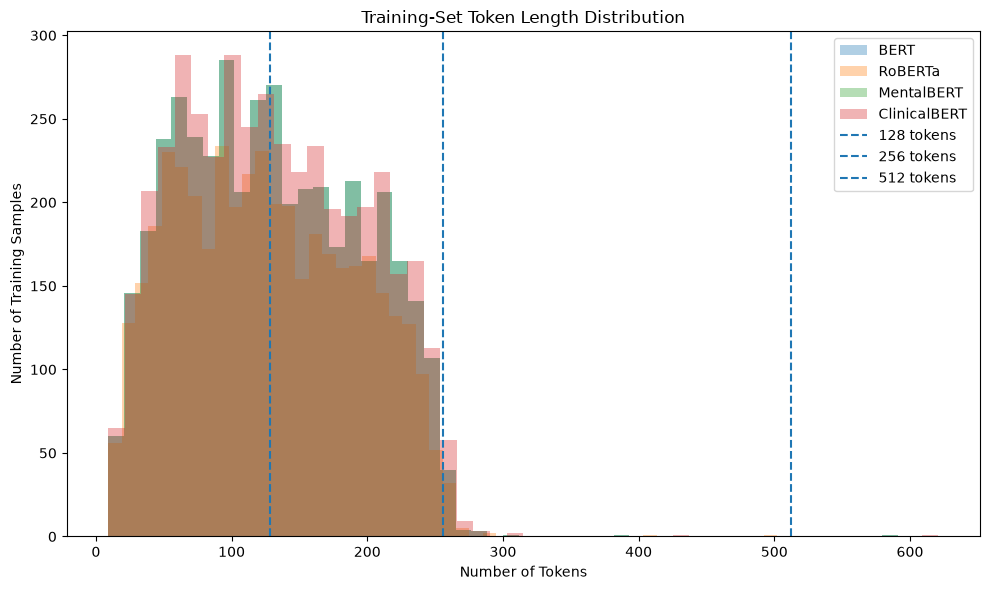

Saved: d:\Thesis_Project\Experiment_2_Transformer-Based Emotion_Classification\outputs\figures\training_token_length_distribution.png


In [150]:
# ============================================================
# EXPERIMENT 2 — PHASE 5 — CELL 32
# TOKEN-LENGTH DISTRIBUTION
# ============================================================

plt.figure(
    figsize=(10, 6)
)

for model_name, lengths in (
    TOKEN_LENGTHS.items()
):

    plt.hist(
        lengths,
        bins=50,
        alpha=0.35,
        label=model_name
    )

plt.axvline(
    128,
    linestyle="--",
    label="128 tokens"
)

plt.axvline(
    256,
    linestyle="--",
    label="256 tokens"
)

plt.axvline(
    512,
    linestyle="--",
    label="512 tokens"
)

plt.xlabel(
    "Number of Tokens"
)

plt.ylabel(
    "Number of Training Samples"
)

plt.title(
    "Training-Set Token Length Distribution"
)

plt.legend()

plt.tight_layout()

TOKEN_LENGTH_FIGURE = (
    FIGURE_DIR
    / "training_token_length_distribution.png"
)

plt.savefig(
    TOKEN_LENGTH_FIGURE,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Saved:",
    TOKEN_LENGTH_FIGURE
)

In [151]:
# ============================================================
# EXPERIMENT 2 — PHASE 5 — CELL 33
# BASELINE SEQUENCE LENGTH
# ============================================================

BASE_MAX_LENGTH = 256

print("=" * 70)
print("BASELINE SEQUENCE LENGTH")
print("=" * 70)

print(
    "Baseline max length:",
    BASE_MAX_LENGTH
)

print()

print(
    "NOTE:"
)

print(
    "256 is the initial controlled baseline."
)

print(
    "The final sequence-length decision will be "
    "validated on the validation set during the "
    "ablation study."
)

print(
    "The test set is not used for this decision."
)

print("=" * 70)

BASELINE SEQUENCE LENGTH
Baseline max length: 256

NOTE:
256 is the initial controlled baseline.
The final sequence-length decision will be validated on the validation set during the ablation study.
The test set is not used for this decision.


In [152]:
# ============================================================
# EXPERIMENT 2 — PHASE 5 — CELL 34
# SAVE MODELING CONFIGURATION
# ============================================================

modeling_config = {

    "dataset": {
        "train_samples":
            len(train_final_df),

        "validation_samples":
            len(val_final_df),

        "test_samples":
            len(test_final_df),

        "total_samples":
            FINAL_TOTAL
    },

    "num_labels":
        NUM_LABELS,

    "labels":
        MODEL_LABELS,

    "models":
        MODEL_REGISTRY,

    "baseline_max_length":
        BASE_MAX_LENGTH,

    "primary_selection_metric":
        "Macro-F1",

    "secondary_metric":
        "Micro-F1",

    "initial_threshold":
        0.5,

    "seed":
        SEED
}


MODELING_CONFIG_PATH = (
    LOG_DIR
    / "modeling_config.json"
)

with open(
    MODELING_CONFIG_PATH,
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        modeling_config,
        file,
        indent=4,
        ensure_ascii=False
    )


print(
    "Saved:",
    MODELING_CONFIG_PATH
)

Saved: d:\Thesis_Project\Experiment_2_Transformer-Based Emotion_Classification\outputs\logs\modeling_config.json


In [153]:
# ============================================================
# EXPERIMENT 2 — PHASE 5 — CELL 35
# FINAL PHASE 5 VERIFICATION
# ============================================================

phase5_checks = {

    "Final train size = 4215":
        len(train_final_df) == 4215,

    "Final validation size = 906":
        len(val_final_df) == 906,

    "Final test size = 906":
        len(test_final_df) == 906,

    "Number of labels = 8":
        NUM_LABELS == 8,

    "Train target width = 8":
        Y_train.shape[1] == 8,

    "Validation target width = 8":
        Y_val.shape[1] == 8,

    "Test target width = 8":
        Y_test.shape[1] == 8,

    "BERT tokenizer loaded":
        bert_tokenizer is not None,

    "RoBERTa tokenizer loaded":
        roberta_tokenizer is not None,

    "MentalBERT tokenizer loaded":
        mentalbert_tokenizer is not None,

    "ClinicalBERT tokenizer loaded":
        clinicalbert_tokenizer is not None
}


print("=" * 78)
print("PHASE 5 — FINAL VERIFICATION")
print("=" * 78)

phase5_passed = True

for check_name, status in (
    phase5_checks.items()
):

    print(
        f"{check_name:<40}: "
        f"{'PASS' if status else 'FAIL'}"
    )

    if not status:
        phase5_passed = False

print("=" * 78)

if phase5_passed:

    print(
        "PHASE 5 STATUS: PASSED"
    )

    print(
        "Final dataset and tokenizer preparation are ready."
    )

else:

    print(
        "PHASE 5 STATUS: FAILED"
    )

print("=" * 78)

PHASE 5 — FINAL VERIFICATION
Final train size = 4215                 : PASS
Final validation size = 906             : PASS
Final test size = 906                   : PASS
Number of labels = 8                    : PASS
Train target width = 8                  : PASS
Validation target width = 8             : PASS
Test target width = 8                   : PASS
BERT tokenizer loaded                   : PASS
RoBERTa tokenizer loaded                : PASS
MentalBERT tokenizer loaded             : PASS
ClinicalBERT tokenizer loaded           : PASS
PHASE 5 STATUS: PASSED
Final dataset and tokenizer preparation are ready.


# PHASE 6 — PyTorch Dataset, Dynamic Padding and DataLoader Infrastructure

## Objective

This phase constructs a reusable and reproducible PyTorch data pipeline for the four transformer models used in Experiment 2.

The final leakage-controlled dataset prepared in the previous phases is used without further modification.

## Key Design Decisions

- Maximum sequence length: **256 tokens**
- Multi-label targets: **8-dimensional float vectors**
- Dynamic batch padding is used instead of padding every sample to 256 tokens.
- Training data are shuffled.
- Validation and test data are never shuffled.
- A fixed random seed is used for reproducibility.
- The same data-loading strategy is used for all four transformer models.
- The test set remains isolated from all training and model-selection procedures.

## Why 256 Tokens?

Training-set token-length analysis showed that 256 tokens cover approximately:

- BERT: 99.24%
- RoBERTa: 99.15%
- MentalBERT: 99.24%
- ClinicalBERT: 98.70%

Therefore, 256 tokens provide a strong balance between textual coverage and computational efficiency.

## Models

1. BERT
2. RoBERTa
3. MentalBERT
4. ClinicalBERT

This phase does not perform full model training. It validates the common data pipeline before training begins.

In [155]:
# ============================================================
# EXPERIMENT 2 — PHASE 6 — CELL 1
# DATALOADER CONFIGURATION
# ============================================================

import random
import numpy as np
import torch

from torch.utils.data import (
    Dataset,
    DataLoader
)

from transformers import (
    DataCollatorWithPadding
)

MAX_LENGTH = 256

TRAIN_BATCH_SIZE = 16
EVAL_BATCH_SIZE = 32

NUM_WORKERS = 0

PIN_MEMORY = (
    torch.cuda.is_available()
)

print("=" * 70)
print("PHASE 6 — DATALOADER CONFIGURATION")
print("=" * 70)

print("Maximum length     :", MAX_LENGTH)
print("Train batch size   :", TRAIN_BATCH_SIZE)
print("Eval batch size    :", EVAL_BATCH_SIZE)
print("Number of workers  :", NUM_WORKERS)
print("Pin memory         :", PIN_MEMORY)

print("=" * 70)

PHASE 6 — DATALOADER CONFIGURATION
Maximum length     : 256
Train batch size   : 16
Eval batch size    : 32
Number of workers  : 0
Pin memory         : True


In [156]:
# ============================================================
# EXPERIMENT 2 — PHASE 6 — CELL 2
# DATALOADER REPRODUCIBILITY
# ============================================================

def seed_worker(worker_id):

    worker_seed = (
        torch.initial_seed()
        % 2**32
    )

    np.random.seed(worker_seed)
    random.seed(worker_seed)


def create_generator(seed=SEED):

    generator = torch.Generator()

    generator.manual_seed(
        seed
    )

    return generator


print(
    "DataLoader reproducibility utilities created."
)

DataLoader reproducibility utilities created.


In [157]:
# ============================================================
# EXPERIMENT 2 — PHASE 6 — CELL 3
# MULTI-LABEL TRANSFORMER DATASET
# ============================================================

class MultiLabelEmotionDataset(Dataset):

    def __init__(
        self,
        dataframe,
        targets,
        tokenizer,
        max_length=256
    ):

        self.dataframe = (
            dataframe
            .reset_index(drop=True)
            .copy()
        )

        self.targets = np.asarray(
            targets,
            dtype=np.float32
        )

        self.tokenizer = tokenizer

        self.max_length = (
            max_length
        )


        if len(self.dataframe) != len(
            self.targets
        ):

            raise ValueError(
                "Number of samples and targets do not match."
            )


    def __len__(self):

        return len(
            self.dataframe
        )


    def __getitem__(self, index):

        row = self.dataframe.iloc[
            index
        ]

        text = str(
            row["text"]
        )

        encoding = self.tokenizer(
            text,
            truncation=True,
            max_length=self.max_length,
            padding=False,
            return_attention_mask=True
        )

        item = {
            key: value
            for key, value
            in encoding.items()
        }

        item["labels"] = (
            self.targets[index]
            .tolist()
        )

        item["sample_id"] = str(
            row["id"]
        )

        return item


print(
    "MultiLabelEmotionDataset created."
)

MultiLabelEmotionDataset created.


In [158]:
# ============================================================
# EXPERIMENT 2 — PHASE 6 — CELL 4
# DYNAMIC PADDING COLLATOR
# ============================================================

class MultiLabelDataCollator:

    def __init__(
        self,
        tokenizer
    ):

        self.padding_collator = (
            DataCollatorWithPadding(
                tokenizer=tokenizer,
                padding=True,
                return_tensors="pt"
            )
        )


    def __call__(
        self,
        features
    ):

        sample_ids = [
            feature.pop(
                "sample_id"
            )
            for feature in features
        ]

        labels = [
            feature.pop(
                "labels"
            )
            for feature in features
        ]

        batch = (
            self.padding_collator(
                features
            )
        )

        batch["labels"] = (
            torch.tensor(
                labels,
                dtype=torch.float32
            )
        )

        batch["sample_ids"] = (
            sample_ids
        )

        return batch


print(
    "Dynamic-padding multi-label collator created."
)

Dynamic-padding multi-label collator created.


In [159]:
# ============================================================
# EXPERIMENT 2 — PHASE 6 — CELL 5
# DATASET BUILDER
# ============================================================

def build_datasets(
    tokenizer,
    max_length=MAX_LENGTH
):

    train_dataset = (
        MultiLabelEmotionDataset(
            dataframe=train_final_df,
            targets=Y_train,
            tokenizer=tokenizer,
            max_length=max_length
        )
    )

    val_dataset = (
        MultiLabelEmotionDataset(
            dataframe=val_final_df,
            targets=Y_val,
            tokenizer=tokenizer,
            max_length=max_length
        )
    )

    test_dataset = (
        MultiLabelEmotionDataset(
            dataframe=test_final_df,
            targets=Y_test,
            tokenizer=tokenizer,
            max_length=max_length
        )
    )

    return (
        train_dataset,
        val_dataset,
        test_dataset
    )


print(
    "Dataset builder created."
)

Dataset builder created.


In [160]:
# ============================================================
# EXPERIMENT 2 — PHASE 6 — CELL 6
# DATALOADER BUILDER
# ============================================================

def build_dataloaders(
    tokenizer,
    train_batch_size=TRAIN_BATCH_SIZE,
    eval_batch_size=EVAL_BATCH_SIZE,
    max_length=MAX_LENGTH,
    seed=SEED
):

    (
        train_dataset,
        val_dataset,
        test_dataset
    ) = build_datasets(
        tokenizer=tokenizer,
        max_length=max_length
    )


    collator = (
        MultiLabelDataCollator(
            tokenizer
        )
    )


    train_loader = DataLoader(

        train_dataset,

        batch_size=train_batch_size,

        shuffle=True,

        collate_fn=collator,

        num_workers=NUM_WORKERS,

        pin_memory=PIN_MEMORY,

        worker_init_fn=seed_worker,

        generator=create_generator(
            seed
        )
    )


    val_loader = DataLoader(

        val_dataset,

        batch_size=eval_batch_size,

        shuffle=False,

        collate_fn=collator,

        num_workers=NUM_WORKERS,

        pin_memory=PIN_MEMORY
    )


    test_loader = DataLoader(

        test_dataset,

        batch_size=eval_batch_size,

        shuffle=False,

        collate_fn=collator,

        num_workers=NUM_WORKERS,

        pin_memory=PIN_MEMORY
    )


    return (
        train_dataset,
        val_dataset,
        test_dataset,
        train_loader,
        val_loader,
        test_loader
    )


print(
    "DataLoader builder created."
)

DataLoader builder created.


In [161]:
# ============================================================
# EXPERIMENT 2 — PHASE 6 — CELL 7
# BERT DATALOADER SMOKE TEST
# ============================================================

(
    bert_train_dataset,
    bert_val_dataset,
    bert_test_dataset,
    bert_train_loader,
    bert_val_loader,
    bert_test_loader
) = build_dataloaders(
    tokenizer=bert_tokenizer
)


print("=" * 70)
print("BERT DATA PIPELINE")
print("=" * 70)

print(
    "Train dataset      :",
    len(bert_train_dataset)
)

print(
    "Validation dataset :",
    len(bert_val_dataset)
)

print(
    "Test dataset       :",
    len(bert_test_dataset)
)

print()

print(
    "Train batches      :",
    len(bert_train_loader)
)

print(
    "Validation batches :",
    len(bert_val_loader)
)

print(
    "Test batches       :",
    len(bert_test_loader)
)

print("=" * 70)

BERT DATA PIPELINE
Train dataset      : 4215
Validation dataset : 906
Test dataset       : 906

Train batches      : 264
Validation batches : 29
Test batches       : 29


In [162]:
# ============================================================
# EXPERIMENT 2 — PHASE 6 — CELL 8
# INSPECT TRAINING BATCH
# ============================================================

bert_batch = next(
    iter(
        bert_train_loader
    )
)

print("=" * 70)
print("BERT TRAINING BATCH")
print("=" * 70)

for key, value in (
    bert_batch.items()
):

    if torch.is_tensor(
        value
    ):

        print(
            f"{key:<15}",
            tuple(value.shape),
            value.dtype
        )

    else:

        print(
            f"{key:<15}",
            f"{len(value)} items"
        )

print("=" * 70)

BERT TRAINING BATCH
input_ids       (16, 217) torch.int64
token_type_ids  (16, 217) torch.int64
attention_mask  (16, 217) torch.int64
labels          (16, 8) torch.float32
sample_ids      16 items


In [163]:
# ============================================================
# EXPERIMENT 2 — PHASE 6 — CELL 9
# BATCH VALIDATION
# ============================================================

assert (
    bert_batch[
        "input_ids"
    ].shape[0]
    == TRAIN_BATCH_SIZE
)

assert (
    bert_batch[
        "attention_mask"
    ].shape
    ==
    bert_batch[
        "input_ids"
    ].shape
)

assert (
    bert_batch[
        "labels"
    ].shape
    ==
    (
        TRAIN_BATCH_SIZE,
        NUM_LABELS
    )
)

assert (
    bert_batch[
        "labels"
    ].dtype
    ==
    torch.float32
)

assert (
    bert_batch[
        "input_ids"
    ].shape[1]
    <= MAX_LENGTH
)

print("=" * 70)
print("BATCH STRUCTURE CHECK: PASSED")
print("=" * 70)

print(
    "Batch sequence length:",
    bert_batch[
        "input_ids"
    ].shape[1]
)

print(
    "Maximum allowed:",
    MAX_LENGTH
)

print(
    "Target shape:",
    tuple(
        bert_batch[
            "labels"
        ].shape
    )
)

print("=" * 70)

BATCH STRUCTURE CHECK: PASSED
Batch sequence length: 217
Maximum allowed: 256
Target shape: (16, 8)


In [164]:
# ============================================================
# EXPERIMENT 2 — PHASE 6 — CELL 10
# VERIFY DYNAMIC PADDING
# ============================================================

observed_lengths = []

loader_iterator = iter(
    bert_train_loader
)

for _ in range(10):

    batch = next(
        loader_iterator
    )

    observed_lengths.append(
        batch[
            "input_ids"
        ].shape[1]
    )


print("=" * 70)
print("DYNAMIC PADDING CHECK")
print("=" * 70)

print(
    "Sequence lengths across 10 batches:"
)

print(
    observed_lengths
)

print()

print(
    "Unique batch lengths:",
    sorted(
        set(
            observed_lengths
        )
    )
)

print("=" * 70)

DYNAMIC PADDING CHECK
Sequence lengths across 10 batches:
[240, 256, 251, 247, 207, 229, 253, 233, 256, 256]

Unique batch lengths: [207, 229, 233, 240, 247, 251, 253, 256]


In [165]:
# ============================================================
# EXPERIMENT 2 — PHASE 6 — CELL 11
# ALL TOKENIZER PIPELINE CHECK
# ============================================================

pipeline_check_rows = []

for model_name, tokenizer in (
    TOKENIZERS.items()
):

    (
        temp_train_dataset,
        temp_val_dataset,
        temp_test_dataset,
        temp_train_loader,
        temp_val_loader,
        temp_test_loader
    ) = build_dataloaders(
        tokenizer=tokenizer
    )

    temp_batch = next(
        iter(
            temp_train_loader
        )
    )

    pipeline_check_rows.append(
        {
            "Model":
                model_name,

            "Train_Samples":
                len(
                    temp_train_dataset
                ),

            "Val_Samples":
                len(
                    temp_val_dataset
                ),

            "Test_Samples":
                len(
                    temp_test_dataset
                ),

            "Batch_Size":
                temp_batch[
                    "input_ids"
                ].shape[0],

            "Batch_Seq_Length":
                temp_batch[
                    "input_ids"
                ].shape[1],

            "Label_Width":
                temp_batch[
                    "labels"
                ].shape[1]
        }
    )


pipeline_check_df = pd.DataFrame(
    pipeline_check_rows
)

display(
    pipeline_check_df
)

,Model,Train_Samples,Val_Samples,Test_Samples,Batch_Size,Batch_Seq_Length,Label_Width
0,BERT,4215,906,906,16,217,8
1,RoBERTa,4215,906,906,16,216,8
2,MentalBERT,4215,906,906,16,217,8
3,ClinicalBERT,4215,906,906,16,219,8


In [166]:
# ============================================================
# EXPERIMENT 2 — PHASE 6 — CELL 12
# MOVE MODEL INPUTS TO DEVICE
# ============================================================

def move_batch_to_device(
    batch,
    device
):

    model_batch = {}

    for key, value in (
        batch.items()
    ):

        if key == "sample_ids":
            continue

        if torch.is_tensor(
            value
        ):

            model_batch[key] = (
                value.to(
                    device,
                    non_blocking=True
                )
            )

    return model_batch


test_device_batch = (
    move_batch_to_device(
        bert_batch,
        DEVICE
    )
)

print("=" * 70)
print("DEVICE TRANSFER TEST")
print("=" * 70)

for key, value in (
    test_device_batch.items()
):

    print(
        key,
        "->",
        value.device,
        tuple(value.shape)
    )

print("=" * 70)

DEVICE TRANSFER TEST
input_ids -> cuda:0 (16, 217)
token_type_ids -> cuda:0 (16, 217)
attention_mask -> cuda:0 (16, 217)
labels -> cuda:0 (16, 8)


In [167]:
# ============================================================
# EXPERIMENT 2 — PHASE 6 — CELL 13
# TRANSFORMER MODEL FACTORY
# ============================================================

from transformers import (
    AutoModelForSequenceClassification
)


def create_multilabel_model(
    model_name
):

    if model_name not in (
        MODEL_REGISTRY
    ):

        raise ValueError(
            f"Unknown model: {model_name}"
        )

    checkpoint = (
        MODEL_REGISTRY[
            model_name
        ]
    )

    model = (
        AutoModelForSequenceClassification
        .from_pretrained(

            checkpoint,

            num_labels=NUM_LABELS,

            id2label=id2label,

            label2id=label2id,

            problem_type=(
                "multi_label_classification"
            )
        )
    )

    return model


print(
    "Multi-label model factory created."
)

Multi-label model factory created.


In [168]:
# ============================================================
# EXPERIMENT 2 — PHASE 6 — CELL 14
# LOAD BERT FOR FORWARD-PASS SMOKE TEST
# ============================================================

bert_smoke_model = (
    create_multilabel_model(
        "BERT"
    )
)

bert_smoke_model = (
    bert_smoke_model.to(
        DEVICE
    )
)

bert_smoke_model.eval()

print("=" * 70)
print("BERT SMOKE MODEL")
print("=" * 70)

print(
    "Device:",
    next(
        bert_smoke_model.parameters()
    ).device
)

print(
    "Number of output labels:",
    bert_smoke_model.config.num_labels
)

print(
    "Problem type:",
    bert_smoke_model.config.problem_type
)

print("=" * 70)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BERT SMOKE MODEL
Device: cuda:0
Number of output labels: 8
Problem type: multi_label_classification


In [169]:
# ============================================================
# EXPERIMENT 2 — PHASE 6 — CELL 15
# FORWARD-PASS SMOKE TEST
# ============================================================

smoke_batch = next(
    iter(
        bert_val_loader
    )
)

smoke_model_batch = (
    move_batch_to_device(
        smoke_batch,
        DEVICE
    )
)

with torch.no_grad():

    outputs = (
        bert_smoke_model(
            **smoke_model_batch
        )
    )


print("=" * 70)
print("FORWARD-PASS TEST")
print("=" * 70)

print(
    "Logits shape:",
    tuple(
        outputs.logits.shape
    )
)

print(
    "Loss:",
    float(
        outputs.loss
    )
)

print("=" * 70)

FORWARD-PASS TEST
Logits shape: (32, 8)
Loss: 0.7684840559959412


In [170]:
# ============================================================
# EXPERIMENT 2 — PHASE 6 — CELL 16
# FORWARD-PASS VALIDATION
# ============================================================

assert (
    outputs.logits.shape[1]
    == NUM_LABELS
)

assert torch.isfinite(
    outputs.logits
).all()

assert torch.isfinite(
    outputs.loss
)

print("=" * 70)
print("FORWARD PASS: PASSED")
print("=" * 70)

print(
    "Expected labels:",
    NUM_LABELS
)

print(
    "Output labels:",
    outputs.logits.shape[1]
)

print(
    "Finite loss:",
    torch.isfinite(
        outputs.loss
    ).item()
)

print("=" * 70)

FORWARD PASS: PASSED
Expected labels: 8
Output labels: 8
Finite loss: True


In [171]:
# ============================================================
# EXPERIMENT 2 — PHASE 6 — CELL 17
# MULTI-LABEL SIGMOID CHECK
# ============================================================

smoke_probabilities = (
    torch.sigmoid(
        outputs.logits
    )
)

print("=" * 70)
print("SIGMOID PROBABILITY CHECK")
print("=" * 70)

print(
    "Shape:",
    tuple(
        smoke_probabilities.shape
    )
)

print(
    "Minimum probability:",
    float(
        smoke_probabilities.min()
    )
)

print(
    "Maximum probability:",
    float(
        smoke_probabilities.max()
    )
)

print("=" * 70)

assert (
    smoke_probabilities.min()
    >= 0
)

assert (
    smoke_probabilities.max()
    <= 1
)

print(
    "SIGMOID CHECK: PASSED"
)

SIGMOID PROBABILITY CHECK
Shape: (32, 8)
Minimum probability: 0.2732042074203491
Maximum probability: 0.7220905423164368
SIGMOID CHECK: PASSED


In [172]:
# ============================================================
# EXPERIMENT 2 — PHASE 6 — CELL 18
# GPU MEMORY CHECK
# ============================================================

if torch.cuda.is_available():

    allocated_gb = (
        torch.cuda.memory_allocated()
        / (1024 ** 3)
    )

    reserved_gb = (
        torch.cuda.memory_reserved()
        / (1024 ** 3)
    )

    print("=" * 70)
    print("GPU MEMORY")
    print("=" * 70)

    print(
        "Allocated:",
        round(
            allocated_gb,
            3
        ),
        "GB"
    )

    print(
        "Reserved :",
        round(
            reserved_gb,
            3
        ),
        "GB"
    )

    print("=" * 70)

else:

    print(
        "CUDA is not available."
    )

GPU MEMORY
Allocated: 0.417 GB
Reserved : 0.867 GB


In [173]:
# ============================================================
# EXPERIMENT 2 — PHASE 6 — CELL 19
# RELEASE SMOKE-TEST MODEL
# ============================================================

import gc

del bert_smoke_model
del outputs
del smoke_model_batch

gc.collect()

if torch.cuda.is_available():

    torch.cuda.empty_cache()

print(
    "Smoke-test model released from memory."
)

Smoke-test model released from memory.


In [174]:
# ============================================================
# EXPERIMENT 2 — PHASE 6 — CELL 20
# SAVE DATA PIPELINE CONFIG
# ============================================================

data_pipeline_config = {

    "max_length":
        MAX_LENGTH,

    "train_batch_size":
        TRAIN_BATCH_SIZE,

    "eval_batch_size":
        EVAL_BATCH_SIZE,

    "dynamic_padding":
        True,

    "train_shuffle":
        True,

    "validation_shuffle":
        False,

    "test_shuffle":
        False,

    "num_workers":
        NUM_WORKERS,

    "pin_memory":
        PIN_MEMORY,

    "num_labels":
        NUM_LABELS,

    "seed":
        SEED
}


DATA_PIPELINE_CONFIG_PATH = (
    LOG_DIR
    / "data_pipeline_config.json"
)


with open(
    DATA_PIPELINE_CONFIG_PATH,
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        data_pipeline_config,
        file,
        indent=4
    )


print(
    "Saved:",
    DATA_PIPELINE_CONFIG_PATH
)

Saved: d:\Thesis_Project\Experiment_2_Transformer-Based Emotion_Classification\outputs\logs\data_pipeline_config.json


In [175]:
# ============================================================
# EXPERIMENT 2 — PHASE 6 — CELL 21
# FINAL PHASE 6 VERIFICATION
# ============================================================

phase6_checks = {

    "Train samples correct":
        len(
            bert_train_dataset
        ) == 4215,

    "Validation samples correct":
        len(
            bert_val_dataset
        ) == 906,

    "Test samples correct":
        len(
            bert_test_dataset
        ) == 906,

    "Maximum sequence length = 256":
        MAX_LENGTH == 256,

    "Label width = 8":
        bert_batch[
            "labels"
        ].shape[1] == 8,

    "Float labels":
        bert_batch[
            "labels"
        ].dtype == torch.float32,

    "Batch <= max length":
        bert_batch[
            "input_ids"
        ].shape[1]
        <= MAX_LENGTH,

    "All tokenizer pipelines valid":
        (
            pipeline_check_df[
                "Label_Width"
            ] == 8
        ).all()
}


print("=" * 78)
print("PHASE 6 — FINAL VERIFICATION")
print("=" * 78)

phase6_passed = True

for check_name, status in (
    phase6_checks.items()
):

    print(
        f"{check_name:<42}: "
        f"{'PASS' if status else 'FAIL'}"
    )

    if not status:

        phase6_passed = False

print("=" * 78)

if phase6_passed:

    print(
        "PHASE 6 STATUS: PASSED"
    )

    print(
        "The common transformer data pipeline "
        "is ready for controlled model training."
    )

else:

    print(
        "PHASE 6 STATUS: FAILED"
    )

print("=" * 78)

PHASE 6 — FINAL VERIFICATION
Train samples correct                     : PASS
Validation samples correct                : PASS
Test samples correct                      : PASS
Maximum sequence length = 256             : PASS
Label width = 8                           : PASS
Float labels                              : PASS
Batch <= max length                       : PASS
All tokenizer pipelines valid             : PASS
PHASE 6 STATUS: PASSED
The common transformer data pipeline is ready for controlled model training.


# PHASE 7 — Common Training and Validation Engine

## Objective

This phase implements a common, reproducible training and validation framework for all four transformer models in Experiment 2.

The same optimization strategy, batch configuration, evaluation procedure, threshold, early-stopping rule, and checkpointing protocol will be applied to:

1. BERT
2. RoBERTa
3. MentalBERT
4. ClinicalBERT

## Training Protocol

- Training data: final leakage-controlled training split
- Model selection data: validation split only
- Test set: strictly unused
- Maximum sequence length: 256
- Training batch size: 16
- Evaluation batch size: 32
- Optimizer: AdamW
- Initial learning rate: 2e-5
- Weight decay: 0.01
- Scheduler: linear decay with warm-up
- Warm-up ratio: 0.10
- Maximum epochs: 5
- Gradient clipping: 1.0
- Mixed-precision training: enabled when CUDA is available
- Initial decision threshold: 0.50
- Primary selection metric: Macro-F1
- Secondary metric: Micro-F1
- Early-stopping patience: 2 epochs
- Random seed: 42

## Methodological Rule

The test set is not used for:

- training,
- early stopping,
- hyperparameter selection,
- threshold selection,
- architecture selection,
- or checkpoint selection.

The best checkpoint is selected solely from validation Macro-F1.

Threshold optimization and additional hyperparameter experiments will be performed later using development data only.

In [176]:
# ============================================================
# EXPERIMENT 2 — PHASE 7 — CELL 1
# COMMON TRAINING CONFIGURATION
# ============================================================

LEARNING_RATE = 2e-5
WEIGHT_DECAY = 0.01

MAX_EPOCHS = 5
EARLY_STOPPING_PATIENCE = 2
EARLY_STOPPING_MIN_DELTA = 1e-4

WARMUP_RATIO = 0.10

MAX_GRAD_NORM = 1.0

GRAD_ACCUM_STEPS = 1

BASE_THRESHOLD = 0.50

USE_AMP = (
    torch.cuda.is_available()
)

PRIMARY_METRIC = "macro_f1"

print("=" * 75)
print("COMMON TRAINING CONFIGURATION")
print("=" * 75)

print("Learning rate          :", LEARNING_RATE)
print("Weight decay           :", WEIGHT_DECAY)
print("Maximum epochs         :", MAX_EPOCHS)
print("Early stopping patience:", EARLY_STOPPING_PATIENCE)
print("Warm-up ratio          :", WARMUP_RATIO)
print("Gradient clipping      :", MAX_GRAD_NORM)
print("Gradient accumulation  :", GRAD_ACCUM_STEPS)
print("Initial threshold      :", BASE_THRESHOLD)
print("Mixed precision        :", USE_AMP)
print("Primary metric         :", PRIMARY_METRIC)

print("=" * 75)

COMMON TRAINING CONFIGURATION
Learning rate          : 2e-05
Weight decay           : 0.01
Maximum epochs         : 5
Early stopping patience: 2
Warm-up ratio          : 0.1
Gradient clipping      : 1.0
Gradient accumulation  : 1
Initial threshold      : 0.5
Mixed precision        : True
Primary metric         : macro_f1


In [177]:
# ============================================================
# EXPERIMENT 2 — PHASE 7 — CELL 2
# RESET RANDOM STATE
# ============================================================

from transformers import set_seed


def reset_random_state(seed=SEED):

    os.environ[
        "PYTHONHASHSEED"
    ] = str(seed)

    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)

    if torch.cuda.is_available():

        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    set_seed(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


reset_random_state(SEED)

print(
    f"Random state reset with seed = {SEED}"
)

Random state reset with seed = 42


In [178]:
# ============================================================
# EXPERIMENT 2 — PHASE 7 — CELL 3
# MULTI-LABEL METRICS
# ============================================================

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    hamming_loss,
    accuracy_score
)


def compute_multilabel_metrics(
    y_true,
    probabilities,
    threshold=0.50
):

    y_true = np.asarray(
        y_true
    ).astype(int)

    probabilities = np.asarray(
        probabilities
    )

    predictions = (
        probabilities >= threshold
    ).astype(int)

    metrics = {

        "micro_precision":
            precision_score(
                y_true,
                predictions,
                average="micro",
                zero_division=0
            ),

        "micro_recall":
            recall_score(
                y_true,
                predictions,
                average="micro",
                zero_division=0
            ),

        "micro_f1":
            f1_score(
                y_true,
                predictions,
                average="micro",
                zero_division=0
            ),

        "macro_precision":
            precision_score(
                y_true,
                predictions,
                average="macro",
                zero_division=0
            ),

        "macro_recall":
            recall_score(
                y_true,
                predictions,
                average="macro",
                zero_division=0
            ),

        "macro_f1":
            f1_score(
                y_true,
                predictions,
                average="macro",
                zero_division=0
            ),

        "weighted_f1":
            f1_score(
                y_true,
                predictions,
                average="weighted",
                zero_division=0
            ),

        "hamming_loss":
            hamming_loss(
                y_true,
                predictions
            ),

        "subset_accuracy":
            accuracy_score(
                y_true,
                predictions
            )
    }

    return metrics, predictions


print(
    "Multi-label metric function created."
)

Multi-label metric function created.


In [179]:
# ============================================================
# EXPERIMENT 2 — PHASE 7 — CELL 4
# PREDICTION TABLE BUILDER
# ============================================================

def build_prediction_table(
    sample_ids,
    y_true,
    probabilities,
    predictions
):

    result = pd.DataFrame(
        {
            "id": sample_ids
        }
    )

    for label_index, label in enumerate(
        MODEL_LABELS
    ):

        result[
            f"true__{label}"
        ] = y_true[
            :,
            label_index
        ].astype(int)

        result[
            f"prob__{label}"
        ] = probabilities[
            :,
            label_index
        ]

        result[
            f"pred__{label}"
        ] = predictions[
            :,
            label_index
        ].astype(int)

    return result


print(
    "Prediction-table function created."
)

Prediction-table function created.


In [180]:
# ============================================================
# EXPERIMENT 2 — PHASE 7 — CELL 5
# ROBUST MULTI-LABEL MODEL FACTORY
# ============================================================

from transformers import (
    AutoModelForSequenceClassification
)


def create_multilabel_model(
    model_name
):

    if model_name not in MODEL_REGISTRY:

        raise ValueError(
            f"Unknown model: {model_name}"
        )

    checkpoint = (
        MODEL_REGISTRY[
            model_name
        ]
    )

    load_kwargs = {

        "num_labels":
            NUM_LABELS,

        "id2label":
            id2label,

        "label2id":
            label2id,

        "problem_type":
            "multi_label_classification"
    }

    # MentalBERT is gated.
    if model_name == "MentalBERT":

        load_kwargs[
            "token"
        ] = True

    model = (
        AutoModelForSequenceClassification
        .from_pretrained(
            checkpoint,
            **load_kwargs
        )
    )

    return model


print(
    "Robust model factory created."
)

Robust model factory created.


In [181]:
# ============================================================
# EXPERIMENT 2 — PHASE 7 — CELL 6
# ADAMW OPTIMIZER FACTORY
# ============================================================

def create_optimizer(
    model,
    learning_rate=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
):

    no_decay_terms = [
        "bias",
        "LayerNorm.weight",
        "layer_norm.weight"
    ]

    decay_parameters = []

    no_decay_parameters = []

    for name, parameter in (
        model.named_parameters()
    ):

        if not parameter.requires_grad:
            continue

        if any(
            term in name
            for term in no_decay_terms
        ):

            no_decay_parameters.append(
                parameter
            )

        else:

            decay_parameters.append(
                parameter
            )

    optimizer_groups = [

        {
            "params":
                decay_parameters,

            "weight_decay":
                weight_decay
        },

        {
            "params":
                no_decay_parameters,

            "weight_decay":
                0.0
        }
    ]

    optimizer = torch.optim.AdamW(
        optimizer_groups,
        lr=learning_rate
    )

    return optimizer


print(
    "AdamW optimizer factory created."
)

AdamW optimizer factory created.


In [182]:
# ============================================================
# EXPERIMENT 2 — PHASE 7 — CELL 7
# LINEAR WARMUP SCHEDULER
# ============================================================

import math

from transformers import (
    get_linear_schedule_with_warmup
)


def create_scheduler(
    optimizer,
    train_loader,
    epochs,
    grad_accum_steps=1,
    warmup_ratio=WARMUP_RATIO
):

    update_steps_per_epoch = (
        math.ceil(
            len(train_loader)
            / grad_accum_steps
        )
    )

    total_training_steps = (
        update_steps_per_epoch
        * epochs
    )

    warmup_steps = int(
        total_training_steps
        * warmup_ratio
    )

    scheduler = (
        get_linear_schedule_with_warmup(
            optimizer,
            num_warmup_steps=warmup_steps,
            num_training_steps=total_training_steps
        )
    )

    return (
        scheduler,
        total_training_steps,
        warmup_steps
    )


print(
    "Linear scheduler factory created."
)

Linear scheduler factory created.


In [183]:
# ============================================================
# EXPERIMENT 2 — PHASE 7 — CELL 8
# AMP SCALER FACTORY
# ============================================================

def create_grad_scaler():

    scaler = torch.amp.GradScaler(
        "cuda",
        enabled=USE_AMP
    )

    return scaler


print(
    "AMP scaler factory created."
)

AMP scaler factory created.


In [184]:
# ============================================================
# EXPERIMENT 2 — PHASE 7 — CELL 9
# TRAIN ONE EPOCH
# ============================================================

from tqdm.auto import tqdm


def train_one_epoch(
    model,
    train_loader,
    optimizer,
    scheduler,
    scaler,
    device,
    grad_accum_steps=GRAD_ACCUM_STEPS,
    max_grad_norm=MAX_GRAD_NORM,
    max_batches=None
):

    model.train()

    optimizer.zero_grad(
        set_to_none=True
    )

    running_loss = 0.0
    total_examples = 0

    loader_length = len(
        train_loader
    )

    effective_length = (
        min(
            loader_length,
            max_batches
        )
        if max_batches is not None
        else loader_length
    )

    progress_bar = tqdm(
        enumerate(train_loader),
        total=effective_length,
        desc="Training",
        leave=False
    )

    for step, batch in progress_bar:

        if (
            max_batches is not None
            and step >= max_batches
        ):
            break

        batch_size = (
            batch[
                "labels"
            ].shape[0]
        )

        model_batch = (
            move_batch_to_device(
                batch,
                device
            )
        )

        with torch.amp.autocast(
            device_type=device.type,
            dtype=torch.float16,
            enabled=USE_AMP
        ):

            outputs = model(
                **model_batch
            )

            raw_loss = (
                outputs.loss
            )

            loss = (
                raw_loss
                / grad_accum_steps
            )

        scaler.scale(
            loss
        ).backward()

        is_update_step = (
            (
                (step + 1)
                % grad_accum_steps
            ) == 0
        )

        is_last_step = (
            step + 1
            == effective_length
        )

        if (
            is_update_step
            or is_last_step
        ):

            scaler.unscale_(
                optimizer
            )

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                max_grad_norm
            )

            scaler.step(
                optimizer
            )

            scaler.update()

            optimizer.zero_grad(
                set_to_none=True
            )

            scheduler.step()

        running_loss += (
            float(
                raw_loss.detach()
            )
            * batch_size
        )

        total_examples += (
            batch_size
        )

        progress_bar.set_postfix(
            loss=f"{float(raw_loss.detach()):.4f}"
        )

    average_loss = (
        running_loss
        / total_examples
    )

    return average_loss

In [185]:
# ============================================================
# EXPERIMENT 2 — PHASE 7 — CELL 10
# VALIDATION FUNCTION
# ============================================================

def evaluate_model(
    model,
    data_loader,
    device,
    threshold=BASE_THRESHOLD,
    max_batches=None
):

    model.eval()

    running_loss = 0.0
    total_examples = 0

    all_logits = []
    all_labels = []
    all_sample_ids = []

    loader_length = len(
        data_loader
    )

    effective_length = (
        min(
            loader_length,
            max_batches
        )
        if max_batches is not None
        else loader_length
    )

    progress_bar = tqdm(
        enumerate(data_loader),
        total=effective_length,
        desc="Validation",
        leave=False
    )

    with torch.no_grad():

        for step, batch in progress_bar:

            if (
                max_batches is not None
                and step >= max_batches
            ):
                break

            batch_size = (
                batch[
                    "labels"
                ].shape[0]
            )

            sample_ids = (
                batch[
                    "sample_ids"
                ]
            )

            model_batch = (
                move_batch_to_device(
                    batch,
                    device
                )
            )

            with torch.amp.autocast(
                device_type=device.type,
                dtype=torch.float16,
                enabled=USE_AMP
            ):

                outputs = model(
                    **model_batch
                )

            running_loss += (
                float(
                    outputs.loss.detach()
                )
                * batch_size
            )

            total_examples += (
                batch_size
            )

            all_logits.append(
                outputs.logits
                .detach()
                .float()
                .cpu()
            )

            all_labels.append(
                model_batch[
                    "labels"
                ]
                .detach()
                .float()
                .cpu()
            )

            all_sample_ids.extend(
                sample_ids
            )

    logits = torch.cat(
        all_logits,
        dim=0
    ).numpy()

    labels = torch.cat(
        all_labels,
        dim=0
    ).numpy()

    probabilities = (
        1.0
        /
        (
            1.0
            + np.exp(
                -logits
            )
        )
    )

    metrics, predictions = (
        compute_multilabel_metrics(
            labels,
            probabilities,
            threshold=threshold
        )
    )

    metrics[
        "loss"
    ] = (
        running_loss
        / total_examples
    )

    return {
        "metrics":
            metrics,

        "sample_ids":
            all_sample_ids,

        "labels":
            labels,

        "logits":
            logits,

        "probabilities":
            probabilities,

        "predictions":
            predictions
    }

In [186]:
# ============================================================
# EXPERIMENT 2 — PHASE 7 — CELL 11
# BEST CHECKPOINT SAVER
# ============================================================

def save_best_checkpoint(
    model,
    tokenizer,
    model_name,
    seed,
    epoch,
    metrics
):

    model_dir_name = (
        model_name
        .lower()
        .replace(
            " ",
            "_"
        )
    )

    checkpoint_path = (
        CHECKPOINT_DIR
        / model_dir_name
        / f"seed_{seed}"
        / "best_model"
    )

    checkpoint_path.mkdir(
        parents=True,
        exist_ok=True
    )

    model.save_pretrained(
        checkpoint_path
    )

    tokenizer.save_pretrained(
        checkpoint_path
    )

    checkpoint_metadata = {
        "model_name":
            model_name,

        "source_checkpoint":
            MODEL_REGISTRY[
                model_name
            ],

        "seed":
            seed,

        "best_epoch":
            epoch,

        "threshold":
            BASE_THRESHOLD,

        "validation_metrics":
            {
                key:
                    float(value)
                for key, value
                in metrics.items()
            }
    }

    with open(
        checkpoint_path
        / "checkpoint_metadata.json",
        "w",
        encoding="utf-8"
    ) as file:

        json.dump(
            checkpoint_metadata,
            file,
            indent=4,
            ensure_ascii=False
        )

    return checkpoint_path


print(
    "Best-checkpoint saver created."
)

Best-checkpoint saver created.


In [187]:
# ============================================================
# EXPERIMENT 2 — PHASE 7 — CELL 12
# TRAINING HISTORY SAVER
# ============================================================

def save_training_history(
    model_name,
    seed,
    history
):

    model_dir_name = (
        model_name
        .lower()
        .replace(
            " ",
            "_"
        )
    )

    history_dir = (
        METRICS_DIR
        / model_dir_name
        / f"seed_{seed}"
    )

    history_dir.mkdir(
        parents=True,
        exist_ok=True
    )

    history_df = pd.DataFrame(
        history
    )

    history_path = (
        history_dir
        / "training_history.csv"
    )

    history_df.to_csv(
        history_path,
        index=False
    )

    return (
        history_df,
        history_path
    )


print(
    "Training-history saver created."
)

Training-history saver created.


In [188]:
# ============================================================
# EXPERIMENT 2 — PHASE 7 — CELL 13
# COMMON TRAINING ENGINE
# ============================================================

def train_transformer_model(
    model_name,
    seed=SEED,
    learning_rate=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    max_epochs=MAX_EPOCHS,
    patience=EARLY_STOPPING_PATIENCE,
    threshold=BASE_THRESHOLD
):

    print("=" * 80)
    print(
        f"TRAINING MODEL: {model_name}"
    )
    print("=" * 80)

    # --------------------------------------------------------
    # Reset RNG before every model initialization
    # --------------------------------------------------------

    reset_random_state(
        seed
    )

    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    tokenizer = (
        TOKENIZERS[
            model_name
        ]
    )

    # --------------------------------------------------------
    # Fresh data loaders
    # --------------------------------------------------------

    (
        train_dataset,
        val_dataset,
        _,
        train_loader,
        val_loader,
        _
    ) = build_dataloaders(

        tokenizer=tokenizer,

        train_batch_size=TRAIN_BATCH_SIZE,

        eval_batch_size=EVAL_BATCH_SIZE,

        max_length=MAX_LENGTH,

        seed=seed
    )

    # --------------------------------------------------------
    # Fresh model
    # --------------------------------------------------------

    model = (
        create_multilabel_model(
            model_name
        )
        .to(
            DEVICE
        )
    )

    # --------------------------------------------------------
    # Optimizer
    # --------------------------------------------------------

    optimizer = (
        create_optimizer(
            model,
            learning_rate=learning_rate,
            weight_decay=weight_decay
        )
    )

    # --------------------------------------------------------
    # Scheduler
    # --------------------------------------------------------

    (
        scheduler,
        total_steps,
        warmup_steps
    ) = create_scheduler(

        optimizer,
        train_loader,
        max_epochs,
        grad_accum_steps=GRAD_ACCUM_STEPS,
        warmup_ratio=WARMUP_RATIO
    )

    scaler = (
        create_grad_scaler()
    )

    print(
        "Training samples :",
        len(train_dataset)
    )

    print(
        "Validation samples:",
        len(val_dataset)
    )

    print(
        "Optimizer steps  :",
        total_steps
    )

    print(
        "Warm-up steps    :",
        warmup_steps
    )

    print(
        "Device           :",
        DEVICE
    )

    print()

    # --------------------------------------------------------
    # Early-stopping variables
    # --------------------------------------------------------

    best_macro_f1 = (
        -np.inf
    )

    best_epoch = None

    best_checkpoint = None

    patience_counter = 0

    history = []

    best_validation_result = None

    # --------------------------------------------------------
    # Epoch loop
    # --------------------------------------------------------

    for epoch in range(
        1,
        max_epochs + 1
    ):

        print(
            f"\nEpoch {epoch}/{max_epochs}"
        )

        train_loss = (
            train_one_epoch(
                model=model,
                train_loader=train_loader,
                optimizer=optimizer,
                scheduler=scheduler,
                scaler=scaler,
                device=DEVICE
            )
        )

        validation_result = (
            evaluate_model(
                model=model,
                data_loader=val_loader,
                device=DEVICE,
                threshold=threshold
            )
        )

        val_metrics = (
            validation_result[
                "metrics"
            ]
        )

        history_row = {

            "epoch":
                epoch,

            "train_loss":
                train_loss,

            "val_loss":
                val_metrics[
                    "loss"
                ],

            "val_micro_precision":
                val_metrics[
                    "micro_precision"
                ],

            "val_micro_recall":
                val_metrics[
                    "micro_recall"
                ],

            "val_micro_f1":
                val_metrics[
                    "micro_f1"
                ],

            "val_macro_precision":
                val_metrics[
                    "macro_precision"
                ],

            "val_macro_recall":
                val_metrics[
                    "macro_recall"
                ],

            "val_macro_f1":
                val_metrics[
                    "macro_f1"
                ],

            "val_weighted_f1":
                val_metrics[
                    "weighted_f1"
                ],

            "val_hamming_loss":
                val_metrics[
                    "hamming_loss"
                ],

            "val_subset_accuracy":
                val_metrics[
                    "subset_accuracy"
                ]
        }

        history.append(
            history_row
        )

        print(
            f"Train Loss : "
            f"{train_loss:.4f}"
        )

        print(
            f"Val Loss   : "
            f"{val_metrics['loss']:.4f}"
        )

        print(
            f"Macro-F1   : "
            f"{val_metrics['macro_f1']:.4f}"
        )

        print(
            f"Micro-F1   : "
            f"{val_metrics['micro_f1']:.4f}"
        )

        print(
            f"Hamming    : "
            f"{val_metrics['hamming_loss']:.4f}"
        )

        current_macro_f1 = (
            val_metrics[
                "macro_f1"
            ]
        )

        # ----------------------------------------------------
        # Best model
        # ----------------------------------------------------

        if (
            current_macro_f1
            >
            best_macro_f1
            + EARLY_STOPPING_MIN_DELTA
        ):

            best_macro_f1 = (
                current_macro_f1
            )

            best_epoch = (
                epoch
            )

            patience_counter = 0

            best_validation_result = (
                validation_result
            )

            best_checkpoint = (
                save_best_checkpoint(
                    model=model,
                    tokenizer=tokenizer,
                    model_name=model_name,
                    seed=seed,
                    epoch=epoch,
                    metrics=val_metrics
                )
            )

            print(
                "New best checkpoint saved."
            )

        else:

            patience_counter += 1

            print(
                f"No improvement. "
                f"Patience: "
                f"{patience_counter}/{patience}"
            )

        if (
            patience_counter
            >= patience
        ):

            print(
                "Early stopping triggered."
            )

            break

    # --------------------------------------------------------
    # Save training history
    # --------------------------------------------------------

    history_df, history_path = (
        save_training_history(
            model_name,
            seed,
            history
        )
    )

    # --------------------------------------------------------
    # Save best validation predictions
    # --------------------------------------------------------

    prediction_df = (
        build_prediction_table(

            best_validation_result[
                "sample_ids"
            ],

            best_validation_result[
                "labels"
            ],

            best_validation_result[
                "probabilities"
            ],

            best_validation_result[
                "predictions"
            ]
        )
    )

    model_dir_name = (
        model_name
        .lower()
        .replace(
            " ",
            "_"
        )
    )

    validation_prediction_dir = (
        PREDICTION_DIR
        / model_dir_name
        / f"seed_{seed}"
    )

    validation_prediction_dir.mkdir(
        parents=True,
        exist_ok=True
    )

    validation_prediction_path = (
        validation_prediction_dir
        / "best_validation_predictions.csv"
    )

    prediction_df.to_csv(
        validation_prediction_path,
        index=False
    )

    print("\n" + "=" * 80)

    print(
        f"{model_name} TRAINING COMPLETED"
    )

    print(
        "Best epoch    :",
        best_epoch
    )

    print(
        "Best Macro-F1 :",
        round(
            best_macro_f1,
            6
        )
    )

    print(
        "Checkpoint    :",
        best_checkpoint
    )

    print(
        "History       :",
        history_path
    )

    print("=" * 80)

    result = {

        "model_name":
            model_name,

        "seed":
            seed,

        "best_epoch":
            best_epoch,

        "best_macro_f1":
            best_macro_f1,

        "best_micro_f1":
            best_validation_result[
                "metrics"
            ][
                "micro_f1"
            ],

        "best_hamming_loss":
            best_validation_result[
                "metrics"
            ][
                "hamming_loss"
            ],

        "checkpoint_path":
            str(
                best_checkpoint
            ),

        "history_path":
            str(
                history_path
            ),

        "validation_prediction_path":
            str(
                validation_prediction_path
            )
    }

    # Release memory
    del model
    del optimizer
    del scheduler
    del scaler

    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return result

In [189]:
# ============================================================
# EXPERIMENT 2 — PHASE 7 — CELL 14
# ENGINE SMOKE TEST SETUP
# ============================================================

reset_random_state(
    SEED
)

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

smoke_model = (
    create_multilabel_model(
        "BERT"
    )
    .to(
        DEVICE
    )
)

(
    _,
    _,
    _,
    smoke_train_loader,
    smoke_val_loader,
    _
) = build_dataloaders(
    tokenizer=bert_tokenizer,
    seed=SEED
)

smoke_optimizer = (
    create_optimizer(
        smoke_model
    )
)

(
    smoke_scheduler,
    smoke_total_steps,
    smoke_warmup_steps
) = create_scheduler(
    smoke_optimizer,
    smoke_train_loader,
    epochs=1
)

smoke_scaler = (
    create_grad_scaler()
)

print(
    "Training-engine smoke test initialized."
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Training-engine smoke test initialized.


In [190]:
# ============================================================
# EXPERIMENT 2 — PHASE 7 — CELL 15
# TRAINING ENGINE SMOKE TEST
# ============================================================

smoke_train_loss = (
    train_one_epoch(
        model=smoke_model,
        train_loader=smoke_train_loader,
        optimizer=smoke_optimizer,
        scheduler=smoke_scheduler,
        scaler=smoke_scaler,
        device=DEVICE,
        max_batches=2
    )
)

print("=" * 70)
print("TRAINING ENGINE SMOKE TEST")
print("=" * 70)

print(
    "Average loss:",
    smoke_train_loss
)

print(
    "Finite loss:",
    np.isfinite(
        smoke_train_loss
    )
)

print("=" * 70)

Training:   0%|          | 0/2 [00:00<?, ?it/s]

TRAINING ENGINE SMOKE TEST
Average loss: 0.7753016352653503
Finite loss: True


In [191]:
# ============================================================
# EXPERIMENT 2 — PHASE 7 — CELL 16
# VALIDATION ENGINE SMOKE TEST
# ============================================================

smoke_validation_result = (
    evaluate_model(
        model=smoke_model,
        data_loader=smoke_val_loader,
        device=DEVICE,
        threshold=BASE_THRESHOLD,
        max_batches=2
    )
)

smoke_metrics = (
    smoke_validation_result[
        "metrics"
    ]
)

print("=" * 70)
print("VALIDATION ENGINE SMOKE TEST")
print("=" * 70)

for metric_name, value in (
    smoke_metrics.items()
):

    print(
        f"{metric_name:<20}: "
        f"{value:.6f}"
    )

print()

print(
    "Samples evaluated:",
    len(
        smoke_validation_result[
            "sample_ids"
        ]
    )
)

print("=" * 70)

Validation:   0%|          | 0/2 [00:00<?, ?it/s]

VALIDATION ENGINE SMOKE TEST
micro_precision     : 0.457831
micro_recall        : 0.596078
micro_f1            : 0.517888
macro_precision     : 0.347656
macro_recall        : 0.650000
macro_f1            : 0.413141
weighted_f1         : 0.420898
hamming_loss        : 0.552734
subset_accuracy     : 0.000000
loss                : 0.748562

Samples evaluated: 64


In [192]:
# ============================================================
# EXPERIMENT 2 — PHASE 7 — CELL 17
# ENGINE VALIDATION
# ============================================================

assert np.isfinite(
    smoke_train_loss
)

assert np.isfinite(
    smoke_metrics[
        "loss"
    ]
)

assert (
    smoke_validation_result[
        "probabilities"
    ].shape[1]
    == NUM_LABELS
)

assert (
    smoke_validation_result[
        "predictions"
    ].shape[1]
    == NUM_LABELS
)

assert (
    len(
        smoke_validation_result[
            "sample_ids"
        ]
    ) == 64
)

assert (
    (
        smoke_validation_result[
            "probabilities"
        ] >= 0
    ).all()
)

assert (
    (
        smoke_validation_result[
            "probabilities"
        ] <= 1
    ).all()
)

print("=" * 70)
print("TRAINING ENGINE CHECK: PASSED")
print("=" * 70)

print(
    "Loss calculation       : PASS"
)

print(
    "Backward propagation   : PASS"
)

print(
    "Optimizer update       : PASS"
)

print(
    "Scheduler update       : PASS"
)

print(
    "Validation inference   : PASS"
)

print(
    "Sigmoid probabilities  : PASS"
)

print(
    "8-label output         : PASS"
)

print("=" * 70)

TRAINING ENGINE CHECK: PASSED
Loss calculation       : PASS
Backward propagation   : PASS
Optimizer update       : PASS
Scheduler update       : PASS
Validation inference   : PASS
Sigmoid probabilities  : PASS
8-label output         : PASS


In [193]:
# ============================================================
# EXPERIMENT 2 — PHASE 7 — CELL 18
# RELEASE SMOKE-TEST RESOURCES
# ============================================================

del smoke_model
del smoke_optimizer
del smoke_scheduler
del smoke_scaler

del smoke_validation_result

gc.collect()

if torch.cuda.is_available():

    torch.cuda.empty_cache()

    torch.cuda.reset_peak_memory_stats()


print(
    "Smoke-test resources released."
)

if torch.cuda.is_available():

    print(
        "Current allocated GPU memory:",
        round(
            torch.cuda.memory_allocated()
            / (1024 ** 3),
            3
        ),
        "GB"
    )

Smoke-test resources released.
Current allocated GPU memory: 0.016 GB


In [194]:
# ============================================================
# EXPERIMENT 2 — PHASE 7 — CELL 19
# SAVE TRAINING PROTOCOL
# ============================================================

training_protocol = {

    "learning_rate":
        LEARNING_RATE,

    "weight_decay":
        WEIGHT_DECAY,

    "max_epochs":
        MAX_EPOCHS,

    "early_stopping_patience":
        EARLY_STOPPING_PATIENCE,

    "early_stopping_min_delta":
        EARLY_STOPPING_MIN_DELTA,

    "warmup_ratio":
        WARMUP_RATIO,

    "max_gradient_norm":
        MAX_GRAD_NORM,

    "gradient_accumulation_steps":
        GRAD_ACCUM_STEPS,

    "train_batch_size":
        TRAIN_BATCH_SIZE,

    "eval_batch_size":
        EVAL_BATCH_SIZE,

    "max_length":
        MAX_LENGTH,

    "decision_threshold":
        BASE_THRESHOLD,

    "primary_selection_metric":
        "validation_macro_f1",

    "secondary_metric":
        "validation_micro_f1",

    "optimizer":
        "AdamW",

    "scheduler":
        "linear_with_warmup",

    "mixed_precision":
        USE_AMP,

    "seed":
        SEED,

    "test_used_during_training":
        False
}


TRAINING_PROTOCOL_PATH = (
    LOG_DIR
    / "training_protocol.json"
)

with open(
    TRAINING_PROTOCOL_PATH,
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        training_protocol,
        file,
        indent=4
    )

print(
    "Saved:",
    TRAINING_PROTOCOL_PATH
)

Saved: d:\Thesis_Project\Experiment_2_Transformer-Based Emotion_Classification\outputs\logs\training_protocol.json


In [195]:
# ============================================================
# EXPERIMENT 2 — PHASE 7 — CELL 20
# FINAL PHASE 7 VERIFICATION
# ============================================================

phase7_checks = {

    "Primary metric is Macro-F1":
        PRIMARY_METRIC
        == "macro_f1",

    "Initial threshold = 0.50":
        BASE_THRESHOLD
        == 0.50,

    "Learning rate = 2e-5":
        LEARNING_RATE
        == 2e-5,

    "Weight decay = 0.01":
        WEIGHT_DECAY
        == 0.01,

    "Max epochs = 5":
        MAX_EPOCHS
        == 5,

    "Patience = 2":
        EARLY_STOPPING_PATIENCE
        == 2,

    "Warmup ratio = 0.10":
        WARMUP_RATIO
        == 0.10,

    "Gradient clipping = 1.0":
        MAX_GRAD_NORM
        == 1.0,

    "Maximum sequence length = 256":
        MAX_LENGTH
        == 256,

    "Test excluded from training protocol":
        training_protocol[
            "test_used_during_training"
        ] is False
}


print("=" * 78)
print("PHASE 7 — FINAL VERIFICATION")
print("=" * 78)

phase7_passed = True

for check_name, status in (
    phase7_checks.items()
):

    print(
        f"{check_name:<45}: "
        f"{'PASS' if status else 'FAIL'}"
    )

    if not status:
        phase7_passed = False

print("=" * 78)

if phase7_passed:

    print(
        "PHASE 7 STATUS: PASSED"
    )

    print(
        "Common training/validation engine "
        "is ready for controlled model training."
    )

else:

    print(
        "PHASE 7 STATUS: FAILED"
    )

print("=" * 78)

PHASE 7 — FINAL VERIFICATION
Primary metric is Macro-F1                   : PASS
Initial threshold = 0.50                     : PASS
Learning rate = 2e-5                         : PASS
Weight decay = 0.01                          : PASS
Max epochs = 5                               : PASS
Patience = 2                                 : PASS
Warmup ratio = 0.10                          : PASS
Gradient clipping = 1.0                      : PASS
Maximum sequence length = 256                : PASS
Test excluded from training protocol         : PASS
PHASE 7 STATUS: PASSED
Common training/validation engine is ready for controlled model training.


# PHASE 8 — Controlled Baseline Training of Transformer Models

## Objective

This phase performs the first complete controlled training comparison of four pretrained transformer models for multi-label emotion classification.

The models are:

1. BERT
2. RoBERTa
3. MentalBERT
4. ClinicalBERT

All models are trained using the same leakage-controlled dataset and the same optimization protocol.

## Controlled Training Conditions

- Training samples: 4,215
- Validation samples: 906
- Test samples: 906
- Number of emotion labels: 8
- Maximum sequence length: 256
- Training batch size: 16
- Evaluation batch size: 32
- Optimizer: AdamW
- Learning rate: 2e-5
- Weight decay: 0.01
- Warm-up ratio: 0.10
- Maximum epochs: 5
- Early-stopping patience: 2
- Gradient clipping: 1.0
- Mixed precision: enabled on CUDA
- Decision threshold: 0.50
- Primary checkpoint-selection metric: Validation Macro-F1
- Secondary metric: Validation Micro-F1
- Random seed: 42

## Important Methodological Rule

The test set remains completely locked during this phase.

No test labels, predictions, or metrics are used for:

- model training,
- early stopping,
- checkpoint selection,
- threshold tuning,
- or model comparison.

The results produced in this phase are validation-based baseline results only.

They should not yet be interpreted as the final performance of the models.

After baseline training, additional development-only validation procedures will be performed before the final locked test evaluation.

In [196]:
# ============================================================
# EXPERIMENT 2 — PHASE 8 — CELL 1
# INITIALIZE CONTROLLED BASELINE EXPERIMENT
# ============================================================

BASELINE_SEED = 42

BASELINE_MODEL_ORDER = [
    "BERT",
    "RoBERTa",
    "MentalBERT",
    "ClinicalBERT"
]

baseline_results = []

print("=" * 78)
print("CONTROLLED BASELINE EXPERIMENT")
print("=" * 78)

print("Seed:", BASELINE_SEED)

print("\nModels:")

for i, model_name in enumerate(
    BASELINE_MODEL_ORDER,
    start=1
):
    print(
        f"{i}. {model_name} -> "
        f"{MODEL_REGISTRY[model_name]}"
    )

print()

print(
    "Primary comparison metric : Validation Macro-F1"
)

print(
    "Decision threshold        :",
    BASE_THRESHOLD
)

print(
    "Test-set usage            : LOCKED / NONE"
)

print("=" * 78)

CONTROLLED BASELINE EXPERIMENT
Seed: 42

Models:
1. BERT -> bert-base-uncased
2. RoBERTa -> roberta-base
3. MentalBERT -> mental/mental-bert-base-uncased
4. ClinicalBERT -> emilyalsentzer/Bio_ClinicalBERT

Primary comparison metric : Validation Macro-F1
Decision threshold        : 0.5
Test-set usage            : LOCKED / NONE


In [197]:
# ============================================================
# EXPERIMENT 2 — PHASE 8 — CELL 2
# GPU PREFLIGHT CHECK
# ============================================================

import gc
import torch

gc.collect()

if torch.cuda.is_available():

    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

    total_vram = (
        torch.cuda.get_device_properties(0)
        .total_memory
        / (1024 ** 3)
    )

    allocated_vram = (
        torch.cuda.memory_allocated()
        / (1024 ** 3)
    )

    reserved_vram = (
        torch.cuda.memory_reserved()
        / (1024 ** 3)
    )

    print("=" * 70)
    print("GPU PREFLIGHT CHECK")
    print("=" * 70)

    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )

    print(
        "Total VRAM     :",
        round(total_vram, 2),
        "GB"
    )

    print(
        "Allocated VRAM :",
        round(allocated_vram, 3),
        "GB"
    )

    print(
        "Reserved VRAM  :",
        round(reserved_vram, 3),
        "GB"
    )

    print("=" * 70)

else:

    print(
        "WARNING: CUDA is unavailable. "
        "Training will run on CPU."
    )

GPU PREFLIGHT CHECK
GPU: NVIDIA GeForce RTX 3050 6GB Laptop GPU
Total VRAM     : 6.0 GB
Allocated VRAM : 0.016 GB
Reserved VRAM  : 0.033 GB


In [198]:
# ============================================================
# EXPERIMENT 2 — PHASE 8 — CELL 3
# CONTROLLED BASELINE — BERT
# ============================================================

bert_baseline_result = (
    train_transformer_model(
        model_name="BERT",
        seed=BASELINE_SEED,
        learning_rate=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
        max_epochs=MAX_EPOCHS,
        patience=EARLY_STOPPING_PATIENCE,
        threshold=BASE_THRESHOLD
    )
)

baseline_results.append(
    bert_baseline_result
)

print("\nBERT baseline training finished.")

TRAINING MODEL: BERT


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Training samples : 4215
Validation samples: 906
Optimizer steps  : 1320
Warm-up steps    : 132
Device           : cuda


Epoch 1/5


Training:   0%|          | 0/264 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

New best checkpoint saved.

Epoch 5/5


Training:   0%|          | 0/264 [00:00<?, ?it/s]

Validation:   0%|          | 0/29 [00:00<?, ?it/s]

Train Loss : 0.2595
Val Loss   : 0.3760
Macro-F1   : 0.7675
Micro-F1   : 0.8218
Hamming    : 0.1643
No improvement. Patience: 1/2

BERT TRAINING COMPLETED
Best epoch    : 4
Best Macro-F1 : 0.768988
Checkpoint    : d:\Thesis_Project\Experiment_2_Transformer-Based Emotion_Classification\outputs\checkpoints\bert\seed_42\best_model
History       : d:\Thesis_Project\Experiment_2_Transformer-Based Emotion_Classification\outputs\metrics\bert\seed_42\training_history.csv

BERT baseline training finished.


In [199]:
# ============================================================
# EXPERIMENT 2 — PHASE 8 — CELL 4
# BERT BASELINE RESULT
# ============================================================

print("=" * 70)
print("BERT — BEST VALIDATION RESULT")
print("=" * 70)

print(
    "Best epoch       :",
    bert_baseline_result[
        "best_epoch"
    ]
)

print(
    "Best Macro-F1    :",
    round(
        bert_baseline_result[
            "best_macro_f1"
        ],
        6
    )
)

print(
    "Best Micro-F1    :",
    round(
        bert_baseline_result[
            "best_micro_f1"
        ],
        6
    )
)

print(
    "Hamming Loss     :",
    round(
        bert_baseline_result[
            "best_hamming_loss"
        ],
        6
    )
)

print(
    "Checkpoint       :",
    bert_baseline_result[
        "checkpoint_path"
    ]
)

print("=" * 70)

BERT — BEST VALIDATION RESULT
Best epoch       : 4
Best Macro-F1    : 0.768988
Best Micro-F1    : 0.822176
Hamming Loss     : 0.164183
Checkpoint       : d:\Thesis_Project\Experiment_2_Transformer-Based Emotion_Classification\outputs\checkpoints\bert\seed_42\best_model


In [200]:
# ============================================================
# EXPERIMENT 2 — PHASE 8 — CELL 5
# GPU CLEANUP AFTER BERT
# ============================================================

gc.collect()

if torch.cuda.is_available():

    torch.cuda.empty_cache()

    print(
        "Current allocated VRAM:",
        round(
            torch.cuda.memory_allocated()
            / (1024 ** 3),
            3
        ),
        "GB"
    )

print(
    "BERT resources cleared."
)

Current allocated VRAM: 0.016 GB
BERT resources cleared.


In [201]:
# ============================================================
# EXPERIMENT 2 — PHASE 8 — CELL 6
# CONTROLLED BASELINE — ROBERTA
# ============================================================

roberta_baseline_result = (
    train_transformer_model(
        model_name="RoBERTa",
        seed=BASELINE_SEED,
        learning_rate=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
        max_epochs=MAX_EPOCHS,
        patience=EARLY_STOPPING_PATIENCE,
        threshold=BASE_THRESHOLD
    )
)

baseline_results.append(
    roberta_baseline_result
)

print(
    "\nRoBERTa baseline training finished."
)

TRAINING MODEL: RoBERTa


model.safetensors: reconstructing file:   0%|          |  0.00B /  499MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
classifier.out_proj.weight | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.dense.weight    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

Training:   0%|          | 0/264 [00:00<?, ?it/s]

Validation:   0%|          | 0/29 [00:00<?, ?it/s]

Train Loss : 0.2356
Val Loss   : 0.3551
Macro-F1   : 0.7956
Micro-F1   : 0.8356
Hamming    : 0.1545


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

New best checkpoint saved.

RoBERTa TRAINING COMPLETED
Best epoch    : 5
Best Macro-F1 : 0.795569
Checkpoint    : d:\Thesis_Project\Experiment_2_Transformer-Based Emotion_Classification\outputs\checkpoints\roberta\seed_42\best_model
History       : d:\Thesis_Project\Experiment_2_Transformer-Based Emotion_Classification\outputs\metrics\roberta\seed_42\training_history.csv

RoBERTa baseline training finished.


In [202]:
# ============================================================
# EXPERIMENT 2 — PHASE 8 — CELL 7
# ROBERTA BASELINE RESULT
# ============================================================

print("=" * 70)
print("ROBERTA — BEST VALIDATION RESULT")
print("=" * 70)

print(
    "Best epoch       :",
    roberta_baseline_result[
        "best_epoch"
    ]
)

print(
    "Best Macro-F1    :",
    round(
        roberta_baseline_result[
            "best_macro_f1"
        ],
        6
    )
)

print(
    "Best Micro-F1    :",
    round(
        roberta_baseline_result[
            "best_micro_f1"
        ],
        6
    )
)

print(
    "Hamming Loss     :",
    round(
        roberta_baseline_result[
            "best_hamming_loss"
        ],
        6
    )
)

print(
    "Checkpoint       :",
    roberta_baseline_result[
        "checkpoint_path"
    ]
)

print("=" * 70)

ROBERTA — BEST VALIDATION RESULT
Best epoch       : 5
Best Macro-F1    : 0.795569
Best Micro-F1    : 0.835584
Hamming Loss     : 0.154525
Checkpoint       : d:\Thesis_Project\Experiment_2_Transformer-Based Emotion_Classification\outputs\checkpoints\roberta\seed_42\best_model


In [203]:
# ============================================================
# EXPERIMENT 2 — PHASE 8 — CELL 8
# GPU CLEANUP AFTER ROBERTA
# ============================================================

gc.collect()

if torch.cuda.is_available():

    torch.cuda.empty_cache()

    print(
        "Current allocated VRAM:",
        round(
            torch.cuda.memory_allocated()
            / (1024 ** 3),
            3
        ),
        "GB"
    )

print(
    "RoBERTa resources cleared."
)

Current allocated VRAM: 0.016 GB
RoBERTa resources cleared.


In [204]:
# ============================================================
# EXPERIMENT 2 — PHASE 8 — CELL 9
# CONTROLLED BASELINE — MENTALBERT
# ============================================================

mentalbert_baseline_result = (
    train_transformer_model(
        model_name="MentalBERT",
        seed=BASELINE_SEED,
        learning_rate=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
        max_epochs=MAX_EPOCHS,
        patience=EARLY_STOPPING_PATIENCE,
        threshold=BASE_THRESHOLD
    )
)

baseline_results.append(
    mentalbert_baseline_result
)

print(
    "\nMentalBERT baseline training finished."
)

TRAINING MODEL: MentalBERT


pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  438MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: mental/mental-bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
bert.pooler.dense.weight                   | MISSING    | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 
bert.pooler.dense.bias                     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those 

...

Training:   0%|          | 0/264 [00:00<?, ?it/s]

Validation:   0%|          | 0/29 [00:00<?, ?it/s]

Train Loss : 0.2353
Val Loss   : 0.3701
Macro-F1   : 0.7856
Micro-F1   : 0.8261
Hamming    : 0.1602


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

New best checkpoint saved.

MentalBERT TRAINING COMPLETED
Best epoch    : 5
Best Macro-F1 : 0.785592
Checkpoint    : d:\Thesis_Project\Experiment_2_Transformer-Based Emotion_Classification\outputs\checkpoints\mentalbert\seed_42\best_model
History       : d:\Thesis_Project\Experiment_2_Transformer-Based Emotion_Classification\outputs\metrics\mentalbert\seed_42\training_history.csv

MentalBERT baseline training finished.


In [205]:
# ============================================================
# EXPERIMENT 2 — PHASE 8 — CELL 10
# MENTALBERT BASELINE RESULT
# ============================================================

print("=" * 70)
print("MENTALBERT — BEST VALIDATION RESULT")
print("=" * 70)

print(
    "Best epoch       :",
    mentalbert_baseline_result[
        "best_epoch"
    ]
)

print(
    "Best Macro-F1    :",
    round(
        mentalbert_baseline_result[
            "best_macro_f1"
        ],
        6
    )
)

print(
    "Best Micro-F1    :",
    round(
        mentalbert_baseline_result[
            "best_micro_f1"
        ],
        6
    )
)

print(
    "Hamming Loss     :",
    round(
        mentalbert_baseline_result[
            "best_hamming_loss"
        ],
        6
    )
)

print(
    "Checkpoint       :",
    mentalbert_baseline_result[
        "checkpoint_path"
    ]
)

print("=" * 70)

MENTALBERT — BEST VALIDATION RESULT
Best epoch       : 5
Best Macro-F1    : 0.785592
Best Micro-F1    : 0.826067
Hamming Loss     : 0.160182
Checkpoint       : d:\Thesis_Project\Experiment_2_Transformer-Based Emotion_Classification\outputs\checkpoints\mentalbert\seed_42\best_model


In [206]:
# ============================================================
# EXPERIMENT 2 — PHASE 8 — CELL 11
# GPU CLEANUP AFTER MENTALBERT
# ============================================================

gc.collect()

if torch.cuda.is_available():

    torch.cuda.empty_cache()

    print(
        "Current allocated VRAM:",
        round(
            torch.cuda.memory_allocated()
            / (1024 ** 3),
            3
        ),
        "GB"
    )

print(
    "MentalBERT resources cleared."
)

Current allocated VRAM: 0.016 GB
MentalBERT resources cleared.


In [207]:
# ============================================================
# EXPERIMENT 2 — PHASE 8 — CELL 12
# CONTROLLED BASELINE — CLINICALBERT
# ============================================================

clinicalbert_baseline_result = (
    train_transformer_model(
        model_name="ClinicalBERT",
        seed=BASELINE_SEED,
        learning_rate=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
        max_epochs=MAX_EPOCHS,
        patience=EARLY_STOPPING_PATIENCE,
        threshold=BASE_THRESHOLD
    )
)

baseline_results.append(
    clinicalbert_baseline_result
)

print(
    "\nClinicalBERT baseline training finished."
)

TRAINING MODEL: ClinicalBERT


pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  436MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: emilyalsentzer/Bio_ClinicalBERT
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the chec

...

Training:   0%|          | 0/264 [00:00<?, ?it/s]

Validation:   0%|          | 0/29 [00:00<?, ?it/s]

Train Loss : 0.3260
Val Loss   : 0.4093
Macro-F1   : 0.7408
Micro-F1   : 0.7978
Hamming    : 0.1843


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

New best checkpoint saved.

ClinicalBERT TRAINING COMPLETED
Best epoch    : 5
Best Macro-F1 : 0.740803
Checkpoint    : d:\Thesis_Project\Experiment_2_Transformer-Based Emotion_Classification\outputs\checkpoints\clinicalbert\seed_42\best_model
History       : d:\Thesis_Project\Experiment_2_Transformer-Based Emotion_Classification\outputs\metrics\clinicalbert\seed_42\training_history.csv

ClinicalBERT baseline training finished.


In [208]:
# ============================================================
# EXPERIMENT 2 — PHASE 8 — CELL 13
# CLINICALBERT BASELINE RESULT
# ============================================================

print("=" * 70)
print("CLINICALBERT — BEST VALIDATION RESULT")
print("=" * 70)

print(
    "Best epoch       :",
    clinicalbert_baseline_result[
        "best_epoch"
    ]
)

print(
    "Best Macro-F1    :",
    round(
        clinicalbert_baseline_result[
            "best_macro_f1"
        ],
        6
    )
)

print(
    "Best Micro-F1    :",
    round(
        clinicalbert_baseline_result[
            "best_micro_f1"
        ],
        6
    )
)

print(
    "Hamming Loss     :",
    round(
        clinicalbert_baseline_result[
            "best_hamming_loss"
        ],
        6
    )
)

print(
    "Checkpoint       :",
    clinicalbert_baseline_result[
        "checkpoint_path"
    ]
)

print("=" * 70)

CLINICALBERT — BEST VALIDATION RESULT
Best epoch       : 5
Best Macro-F1    : 0.740803
Best Micro-F1    : 0.79776
Hamming Loss     : 0.184327
Checkpoint       : d:\Thesis_Project\Experiment_2_Transformer-Based Emotion_Classification\outputs\checkpoints\clinicalbert\seed_42\best_model


In [209]:
# ============================================================
# EXPERIMENT 2 — PHASE 8 — CELL 14
# FINAL GPU CLEANUP
# ============================================================

gc.collect()

if torch.cuda.is_available():

    torch.cuda.empty_cache()

    peak_vram = (
        torch.cuda.max_memory_allocated()
        / (1024 ** 3)
    )

    print(
        "Peak allocated VRAM:",
        round(
            peak_vram,
            3
        ),
        "GB"
    )

    print(
        "Current allocated VRAM:",
        round(
            torch.cuda.memory_allocated()
            / (1024 ** 3),
            3
        ),
        "GB"
    )

print(
    "Baseline model training resources cleared."
)

Peak allocated VRAM: 3.213 GB
Current allocated VRAM: 0.016 GB
Baseline model training resources cleared.


In [210]:
# ============================================================
# EXPERIMENT 2 — PHASE 8 — CELL 15
# BASELINE VALIDATION COMPARISON
# ============================================================

baseline_comparison_df = (
    pd.DataFrame(
        baseline_results
    )
)

baseline_comparison_df = (
    baseline_comparison_df[
        [
            "model_name",
            "seed",
            "best_epoch",
            "best_macro_f1",
            "best_micro_f1",
            "best_hamming_loss",
            "checkpoint_path"
        ]
    ]
)

baseline_comparison_df = (
    baseline_comparison_df
    .rename(
        columns={
            "model_name":
                "Model",

            "seed":
                "Seed",

            "best_epoch":
                "Best_Epoch",

            "best_macro_f1":
                "Validation_Macro_F1",

            "best_micro_f1":
                "Validation_Micro_F1",

            "best_hamming_loss":
                "Validation_Hamming_Loss",

            "checkpoint_path":
                "Checkpoint"
        }
    )
)

display(
    baseline_comparison_df
)

,Model,Seed,Best_Epoch,Validation_Macro_F1,Validation_Micro_F1,Validation_Hamming_Loss,Checkpoint
0,BERT,42,4,0.768988,0.822176,0.164183,d:\Thesis_Project\Experiment_2_Transformer-Based Emotion_Classification\outputs\checkpoints\bert\seed_42\best_model
1,RoBERTa,42,5,0.795569,0.835584,0.154525,d:\Thesis_Project\Experiment_2_Transformer-Based Emotion_Classification\outputs\checkpoints\roberta\seed_42\best_model
2,MentalBERT,42,5,0.785592,0.826067,0.160182,d:\Thesis_Project\Experiment_2_Transformer-Based Emotion_Classification\outputs\checkpoints\mentalbert\seed_42\best_model
3,ClinicalBERT,42,5,0.740803,0.797760,0.184327,d:\Thesis_Project\Experiment_2_Transformer-Based Emotion_Classification\outputs\checkpoints\clinicalbert\seed_42\best_model


In [211]:
# ============================================================
# EXPERIMENT 2 — PHASE 8 — CELL 16
# EXTRACT COMPLETE BEST-EPOCH METRICS
# ============================================================

complete_baseline_rows = []

for result in baseline_results:

    history_df = pd.read_csv(
        result[
            "history_path"
        ]
    )

    best_epoch = (
        result[
            "best_epoch"
        ]
    )

    best_row = (
        history_df[
            history_df[
                "epoch"
            ] == best_epoch
        ]
        .iloc[0]
    )

    complete_baseline_rows.append(
        {
            "Model":
                result[
                    "model_name"
                ],

            "Seed":
                result[
                    "seed"
                ],

            "Best_Epoch":
                int(
                    best_epoch
                ),

            "Train_Loss":
                float(
                    best_row[
                        "train_loss"
                    ]
                ),

            "Val_Loss":
                float(
                    best_row[
                        "val_loss"
                    ]
                ),

            "Micro_Precision":
                float(
                    best_row[
                        "val_micro_precision"
                    ]
                ),

            "Micro_Recall":
                float(
                    best_row[
                        "val_micro_recall"
                    ]
                ),

            "Micro_F1":
                float(
                    best_row[
                        "val_micro_f1"
                    ]
                ),

            "Macro_Precision":
                float(
                    best_row[
                        "val_macro_precision"
                    ]
                ),

            "Macro_Recall":
                float(
                    best_row[
                        "val_macro_recall"
                    ]
                ),

            "Macro_F1":
                float(
                    best_row[
                        "val_macro_f1"
                    ]
                ),

            "Weighted_F1":
                float(
                    best_row[
                        "val_weighted_f1"
                    ]
                ),

            "Hamming_Loss":
                float(
                    best_row[
                        "val_hamming_loss"
                    ]
                ),

            "Subset_Accuracy":
                float(
                    best_row[
                        "val_subset_accuracy"
                    ]
                )
        }
    )


complete_baseline_df = (
    pd.DataFrame(
        complete_baseline_rows
    )
)

display(
    complete_baseline_df
)

,Model,Seed,Best_Epoch,Train_Loss,Val_Loss,Micro_Precision,Micro_Recall,Micro_F1,Macro_Precision,Macro_Recall,Macro_F1,Weighted_F1,Hamming_Loss,Subset_Accuracy
0,BERT,42,4,0.287289,0.378003,0.824393,0.819970,0.822176,0.793295,0.758005,0.768988,0.815900,0.164183,0.256071
1,RoBERTa,42,5,0.235616,0.355111,0.823257,0.848286,0.835584,0.794264,0.802515,0.795569,0.832630,0.154525,0.314570
2,MentalBERT,42,5,0.235277,0.370092,0.830422,0.821759,0.826067,0.807263,0.773284,0.785592,0.822111,0.160182,0.283664
3,ClinicalBERT,42,5,0.326048,0.409280,0.810520,0.785395,0.797760,0.790281,0.719711,0.740803,0.788958,0.184327,0.214128


In [212]:
# ============================================================
# EXPERIMENT 2 — PHASE 8 — CELL 17
# SAVE BASELINE VALIDATION RESULTS
# ============================================================

BASELINE_RESULTS_PATH = (
    METRICS_DIR
    / "baseline_validation_comparison.csv"
)

complete_baseline_df.to_csv(
    BASELINE_RESULTS_PATH,
    index=False
)

print(
    "Saved:",
    BASELINE_RESULTS_PATH
)

Saved: d:\Thesis_Project\Experiment_2_Transformer-Based Emotion_Classification\outputs\metrics\baseline_validation_comparison.csv


In [213]:
# ============================================================
# EXPERIMENT 2 — PHASE 8 — CELL 18
# VERIFY SAVED MODEL CHECKPOINTS
# ============================================================

from pathlib import Path

checkpoint_verification = []

for result in baseline_results:

    checkpoint_path = Path(
        result[
            "checkpoint_path"
        ]
    )

    config_exists = (
        checkpoint_path
        / "config.json"
    ).exists()

    metadata_exists = (
        checkpoint_path
        / "checkpoint_metadata.json"
    ).exists()

    model_file_exists = (
        (
            checkpoint_path
            / "model.safetensors"
        ).exists()
        or
        (
            checkpoint_path
            / "pytorch_model.bin"
        ).exists()
    )

    checkpoint_verification.append(
        {
            "Model":
                result[
                    "model_name"
                ],

            "Config":
                config_exists,

            "Weights":
                model_file_exists,

            "Metadata":
                metadata_exists,

            "Valid":
                (
                    config_exists
                    and model_file_exists
                    and metadata_exists
                )
        }
    )


checkpoint_verification_df = (
    pd.DataFrame(
        checkpoint_verification
    )
)

display(
    checkpoint_verification_df
)

,Model,Config,Weights,Metadata,Valid
0,BERT,True,True,True,True
1,RoBERTa,True,True,True,True
2,MentalBERT,True,True,True,True
3,ClinicalBERT,True,True,True,True


In [214]:
# ============================================================
# EXPERIMENT 2 — PHASE 8 — CELL 19
# VERIFY VALIDATION PREDICTIONS
# ============================================================

prediction_checks = []

for result in baseline_results:

    prediction_path = Path(
        result[
            "validation_prediction_path"
        ]
    )

    if prediction_path.exists():

        temp_predictions = (
            pd.read_csv(
                prediction_path
            )
        )

        prediction_checks.append(
            {
                "Model":
                    result[
                        "model_name"
                    ],

                "File_Exists":
                    True,

                "Rows":
                    len(
                        temp_predictions
                    ),

                "Expected_Rows":
                    906,

                "Valid":
                    len(
                        temp_predictions
                    ) == 906
            }
        )

    else:

        prediction_checks.append(
            {
                "Model":
                    result[
                        "model_name"
                    ],

                "File_Exists":
                    False,

                "Rows":
                    0,

                "Expected_Rows":
                    906,

                "Valid":
                    False
            }
        )


prediction_check_df = (
    pd.DataFrame(
        prediction_checks
    )
)

display(
    prediction_check_df
)

,Model,File_Exists,Rows,Expected_Rows,Valid
0,BERT,True,906,906,True
1,RoBERTa,True,906,906,True
2,MentalBERT,True,906,906,True
3,ClinicalBERT,True,906,906,True


In [215]:
# ============================================================
# EXPERIMENT 2 — PHASE 8 — CELL 20
# SAVE BASELINE EXPERIMENT METADATA
# ============================================================

baseline_metadata = {

    "experiment":
        "controlled_baseline",

    "models":
        BASELINE_MODEL_ORDER,

    "seed":
        BASELINE_SEED,

    "training_samples":
        len(
            train_final_df
        ),

    "validation_samples":
        len(
            val_final_df
        ),

    "test_samples":
        len(
            test_final_df
        ),

    "test_used":
        False,

    "max_length":
        MAX_LENGTH,

    "learning_rate":
        LEARNING_RATE,

    "weight_decay":
        WEIGHT_DECAY,

    "max_epochs":
        MAX_EPOCHS,

    "early_stopping_patience":
        EARLY_STOPPING_PATIENCE,

    "warmup_ratio":
        WARMUP_RATIO,

    "threshold":
        BASE_THRESHOLD,

    "primary_selection_metric":
        "validation_macro_f1"
}


BASELINE_METADATA_PATH = (
    LOG_DIR
    / "baseline_experiment_metadata.json"
)


with open(
    BASELINE_METADATA_PATH,
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        baseline_metadata,
        file,
        indent=4
    )


print(
    "Saved:",
    BASELINE_METADATA_PATH
)

Saved: d:\Thesis_Project\Experiment_2_Transformer-Based Emotion_Classification\outputs\logs\baseline_experiment_metadata.json


In [216]:
# ============================================================
# EXPERIMENT 2 — PHASE 8 — CELL 21
# FINAL PHASE 8 VERIFICATION
# ============================================================

phase8_checks = {

    "Four models completed":
        len(
            baseline_results
        ) == 4,

    "Four comparison rows":
        len(
            complete_baseline_df
        ) == 4,

    "All checkpoints valid":
        checkpoint_verification_df[
            "Valid"
        ].all(),

    "All validation prediction files valid":
        prediction_check_df[
            "Valid"
        ].all(),

    "Validation predictions = 906/model":
        (
            prediction_check_df[
                "Rows"
            ] == 906
        ).all(),

    "All Macro-F1 finite":
        np.isfinite(
            complete_baseline_df[
                "Macro_F1"
            ]
        ).all(),

    "All Micro-F1 finite":
        np.isfinite(
            complete_baseline_df[
                "Micro_F1"
            ]
        ).all(),

    "Test remained locked":
        baseline_metadata[
            "test_used"
        ] is False
}


print("=" * 80)
print("PHASE 8 — FINAL VERIFICATION")
print("=" * 80)

phase8_passed = True

for check_name, status in (
    phase8_checks.items()
):

    print(
        f"{check_name:<48}: "
        f"{'PASS' if status else 'FAIL'}"
    )

    if not status:
        phase8_passed = False

print("=" * 80)

if phase8_passed:

    print(
        "PHASE 8 STATUS: PASSED"
    )

    print(
        "Controlled baseline training completed "
        "for all four models."
    )

    print(
        "The test set remains locked."
    )

else:

    print(
        "PHASE 8 STATUS: REVIEW REQUIRED"
    )

print("=" * 80)

PHASE 8 — FINAL VERIFICATION
Four models completed                           : PASS
Four comparison rows                            : PASS
All checkpoints valid                           : PASS
All validation prediction files valid           : PASS
Validation predictions = 906/model              : PASS
All Macro-F1 finite                             : PASS
All Micro-F1 finite                             : PASS
Test remained locked                            : PASS
PHASE 8 STATUS: PASSED
Controlled baseline training completed for all four models.
The test set remains locked.


# PHASE 9 — Validation-Only Threshold Optimization

## Objective

This phase optimizes the decision threshold used to convert sigmoid probabilities into binary multi-label predictions.

The baseline models in Phase 8 used a fixed threshold of:

**0.50**

However, a fixed threshold may not be optimal for every model or every emotion class, particularly when the label distribution is imbalanced.

## Threshold Strategies Evaluated

Three validation-only strategies are examined:

1. **Fixed threshold**
   - Threshold = 0.50 for every label

2. **Global optimized threshold**
   - A single threshold is applied to all eight labels
   - Candidate thresholds are evaluated using validation Macro-F1

3. **Per-label optimized thresholds**
   - A separate threshold is optimized for each emotion
   - Each threshold is selected using the validation F1 score of that label

## Methodological Rule

Only validation-set predictions generated by the best Phase 8 checkpoints are used.

The test set remains completely locked.

No test probabilities, labels, or metrics are accessed during threshold optimization.

## Important Note

Per-label threshold optimization can provide additional flexibility but may also overfit the validation set.

Therefore, thresholds selected in this phase are considered development-stage configurations and will be further assessed through cross-validation before final locked test evaluation.

## Primary Metric

**Macro-F1**

Macro-F1 is used as the primary metric because it gives equal importance to all emotion labels, including less frequent classes.

In [217]:
# ============================================================
# EXPERIMENT 2 — PHASE 9 — CELL 1
# THRESHOLD OPTIMIZATION CONFIGURATION
# ============================================================

FIXED_THRESHOLD = 0.50

GLOBAL_THRESHOLD_GRID = np.round(
    np.arange(
        0.10,
        0.91,
        0.01
    ),
    2
)

PER_LABEL_THRESHOLD_GRID = np.round(
    np.arange(
        0.10,
        0.91,
        0.01
    ),
    2
)

print("=" * 75)
print("THRESHOLD OPTIMIZATION CONFIGURATION")
print("=" * 75)

print(
    "Fixed threshold:",
    FIXED_THRESHOLD
)

print(
    "Global search range:",
    GLOBAL_THRESHOLD_GRID[0],
    "to",
    GLOBAL_THRESHOLD_GRID[-1]
)

print(
    "Global candidates:",
    len(GLOBAL_THRESHOLD_GRID)
)

print(
    "Per-label search range:",
    PER_LABEL_THRESHOLD_GRID[0],
    "to",
    PER_LABEL_THRESHOLD_GRID[-1]
)

print(
    "Primary metric: Macro-F1"
)

print(
    "Test set usage: NONE / LOCKED"
)

print("=" * 75)

THRESHOLD OPTIMIZATION CONFIGURATION
Fixed threshold: 0.5
Global search range: 0.1 to 0.9
Global candidates: 81
Per-label search range: 0.1 to 0.9
Primary metric: Macro-F1
Test set usage: NONE / LOCKED


In [218]:
# ============================================================
# EXPERIMENT 2 — PHASE 9 — CELL 2
# LOAD VALIDATION PREDICTIONS
# ============================================================

validation_predictions = {}

for result in baseline_results:

    model_name = result[
        "model_name"
    ]

    prediction_path = Path(
        result[
            "validation_prediction_path"
        ]
    )

    prediction_df = pd.read_csv(
        prediction_path
    )

    validation_predictions[
        model_name
    ] = prediction_df

    print(
        f"{model_name:<15}: "
        f"{prediction_df.shape}"
    )

print()
print(
    "Validation prediction files loaded."
)

BERT           : (906, 25)
RoBERTa        : (906, 25)
MentalBERT     : (906, 25)
ClinicalBERT   : (906, 25)

Validation prediction files loaded.


In [219]:
# ============================================================
# EXPERIMENT 2 — PHASE 9 — CELL 3
# VALIDATE PREDICTION FILE STRUCTURE
# ============================================================

required_prediction_columns = [
    "id"
]

for label in MODEL_LABELS:

    required_prediction_columns.extend(
        [
            f"true__{label}",
            f"prob__{label}",
            f"pred__{label}"
        ]
    )

prediction_integrity_rows = []

for model_name, df in (
    validation_predictions.items()
):

    missing_columns = [
        column
        for column
        in required_prediction_columns
        if column not in df.columns
    ]

    prediction_integrity_rows.append(
        {
            "Model":
                model_name,

            "Rows":
                len(df),

            "Expected_Rows":
                906,

            "Missing_Columns":
                len(missing_columns),

            "Valid":
                (
                    len(df) == 906
                    and len(missing_columns) == 0
                )
        }
    )

prediction_integrity_df = pd.DataFrame(
    prediction_integrity_rows
)

display(
    prediction_integrity_df
)

assert (
    prediction_integrity_df[
        "Valid"
    ].all()
)

print(
    "Prediction-file integrity: PASSED"
)

,Model,Rows,Expected_Rows,Missing_Columns,Valid
0,BERT,906,906,0,True
1,RoBERTa,906,906,0,True
2,MentalBERT,906,906,0,True
3,ClinicalBERT,906,906,0,True


Prediction-file integrity: PASSED


In [220]:
# ============================================================
# EXPERIMENT 2 — PHASE 9 — CELL 4
# VALIDATION SAMPLE CONSISTENCY CHECK
# ============================================================

reference_model = (
    BASELINE_MODEL_ORDER[0]
)

reference_ids = (
    validation_predictions[
        reference_model
    ]["id"]
    .astype(str)
    .tolist()
)

sample_order_checks = []

for model_name in BASELINE_MODEL_ORDER:

    current_ids = (
        validation_predictions[
            model_name
        ]["id"]
        .astype(str)
        .tolist()
    )

    same_order = (
        current_ids
        == reference_ids
    )

    sample_order_checks.append(
        {
            "Model":
                model_name,

            "Same_Validation_Samples":
                same_order
        }
    )

sample_order_check_df = pd.DataFrame(
    sample_order_checks
)

display(
    sample_order_check_df
)

assert (
    sample_order_check_df[
        "Same_Validation_Samples"
    ].all()
)

print(
    "Validation sample consistency: PASSED"
)

,Model,Same_Validation_Samples
0,BERT,True
1,RoBERTa,True
2,MentalBERT,True
3,ClinicalBERT,True


Validation sample consistency: PASSED


In [221]:
# ============================================================
# EXPERIMENT 2 — PHASE 9 — CELL 5
# EXTRACT VALIDATION MATRICES
# ============================================================

validation_arrays = {}

for model_name, df in (
    validation_predictions.items()
):

    y_true = np.column_stack(
        [
            df[
                f"true__{label}"
            ].values
            for label
            in MODEL_LABELS
        ]
    ).astype(int)

    probabilities = np.column_stack(
        [
            df[
                f"prob__{label}"
            ].values
            for label
            in MODEL_LABELS
        ]
    ).astype(float)

    validation_arrays[
        model_name
    ] = {
        "y_true":
            y_true,

        "probabilities":
            probabilities
    }

    print(
        f"{model_name:<15} "
        f"targets={y_true.shape}, "
        f"probabilities={probabilities.shape}"
    )

BERT            targets=(906, 8), probabilities=(906, 8)
RoBERTa         targets=(906, 8), probabilities=(906, 8)
MentalBERT      targets=(906, 8), probabilities=(906, 8)
ClinicalBERT    targets=(906, 8), probabilities=(906, 8)


In [222]:
# ============================================================
# EXPERIMENT 2 — PHASE 9 — CELL 6
# GROUND-TRUTH CONSISTENCY CHECK
# ============================================================

reference_y = (
    validation_arrays[
        reference_model
    ][
        "y_true"
    ]
)

ground_truth_checks = []

for model_name in BASELINE_MODEL_ORDER:

    same_targets = np.array_equal(
        reference_y,
        validation_arrays[
            model_name
        ][
            "y_true"
        ]
    )

    ground_truth_checks.append(
        {
            "Model":
                model_name,

            "Identical_Targets":
                same_targets
        }
    )

ground_truth_check_df = pd.DataFrame(
    ground_truth_checks
)

display(
    ground_truth_check_df
)

assert (
    ground_truth_check_df[
        "Identical_Targets"
    ].all()
)

print(
    "Validation ground truth: CONSISTENT"
)

,Model,Identical_Targets
0,BERT,True
1,RoBERTa,True
2,MentalBERT,True
3,ClinicalBERT,True


Validation ground truth: CONSISTENT


In [223]:
# ============================================================
# EXPERIMENT 2 — PHASE 9 — CELL 7
# VECTOR THRESHOLD METRICS
# ============================================================

def compute_metrics_with_thresholds(
    y_true,
    probabilities,
    thresholds
):

    y_true = np.asarray(
        y_true
    ).astype(int)

    probabilities = np.asarray(
        probabilities
    )

    if np.isscalar(
        thresholds
    ):

        threshold_array = np.full(
            probabilities.shape[1],
            float(thresholds)
        )

    else:

        threshold_array = np.asarray(
            thresholds,
            dtype=float
        )

    predictions = (
        probabilities
        >= threshold_array.reshape(
            1,
            -1
        )
    ).astype(int)

    metrics = {

        "micro_precision":
            precision_score(
                y_true,
                predictions,
                average="micro",
                zero_division=0
            ),

        "micro_recall":
            recall_score(
                y_true,
                predictions,
                average="micro",
                zero_division=0
            ),

        "micro_f1":
            f1_score(
                y_true,
                predictions,
                average="micro",
                zero_division=0
            ),

        "macro_precision":
            precision_score(
                y_true,
                predictions,
                average="macro",
                zero_division=0
            ),

        "macro_recall":
            recall_score(
                y_true,
                predictions,
                average="macro",
                zero_division=0
            ),

        "macro_f1":
            f1_score(
                y_true,
                predictions,
                average="macro",
                zero_division=0
            ),

        "weighted_f1":
            f1_score(
                y_true,
                predictions,
                average="weighted",
                zero_division=0
            ),

        "hamming_loss":
            hamming_loss(
                y_true,
                predictions
            ),

        "subset_accuracy":
            accuracy_score(
                y_true,
                predictions
            )
    }

    return (
        metrics,
        predictions
    )


print(
    "Vector-threshold metric function created."
)

Vector-threshold metric function created.


In [224]:
# ============================================================
# EXPERIMENT 2 — PHASE 9 — CELL 8
# GLOBAL THRESHOLD OPTIMIZATION FUNCTION
# ============================================================

def optimize_global_threshold(
    y_true,
    probabilities,
    threshold_grid
):

    rows = []

    for threshold in threshold_grid:

        metrics, _ = (
            compute_metrics_with_thresholds(
                y_true,
                probabilities,
                threshold
            )
        )

        rows.append(
            {
                "Threshold":
                    float(threshold),

                "Macro_F1":
                    metrics[
                        "macro_f1"
                    ],

                "Micro_F1":
                    metrics[
                        "micro_f1"
                    ],

                "Weighted_F1":
                    metrics[
                        "weighted_f1"
                    ],

                "Hamming_Loss":
                    metrics[
                        "hamming_loss"
                    ],

                "Subset_Accuracy":
                    metrics[
                        "subset_accuracy"
                    ]
            }
        )

    search_df = pd.DataFrame(
        rows
    )

    max_macro = (
        search_df[
            "Macro_F1"
        ].max()
    )

    tied = search_df[
        np.isclose(
            search_df[
                "Macro_F1"
            ],
            max_macro
        )
    ].copy()

    # Conservative deterministic tie-break:
    # choose threshold closest to 0.50.
    tied[
        "Distance_From_0.50"
    ] = abs(
        tied[
            "Threshold"
        ]
        - 0.50
    )

    best_row = (
        tied
        .sort_values(
            [
                "Distance_From_0.50",
                "Threshold"
            ]
        )
        .iloc[0]
    )

    best_threshold = float(
        best_row[
            "Threshold"
        ]
    )

    return (
        best_threshold,
        search_df
    )


print(
    "Global threshold optimizer created."
)

Global threshold optimizer created.


In [225]:
# ============================================================
# EXPERIMENT 2 — PHASE 9 — CELL 9
# GLOBAL THRESHOLD SEARCH FOR ALL MODELS
# ============================================================

global_threshold_results = {}
global_threshold_search_tables = {}

for model_name in BASELINE_MODEL_ORDER:

    y_true = (
        validation_arrays[
            model_name
        ][
            "y_true"
        ]
    )

    probabilities = (
        validation_arrays[
            model_name
        ][
            "probabilities"
        ]
    )

    (
        best_threshold,
        search_df
    ) = optimize_global_threshold(
        y_true,
        probabilities,
        GLOBAL_THRESHOLD_GRID
    )

    global_threshold_results[
        model_name
    ] = best_threshold

    global_threshold_search_tables[
        model_name
    ] = search_df

    print(
        f"{model_name:<15} "
        f"best global threshold = "
        f"{best_threshold:.2f}"
    )

BERT            best global threshold = 0.41
RoBERTa         best global threshold = 0.46
MentalBERT      best global threshold = 0.44
ClinicalBERT    best global threshold = 0.37


In [226]:
# ============================================================
# EXPERIMENT 2 — PHASE 9 — CELL 10
# PER-LABEL THRESHOLD OPTIMIZATION
# ============================================================

def optimize_per_label_thresholds(
    y_true,
    probabilities,
    threshold_grid
):

    best_thresholds = []

    search_records = []

    for label_index, label in enumerate(
        MODEL_LABELS
    ):

        y_label = (
            y_true[
                :,
                label_index
            ]
        )

        prob_label = (
            probabilities[
                :,
                label_index
            ]
        )

        label_rows = []

        for threshold in threshold_grid:

            pred_label = (
                prob_label
                >= threshold
            ).astype(int)

            label_f1 = f1_score(
                y_label,
                pred_label,
                zero_division=0
            )

            label_rows.append(
                {
                    "Emotion":
                        label,

                    "Threshold":
                        float(
                            threshold
                        ),

                    "F1":
                        float(
                            label_f1
                        )
                }
            )

        label_df = pd.DataFrame(
            label_rows
        )

        max_f1 = (
            label_df[
                "F1"
            ].max()
        )

        tied = label_df[
            np.isclose(
                label_df[
                    "F1"
                ],
                max_f1
            )
        ].copy()

        tied[
            "Distance_From_0.50"
        ] = abs(
            tied[
                "Threshold"
            ]
            - 0.50
        )

        best_row = (
            tied
            .sort_values(
                [
                    "Distance_From_0.50",
                    "Threshold"
                ]
            )
            .iloc[0]
        )

        best_thresholds.append(
            float(
                best_row[
                    "Threshold"
                ]
            )
        )

        search_records.extend(
            label_rows
        )

    return (
        np.array(
            best_thresholds,
            dtype=float
        ),
        pd.DataFrame(
            search_records
        )
    )


print(
    "Per-label threshold optimizer created."
)

Per-label threshold optimizer created.


In [227]:
# ============================================================
# EXPERIMENT 2 — PHASE 9 — CELL 11
# RUN PER-LABEL THRESHOLD OPTIMIZATION
# ============================================================

per_label_threshold_results = {}
per_label_search_tables = {}

for model_name in BASELINE_MODEL_ORDER:

    y_true = (
        validation_arrays[
            model_name
        ][
            "y_true"
        ]
    )

    probabilities = (
        validation_arrays[
            model_name
        ][
            "probabilities"
        ]
    )

    (
        thresholds,
        search_df
    ) = optimize_per_label_thresholds(
        y_true,
        probabilities,
        PER_LABEL_THRESHOLD_GRID
    )

    per_label_threshold_results[
        model_name
    ] = thresholds

    per_label_search_tables[
        model_name
    ] = search_df

    print("\n" + "=" * 65)
    print(model_name)
    print("=" * 65)

    for label, threshold in zip(
        MODEL_LABELS,
        thresholds
    ):

        print(
            f"{label:<30}: "
            f"{threshold:.2f}"
        )


BERT
anger                         : 0.37
brain dysfunction (forget)    : 0.29
emptiness                     : 0.58
hopelessness                  : 0.45
loneliness                    : 0.42
sadness                       : 0.48
suicide intent                : 0.41
worthlessness                 : 0.45

RoBERTa
anger                         : 0.45
brain dysfunction (forget)    : 0.43
emptiness                     : 0.52
hopelessness                  : 0.43
loneliness                    : 0.49
sadness                       : 0.59
suicide intent                : 0.45
worthlessness                 : 0.30

MentalBERT
anger                         : 0.34
brain dysfunction (forget)    : 0.49
emptiness                     : 0.29
hopelessness                  : 0.38
loneliness                    : 0.25
sadness                       : 0.53
suicide intent                : 0.62
worthlessness                 : 0.50

ClinicalBERT
anger                         : 0.50
brain dysfunction (forget)    : 0.

In [228]:
# ============================================================
# EXPERIMENT 2 — PHASE 9 — CELL 12
# THRESHOLD STRATEGY COMPARISON
# ============================================================

threshold_comparison_rows = []

for model_name in BASELINE_MODEL_ORDER:

    y_true = (
        validation_arrays[
            model_name
        ][
            "y_true"
        ]
    )

    probabilities = (
        validation_arrays[
            model_name
        ][
            "probabilities"
        ]
    )

    strategies = {

        "Fixed_0.50":
            FIXED_THRESHOLD,

        "Global_Optimized":
            global_threshold_results[
                model_name
            ],

        "Per_Label_Optimized":
            per_label_threshold_results[
                model_name
            ]
    }

    for strategy_name, thresholds in (
        strategies.items()
    ):

        metrics, _ = (
            compute_metrics_with_thresholds(
                y_true,
                probabilities,
                thresholds
            )
        )

        threshold_comparison_rows.append(
            {
                "Model":
                    model_name,

                "Strategy":
                    strategy_name,

                "Macro_F1":
                    metrics[
                        "macro_f1"
                    ],

                "Micro_F1":
                    metrics[
                        "micro_f1"
                    ],

                "Weighted_F1":
                    metrics[
                        "weighted_f1"
                    ],

                "Hamming_Loss":
                    metrics[
                        "hamming_loss"
                    ],

                "Subset_Accuracy":
                    metrics[
                        "subset_accuracy"
                    ]
            }
        )


threshold_comparison_df = pd.DataFrame(
    threshold_comparison_rows
)

display(
    threshold_comparison_df
)

,Model,Strategy,Macro_F1,Micro_F1,Weighted_F1,Hamming_Loss,Subset_Accuracy
0,BERT,Fixed_0.50,0.768988,0.822176,0.815900,0.164183,0.256071
1,BERT,Global_Optimized,0.779298,0.823529,0.821078,0.170944,0.250552
2,BERT,Per_Label_Optimized,0.784089,0.821520,0.825314,0.173013,0.245033
3,RoBERTa,Fixed_0.50,0.795569,0.835584,0.832630,0.154525,0.314570
4,RoBERTa,Global_Optimized,0.799253,0.837451,0.835358,0.155215,0.301325
5,RoBERTa,Per_Label_Optimized,0.801506,0.838292,0.837271,0.155215,0.306843
6,MentalBERT,Fixed_0.50,0.785592,0.826067,0.822111,0.160182,0.283664
7,MentalBERT,Global_Optimized,0.787910,0.825884,0.823069,0.164459,0.268212
8,MentalBERT,Per_Label_Optimized,0.793643,0.832325,0.829080,0.160596,0.282561
9,ClinicalBERT,Fixed_0.50,0.740803,0.797760,0.788958,0.184327,0.214128


In [229]:
# ============================================================
# EXPERIMENT 2 — PHASE 9 — CELL 13
# MACRO-F1 IMPROVEMENT ANALYSIS
# ============================================================

improvement_rows = []

for model_name in BASELINE_MODEL_ORDER:

    model_rows = (
        threshold_comparison_df[
            threshold_comparison_df[
                "Model"
            ] == model_name
        ]
    )

    fixed_macro = float(
        model_rows.loc[
            model_rows[
                "Strategy"
            ] == "Fixed_0.50",
            "Macro_F1"
        ].iloc[0]
    )

    global_macro = float(
        model_rows.loc[
            model_rows[
                "Strategy"
            ] == "Global_Optimized",
            "Macro_F1"
        ].iloc[0]
    )

    per_label_macro = float(
        model_rows.loc[
            model_rows[
                "Strategy"
            ] == "Per_Label_Optimized",
            "Macro_F1"
        ].iloc[0]
    )

    improvement_rows.append(
        {
            "Model":
                model_name,

            "Fixed_Macro_F1":
                fixed_macro,

            "Global_Macro_F1":
                global_macro,

            "Global_Delta":
                global_macro
                - fixed_macro,

            "Per_Label_Macro_F1":
                per_label_macro,

            "Per_Label_Delta":
                per_label_macro
                - fixed_macro
        }
    )

threshold_improvement_df = pd.DataFrame(
    improvement_rows
)

display(
    threshold_improvement_df
)

,Model,Fixed_Macro_F1,Global_Macro_F1,Global_Delta,Per_Label_Macro_F1,Per_Label_Delta
0,BERT,0.768988,0.779298,0.010310,0.784089,0.015100
1,RoBERTa,0.795569,0.799253,0.003684,0.801506,0.005937
2,MentalBERT,0.785592,0.787910,0.002318,0.793643,0.008051
3,ClinicalBERT,0.740803,0.760946,0.020143,0.768647,0.027843


In [230]:
# ============================================================
# EXPERIMENT 2 — PHASE 9 — CELL 14
# PER-LABEL THRESHOLD TABLE
# ============================================================

threshold_table_rows = []

for model_name in BASELINE_MODEL_ORDER:

    thresholds = (
        per_label_threshold_results[
            model_name
        ]
    )

    row = {
        "Model":
            model_name,

        "Global_Threshold":
            global_threshold_results[
                model_name
            ]
    }

    for label, threshold in zip(
        MODEL_LABELS,
        thresholds
    ):

        row[
            label
        ] = float(
            threshold
        )

    threshold_table_rows.append(
        row
    )


threshold_table_df = pd.DataFrame(
    threshold_table_rows
)

display(
    threshold_table_df
)

,Model,Global_Threshold,anger,brain dysfunction (forget),emptiness,hopelessness,loneliness,sadness,suicide intent,worthlessness
0,BERT,0.41,0.37,0.29,0.58,0.45,0.42,0.48,0.41,0.45
1,RoBERTa,0.46,0.45,0.43,0.52,0.43,0.49,0.59,0.45,0.30
2,MentalBERT,0.44,0.34,0.49,0.29,0.38,0.25,0.53,0.62,0.50
3,ClinicalBERT,0.37,0.50,0.27,0.37,0.44,0.28,0.46,0.45,0.38


In [231]:
# ============================================================
# EXPERIMENT 2 — PHASE 9 — CELL 15
# SAVE THRESHOLD SEARCH RESULTS
# ============================================================

THRESHOLD_DIR = (
    METRICS_DIR
    / "threshold_optimization"
)

THRESHOLD_DIR.mkdir(
    parents=True,
    exist_ok=True
)

threshold_comparison_df.to_csv(
    THRESHOLD_DIR
    / "threshold_strategy_comparison.csv",
    index=False
)

threshold_improvement_df.to_csv(
    THRESHOLD_DIR
    / "threshold_macro_f1_improvement.csv",
    index=False
)

threshold_table_df.to_csv(
    THRESHOLD_DIR
    / "optimized_thresholds.csv",
    index=False
)

for model_name in BASELINE_MODEL_ORDER:

    safe_name = (
        model_name
        .lower()
        .replace(
            " ",
            "_"
        )
    )

    global_threshold_search_tables[
        model_name
    ].to_csv(
        THRESHOLD_DIR
        / f"{safe_name}_global_threshold_search.csv",
        index=False
    )

    per_label_search_tables[
        model_name
    ].to_csv(
        THRESHOLD_DIR
        / f"{safe_name}_per_label_threshold_search.csv",
        index=False
    )

print(
    "Threshold optimization reports saved to:"
)

print(
    THRESHOLD_DIR
)

Threshold optimization reports saved to:
d:\Thesis_Project\Experiment_2_Transformer-Based Emotion_Classification\outputs\metrics\threshold_optimization


In [232]:
# ============================================================
# EXPERIMENT 2 — PHASE 9 — CELL 16
# SAVE THRESHOLD CONFIGURATION
# ============================================================

optimized_threshold_config = {}

for model_name in BASELINE_MODEL_ORDER:

    optimized_threshold_config[
        model_name
    ] = {

        "fixed_threshold":
            FIXED_THRESHOLD,

        "global_threshold":
            float(
                global_threshold_results[
                    model_name
                ]
            ),

        "per_label_thresholds":
            {
                label:
                    float(threshold)

                for label, threshold
                in zip(
                    MODEL_LABELS,
                    per_label_threshold_results[
                        model_name
                    ]
                )
            }
    }


THRESHOLD_CONFIG_PATH = (
    THRESHOLD_DIR
    / "optimized_threshold_config.json"
)


with open(
    THRESHOLD_CONFIG_PATH,
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        optimized_threshold_config,
        file,
        indent=4,
        ensure_ascii=False
    )


print(
    "Saved:",
    THRESHOLD_CONFIG_PATH
)

Saved: d:\Thesis_Project\Experiment_2_Transformer-Based Emotion_Classification\outputs\metrics\threshold_optimization\optimized_threshold_config.json


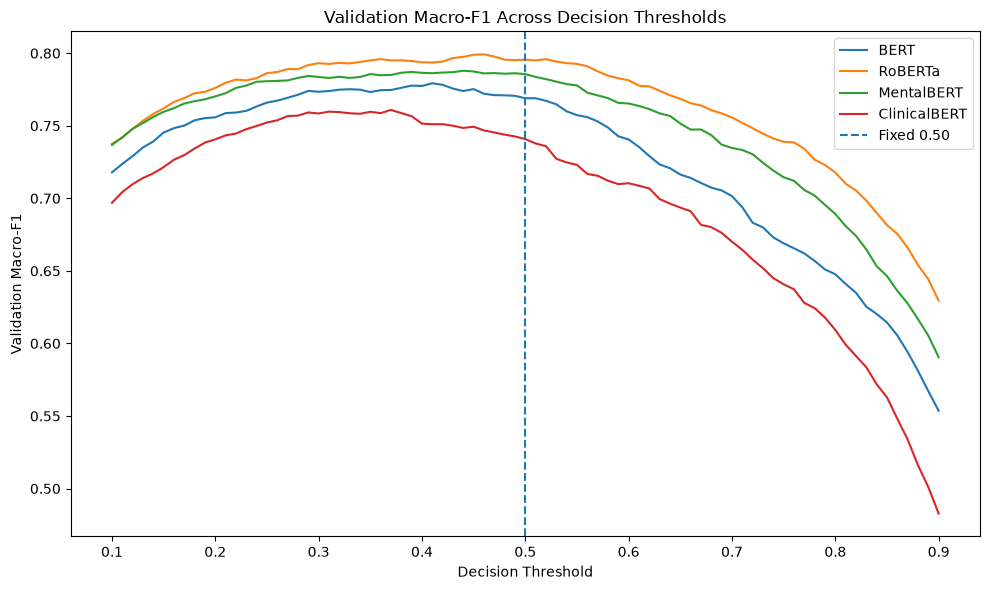

Saved: d:\Thesis_Project\Experiment_2_Transformer-Based Emotion_Classification\outputs\figures\validation_global_threshold_macro_f1.png


In [233]:
# ============================================================
# EXPERIMENT 2 — PHASE 9 — CELL 17
# GLOBAL THRESHOLD CURVES
# ============================================================

plt.figure(
    figsize=(10, 6)
)

for model_name in BASELINE_MODEL_ORDER:

    search_df = (
        global_threshold_search_tables[
            model_name
        ]
    )

    plt.plot(
        search_df[
            "Threshold"
        ],
        search_df[
            "Macro_F1"
        ],
        label=model_name
    )

plt.axvline(
    0.50,
    linestyle="--",
    label="Fixed 0.50"
)

plt.xlabel(
    "Decision Threshold"
)

plt.ylabel(
    "Validation Macro-F1"
)

plt.title(
    "Validation Macro-F1 Across Decision Thresholds"
)

plt.legend()

plt.tight_layout()

THRESHOLD_FIGURE_PATH = (
    FIGURE_DIR
    / "validation_global_threshold_macro_f1.png"
)

plt.savefig(
    THRESHOLD_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Saved:",
    THRESHOLD_FIGURE_PATH
)

In [234]:
# ============================================================
# EXPERIMENT 2 — PHASE 9 — CELL 18
# BEST VALIDATION THRESHOLD STRATEGY
# ============================================================

best_strategy_rows = []

for model_name in BASELINE_MODEL_ORDER:

    model_df = (
        threshold_comparison_df[
            threshold_comparison_df[
                "Model"
            ] == model_name
        ]
        .copy()
    )

    max_macro = (
        model_df[
            "Macro_F1"
        ].max()
    )

    best_candidates = (
        model_df[
            np.isclose(
                model_df[
                    "Macro_F1"
                ],
                max_macro
            )
        ]
        .copy()
    )

    # Prefer simpler threshold strategy in a tie.
    strategy_priority = {
        "Fixed_0.50": 1,
        "Global_Optimized": 2,
        "Per_Label_Optimized": 3
    }

    best_candidates[
        "Complexity"
    ] = (
        best_candidates[
            "Strategy"
        ]
        .map(
            strategy_priority
        )
    )

    selected = (
        best_candidates
        .sort_values(
            "Complexity"
        )
        .iloc[0]
    )

    best_strategy_rows.append(
        {
            "Model":
                model_name,

            "Development_Strategy":
                selected[
                    "Strategy"
                ],

            "Validation_Macro_F1":
                selected[
                    "Macro_F1"
                ],

            "Validation_Micro_F1":
                selected[
                    "Micro_F1"
                ],

            "Validation_Hamming_Loss":
                selected[
                    "Hamming_Loss"
                ]
        }
    )


best_threshold_strategy_df = (
    pd.DataFrame(
        best_strategy_rows
    )
)

display(
    best_threshold_strategy_df
)

,Model,Development_Strategy,Validation_Macro_F1,Validation_Micro_F1,Validation_Hamming_Loss
0,BERT,Per_Label_Optimized,0.784089,0.821520,0.173013
1,RoBERTa,Per_Label_Optimized,0.801506,0.838292,0.155215
2,MentalBERT,Per_Label_Optimized,0.793643,0.832325,0.160596
3,ClinicalBERT,Per_Label_Optimized,0.768647,0.807171,0.188466


In [235]:
# ============================================================
# EXPERIMENT 2 — PHASE 9 — CELL 19
# SAVE DEVELOPMENT THRESHOLD STRATEGIES
# ============================================================

BEST_THRESHOLD_STRATEGY_PATH = (
    THRESHOLD_DIR
    / "development_threshold_strategy.csv"
)

best_threshold_strategy_df.to_csv(
    BEST_THRESHOLD_STRATEGY_PATH,
    index=False
)

print(
    "Saved:",
    BEST_THRESHOLD_STRATEGY_PATH
)

Saved: d:\Thesis_Project\Experiment_2_Transformer-Based Emotion_Classification\outputs\metrics\threshold_optimization\development_threshold_strategy.csv


In [236]:
# ============================================================
# EXPERIMENT 2 — PHASE 9 — CELL 20
# FINAL PHASE 9 VERIFICATION
# ============================================================

phase9_checks = {

    "Four models loaded":
        len(
            validation_predictions
        ) == 4,

    "Validation samples = 906":
        all(
            len(df) == 906
            for df
            in validation_predictions.values()
        ),

    "Ground truth identical":
        ground_truth_check_df[
            "Identical_Targets"
        ].all(),

    "Four global thresholds":
        len(
            global_threshold_results
        ) == 4,

    "Four per-label threshold sets":
        len(
            per_label_threshold_results
        ) == 4,

    "Each model has 8 label thresholds":
        all(
            len(
                per_label_threshold_results[
                    model_name
                ]
            ) == 8

            for model_name
            in BASELINE_MODEL_ORDER
        ),

    "Thresholds within valid range":
        all(
            np.all(
                (
                    per_label_threshold_results[
                        model_name
                    ] >= 0.10
                )
                &
                (
                    per_label_threshold_results[
                        model_name
                    ] <= 0.90
                )
            )

            for model_name
            in BASELINE_MODEL_ORDER
        ),

    "Test set remains unused":
        True
}


print("=" * 80)
print("PHASE 9 — FINAL VERIFICATION")
print("=" * 80)

phase9_passed = True

for check_name, status in (
    phase9_checks.items()
):

    print(
        f"{check_name:<48}: "
        f"{'PASS' if status else 'FAIL'}"
    )

    if not status:
        phase9_passed = False

print("=" * 80)

if phase9_passed:

    print(
        "PHASE 9 STATUS: PASSED"
    )

    print(
        "Validation-only threshold optimization completed."
    )

    print(
        "The test set remains locked."
    )

else:

    print(
        "PHASE 9 STATUS: REVIEW REQUIRED"
    )

print("=" * 80)

PHASE 9 — FINAL VERIFICATION
Four models loaded                              : PASS
Validation samples = 906                        : PASS
Ground truth identical                          : PASS
Four global thresholds                          : PASS
Four per-label threshold sets                   : PASS
Each model has 8 label thresholds               : PASS
Thresholds within valid range                   : PASS
Test set remains unused                         : PASS
PHASE 9 STATUS: PASSED
Validation-only threshold optimization completed.
The test set remains locked.


# PHASE 10 — 3-Fold Multilabel-Stratified Cross-Validation

## Objective

This phase evaluates the robustness and stability of the four transformer models using 3-fold multilabel-stratified cross-validation on the development data only.

The development pool consists of:

- Final training set: 4,215 samples
- Final validation set: 906 samples
- Total development samples: 5,121

The locked test set of 906 samples is not included in cross-validation.

## Models

1. BERT
2. RoBERTa
3. MentalBERT
4. ClinicalBERT

## Cross-Validation Strategy

A 3-fold Multilabel Stratified K-Fold procedure is used so that the prevalence of the eight emotion labels remains approximately balanced across folds.

The same fold assignments are used for all four transformer models.

For each fold:

- Two folds are used for training.
- One fold is used as the development validation fold.
- Training is performed from a fresh pretrained checkpoint.
- Early stopping is based on Macro-F1.
- The best epoch is retained for that fold.
- Predictions are generated only for samples not used for training in that fold.

After all three folds, every development sample has one out-of-fold prediction.

## Controlled Conditions

- Maximum sequence length: 256
- Training batch size: 16
- Evaluation batch size: 32
- Learning rate: 2e-5
- Weight decay: 0.01
- Maximum epochs: 5
- Early-stopping patience: 2
- Warm-up ratio: 0.10
- Gradient clipping: 1.0
- Decision threshold: 0.50
- Primary metric: Macro-F1

## Important Threshold Rule

Thresholds optimized in Phase 9 are not used during cross-validation.

Phase 9 thresholds were optimized using the original validation split. Reusing those thresholds during cross-validation could introduce development-data leakage.

Therefore, a pre-specified fixed threshold of 0.50 is used for all models and all folds.

## Test-Set Isolation

The test set is completely excluded from:

- fold construction,
- model training,
- early stopping,
- threshold selection,
- model comparison,
- and cross-validation metrics.

The cross-validation results are development-stage estimates of model stability.

Final generalization performance will be measured later using the locked test set.

In [237]:
# ============================================================
# EXPERIMENT 2 — PHASE 10 — CELL 1
# CROSS-VALIDATION CONFIGURATION
# ============================================================

CV_N_SPLITS = 3
CV_SEED = SEED

CV_THRESHOLD = 0.50

CV_MAX_EPOCHS = MAX_EPOCHS
CV_PATIENCE = EARLY_STOPPING_PATIENCE

CV_MODEL_ORDER = [
    "BERT",
    "RoBERTa",
    "MentalBERT",
    "ClinicalBERT"
]

print("=" * 78)
print("3-FOLD CROSS-VALIDATION CONFIGURATION")
print("=" * 78)

print("Number of folds          :", CV_N_SPLITS)
print("Cross-validation seed    :", CV_SEED)
print("Decision threshold       :", CV_THRESHOLD)
print("Maximum epochs           :", CV_MAX_EPOCHS)
print("Early-stopping patience  :", CV_PATIENCE)

print("\nModels:")

for model_name in CV_MODEL_ORDER:
    print("-", model_name)

print("\nTest set usage           : NONE / LOCKED")

print("=" * 78)

3-FOLD CROSS-VALIDATION CONFIGURATION
Number of folds          : 3
Cross-validation seed    : 42
Decision threshold       : 0.5
Maximum epochs           : 5
Early-stopping patience  : 2

Models:
- BERT
- RoBERTa
- MentalBERT
- ClinicalBERT

Test set usage           : NONE / LOCKED


In [238]:
# ============================================================
# EXPERIMENT 2 — PHASE 10 — CELL 2
# BUILD TRAIN + VALIDATION DEVELOPMENT POOL
# ============================================================

train_dev_part = (
    train_final_df
    .copy()
)

train_dev_part[
    "original_split"
] = "train"


val_dev_part = (
    val_final_df
    .copy()
)

val_dev_part[
    "original_split"
] = "validation"


dev_df = pd.concat(
    [
        train_dev_part,
        val_dev_part
    ],
    ignore_index=True
)


Y_dev = np.vstack(
    [
        Y_train,
        Y_val
    ]
)


DEV_TOTAL = len(
    dev_df
)


print("=" * 75)
print("DEVELOPMENT POOL")
print("=" * 75)

print(
    "Original Train      :",
    len(train_final_df)
)

print(
    "Original Validation :",
    len(val_final_df)
)

print(
    "Development Total   :",
    DEV_TOTAL
)

print(
    "Target matrix       :",
    Y_dev.shape
)

print(
    "Locked Test         :",
    len(test_final_df)
)

print("=" * 75)


assert DEV_TOTAL == 5121

assert Y_dev.shape == (
    5121,
    NUM_LABELS
)

assert (
    dev_df["id"].nunique()
    == len(dev_df)
)

print(
    "Development-pool integrity: PASSED"
)

DEVELOPMENT POOL
Original Train      : 4215
Original Validation : 906
Development Total   : 5121
Target matrix       : (5121, 8)
Locked Test         : 906
Development-pool integrity: PASSED


In [239]:
# ============================================================
# EXPERIMENT 2 — PHASE 10 — CELL 3
# MULTILABEL-STRATIFIED FOLD GENERATION
# ============================================================

from iterstrat.ml_stratifiers import (
    MultilabelStratifiedKFold
)


cv_splitter = MultilabelStratifiedKFold(
    n_splits=CV_N_SPLITS,
    shuffle=True,
    random_state=CV_SEED
)


dummy_X = np.zeros(
    (
        DEV_TOTAL,
        1
    )
)


CV_SPLITS = list(
    cv_splitter.split(
        dummy_X,
        Y_dev
    )
)


print("=" * 75)
print("CROSS-VALIDATION FOLDS")
print("=" * 75)

for fold_number, (
    train_indices,
    val_indices
) in enumerate(
    CV_SPLITS,
    start=1
):

    print(
        f"Fold {fold_number}: "
        f"Train = {len(train_indices)}, "
        f"Validation = {len(val_indices)}"
    )

print("=" * 75)

CROSS-VALIDATION FOLDS
Fold 1: Train = 3400, Validation = 1721
Fold 2: Train = 3409, Validation = 1712
Fold 3: Train = 3433, Validation = 1688


In [240]:
# ============================================================
# EXPERIMENT 2 — PHASE 10 — CELL 4
# FOLD INTEGRITY CHECK
# ============================================================

fold_validation_counts = np.zeros(
    DEV_TOTAL,
    dtype=int
)

fold_integrity_rows = []

for fold_number, (
    train_indices,
    val_indices
) in enumerate(
    CV_SPLITS,
    start=1
):

    train_set = set(
        train_indices.tolist()
    )

    val_set = set(
        val_indices.tolist()
    )

    overlap = (
        train_set
        & val_set
    )

    fold_validation_counts[
        val_indices
    ] += 1

    fold_integrity_rows.append(
        {
            "Fold":
                fold_number,

            "Train":
                len(
                    train_indices
                ),

            "Validation":
                len(
                    val_indices
                ),

            "Overlap":
                len(
                    overlap
                )
        }
    )


fold_integrity_df = pd.DataFrame(
    fold_integrity_rows
)

display(
    fold_integrity_df
)


print(
    "Every sample appears exactly once "
    "as CV validation:",
    np.all(
        fold_validation_counts == 1
    )
)


assert (
    fold_integrity_df[
        "Overlap"
    ] == 0
).all()

assert np.all(
    fold_validation_counts == 1
)

print(
    "FOLD INTEGRITY: PASSED"
)

,Fold,Train,Validation,Overlap
0,1,3400,1721,0
1,2,3409,1712,0
2,3,3433,1688,0


Every sample appears exactly once as CV validation: True
FOLD INTEGRITY: PASSED


In [241]:
# ============================================================
# EXPERIMENT 2 — PHASE 10 — CELL 5
# CREATE FOLD MANIFEST
# ============================================================

fold_assignment = np.zeros(
    DEV_TOTAL,
    dtype=int
)

for fold_number, (
    _,
    val_indices
) in enumerate(
    CV_SPLITS,
    start=1
):

    fold_assignment[
        val_indices
    ] = fold_number


cv_fold_manifest_df = pd.DataFrame(
    {
        "id":
            dev_df[
                "id"
            ].astype(str),

        "original_split":
            dev_df[
                "original_split"
            ],

        "cv_fold":
            fold_assignment
    }
)


display(
    cv_fold_manifest_df.head()
)

print(
    "\nFold counts:"
)

display(
    cv_fold_manifest_df[
        "cv_fold"
    ]
    .value_counts()
    .sort_index()
    .rename_axis("Fold")
    .reset_index(name="Samples")
)

,id,original_split,cv_fold
0,hhcq6e,train,1
1,d0bobn,train,1
2,wy400i,train,3
3,crkjga,train,3
4,zq1lwl,train,1



Fold counts:


,Fold,Samples
0,1,1721
1,2,1712
2,3,1688


In [242]:
# ============================================================
# EXPERIMENT 2 — PHASE 10 — CELL 6
# FOLD LABEL DISTRIBUTION CHECK
# ============================================================

fold_distribution_rows = []

for fold_number, (
    _,
    val_indices
) in enumerate(
    CV_SPLITS,
    start=1
):

    fold_targets = (
        Y_dev[
            val_indices
        ]
    )

    for label_index, label in enumerate(
        MODEL_LABELS
    ):

        positives = int(
            fold_targets[
                :,
                label_index
            ].sum()
        )

        prevalence = (
            positives
            / len(
                val_indices
            )
            * 100
        )

        fold_distribution_rows.append(
            {
                "Fold":
                    fold_number,

                "Emotion":
                    label,

                "Positive":
                    positives,

                "Prevalence_%":
                    prevalence
            }
        )


cv_fold_distribution_df = pd.DataFrame(
    fold_distribution_rows
)

display(
    cv_fold_distribution_df
)

,Fold,Emotion,Positive,Prevalence_%
0,1,anger,699,40.615921
1,1,brain dysfunction (forget),325,18.884370
2,1,emptiness,642,37.303893
3,1,hopelessness,1185,68.855317
4,1,loneliness,791,45.961650
5,1,sadness,1321,76.757699
6,1,suicide intent,419,24.346310
7,1,worthlessness,851,49.447995
8,2,anger,700,40.887850
9,2,brain dysfunction (forget),325,18.983645


In [243]:
# ============================================================
# EXPERIMENT 2 — PHASE 10 — CELL 7
# SAVE CROSS-VALIDATION FOLD DEFINITION
# ============================================================

CV_MANIFEST_PATH = (
    CV_DIR
    / "cv_fold_manifest.csv"
)

CV_DISTRIBUTION_PATH = (
    CV_DIR
    / "cv_fold_label_distribution.csv"
)


cv_fold_manifest_df.to_csv(
    CV_MANIFEST_PATH,
    index=False
)

cv_fold_distribution_df.to_csv(
    CV_DISTRIBUTION_PATH,
    index=False
)


print("Saved:")
print(CV_MANIFEST_PATH)
print(CV_DISTRIBUTION_PATH)

Saved:
d:\Thesis_Project\Experiment_2_Transformer-Based Emotion_Classification\outputs\cross_validation\cv_fold_manifest.csv
d:\Thesis_Project\Experiment_2_Transformer-Based Emotion_Classification\outputs\cross_validation\cv_fold_label_distribution.csv


In [244]:
# ============================================================
# EXPERIMENT 2 — PHASE 10 — CELL 8
# CROSS-VALIDATION DATALOADER BUILDER
# ============================================================

def build_cv_dataloaders(
    train_dataframe,
    train_targets,
    val_dataframe,
    val_targets,
    tokenizer,
    seed
):

    train_dataset = (
        MultiLabelEmotionDataset(
            dataframe=train_dataframe,
            targets=train_targets,
            tokenizer=tokenizer,
            max_length=MAX_LENGTH
        )
    )

    val_dataset = (
        MultiLabelEmotionDataset(
            dataframe=val_dataframe,
            targets=val_targets,
            tokenizer=tokenizer,
            max_length=MAX_LENGTH
        )
    )

    collator = (
        MultiLabelDataCollator(
            tokenizer
        )
    )

    train_loader = DataLoader(

        train_dataset,

        batch_size=TRAIN_BATCH_SIZE,

        shuffle=True,

        collate_fn=collator,

        num_workers=NUM_WORKERS,

        pin_memory=PIN_MEMORY,

        worker_init_fn=seed_worker,

        generator=create_generator(
            seed
        )
    )

    val_loader = DataLoader(

        val_dataset,

        batch_size=EVAL_BATCH_SIZE,

        shuffle=False,

        collate_fn=collator,

        num_workers=NUM_WORKERS,

        pin_memory=PIN_MEMORY
    )

    return (
        train_dataset,
        val_dataset,
        train_loader,
        val_loader
    )


print(
    "Cross-validation DataLoader builder created."
)

Cross-validation DataLoader builder created.


In [245]:
# ============================================================
# EXPERIMENT 2 — PHASE 10 — CELL 9
# TRAIN ONE CROSS-VALIDATION FOLD
# ============================================================

def train_cv_fold(
    model_name,
    fold_number,
    train_indices,
    val_indices
):

    print("\n" + "=" * 82)
    print(
        f"{model_name} — CV FOLD {fold_number}/{CV_N_SPLITS}"
    )
    print("=" * 82)

    fold_seed = (
        CV_SEED
        + fold_number
    )

    reset_random_state(
        fold_seed
    )

    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    # --------------------------------------------------------
    # Fold data
    # --------------------------------------------------------

    fold_train_df = (
        dev_df
        .iloc[
            train_indices
        ]
        .reset_index(drop=True)
        .copy()
    )

    fold_val_df = (
        dev_df
        .iloc[
            val_indices
        ]
        .reset_index(drop=True)
        .copy()
    )

    fold_y_train = (
        Y_dev[
            train_indices
        ]
    )

    fold_y_val = (
        Y_dev[
            val_indices
        ]
    )

    tokenizer = (
        TOKENIZERS[
            model_name
        ]
    )

    (
        fold_train_dataset,
        fold_val_dataset,
        fold_train_loader,
        fold_val_loader
    ) = build_cv_dataloaders(

        train_dataframe=fold_train_df,

        train_targets=fold_y_train,

        val_dataframe=fold_val_df,

        val_targets=fold_y_val,

        tokenizer=tokenizer,

        seed=fold_seed
    )

    # --------------------------------------------------------
    # Fresh pretrained model
    # --------------------------------------------------------

    model = (
        create_multilabel_model(
            model_name
        )
        .to(
            DEVICE
        )
    )

    optimizer = (
        create_optimizer(
            model,
            learning_rate=LEARNING_RATE,
            weight_decay=WEIGHT_DECAY
        )
    )

    (
        scheduler,
        total_steps,
        warmup_steps
    ) = create_scheduler(

        optimizer,
        fold_train_loader,
        CV_MAX_EPOCHS,

        grad_accum_steps=(
            GRAD_ACCUM_STEPS
        ),

        warmup_ratio=(
            WARMUP_RATIO
        )
    )

    scaler = (
        create_grad_scaler()
    )

    print(
        "Fold training samples   :",
        len(
            fold_train_dataset
        )
    )

    print(
        "Fold validation samples :",
        len(
            fold_val_dataset
        )
    )

    print(
        "Training steps          :",
        total_steps
    )

    print(
        "Warm-up steps           :",
        warmup_steps
    )

    # --------------------------------------------------------
    # Training state
    # --------------------------------------------------------

    best_macro_f1 = (
        -np.inf
    )

    best_epoch = None

    best_result = None

    best_train_loss = None

    patience_counter = 0

    history = []

    # --------------------------------------------------------
    # Epoch loop
    # --------------------------------------------------------

    for epoch in range(
        1,
        CV_MAX_EPOCHS + 1
    ):

        print(
            f"\nFold {fold_number} "
            f"Epoch {epoch}/{CV_MAX_EPOCHS}"
        )

        train_loss = (
            train_one_epoch(

                model=model,

                train_loader=fold_train_loader,

                optimizer=optimizer,

                scheduler=scheduler,

                scaler=scaler,

                device=DEVICE
            )
        )

        validation_result = (
            evaluate_model(

                model=model,

                data_loader=fold_val_loader,

                device=DEVICE,

                threshold=CV_THRESHOLD
            )
        )

        metrics = (
            validation_result[
                "metrics"
            ]
        )

        history.append(
            {
                "fold":
                    fold_number,

                "epoch":
                    epoch,

                "train_loss":
                    train_loss,

                "val_loss":
                    metrics[
                        "loss"
                    ],

                "val_macro_f1":
                    metrics[
                        "macro_f1"
                    ],

                "val_micro_f1":
                    metrics[
                        "micro_f1"
                    ],

                "val_weighted_f1":
                    metrics[
                        "weighted_f1"
                    ],

                "val_hamming_loss":
                    metrics[
                        "hamming_loss"
                    ],

                "val_subset_accuracy":
                    metrics[
                        "subset_accuracy"
                    ]
            }
        )

        print(
            f"Train Loss : {train_loss:.4f}"
        )

        print(
            f"Val Loss   : "
            f"{metrics['loss']:.4f}"
        )

        print(
            f"Macro-F1   : "
            f"{metrics['macro_f1']:.4f}"
        )

        print(
            f"Micro-F1   : "
            f"{metrics['micro_f1']:.4f}"
        )

        print(
            f"Hamming    : "
            f"{metrics['hamming_loss']:.4f}"
        )

        current_macro_f1 = (
            metrics[
                "macro_f1"
            ]
        )

        if (
            current_macro_f1
            >
            best_macro_f1
            + EARLY_STOPPING_MIN_DELTA
        ):

            best_macro_f1 = (
                current_macro_f1
            )

            best_epoch = (
                epoch
            )

            best_train_loss = (
                train_loss
            )

            best_result = (
                validation_result
            )

            patience_counter = 0

            print(
                "New best fold epoch."
            )

        else:

            patience_counter += 1

            print(
                f"No improvement. "
                f"Patience "
                f"{patience_counter}/{CV_PATIENCE}"
            )

        if (
            patience_counter
            >= CV_PATIENCE
        ):

            print(
                "Fold early stopping triggered."
            )

            break

    # --------------------------------------------------------
    # Save fold history
    # --------------------------------------------------------

    safe_model_name = (
        model_name
        .lower()
        .replace(
            " ",
            "_"
        )
    )

    fold_dir = (
        CV_DIR
        / safe_model_name
        / f"fold_{fold_number}"
    )

    fold_dir.mkdir(
        parents=True,
        exist_ok=True
    )

    history_df = pd.DataFrame(
        history
    )

    history_df.to_csv(
        fold_dir
        / "training_history.csv",
        index=False
    )

    # --------------------------------------------------------
    # Save best fold predictions
    # --------------------------------------------------------

    fold_prediction_df = (
        build_prediction_table(

            best_result[
                "sample_ids"
            ],

            best_result[
                "labels"
            ],

            best_result[
                "probabilities"
            ],

            best_result[
                "predictions"
            ]
        )
    )

    fold_prediction_df[
        "fold"
    ] = fold_number

    fold_prediction_df[
        "best_epoch"
    ] = best_epoch

    fold_prediction_path = (
        fold_dir
        / "fold_validation_predictions.csv"
    )

    fold_prediction_df.to_csv(
        fold_prediction_path,
        index=False
    )

    # --------------------------------------------------------
    # Fold result
    # --------------------------------------------------------

    best_metrics = (
        best_result[
            "metrics"
        ]
    )

    fold_result = {

        "Model":
            model_name,

        "Fold":
            fold_number,

        "Fold_Seed":
            fold_seed,

        "Train_Samples":
            len(
                fold_train_dataset
            ),

        "Validation_Samples":
            len(
                fold_val_dataset
            ),

        "Best_Epoch":
            best_epoch,

        "Train_Loss":
            best_train_loss,

        "Val_Loss":
            best_metrics[
                "loss"
            ],

        "Macro_F1":
            best_metrics[
                "macro_f1"
            ],

        "Micro_F1":
            best_metrics[
                "micro_f1"
            ],

        "Weighted_F1":
            best_metrics[
                "weighted_f1"
            ],

        "Hamming_Loss":
            best_metrics[
                "hamming_loss"
            ],

        "Subset_Accuracy":
            best_metrics[
                "subset_accuracy"
            ],

        "Prediction_Path":
            str(
                fold_prediction_path
            )
    }

    print("\nBest epoch:", best_epoch)

    print(
        "Best Macro-F1:",
        round(
            best_metrics[
                "macro_f1"
            ],
            6
        )
    )

    # --------------------------------------------------------
    # Memory cleanup
    # --------------------------------------------------------

    del model
    del optimizer
    del scheduler
    del scaler

    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return (
        fold_result,
        fold_prediction_df
    )

In [246]:
# ============================================================
# EXPERIMENT 2 — PHASE 10 — CELL 10
# RUN 3-FOLD CV FOR ONE MODEL
# ============================================================

def run_model_cross_validation(
    model_name
):

    print("\n" + "#" * 84)
    print(
        f"STARTING 3-FOLD CV: {model_name}"
    )
    print("#" * 84)

    fold_results = []
    fold_predictions = []

    for fold_number, (
        train_indices,
        val_indices
    ) in enumerate(
        CV_SPLITS,
        start=1
    ):

        (
            fold_result,
            fold_prediction_df
        ) = train_cv_fold(

            model_name=model_name,

            fold_number=fold_number,

            train_indices=train_indices,

            val_indices=val_indices
        )

        fold_results.append(
            fold_result
        )

        fold_predictions.append(
            fold_prediction_df
        )

    # --------------------------------------------------------
    # Fold result table
    # --------------------------------------------------------

    fold_results_df = pd.DataFrame(
        fold_results
    )

    # --------------------------------------------------------
    # Out-of-fold predictions
    # --------------------------------------------------------

    oof_df = pd.concat(
        fold_predictions,
        ignore_index=True
    )

    assert len(
        oof_df
    ) == DEV_TOTAL

    assert (
        oof_df[
            "id"
        ].nunique()
        == DEV_TOTAL
    )

    # --------------------------------------------------------
    # Calculate overall OOF metrics
    # --------------------------------------------------------

    oof_y_true = np.column_stack(
        [
            oof_df[
                f"true__{label}"
            ].values
            for label
            in MODEL_LABELS
        ]
    ).astype(int)

    oof_probabilities = np.column_stack(
        [
            oof_df[
                f"prob__{label}"
            ].values
            for label
            in MODEL_LABELS
        ]
    ).astype(float)

    (
        oof_metrics,
        _
    ) = compute_multilabel_metrics(

        oof_y_true,

        oof_probabilities,

        threshold=CV_THRESHOLD
    )

    # --------------------------------------------------------
    # Save model CV files
    # --------------------------------------------------------

    safe_model_name = (
        model_name
        .lower()
        .replace(
            " ",
            "_"
        )
    )

    model_cv_dir = (
        CV_DIR
        / safe_model_name
    )

    model_cv_dir.mkdir(
        parents=True,
        exist_ok=True
    )

    fold_results_df.to_csv(
        model_cv_dir
        / "fold_results.csv",
        index=False
    )

    oof_df.to_csv(
        model_cv_dir
        / "oof_predictions.csv",
        index=False
    )

    # --------------------------------------------------------
    # Summary
    # --------------------------------------------------------

    summary = {

        "Model":
            model_name,

        "Folds":
            CV_N_SPLITS,

        "Mean_Macro_F1":
            fold_results_df[
                "Macro_F1"
            ].mean(),

        "Std_Macro_F1":
            fold_results_df[
                "Macro_F1"
            ].std(
                ddof=1
            ),

        "Mean_Micro_F1":
            fold_results_df[
                "Micro_F1"
            ].mean(),

        "Std_Micro_F1":
            fold_results_df[
                "Micro_F1"
            ].std(
                ddof=1
            ),

        "Mean_Weighted_F1":
            fold_results_df[
                "Weighted_F1"
            ].mean(),

        "Std_Weighted_F1":
            fold_results_df[
                "Weighted_F1"
            ].std(
                ddof=1
            ),

        "Mean_Hamming_Loss":
            fold_results_df[
                "Hamming_Loss"
            ].mean(),

        "Std_Hamming_Loss":
            fold_results_df[
                "Hamming_Loss"
            ].std(
                ddof=1
            ),

        "OOF_Macro_F1":
            oof_metrics[
                "macro_f1"
            ],

        "OOF_Micro_F1":
            oof_metrics[
                "micro_f1"
            ],

        "OOF_Weighted_F1":
            oof_metrics[
                "weighted_f1"
            ],

        "OOF_Hamming_Loss":
            oof_metrics[
                "hamming_loss"
            ],

        "OOF_Subset_Accuracy":
            oof_metrics[
                "subset_accuracy"
            ]
    }

    print("\n" + "=" * 82)
    print(
        f"{model_name} — 3-FOLD CV COMPLETED"
    )
    print("=" * 82)

    print(
        "Macro-F1 mean ± SD : "
        f"{summary['Mean_Macro_F1']:.6f} "
        f"± {summary['Std_Macro_F1']:.6f}"
    )

    print(
        "Micro-F1 mean ± SD : "
        f"{summary['Mean_Micro_F1']:.6f} "
        f"± {summary['Std_Micro_F1']:.6f}"
    )

    print(
        "OOF Macro-F1       :",
        round(
            summary[
                "OOF_Macro_F1"
            ],
            6
        )
    )

    print(
        "OOF Micro-F1       :",
        round(
            summary[
                "OOF_Micro_F1"
            ],
            6
        )
    )

    print("=" * 82)

    return {
        "fold_results":
            fold_results_df,

        "oof_predictions":
            oof_df,

        "summary":
            summary
    }

In [247]:
# ============================================================
# EXPERIMENT 2 — PHASE 10 — CELL 11
# INITIALIZE MODEL CV RESULTS
# ============================================================

cv_model_results = {}

print(
    "Cross-validation result container initialized."
)

Cross-validation result container initialized.


In [248]:
# ============================================================
# EXPERIMENT 2 — PHASE 10 — CELL 12
# BERT — 3-FOLD CV
# ============================================================

cv_model_results[
    "BERT"
] = run_model_cross_validation(
    "BERT"
)


####################################################################################
STARTING 3-FOLD CV: BERT
####################################################################################

BERT — CV FOLD 1/3


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Fold training samples   : 3400
Fold validation samples : 1721
Training steps          : 1065
Warm-up steps           : 106

Fold 1 Epoch 1/5


Training:   0%|          | 0/213 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/53 [00:00<?, ?it/s]

Train Loss : 0.2925
Val Loss   : 0.3825
Macro-F1   : 0.7396
Micro-F1   : 0.8055
Hamming    : 0.1706
New best fold epoch.

Fold 3 Epoch 5/5


Training:   0%|          | 0/215 [00:00<?, ?it/s]

Validation:   0%|          | 0/53 [00:00<?, ?it/s]

Train Loss : 0.2662
Val Loss   : 0.3772
Macro-F1   : 0.7602
Micro-F1   : 0.8175
Hamming    : 0.1654
New best fold epoch.

Best epoch: 5
Best Macro-F1: 0.760227

BERT — 3-FOLD CV COMPLETED
Macro-F1 mean ± SD : 0.756661 ± 0.005629
Micro-F1 mean ± SD : 0.817139 ± 0.001539
OOF Macro-F1       : 0.756954
OOF Micro-F1       : 0.817148


In [249]:
# ============================================================
# EXPERIMENT 2 — PHASE 10 — CELL 13
# BERT CV RESULT
# ============================================================

display(
    cv_model_results[
        "BERT"
    ][
        "fold_results"
    ]
)

print()

print(
    cv_model_results[
        "BERT"
    ][
        "summary"
    ]
)

,Model,Fold,Fold_Seed,Train_Samples,Validation_Samples,Best_Epoch,Train_Loss,Val_Loss,Macro_F1,Micro_F1,Weighted_F1,Hamming_Loss,Subset_Accuracy,Prediction_Path
0,BERT,1,43,3400,1721,5,0.287786,0.376216,0.750172,0.815457,0.803010,0.165456,0.240558,d:\Thesis_Project\Experiment_2_Transformer-Based Emotion_Classification\outputs\cross_validation\bert\fold_1\fold_validation_predictions.csv
1,BERT,2,44,3409,1712,5,0.264774,0.382990,0.759583,0.818477,0.809231,0.167275,0.248248,d:\Thesis_Project\Experiment_2_Transformer-Based Emotion_Classification\outputs\cross_validation\bert\fold_2\fold_validation_predictions.csv
2,BERT,3,45,3433,1688,5,0.266221,0.377195,0.760227,0.817484,0.808325,0.165432,0.263033,d:\Thesis_Project\Experiment_2_Transformer-Based Emotion_Classification\outputs\cross_validation\bert\fold_3\fold_validation_predictions.csv



{'Model': 'BERT', 'Folds': 3, 'Mean_Macro_F1': np.float64(0.7566610490256105), 'Std_Macro_F1': np.float64(0.005628668226668288), 'Mean_Micro_F1': np.float64(0.8171392345139642), 'Std_Micro_F1': np.float64(0.001539296222443637), 'Mean_Weighted_F1': np.float64(0.8068555447620515), 'Std_Weighted_F1': np.float64(0.003360937973812019), 'Mean_Hamming_Loss': np.float64(0.16605457047809724), 'Std_Hamming_Loss': np.float64(0.0010570903700060686), 'OOF_Macro_F1': 0.7569538001860072, 'OOF_Micro_F1': 0.8171482327644134, 'OOF_Weighted_F1': 0.8070090543037619, 'OOF_Hamming_Loss': 0.1660564342901777, 'OOF_Subset_Accuracy': 0.2505370044913103}


In [250]:
# ============================================================
# EXPERIMENT 2 — PHASE 10 — CELL 14
# ROBERTA — 3-FOLD CV
# ============================================================

cv_model_results[
    "RoBERTa"
] = run_model_cross_validation(
    "RoBERTa"
)


####################################################################################
STARTING 3-FOLD CV: RoBERTa
####################################################################################

RoBERTa — CV FOLD 1/3


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
classifier.out_proj.weight | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.dense.weight    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Fold training samples   : 3400
Fold validation samples : 1721
Training steps          : 1065
Warm-up steps           : 106

Fold 1 Epoch 1/5


Training:   0%|          | 0/213 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/53 [00:00<?, ?it/s]

Train Loss : 0.2708
Val Loss   : 0.3558
Macro-F1   : 0.7804
Micro-F1   : 0.8304
Hamming    : 0.1538
New best fold epoch.

Fold 3 Epoch 5/5


Training:   0%|          | 0/215 [00:00<?, ?it/s]

Validation:   0%|          | 0/53 [00:00<?, ?it/s]

Train Loss : 0.2419
Val Loss   : 0.3575
Macro-F1   : 0.7867
Micro-F1   : 0.8321
Hamming    : 0.1560
New best fold epoch.

Best epoch: 5
Best Macro-F1: 0.786651

RoBERTa — 3-FOLD CV COMPLETED
Macro-F1 mean ± SD : 0.785129 ± 0.006409
Micro-F1 mean ± SD : 0.831909 ± 0.003846
OOF Macro-F1       : 0.785104
OOF Micro-F1       : 0.83189


In [251]:
# ============================================================
# EXPERIMENT 2 — PHASE 10 — CELL 15
# MENTALBERT — 3-FOLD CV
# ============================================================

cv_model_results[
    "MentalBERT"
] = run_model_cross_validation(
    "MentalBERT"
)


####################################################################################
STARTING 3-FOLD CV: MentalBERT
####################################################################################

MentalBERT — CV FOLD 1/3


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: mental/mental-bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
bert.pooler.dense.weight                   | MISSING    | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 
bert.pooler.dense.bias                     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those 

Fold training samples   : 3400
Fold validation samples : 1721
Training steps          : 1065
Warm-up steps           : 106

Fold 1 Epoch 1/5


Training:   0%|          | 0/213 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/53 [00:00<?, ?it/s]

Train Loss : 0.2781
Val Loss   : 0.3766
Macro-F1   : 0.7432
Micro-F1   : 0.8098
Hamming    : 0.1688
New best fold epoch.

Fold 3 Epoch 5/5


Training:   0%|          | 0/215 [00:00<?, ?it/s]

Validation:   0%|          | 0/53 [00:00<?, ?it/s]

Train Loss : 0.2523
Val Loss   : 0.3729
Macro-F1   : 0.7605
Micro-F1   : 0.8178
Hamming    : 0.1659
New best fold epoch.

Best epoch: 5
Best Macro-F1: 0.76053

MentalBERT — 3-FOLD CV COMPLETED
Macro-F1 mean ± SD : 0.765456 ± 0.005104
Micro-F1 mean ± SD : 0.819313 ± 0.002003
OOF Macro-F1       : 0.765607
OOF Micro-F1       : 0.819334


In [252]:
# ============================================================
# EXPERIMENT 2 — PHASE 10 — CELL 16
# CLINICALBERT — 3-FOLD CV
# ============================================================

cv_model_results[
    "ClinicalBERT"
] = run_model_cross_validation(
    "ClinicalBERT"
)


####################################################################################
STARTING 3-FOLD CV: ClinicalBERT
####################################################################################

ClinicalBERT — CV FOLD 1/3


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: emilyalsentzer/Bio_ClinicalBERT
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the chec

Fold training samples   : 3400
Fold validation samples : 1721
Training steps          : 1065
Warm-up steps           : 106

Fold 1 Epoch 1/5


Training:   0%|          | 0/213 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/53 [00:00<?, ?it/s]

Train Loss : 0.3646
Val Loss   : 0.4406
Macro-F1   : 0.6855
Micro-F1   : 0.7685
Hamming    : 0.2004
New best fold epoch.

Fold 3 Epoch 5/5


Training:   0%|          | 0/215 [00:00<?, ?it/s]

Validation:   0%|          | 0/53 [00:00<?, ?it/s]

Train Loss : 0.3333
Val Loss   : 0.4332
Macro-F1   : 0.7007
Micro-F1   : 0.7762
Hamming    : 0.2007
New best fold epoch.

Best epoch: 5
Best Macro-F1: 0.700671

ClinicalBERT — 3-FOLD CV COMPLETED
Macro-F1 mean ± SD : 0.714702 ± 0.012396
Micro-F1 mean ± SD : 0.784670 ± 0.007385
OOF Macro-F1       : 0.71505
OOF Micro-F1       : 0.78476


In [253]:
# ============================================================
# EXPERIMENT 2 — PHASE 10 — CELL 17
# FOUR-MODEL CV COMPARISON
# ============================================================

cv_summary_rows = []

for model_name in CV_MODEL_ORDER:

    cv_summary_rows.append(
        cv_model_results[
            model_name
        ][
            "summary"
        ]
    )


cv_comparison_df = pd.DataFrame(
    cv_summary_rows
)


display(
    cv_comparison_df
)

,Model,Folds,Mean_Macro_F1,Std_Macro_F1,Mean_Micro_F1,Std_Micro_F1,Mean_Weighted_F1,Std_Weighted_F1,Mean_Hamming_Loss,Std_Hamming_Loss,OOF_Macro_F1,OOF_Micro_F1,OOF_Weighted_F1,OOF_Hamming_Loss,OOF_Subset_Accuracy
0,BERT,3,0.756661,0.005629,0.817139,0.001539,0.806856,0.003361,0.166055,0.001057,0.756954,0.817148,0.807009,0.166056,0.250537
1,RoBERTa,3,0.785129,0.006409,0.831909,0.003846,0.825878,0.004442,0.155450,0.005086,0.785104,0.831890,0.825847,0.155438,0.283929
2,MentalBERT,3,0.765456,0.005104,0.819313,0.002003,0.810652,0.003347,0.163243,0.003075,0.765607,0.819334,0.810740,0.163225,0.260887
3,ClinicalBERT,3,0.714702,0.012396,0.784670,0.007385,0.770565,0.008754,0.195163,0.005283,0.715050,0.784760,0.770784,0.195128,0.198008


In [254]:
# ============================================================
# EXPERIMENT 2 — PHASE 10 — CELL 18
# JOURNAL-STYLE CV SUMMARY
# ============================================================

cv_journal_table_df = pd.DataFrame(
    {
        "Model":
            cv_comparison_df[
                "Model"
            ],

        "Macro_F1_Mean":
            cv_comparison_df[
                "Mean_Macro_F1"
            ],

        "Macro_F1_SD":
            cv_comparison_df[
                "Std_Macro_F1"
            ],

        "Micro_F1_Mean":
            cv_comparison_df[
                "Mean_Micro_F1"
            ],

        "Micro_F1_SD":
            cv_comparison_df[
                "Std_Micro_F1"
            ],

        "Weighted_F1_Mean":
            cv_comparison_df[
                "Mean_Weighted_F1"
            ],

        "Hamming_Loss_Mean":
            cv_comparison_df[
                "Mean_Hamming_Loss"
            ],

        "OOF_Macro_F1":
            cv_comparison_df[
                "OOF_Macro_F1"
            ],

        "OOF_Micro_F1":
            cv_comparison_df[
                "OOF_Micro_F1"
            ]
    }
)


display(
    cv_journal_table_df
)

,Model,Macro_F1_Mean,Macro_F1_SD,Micro_F1_Mean,Micro_F1_SD,Weighted_F1_Mean,Hamming_Loss_Mean,OOF_Macro_F1,OOF_Micro_F1
0,BERT,0.756661,0.005629,0.817139,0.001539,0.806856,0.166055,0.756954,0.817148
1,RoBERTa,0.785129,0.006409,0.831909,0.003846,0.825878,0.155450,0.785104,0.831890
2,MentalBERT,0.765456,0.005104,0.819313,0.002003,0.810652,0.163243,0.765607,0.819334
3,ClinicalBERT,0.714702,0.012396,0.784670,0.007385,0.770565,0.195163,0.715050,0.784760


In [255]:
# ============================================================
# EXPERIMENT 2 — PHASE 10 — CELL 19
# PER-LABEL OUT-OF-FOLD F1
# ============================================================

per_label_cv_rows = []

for model_name in CV_MODEL_ORDER:

    oof_df = (
        cv_model_results[
            model_name
        ][
            "oof_predictions"
        ]
    )

    for label in MODEL_LABELS:

        y_true_label = (
            oof_df[
                f"true__{label}"
            ]
            .values
            .astype(int)
        )

        y_pred_label = (
            oof_df[
                f"pred__{label}"
            ]
            .values
            .astype(int)
        )

        label_f1 = f1_score(
            y_true_label,
            y_pred_label,
            zero_division=0
        )

        per_label_cv_rows.append(
            {
                "Model":
                    model_name,

                "Emotion":
                    label,

                "OOF_F1":
                    label_f1
            }
        )


per_label_cv_df = pd.DataFrame(
    per_label_cv_rows
)


display(
    per_label_cv_df
)

,Model,Emotion,OOF_F1
0,BERT,anger,0.777277
1,BERT,brain dysfunction (forget),0.309579
2,BERT,emptiness,0.773127
3,BERT,hopelessness,0.874915
4,BERT,loneliness,0.839786
5,BERT,sadness,0.892418
6,BERT,suicide intent,0.791531
7,BERT,worthlessness,0.796998
8,RoBERTa,anger,0.799317
9,RoBERTa,brain dysfunction (forget),0.427119


In [256]:
# ============================================================
# EXPERIMENT 2 — PHASE 10 — CELL 20
# SAVE CROSS-VALIDATION RESULTS
# ============================================================

CV_COMPARISON_PATH = (
    CV_DIR
    / "four_model_cv_comparison.csv"
)

CV_JOURNAL_PATH = (
    CV_DIR
    / "journal_style_cv_summary.csv"
)

CV_PER_LABEL_PATH = (
    CV_DIR
    / "per_label_oof_f1.csv"
)


cv_comparison_df.to_csv(
    CV_COMPARISON_PATH,
    index=False
)

cv_journal_table_df.to_csv(
    CV_JOURNAL_PATH,
    index=False
)

per_label_cv_df.to_csv(
    CV_PER_LABEL_PATH,
    index=False
)


print("Saved:")
print(CV_COMPARISON_PATH)
print(CV_JOURNAL_PATH)
print(CV_PER_LABEL_PATH)

Saved:
d:\Thesis_Project\Experiment_2_Transformer-Based Emotion_Classification\outputs\cross_validation\four_model_cv_comparison.csv
d:\Thesis_Project\Experiment_2_Transformer-Based Emotion_Classification\outputs\cross_validation\journal_style_cv_summary.csv
d:\Thesis_Project\Experiment_2_Transformer-Based Emotion_Classification\outputs\cross_validation\per_label_oof_f1.csv


In [257]:
# ============================================================
# EXPERIMENT 2 — PHASE 10 — CELL 21
# SAVE CROSS-VALIDATION CONFIGURATION
# ============================================================

cv_configuration = {

    "development_samples":
        DEV_TOTAL,

    "original_training_samples":
        len(
            train_final_df
        ),

    "original_validation_samples":
        len(
            val_final_df
        ),

    "locked_test_samples":
        len(
            test_final_df
        ),

    "number_of_folds":
        CV_N_SPLITS,

    "splitter":
        "MultilabelStratifiedKFold",

    "shuffle":
        True,

    "seed":
        CV_SEED,

    "models":
        CV_MODEL_ORDER,

    "threshold":
        CV_THRESHOLD,

    "threshold_source":
        "pre-specified fixed threshold",

    "phase9_thresholds_used":
        False,

    "max_length":
        MAX_LENGTH,

    "learning_rate":
        LEARNING_RATE,

    "weight_decay":
        WEIGHT_DECAY,

    "maximum_epochs":
        CV_MAX_EPOCHS,

    "early_stopping_patience":
        CV_PATIENCE,

    "primary_metric":
        "Macro-F1",

    "test_used":
        False
}


CV_CONFIG_PATH = (
    CV_DIR
    / "cross_validation_config.json"
)


with open(
    CV_CONFIG_PATH,
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        cv_configuration,
        file,
        indent=4
    )


print(
    "Saved:",
    CV_CONFIG_PATH
)

Saved: d:\Thesis_Project\Experiment_2_Transformer-Based Emotion_Classification\outputs\cross_validation\cross_validation_config.json


In [258]:
# ============================================================
# EXPERIMENT 2 — PHASE 10 — CELL 22
# FINAL PHASE 10 VERIFICATION
# ============================================================

phase10_checks = {

    "Development samples = 5121":
        DEV_TOTAL == 5121,

    "CV folds = 3":
        len(
            CV_SPLITS
        ) == 3,

    "Every development sample validated once":
        np.all(
            fold_validation_counts == 1
        ),

    "Four models completed":
        len(
            cv_model_results
        ) == 4,

    "Twelve total fold runs":
        sum(
            len(
                cv_model_results[
                    model
                ][
                    "fold_results"
                ]
            )

            for model
            in CV_MODEL_ORDER
        ) == 12,

    "Each model has 5121 OOF predictions":
        all(
            len(
                cv_model_results[
                    model
                ][
                    "oof_predictions"
                ]
            ) == DEV_TOTAL

            for model
            in CV_MODEL_ORDER
        ),

    "All Macro-F1 values finite":
        np.isfinite(
            cv_journal_table_df[
                "Macro_F1_Mean"
            ]
        ).all(),

    "All Micro-F1 values finite":
        np.isfinite(
            cv_journal_table_df[
                "Micro_F1_Mean"
            ]
        ).all(),

    "Phase 9 thresholds excluded":
        cv_configuration[
            "phase9_thresholds_used"
        ] is False,

    "Test set remained locked":
        cv_configuration[
            "test_used"
        ] is False
}


print("=" * 82)
print("PHASE 10 — FINAL VERIFICATION")
print("=" * 82)

phase10_passed = True

for check_name, status in (
    phase10_checks.items()
):

    print(
        f"{check_name:<54}: "
        f"{'PASS' if status else 'FAIL'}"
    )

    if not status:
        phase10_passed = False

print("=" * 82)

if phase10_passed:

    print(
        "PHASE 10 STATUS: PASSED"
    )

    print(
        "3-fold multilabel-stratified cross-validation "
        "completed for all four models."
    )

    print(
        "The locked test set remains untouched."
    )

else:

    print(
        "PHASE 10 STATUS: REVIEW REQUIRED"
    )

print("=" * 82)

PHASE 10 — FINAL VERIFICATION
Development samples = 5121                            : PASS
CV folds = 3                                          : PASS
Every development sample validated once               : PASS
Four models completed                                 : PASS
Twelve total fold runs                                : PASS
Each model has 5121 OOF predictions                   : PASS
All Macro-F1 values finite                            : PASS
All Micro-F1 values finite                            : PASS
Phase 9 thresholds excluded                           : PASS
Test set remained locked                              : PASS
PHASE 10 STATUS: PASSED
3-fold multilabel-stratified cross-validation completed for all four models.
The locked test set remains untouched.


# PHASE 11 — Development Evidence Consolidation and Final Configuration Lock

## Objective

This phase consolidates all development-stage evidence before the locked test set is accessed.

The objective is to freeze the final training and inference configuration for each of the four transformer models.

## Development Evidence Used

The configuration decisions in this phase are based exclusively on:

- Controlled validation experiments from Phase 8
- Validation-only threshold analysis from Phase 9
- Three-fold multilabel-stratified cross-validation from Phase 10
- Out-of-fold predictions generated during cross-validation

The locked test set is not accessed.

## Final Training Strategy

Each transformer architecture will subsequently be retrained from its original pretrained checkpoint using the complete development pool:

- Original final training split: 4,215 samples
- Original validation split: 906 samples
- Full development pool: 5,121 samples

Because the complete development set will be used for final training, no separate validation subset will remain for early stopping.

Therefore, the final number of training epochs for each model is determined from the median best epoch observed across its three cross-validation folds.

## Final Threshold Strategy

The final classification threshold for each model is determined from its complete out-of-fold cross-validation predictions.

A single global threshold is optimized for Macro-F1.

A global threshold is preferred over independently optimized per-label thresholds for the final protocol because it:

- introduces only one tuning parameter,
- reduces threshold complexity,
- lowers the risk of overfitting the development data,
- and provides a transparent inference rule.

Phase 9 per-label threshold results remain useful as exploratory analyses but are not used for the final locked test protocol.

## Primary Development Criterion

The primary architecture-comparison metric is:

**Mean 3-fold Cross-Validation Macro-F1**

Micro-F1, Weighted-F1, Hamming Loss, OOF performance, and fold variability are used as supporting development evidence.

## Final Lock Rule

After this phase:

- architecture configurations are frozen,
- training epochs are frozen,
- thresholds are frozen,
- optimization settings are frozen,
- the random seed is frozen,
- no test-set information can be used to modify these decisions.

Only after the configuration lock is completed will final models be trained on the complete development pool.

In [259]:
# ============================================================
# EXPERIMENT 2 — PHASE 11 — CELL 1
# FINAL CONFIGURATION POLICY
# ============================================================

FINAL_TRAINING_SEED = 42

FINAL_THRESHOLD_MIN = 0.10
FINAL_THRESHOLD_MAX = 0.90
FINAL_THRESHOLD_STEP = 0.01

FINAL_THRESHOLD_GRID = np.round(
    np.arange(
        FINAL_THRESHOLD_MIN,
        FINAL_THRESHOLD_MAX + FINAL_THRESHOLD_STEP,
        FINAL_THRESHOLD_STEP
    ),
    2
)

FINAL_MODEL_ORDER = [
    "BERT",
    "RoBERTa",
    "MentalBERT",
    "ClinicalBERT"
]

FINAL_PRIMARY_METRIC = (
    "Mean CV Macro-F1"
)

print("=" * 78)
print("FINAL CONFIGURATION POLICY")
print("=" * 78)

print(
    "Development samples       :",
    DEV_TOTAL
)

print(
    "Locked test samples       :",
    len(test_final_df)
)

print(
    "Final training seed       :",
    FINAL_TRAINING_SEED
)

print(
    "Primary criterion         :",
    FINAL_PRIMARY_METRIC
)

print(
    "Threshold strategy        :",
    "Global threshold from OOF predictions"
)

print(
    "Final epoch strategy      :",
    "Median best CV epoch"
)

print(
    "Test-set access           : NONE"
)

print("=" * 78)

FINAL CONFIGURATION POLICY
Development samples       : 5121
Locked test samples       : 906
Final training seed       : 42
Primary criterion         : Mean CV Macro-F1
Threshold strategy        : Global threshold from OOF predictions
Final epoch strategy      : Median best CV epoch
Test-set access           : NONE


In [260]:
# ============================================================
# EXPERIMENT 2 — PHASE 11 — CELL 2
# DEVELOPMENT CROSS-VALIDATION SUMMARY
# ============================================================

development_cv_summary_df = (
    cv_journal_table_df
    .copy()
)

display(
    development_cv_summary_df
)

,Model,Macro_F1_Mean,Macro_F1_SD,Micro_F1_Mean,Micro_F1_SD,Weighted_F1_Mean,Hamming_Loss_Mean,OOF_Macro_F1,OOF_Micro_F1
0,BERT,0.756661,0.005629,0.817139,0.001539,0.806856,0.166055,0.756954,0.817148
1,RoBERTa,0.785129,0.006409,0.831909,0.003846,0.825878,0.155450,0.785104,0.831890
2,MentalBERT,0.765456,0.005104,0.819313,0.002003,0.810652,0.163243,0.765607,0.819334
3,ClinicalBERT,0.714702,0.012396,0.784670,0.007385,0.770565,0.195163,0.715050,0.784760


In [261]:
# ============================================================
# EXPERIMENT 2 — PHASE 11 — CELL 3
# PRIMARY DEVELOPMENT MODEL
# ============================================================

primary_model_row = (
    development_cv_summary_df
    .sort_values(
        "Macro_F1_Mean",
        ascending=False
    )
    .iloc[0]
)

PRIMARY_DEVELOPMENT_MODEL = (
    primary_model_row[
        "Model"
    ]
)

print("=" * 75)
print("PRIMARY DEVELOPMENT MODEL")
print("=" * 75)

print(
    "Model:",
    PRIMARY_DEVELOPMENT_MODEL
)

print(
    "CV Macro-F1:",
    round(
        float(
            primary_model_row[
                "Macro_F1_Mean"
            ]
        ),
        6
    )
)

print(
    "CV Macro-F1 SD:",
    round(
        float(
            primary_model_row[
                "Macro_F1_SD"
            ]
        ),
        6
    )
)

print(
    "CV Micro-F1:",
    round(
        float(
            primary_model_row[
                "Micro_F1_Mean"
            ]
        ),
        6
    )
)

print()

print(
    "NOTE: This designation is based entirely "
    "on development cross-validation."
)

print(
    "The test set has not been evaluated."
)

print("=" * 75)

PRIMARY DEVELOPMENT MODEL
Model: RoBERTa
CV Macro-F1: 0.785129
CV Macro-F1 SD: 0.006409
CV Micro-F1: 0.831909

NOTE: This designation is based entirely on development cross-validation.
The test set has not been evaluated.


In [262]:
# ============================================================
# EXPERIMENT 2 — PHASE 11 — CELL 4
# EXTRACT BEST EPOCHS FROM CROSS-VALIDATION
# ============================================================

cv_best_epoch_rows = []

for model_name in FINAL_MODEL_ORDER:

    fold_results_df = (
        cv_model_results[
            model_name
        ][
            "fold_results"
        ]
    )

    for _, row in (
        fold_results_df.iterrows()
    ):

        cv_best_epoch_rows.append(
            {
                "Model":
                    model_name,

                "Fold":
                    int(
                        row[
                            "Fold"
                        ]
                    ),

                "Best_Epoch":
                    int(
                        row[
                            "Best_Epoch"
                        ]
                    ),

                "Macro_F1":
                    float(
                        row[
                            "Macro_F1"
                        ]
                    )
            }
        )


cv_best_epochs_df = pd.DataFrame(
    cv_best_epoch_rows
)

display(
    cv_best_epochs_df
)

,Model,Fold,Best_Epoch,Macro_F1
0,BERT,1,5,0.750172
1,BERT,2,5,0.759583
2,BERT,3,5,0.760227
3,RoBERTa,1,5,0.790640
4,RoBERTa,2,5,0.778096
5,RoBERTa,3,5,0.786651
6,MentalBERT,1,4,0.765118
7,MentalBERT,2,5,0.770721
8,MentalBERT,3,5,0.760530
9,ClinicalBERT,1,4,0.719266


In [263]:
# ============================================================
# EXPERIMENT 2 — PHASE 11 — CELL 5
# DETERMINE FINAL TRAINING EPOCHS
# ============================================================

final_epoch_rows = []

FINAL_EPOCHS = {}

for model_name in FINAL_MODEL_ORDER:

    epochs = (
        cv_best_epochs_df[
            cv_best_epochs_df[
                "Model"
            ] == model_name
        ][
            "Best_Epoch"
        ]
        .values
    )

    median_epoch = int(
        np.median(
            epochs
        )
    )

    FINAL_EPOCHS[
        model_name
    ] = median_epoch

    final_epoch_rows.append(
        {
            "Model":
                model_name,

            "Fold_1_Best_Epoch":
                int(
                    epochs[0]
                ),

            "Fold_2_Best_Epoch":
                int(
                    epochs[1]
                ),

            "Fold_3_Best_Epoch":
                int(
                    epochs[2]
                ),

            "Median_Best_Epoch":
                median_epoch
        }
    )


final_epoch_df = pd.DataFrame(
    final_epoch_rows
)

display(
    final_epoch_df
)

,Model,Fold_1_Best_Epoch,Fold_2_Best_Epoch,Fold_3_Best_Epoch,Median_Best_Epoch
0,BERT,5,5,5,5
1,RoBERTa,5,5,5,5
2,MentalBERT,4,5,5,5
3,ClinicalBERT,4,5,5,5


In [264]:
# ============================================================
# EXPERIMENT 2 — PHASE 11 — CELL 6
# OOF PREDICTION INTEGRITY
# ============================================================

oof_integrity_rows = []

for model_name in FINAL_MODEL_ORDER:

    oof_df = (
        cv_model_results[
            model_name
        ][
            "oof_predictions"
        ]
    )

    oof_integrity_rows.append(
        {
            "Model":
                model_name,

            "Rows":
                len(
                    oof_df
                ),

            "Unique_IDs":
                oof_df[
                    "id"
                ].nunique(),

            "Expected":
                DEV_TOTAL,

            "Valid":
                (
                    len(oof_df)
                    == DEV_TOTAL
                    and
                    oof_df[
                        "id"
                    ].nunique()
                    == DEV_TOTAL
                )
        }
    )


oof_integrity_df = pd.DataFrame(
    oof_integrity_rows
)

display(
    oof_integrity_df
)

assert (
    oof_integrity_df[
        "Valid"
    ].all()
)

print(
    "OOF prediction integrity: PASSED"
)

,Model,Rows,Unique_IDs,Expected,Valid
0,BERT,5121,5121,5121,True
1,RoBERTa,5121,5121,5121,True
2,MentalBERT,5121,5121,5121,True
3,ClinicalBERT,5121,5121,5121,True


OOF prediction integrity: PASSED


In [265]:
# ============================================================
# EXPERIMENT 2 — PHASE 11 — CELL 7
# OOF GLOBAL THRESHOLD OPTIMIZER
# ============================================================

def optimize_oof_global_threshold(
    y_true,
    probabilities,
    threshold_grid
):

    search_rows = []

    for threshold in threshold_grid:

        metrics, _ = (
            compute_metrics_with_thresholds(
                y_true,
                probabilities,
                threshold
            )
        )

        search_rows.append(
            {
                "Threshold":
                    float(
                        threshold
                    ),

                "Macro_F1":
                    float(
                        metrics[
                            "macro_f1"
                        ]
                    ),

                "Micro_F1":
                    float(
                        metrics[
                            "micro_f1"
                        ]
                    ),

                "Weighted_F1":
                    float(
                        metrics[
                            "weighted_f1"
                        ]
                    ),

                "Hamming_Loss":
                    float(
                        metrics[
                            "hamming_loss"
                        ]
                    ),

                "Subset_Accuracy":
                    float(
                        metrics[
                            "subset_accuracy"
                        ]
                    )
            }
        )

    search_df = pd.DataFrame(
        search_rows
    )

    best_macro = (
        search_df[
            "Macro_F1"
        ].max()
    )

    best_candidates = (
        search_df[
            np.isclose(
                search_df[
                    "Macro_F1"
                ],
                best_macro
            )
        ]
        .copy()
    )

    # Conservative deterministic tie-break:
    # prefer threshold closest to 0.50.
    best_candidates[
        "Distance_From_0.50"
    ] = abs(
        best_candidates[
            "Threshold"
        ]
        - 0.50
    )

    best_row = (
        best_candidates
        .sort_values(
            [
                "Distance_From_0.50",
                "Threshold"
            ]
        )
        .iloc[0]
    )

    return (
        float(
            best_row[
                "Threshold"
            ]
        ),
        search_df
    )


print(
    "OOF global-threshold optimizer created."
)

OOF global-threshold optimizer created.


In [266]:
# ============================================================
# EXPERIMENT 2 — PHASE 11 — CELL 8
# OPTIMIZE GLOBAL OOF THRESHOLDS
# ============================================================

FINAL_THRESHOLDS = {}

oof_threshold_search_tables = {}

for model_name in FINAL_MODEL_ORDER:

    oof_df = (
        cv_model_results[
            model_name
        ][
            "oof_predictions"
        ]
    )

    y_true = np.column_stack(
        [
            oof_df[
                f"true__{label}"
            ].values

            for label
            in MODEL_LABELS
        ]
    ).astype(int)

    probabilities = np.column_stack(
        [
            oof_df[
                f"prob__{label}"
            ].values

            for label
            in MODEL_LABELS
        ]
    ).astype(float)

    (
        best_threshold,
        search_df
    ) = optimize_oof_global_threshold(
        y_true,
        probabilities,
        FINAL_THRESHOLD_GRID
    )

    FINAL_THRESHOLDS[
        model_name
    ] = best_threshold

    oof_threshold_search_tables[
        model_name
    ] = search_df

    print(
        f"{model_name:<15} "
        f"OOF global threshold = "
        f"{best_threshold:.2f}"
    )

BERT            OOF global threshold = 0.38
RoBERTa         OOF global threshold = 0.35
MentalBERT      OOF global threshold = 0.35
ClinicalBERT    OOF global threshold = 0.34


In [267]:
# ============================================================
# EXPERIMENT 2 — PHASE 11 — CELL 9
# FIXED VS OOF-OPTIMIZED THRESHOLD
# ============================================================

oof_threshold_comparison_rows = []

for model_name in FINAL_MODEL_ORDER:

    oof_df = (
        cv_model_results[
            model_name
        ][
            "oof_predictions"
        ]
    )

    y_true = np.column_stack(
        [
            oof_df[
                f"true__{label}"
            ].values

            for label
            in MODEL_LABELS
        ]
    ).astype(int)

    probabilities = np.column_stack(
        [
            oof_df[
                f"prob__{label}"
            ].values

            for label
            in MODEL_LABELS
        ]
    ).astype(float)

    fixed_metrics, _ = (
        compute_metrics_with_thresholds(
            y_true,
            probabilities,
            0.50
        )
    )

    optimized_metrics, _ = (
        compute_metrics_with_thresholds(
            y_true,
            probabilities,
            FINAL_THRESHOLDS[
                model_name
            ]
        )
    )

    oof_threshold_comparison_rows.append(
        {
            "Model":
                model_name,

            "Fixed_Threshold":
                0.50,

            "Fixed_Macro_F1":
                fixed_metrics[
                    "macro_f1"
                ],

            "OOF_Global_Threshold":
                FINAL_THRESHOLDS[
                    model_name
                ],

            "Optimized_Macro_F1":
                optimized_metrics[
                    "macro_f1"
                ],

            "Macro_F1_Delta":
                (
                    optimized_metrics[
                        "macro_f1"
                    ]
                    -
                    fixed_metrics[
                        "macro_f1"
                    ]
                ),

            "Optimized_Micro_F1":
                optimized_metrics[
                    "micro_f1"
                ],

            "Optimized_Hamming_Loss":
                optimized_metrics[
                    "hamming_loss"
                ]
        }
    )


oof_threshold_comparison_df = (
    pd.DataFrame(
        oof_threshold_comparison_rows
    )
)

display(
    oof_threshold_comparison_df
)

,Model,Fixed_Threshold,Fixed_Macro_F1,OOF_Global_Threshold,Optimized_Macro_F1,Macro_F1_Delta,Optimized_Micro_F1,Optimized_Hamming_Loss
0,BERT,0.5,0.756954,0.38,0.772715,0.015761,0.818021,0.175405
1,RoBERTa,0.5,0.785104,0.35,0.792352,0.007248,0.828513,0.169059
2,MentalBERT,0.5,0.765607,0.35,0.781047,0.015439,0.820284,0.174917
3,ClinicalBERT,0.5,0.715050,0.34,0.738639,0.023589,0.786463,0.213777


In [268]:
# ============================================================
# EXPERIMENT 2 — PHASE 11 — CELL 10
# FINAL LOCKED MODEL CONFIGURATIONS
# ============================================================

final_configuration_rows = []

for model_name in FINAL_MODEL_ORDER:

    cv_row = (
        development_cv_summary_df[
            development_cv_summary_df[
                "Model"
            ] == model_name
        ]
        .iloc[0]
    )

    final_configuration_rows.append(
        {
            "Model":
                model_name,

            "Source_Checkpoint":
                MODEL_REGISTRY[
                    model_name
                ],

            "Training_Samples":
                DEV_TOTAL,

            "Final_Epochs":
                FINAL_EPOCHS[
                    model_name
                ],

            "Learning_Rate":
                LEARNING_RATE,

            "Weight_Decay":
                WEIGHT_DECAY,

            "Warmup_Ratio":
                WARMUP_RATIO,

            "Max_Length":
                MAX_LENGTH,

            "Train_Batch_Size":
                TRAIN_BATCH_SIZE,

            "Seed":
                FINAL_TRAINING_SEED,

            "Global_Threshold":
                FINAL_THRESHOLDS[
                    model_name
                ],

            "CV_Macro_F1_Mean":
                float(
                    cv_row[
                        "Macro_F1_Mean"
                    ]
                ),

            "CV_Macro_F1_SD":
                float(
                    cv_row[
                        "Macro_F1_SD"
                    ]
                ),

            "Test_Accessed":
                False
        }
    )


final_configuration_df = pd.DataFrame(
    final_configuration_rows
)

display(
    final_configuration_df
)

,Model,Source_Checkpoint,Training_Samples,Final_Epochs,Learning_Rate,Weight_Decay,Warmup_Ratio,Max_Length,Train_Batch_Size,Seed,Global_Threshold,CV_Macro_F1_Mean,CV_Macro_F1_SD,Test_Accessed
0,BERT,bert-base-uncased,5121,5,0.00002,0.01,0.1,256,16,42,0.38,0.756661,0.005629,False
1,RoBERTa,roberta-base,5121,5,0.00002,0.01,0.1,256,16,42,0.35,0.785129,0.006409,False
2,MentalBERT,mental/mental-bert-base-uncased,5121,5,0.00002,0.01,0.1,256,16,42,0.35,0.765456,0.005104,False
3,ClinicalBERT,emilyalsentzer/Bio_ClinicalBERT,5121,5,0.00002,0.01,0.1,256,16,42,0.34,0.714702,0.012396,False


In [269]:
# ============================================================
# EXPERIMENT 2 — PHASE 11 — CELL 11
# SAVE OOF THRESHOLD SEARCHES
# ============================================================

FINAL_CONFIG_DIR = (
    OUTPUT_DIR
    / "final_configuration"
)

FINAL_CONFIG_DIR.mkdir(
    parents=True,
    exist_ok=True
)


for model_name in FINAL_MODEL_ORDER:

    safe_name = (
        model_name
        .lower()
        .replace(
            " ",
            "_"
        )
    )

    oof_threshold_search_tables[
        model_name
    ].to_csv(
        FINAL_CONFIG_DIR
        / f"{safe_name}_oof_threshold_search.csv",
        index=False
    )


oof_threshold_comparison_df.to_csv(
    FINAL_CONFIG_DIR
    / "oof_threshold_comparison.csv",
    index=False
)

print(
    "OOF threshold searches saved."
)

OOF threshold searches saved.


In [270]:
# ============================================================
# EXPERIMENT 2 — PHASE 11 — CELL 12
# SAVE FINAL CONFIGURATION TABLE
# ============================================================

FINAL_CONFIGURATION_CSV = (
    FINAL_CONFIG_DIR
    / "final_locked_model_configurations.csv"
)

final_configuration_df.to_csv(
    FINAL_CONFIGURATION_CSV,
    index=False
)

print(
    "Saved:",
    FINAL_CONFIGURATION_CSV
)

Saved: d:\Thesis_Project\Experiment_2_Transformer-Based Emotion_Classification\outputs\final_configuration\final_locked_model_configurations.csv


In [271]:
# ============================================================
# EXPERIMENT 2 — PHASE 11 — CELL 13
# FINAL CONFIGURATION JSON
# ============================================================

final_locked_config = {

    "status":
        "LOCKED_BEFORE_TEST",

    "development_samples":
        DEV_TOTAL,

    "locked_test_samples":
        len(
            test_final_df
        ),

    "test_accessed":
        False,

    "primary_development_model":
        PRIMARY_DEVELOPMENT_MODEL,

    "architecture_selection_metric":
        "3-fold mean Macro-F1",

    "final_training_seed":
        FINAL_TRAINING_SEED,

    "final_training_dataset":
        "train_final + val_final",

    "final_training_uses_validation":
        False,

    "early_stopping_final_training":
        False,

    "epoch_selection_rule":
        "median best epoch from 3-fold CV",

    "threshold_selection_rule":
        "single global threshold optimized on OOF Macro-F1",

    "models":
        {}
}


for model_name in FINAL_MODEL_ORDER:

    final_locked_config[
        "models"
    ][
        model_name
    ] = {

        "checkpoint":
            MODEL_REGISTRY[
                model_name
            ],

        "epochs":
            int(
                FINAL_EPOCHS[
                    model_name
                ]
            ),

        "threshold":
            float(
                FINAL_THRESHOLDS[
                    model_name
                ]
            ),

        "learning_rate":
            LEARNING_RATE,

        "weight_decay":
            WEIGHT_DECAY,

        "warmup_ratio":
            WARMUP_RATIO,

        "max_length":
            MAX_LENGTH,

        "train_batch_size":
            TRAIN_BATCH_SIZE,

        "seed":
            FINAL_TRAINING_SEED
    }


FINAL_CONFIGURATION_JSON = (
    FINAL_CONFIG_DIR
    / "final_locked_configuration.json"
)


with open(
    FINAL_CONFIGURATION_JSON,
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        final_locked_config,
        file,
        indent=4,
        ensure_ascii=False
    )


print(
    "Saved:",
    FINAL_CONFIGURATION_JSON
)

Saved: d:\Thesis_Project\Experiment_2_Transformer-Based Emotion_Classification\outputs\final_configuration\final_locked_configuration.json


In [272]:
# ============================================================
# EXPERIMENT 2 — PHASE 11 — CELL 14
# FINAL CONFIGURATION SHA256 HASH
# ============================================================

FINAL_CONFIG_HASH = (
    sha256_file(
        FINAL_CONFIGURATION_JSON
    )
)

FINAL_CONFIG_HASH_PATH = (
    FINAL_CONFIG_DIR
    / "final_configuration_sha256.txt"
)

with open(
    FINAL_CONFIG_HASH_PATH,
    "w",
    encoding="utf-8"
) as file:

    file.write(
        FINAL_CONFIG_HASH
        + "\n"
    )


print("=" * 75)
print("FINAL CONFIGURATION HASH")
print("=" * 75)

print(
    FINAL_CONFIG_HASH
)

print("=" * 75)

FINAL CONFIGURATION HASH
96b1ccd5df2b8032fa060872110979f44800debe8e8891dd199c24f993255e2f


In [273]:
# ============================================================
# EXPERIMENT 2 — PHASE 11 — CELL 15
# DEVELOPMENT CONFIGURATION FREEZE SUMMARY
# ============================================================

print("=" * 82)
print("DEVELOPMENT CONFIGURATION FREEZE")
print("=" * 82)

print(
    "Development samples       :",
    DEV_TOTAL
)

print(
    "Locked test samples       :",
    len(
        test_final_df
    )
)

print(
    "Primary development model :",
    PRIMARY_DEVELOPMENT_MODEL
)

print(
    "Final training seed       :",
    FINAL_TRAINING_SEED
)

print()

for model_name in FINAL_MODEL_ORDER:

    print(
        f"{model_name:<15} | "
        f"epochs={FINAL_EPOCHS[model_name]} | "
        f"threshold={FINAL_THRESHOLDS[model_name]:.2f}"
    )

print()

print(
    "Final training dataset    : "
    "Train + Validation = 5121"
)

print(
    "Final early stopping      : Disabled"
)

print(
    "Final epoch source        : "
    "Median best CV epoch"
)

print(
    "Final threshold source    : "
    "OOF global Macro-F1 optimization"
)

print(
    "Test accessed             : NO"
)

print("=" * 82)

DEVELOPMENT CONFIGURATION FREEZE
Development samples       : 5121
Locked test samples       : 906
Primary development model : RoBERTa
Final training seed       : 42

BERT            | epochs=5 | threshold=0.38
RoBERTa         | epochs=5 | threshold=0.35
MentalBERT      | epochs=5 | threshold=0.35
ClinicalBERT    | epochs=5 | threshold=0.34

Final training dataset    : Train + Validation = 5121
Final early stopping      : Disabled
Final epoch source        : Median best CV epoch
Final threshold source    : OOF global Macro-F1 optimization
Test accessed             : NO


In [274]:
# ============================================================
# EXPERIMENT 2 — PHASE 11 — CELL 16
# FINAL PHASE 11 VERIFICATION
# ============================================================

phase11_checks = {

    "Development pool = 5121":
        DEV_TOTAL == 5121,

    "Four model configurations":
        len(
            final_configuration_df
        ) == 4,

    "Primary model defined":
        PRIMARY_DEVELOPMENT_MODEL
        in FINAL_MODEL_ORDER,

    "Four epoch settings":
        len(
            FINAL_EPOCHS
        ) == 4,

    "Epochs within 1-5":
        all(
            1
            <= FINAL_EPOCHS[
                model
            ]
            <= MAX_EPOCHS

            for model
            in FINAL_MODEL_ORDER
        ),

    "Four global thresholds":
        len(
            FINAL_THRESHOLDS
        ) == 4,

    "Thresholds within search range":
        all(
            FINAL_THRESHOLD_MIN
            <= FINAL_THRESHOLDS[
                model
            ]
            <= FINAL_THRESHOLD_MAX

            for model
            in FINAL_MODEL_ORDER
        ),

    "Final configuration file exists":
        FINAL_CONFIGURATION_JSON.exists(),

    "Configuration hash saved":
        FINAL_CONFIG_HASH_PATH.exists(),

    "Final training uses no validation":
        final_locked_config[
            "final_training_uses_validation"
        ] is False,

    "Final early stopping disabled":
        final_locked_config[
            "early_stopping_final_training"
        ] is False,

    "Test set remains locked":
        final_locked_config[
            "test_accessed"
        ] is False
}


print("=" * 82)
print("PHASE 11 — FINAL VERIFICATION")
print("=" * 82)

phase11_passed = True

for check_name, status in (
    phase11_checks.items()
):

    print(
        f"{check_name:<52}: "
        f"{'PASS' if status else 'FAIL'}"
    )

    if not status:
        phase11_passed = False

print("=" * 82)

if phase11_passed:

    print(
        "PHASE 11 STATUS: PASSED"
    )

    print(
        "All development decisions are now frozen."
    )

    print(
        "The locked test set has not been accessed."
    )

else:

    print(
        "PHASE 11 STATUS: REVIEW REQUIRED"
    )

print("=" * 82)

PHASE 11 — FINAL VERIFICATION
Development pool = 5121                             : PASS
Four model configurations                           : PASS
Primary model defined                               : PASS
Four epoch settings                                 : PASS
Epochs within 1-5                                   : PASS
Four global thresholds                              : PASS
Thresholds within search range                      : PASS
Final configuration file exists                     : PASS
Configuration hash saved                            : PASS
Final training uses no validation                   : PASS
Final early stopping disabled                       : PASS
Test set remains locked                             : PASS
PHASE 11 STATUS: PASSED
All development decisions are now frozen.
The locked test set has not been accessed.


# PHASE 12 — Final Retraining on the Complete Development Pool

## Objective

This phase trains the final version of each transformer architecture using the complete development dataset.

The development pool contains:

- Final training samples: 4,215
- Final validation samples: 906
- Total development samples: 5,121

The locked test set is not used during this phase.

## Final Models

1. BERT
2. RoBERTa
3. MentalBERT
4. ClinicalBERT

## Frozen Configuration

All configuration decisions were finalized before accessing the test set.

For each architecture:

- Training data: all 5,121 development samples
- Maximum sequence length: 256
- Learning rate: 2e-5
- Weight decay: 0.01
- Warm-up ratio: 0.10
- Gradient clipping: 1.0
- Training batch size: 16
- Mixed precision: enabled when CUDA is available
- Random seed: 42
- Early stopping: disabled
- Validation during final training: disabled

The final number of epochs was selected using the median best epoch from three-fold cross-validation.

Final epoch settings:

- BERT: 5 epochs
- RoBERTa: 5 epochs
- MentalBERT: 5 epochs
- ClinicalBERT: 5 epochs

The global classification thresholds were also frozen using out-of-fold development predictions:

- BERT: 0.38
- RoBERTa: 0.35
- MentalBERT: 0.35
- ClinicalBERT: 0.34

These thresholds are not used during model training. They will only be applied during the final locked test evaluation.

## Methodological Rule

No test-set labels, probabilities, predictions, or metrics are accessed in this phase.

Each model is initialized from its original pretrained checkpoint and independently trained on the complete development pool.

Final checkpoints are saved separately from all baseline and cross-validation checkpoints.

In [275]:
# ============================================================
# EXPERIMENT 2 — PHASE 12 — CELL 1
# FINAL TRAINING SETUP
# ============================================================

FINAL_MODEL_DIR = (
    OUTPUT_DIR
    / "final_models"
)

FINAL_MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)

FINAL_TRAINING_DIR = (
    OUTPUT_DIR
    / "final_training"
)

FINAL_TRAINING_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("=" * 78)
print("FINAL TRAINING SETUP")
print("=" * 78)

print(
    "Development samples :",
    DEV_TOTAL
)

print(
    "Models              :",
    len(FINAL_MODEL_ORDER)
)

print(
    "Training seed       :",
    FINAL_TRAINING_SEED
)

print(
    "Early stopping      : DISABLED"
)

print(
    "Validation          : DISABLED"
)

print(
    "Test evaluation     : DISABLED"
)

print("=" * 78)

FINAL TRAINING SETUP
Development samples : 5121
Models              : 4
Training seed       : 42
Early stopping      : DISABLED
Validation          : DISABLED
Test evaluation     : DISABLED


In [276]:
# ============================================================
# EXPERIMENT 2 — PHASE 12 — CELL 2
# DEVELOPMENT DATA INTEGRITY
# ============================================================

print("=" * 78)
print("FINAL DEVELOPMENT DATA")
print("=" * 78)

print(
    "Development dataframe:",
    dev_df.shape
)

print(
    "Development targets  :",
    Y_dev.shape
)

print(
    "Unique sample IDs     :",
    dev_df["id"].nunique()
)

print(
    "Number of labels      :",
    Y_dev.shape[1]
)

print("=" * 78)

assert len(
    dev_df
) == 5121

assert Y_dev.shape == (
    5121,
    8
)

assert (
    dev_df[
        "id"
    ].nunique()
    == 5121
)

assert np.isfinite(
    Y_dev
).all()

print(
    "FINAL DEVELOPMENT DATA CHECK: PASSED"
)

FINAL DEVELOPMENT DATA
Development dataframe: (5121, 9)
Development targets  : (5121, 8)
Unique sample IDs     : 5121
Number of labels      : 8
FINAL DEVELOPMENT DATA CHECK: PASSED


In [277]:
# ============================================================
# EXPERIMENT 2 — PHASE 12 — CELL 3
# FINAL DEVELOPMENT DATALOADER
# ============================================================

def build_final_training_loader(
    tokenizer,
    seed=FINAL_TRAINING_SEED
):

    final_dataset = (
        MultiLabelEmotionDataset(
            dataframe=dev_df,
            targets=Y_dev,
            tokenizer=tokenizer,
            max_length=MAX_LENGTH
        )
    )

    collator = (
        MultiLabelDataCollator(
            tokenizer
        )
    )

    final_loader = DataLoader(

        final_dataset,

        batch_size=TRAIN_BATCH_SIZE,

        shuffle=True,

        collate_fn=collator,

        num_workers=NUM_WORKERS,

        pin_memory=PIN_MEMORY,

        worker_init_fn=seed_worker,

        generator=create_generator(
            seed
        )
    )

    return (
        final_dataset,
        final_loader
    )


print(
    "Final development DataLoader builder created."
)

Final development DataLoader builder created.


In [278]:
# ============================================================
# EXPERIMENT 2 — PHASE 12 — CELL 4
# FINAL DATALOADER SANITY CHECK
# ============================================================

(
    final_smoke_dataset,
    final_smoke_loader
) = build_final_training_loader(
    bert_tokenizer
)

final_smoke_batch = next(
    iter(
        final_smoke_loader
    )
)

print("=" * 75)
print("FINAL DEVELOPMENT DATALOADER")
print("=" * 75)

print(
    "Dataset samples:",
    len(
        final_smoke_dataset
    )
)

print(
    "Number of batches:",
    len(
        final_smoke_loader
    )
)

print(
    "Input shape:",
    tuple(
        final_smoke_batch[
            "input_ids"
        ].shape
    )
)

print(
    "Label shape:",
    tuple(
        final_smoke_batch[
            "labels"
        ].shape
    )
)

print("=" * 75)

assert len(
    final_smoke_dataset
) == 5121

assert (
    final_smoke_batch[
        "labels"
    ].shape[1]
    == 8
)

print(
    "FINAL DATALOADER CHECK: PASSED"
)

FINAL DEVELOPMENT DATALOADER
Dataset samples: 5121
Number of batches: 321
Input shape: (16, 237)
Label shape: (16, 8)
FINAL DATALOADER CHECK: PASSED


In [279]:
# ============================================================
# EXPERIMENT 2 — PHASE 12 — CELL 5
# FINAL MODEL CHECKPOINT SAVER
# ============================================================

def save_final_model_checkpoint(
    model,
    tokenizer,
    model_name,
    epochs,
    final_train_loss,
    total_steps,
    warmup_steps
):

    safe_name = (
        model_name
        .lower()
        .replace(
            " ",
            "_"
        )
    )

    checkpoint_path = (
        FINAL_MODEL_DIR
        / safe_name
        / f"seed_{FINAL_TRAINING_SEED}"
    )

    checkpoint_path.mkdir(
        parents=True,
        exist_ok=True
    )

    model.save_pretrained(
        checkpoint_path
    )

    tokenizer.save_pretrained(
        checkpoint_path
    )

    metadata = {

        "experiment":
            "final_full_development_training",

        "model_name":
            model_name,

        "source_checkpoint":
            MODEL_REGISTRY[
                model_name
            ],

        "training_samples":
            DEV_TOTAL,

        "epochs":
            int(
                epochs
            ),

        "seed":
            FINAL_TRAINING_SEED,

        "learning_rate":
            LEARNING_RATE,

        "weight_decay":
            WEIGHT_DECAY,

        "warmup_ratio":
            WARMUP_RATIO,

        "max_length":
            MAX_LENGTH,

        "train_batch_size":
            TRAIN_BATCH_SIZE,

        "gradient_clipping":
            MAX_GRAD_NORM,

        "mixed_precision":
            USE_AMP,

        "early_stopping":
            False,

        "validation_used":
            False,

        "test_used":
            False,

        "global_threshold":
            float(
                FINAL_THRESHOLDS[
                    model_name
                ]
            ),

        "final_train_loss":
            float(
                final_train_loss
            ),

        "total_optimizer_steps":
            int(
                total_steps
            ),

        "warmup_steps":
            int(
                warmup_steps
            ),

        "configuration_sha256":
            FINAL_CONFIG_HASH
    }

    metadata_path = (
        checkpoint_path
        / "final_training_metadata.json"
    )

    with open(
        metadata_path,
        "w",
        encoding="utf-8"
    ) as file:

        json.dump(
            metadata,
            file,
            indent=4,
            ensure_ascii=False
        )

    return (
        checkpoint_path,
        metadata_path
    )


print(
    "Final checkpoint saver created."
)

Final checkpoint saver created.


In [280]:
# ============================================================
# EXPERIMENT 2 — PHASE 12 — CELL 6
# FINAL FULL-DEVELOPMENT TRAINING FUNCTION
# ============================================================

def train_final_model(
    model_name
):

    print("\n" + "=" * 84)
    print(
        f"FINAL TRAINING — {model_name}"
    )
    print("=" * 84)

    final_epochs = (
        FINAL_EPOCHS[
            model_name
        ]
    )

    final_threshold = (
        FINAL_THRESHOLDS[
            model_name
        ]
    )

    # --------------------------------------------------------
    # Reproducibility reset
    # --------------------------------------------------------

    reset_random_state(
        FINAL_TRAINING_SEED
    )

    gc.collect()

    if torch.cuda.is_available():

        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()

    # --------------------------------------------------------
    # Tokenizer
    # --------------------------------------------------------

    tokenizer = (
        TOKENIZERS[
            model_name
        ]
    )

    # --------------------------------------------------------
    # Development loader
    # --------------------------------------------------------

    (
        final_dataset,
        final_loader
    ) = build_final_training_loader(

        tokenizer=tokenizer,

        seed=FINAL_TRAINING_SEED
    )

    # --------------------------------------------------------
    # Fresh pretrained model
    # --------------------------------------------------------

    model = (
        create_multilabel_model(
            model_name
        )
        .to(
            DEVICE
        )
    )

    # --------------------------------------------------------
    # Optimizer
    # --------------------------------------------------------

    optimizer = (
        create_optimizer(

            model,

            learning_rate=LEARNING_RATE,

            weight_decay=WEIGHT_DECAY
        )
    )

    # --------------------------------------------------------
    # Scheduler
    # --------------------------------------------------------

    (
        scheduler,
        total_steps,
        warmup_steps
    ) = create_scheduler(

        optimizer,

        final_loader,

        epochs=final_epochs,

        grad_accum_steps=(
            GRAD_ACCUM_STEPS
        ),

        warmup_ratio=(
            WARMUP_RATIO
        )
    )

    scaler = (
        create_grad_scaler()
    )

    print(
        "Training samples :",
        len(
            final_dataset
        )
    )

    print(
        "Epochs           :",
        final_epochs
    )

    print(
        "Threshold        :",
        final_threshold,
        "(not used during training)"
    )

    print(
        "Optimizer steps  :",
        total_steps
    )

    print(
        "Warm-up steps    :",
        warmup_steps
    )

    print(
        "Validation       : DISABLED"
    )

    print(
        "Early stopping   : DISABLED"
    )

    print(
        "Device           :",
        DEVICE
    )

    # --------------------------------------------------------
    # Training
    # --------------------------------------------------------

    training_history = []

    training_start_time = (
        time.time()
    )

    for epoch in range(
        1,
        final_epochs + 1
    ):

        print(
            f"\nEpoch "
            f"{epoch}/{final_epochs}"
        )

        epoch_start = (
            time.time()
        )

        train_loss = (
            train_one_epoch(

                model=model,

                train_loader=final_loader,

                optimizer=optimizer,

                scheduler=scheduler,

                scaler=scaler,

                device=DEVICE
            )
        )

        epoch_seconds = (
            time.time()
            - epoch_start
        )

        current_lr = (
            optimizer
            .param_groups[0][
                "lr"
            ]
        )

        training_history.append(
            {
                "epoch":
                    epoch,

                "train_loss":
                    train_loss,

                "learning_rate":
                    current_lr,

                "epoch_seconds":
                    epoch_seconds
            }
        )

        print(
            f"Train Loss : "
            f"{train_loss:.6f}"
        )

        print(
            f"Epoch Time : "
            f"{epoch_seconds / 60:.2f} min"
        )

    total_training_seconds = (
        time.time()
        - training_start_time
    )

    final_train_loss = (
        training_history[-1][
            "train_loss"
        ]
    )

    # --------------------------------------------------------
    # Save history
    # --------------------------------------------------------

    safe_name = (
        model_name
        .lower()
        .replace(
            " ",
            "_"
        )
    )

    model_training_dir = (
        FINAL_TRAINING_DIR
        / safe_name
    )

    model_training_dir.mkdir(
        parents=True,
        exist_ok=True
    )

    history_df = pd.DataFrame(
        training_history
    )

    history_path = (
        model_training_dir
        / "final_training_history.csv"
    )

    history_df.to_csv(
        history_path,
        index=False
    )

    # --------------------------------------------------------
    # Save checkpoint
    # --------------------------------------------------------

    (
        checkpoint_path,
        metadata_path
    ) = save_final_model_checkpoint(

        model=model,

        tokenizer=tokenizer,

        model_name=model_name,

        epochs=final_epochs,

        final_train_loss=final_train_loss,

        total_steps=total_steps,

        warmup_steps=warmup_steps
    )

    # --------------------------------------------------------
    # GPU memory
    # --------------------------------------------------------

    if torch.cuda.is_available():

        peak_vram_gb = (
            torch.cuda.max_memory_allocated()
            / (1024 ** 3)
        )

    else:

        peak_vram_gb = 0.0

    # --------------------------------------------------------
    # Result
    # --------------------------------------------------------

    result = {

        "Model":
            model_name,

        "Training_Samples":
            len(
                final_dataset
            ),

        "Epochs":
            final_epochs,

        "Threshold":
            final_threshold,

        "Final_Train_Loss":
            final_train_loss,

        "Total_Steps":
            total_steps,

        "Warmup_Steps":
            warmup_steps,

        "Training_Minutes":
            (
                total_training_seconds
                / 60
            ),

        "Peak_VRAM_GB":
            peak_vram_gb,

        "Checkpoint":
            str(
                checkpoint_path
            ),

        "History":
            str(
                history_path
            ),

        "Metadata":
            str(
                metadata_path
            )
    }

    print("\n" + "=" * 84)

    print(
        f"{model_name} FINAL TRAINING COMPLETED"
    )

    print(
        "Final train loss :",
        round(
            final_train_loss,
            6
        )
    )

    print(
        "Training time    :",
        round(
            total_training_seconds
            / 60,
            2
        ),
        "minutes"
    )

    print(
        "Checkpoint       :",
        checkpoint_path
    )

    print("=" * 84)

    # --------------------------------------------------------
    # Memory cleanup
    # --------------------------------------------------------

    del model
    del optimizer
    del scheduler
    del scaler

    gc.collect()

    if torch.cuda.is_available():

        torch.cuda.empty_cache()

    return result

In [281]:
# ============================================================
# EXPERIMENT 2 — PHASE 12 — CELL 7
# INITIALIZE FINAL TRAINING RESULTS
# ============================================================

final_training_results = []

print(
    "Final training result container initialized."
)

Final training result container initialized.


In [282]:
# ============================================================
# EXPERIMENT 2 — PHASE 12 — CELL 8
# FINAL TRAINING — BERT
# ============================================================

bert_final_result = (
    train_final_model(
        "BERT"
    )
)

final_training_results.append(
    bert_final_result
)


FINAL TRAINING — BERT


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Training samples : 5121
Epochs           : 5
Threshold        : 0.38 (not used during training)
Optimizer steps  : 1605
Warm-up steps    : 160
Validation       : DISABLED
Early stopping   : DISABLED
Device           : cuda

Epoch 1/5


Training:   0%|          | 0/321 [00:00<?, ?it/s]

...

Train Loss : 0.270508
Epoch Time : 1.91 min

Epoch 5/5


Training:   0%|          | 0/321 [00:00<?, ?it/s]

Train Loss : 0.243119
Epoch Time : 1.90 min


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


BERT FINAL TRAINING COMPLETED
Final train loss : 0.243119
Training time    : 9.5 minutes
Checkpoint       : d:\Thesis_Project\Experiment_2_Transformer-Based Emotion_Classification\outputs\final_models\bert\seed_42


In [283]:
# ============================================================
# EXPERIMENT 2 — PHASE 12 — CELL 9
# FINAL TRAINING — ROBERTA
# ============================================================

roberta_final_result = (
    train_final_model(
        "RoBERTa"
    )
)

final_training_results.append(
    roberta_final_result
)


FINAL TRAINING — RoBERTa


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
classifier.out_proj.weight | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.dense.weight    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Training samples : 5121
Epochs           : 5
Threshold        : 0.35 (not used during training)
Optimizer steps  : 1605
Warm-up steps    : 160
Validation       : DISABLED
Early stopping   : DISABLED
Device           : cuda

Epoch 1/5


Training:   0%|          | 0/321 [00:00<?, ?it/s]

...

Train Loss : 0.252007
Epoch Time : 1.95 min

Epoch 5/5


Training:   0%|          | 0/321 [00:00<?, ?it/s]

Train Loss : 0.222932
Epoch Time : 1.96 min


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


RoBERTa FINAL TRAINING COMPLETED
Final train loss : 0.222932
Training time    : 9.77 minutes
Checkpoint       : d:\Thesis_Project\Experiment_2_Transformer-Based Emotion_Classification\outputs\final_models\roberta\seed_42


In [284]:
# ============================================================
# EXPERIMENT 2 — PHASE 12 — CELL 10
# FINAL TRAINING — MENTALBERT
# ============================================================

mentalbert_final_result = (
    train_final_model(
        "MentalBERT"
    )
)

final_training_results.append(
    mentalbert_final_result
)


FINAL TRAINING — MentalBERT


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: mental/mental-bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
bert.pooler.dense.weight                   | MISSING    | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 
bert.pooler.dense.bias                     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those 

Training samples : 5121
Epochs           : 5
Threshold        : 0.35 (not used during training)
Optimizer steps  : 1605
Warm-up steps    : 160
Validation       : DISABLED
Early stopping   : DISABLED
Device           : cuda

Epoch 1/5


Training:   0%|          | 0/321 [00:00<?, ?it/s]

...

Train Loss : 0.252046
Epoch Time : 1.91 min

Epoch 5/5


Training:   0%|          | 0/321 [00:00<?, ?it/s]

Train Loss : 0.224499
Epoch Time : 1.91 min


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


MentalBERT FINAL TRAINING COMPLETED
Final train loss : 0.224499
Training time    : 9.54 minutes
Checkpoint       : d:\Thesis_Project\Experiment_2_Transformer-Based Emotion_Classification\outputs\final_models\mentalbert\seed_42


In [285]:
# ============================================================
# EXPERIMENT 2 — PHASE 12 — CELL 11
# FINAL TRAINING — CLINICALBERT
# ============================================================

clinicalbert_final_result = (
    train_final_model(
        "ClinicalBERT"
    )
)

final_training_results.append(
    clinicalbert_final_result
)


FINAL TRAINING — ClinicalBERT


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: emilyalsentzer/Bio_ClinicalBERT
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the chec

Training samples : 5121
Epochs           : 5
Threshold        : 0.34 (not used during training)
Optimizer steps  : 1605
Warm-up steps    : 160
Validation       : DISABLED
Early stopping   : DISABLED
Device           : cuda

Epoch 1/5


Training:   0%|          | 0/321 [00:00<?, ?it/s]

...

Train Loss : 0.341798
Epoch Time : 1.93 min

Epoch 5/5


Training:   0%|          | 0/321 [00:00<?, ?it/s]

Train Loss : 0.311641
Epoch Time : 1.94 min


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


ClinicalBERT FINAL TRAINING COMPLETED
Final train loss : 0.311641
Training time    : 9.62 minutes
Checkpoint       : d:\Thesis_Project\Experiment_2_Transformer-Based Emotion_Classification\outputs\final_models\clinicalbert\seed_42


In [286]:
# ============================================================
# EXPERIMENT 2 — PHASE 12 — CELL 12
# FINAL TRAINING SUMMARY
# ============================================================

final_training_summary_df = (
    pd.DataFrame(
        final_training_results
    )
)

display(
    final_training_summary_df[
        [
            "Model",
            "Training_Samples",
            "Epochs",
            "Threshold",
            "Final_Train_Loss",
            "Total_Steps",
            "Warmup_Steps",
            "Training_Minutes",
            "Peak_VRAM_GB"
        ]
    ]
)

,Model,Training_Samples,Epochs,Threshold,Final_Train_Loss,Total_Steps,Warmup_Steps,Training_Minutes,Peak_VRAM_GB
0,BERT,5121,5,0.38,0.243119,1605,160,9.495115,3.029842
1,RoBERTa,5121,5,0.35,0.222932,1605,160,9.769780,3.222019
2,MentalBERT,5121,5,0.35,0.224499,1605,160,9.539060,3.029842
3,ClinicalBERT,5121,5,0.34,0.311641,1605,160,9.620260,3.007446


In [287]:
# ============================================================
# EXPERIMENT 2 — PHASE 12 — CELL 13
# SAVE FINAL TRAINING SUMMARY
# ============================================================

FINAL_TRAINING_SUMMARY_PATH = (
    FINAL_TRAINING_DIR
    / "final_training_summary.csv"
)

final_training_summary_df.to_csv(
    FINAL_TRAINING_SUMMARY_PATH,
    index=False
)

print(
    "Saved:",
    FINAL_TRAINING_SUMMARY_PATH
)

Saved: d:\Thesis_Project\Experiment_2_Transformer-Based Emotion_Classification\outputs\final_training\final_training_summary.csv


In [288]:
# ============================================================
# EXPERIMENT 2 — PHASE 12 — CELL 14
# VERIFY FINAL MODEL CHECKPOINTS
# ============================================================

final_checkpoint_rows = []

for result in final_training_results:

    checkpoint_path = Path(
        result[
            "Checkpoint"
        ]
    )

    config_exists = (
        checkpoint_path
        / "config.json"
    ).exists()

    metadata_exists = (
        checkpoint_path
        / "final_training_metadata.json"
    ).exists()

    weights_exist = (
        (
            checkpoint_path
            / "model.safetensors"
        ).exists()
        or
        (
            checkpoint_path
            / "pytorch_model.bin"
        ).exists()
    )

    tokenizer_exists = (
        (
            checkpoint_path
            / "tokenizer_config.json"
        ).exists()
    )

    final_checkpoint_rows.append(
        {
            "Model":
                result[
                    "Model"
                ],

            "Config":
                config_exists,

            "Weights":
                weights_exist,

            "Tokenizer":
                tokenizer_exists,

            "Metadata":
                metadata_exists,

            "Valid":
                (
                    config_exists
                    and weights_exist
                    and tokenizer_exists
                    and metadata_exists
                )
        }
    )


final_checkpoint_verification_df = (
    pd.DataFrame(
        final_checkpoint_rows
    )
)

display(
    final_checkpoint_verification_df
)

,Model,Config,Weights,Tokenizer,Metadata,Valid
0,BERT,True,True,True,True,True
1,RoBERTa,True,True,True,True,True
2,MentalBERT,True,True,True,True,True
3,ClinicalBERT,True,True,True,True,True


In [289]:
# ============================================================
# EXPERIMENT 2 — PHASE 12 — CELL 15
# VERIFY CONFIGURATION LOCK
# ============================================================

current_config_hash = (
    sha256_file(
        FINAL_CONFIGURATION_JSON
    )
)

print("=" * 78)
print("CONFIGURATION LOCK VERIFICATION")
print("=" * 78)

print(
    "Frozen hash :",
    FINAL_CONFIG_HASH
)

print(
    "Current hash:",
    current_config_hash
)

print()

CONFIG_HASH_MATCH = (
    current_config_hash
    == FINAL_CONFIG_HASH
)

print(
    "Hash match:",
    CONFIG_HASH_MATCH
)

print("=" * 78)

assert CONFIG_HASH_MATCH

print(
    "FINAL CONFIGURATION HAS NOT CHANGED."
)

CONFIGURATION LOCK VERIFICATION
Frozen hash : 96b1ccd5df2b8032fa060872110979f44800debe8e8891dd199c24f993255e2f
Current hash: 96b1ccd5df2b8032fa060872110979f44800debe8e8891dd199c24f993255e2f

Hash match: True
FINAL CONFIGURATION HAS NOT CHANGED.


In [290]:
# ============================================================
# EXPERIMENT 2 — PHASE 12 — CELL 16
# FINAL METADATA VERIFICATION
# ============================================================

metadata_check_rows = []

for result in final_training_results:

    metadata_path = Path(
        result[
            "Metadata"
        ]
    )

    with open(
        metadata_path,
        "r",
        encoding="utf-8"
    ) as file:

        metadata = json.load(
            file
        )

    metadata_check_rows.append(
        {
            "Model":
                metadata[
                    "model_name"
                ],

            "Samples":
                metadata[
                    "training_samples"
                ],

            "Epochs":
                metadata[
                    "epochs"
                ],

            "Threshold":
                metadata[
                    "global_threshold"
                ],

            "Validation_Used":
                metadata[
                    "validation_used"
                ],

            "Test_Used":
                metadata[
                    "test_used"
                ],

            "Config_Hash_Match":
                (
                    metadata[
                        "configuration_sha256"
                    ]
                    == FINAL_CONFIG_HASH
                )
        }
    )


final_metadata_check_df = pd.DataFrame(
    metadata_check_rows
)

display(
    final_metadata_check_df
)

,Model,Samples,Epochs,Threshold,Validation_Used,Test_Used,Config_Hash_Match
0,BERT,5121,5,0.38,False,False,True
1,RoBERTa,5121,5,0.35,False,False,True
2,MentalBERT,5121,5,0.35,False,False,True
3,ClinicalBERT,5121,5,0.34,False,False,True


In [291]:
# ============================================================
# EXPERIMENT 2 — PHASE 12 — CELL 17
# FINAL PHASE 12 VERIFICATION
# ============================================================

phase12_checks = {

    "Development samples = 5121":
        DEV_TOTAL == 5121,

    "Four final models trained":
        len(
            final_training_results
        ) == 4,

    "All training used 5121 samples":
        (
            final_training_summary_df[
                "Training_Samples"
            ] == 5121
        ).all(),

    "All epochs match frozen config":
        all(
            int(
                final_training_summary_df.loc[
                    final_training_summary_df[
                        "Model"
                    ] == model_name,
                    "Epochs"
                ].iloc[0]
            )
            ==
            FINAL_EPOCHS[
                model_name
            ]

            for model_name
            in FINAL_MODEL_ORDER
        ),

    "All thresholds match frozen config":
        all(
            np.isclose(
                float(
                    final_training_summary_df.loc[
                        final_training_summary_df[
                            "Model"
                        ] == model_name,
                        "Threshold"
                    ].iloc[0]
                ),
                FINAL_THRESHOLDS[
                    model_name
                ]
            )

            for model_name
            in FINAL_MODEL_ORDER
        ),

    "All final losses finite":
        np.isfinite(
            final_training_summary_df[
                "Final_Train_Loss"
            ]
        ).all(),

    "All final checkpoints valid":
        final_checkpoint_verification_df[
            "Valid"
        ].all(),

    "No validation used":
        (
            final_metadata_check_df[
                "Validation_Used"
            ] == False
        ).all(),

    "No test data used":
        (
            final_metadata_check_df[
                "Test_Used"
            ] == False
        ).all(),

    "Configuration hash unchanged":
        CONFIG_HASH_MATCH,

    "All metadata hashes match":
        final_metadata_check_df[
            "Config_Hash_Match"
        ].all()
}


print("=" * 84)
print("PHASE 12 — FINAL VERIFICATION")
print("=" * 84)

phase12_passed = True

for check_name, status in (
    phase12_checks.items()
):

    print(
        f"{check_name:<55}: "
        f"{'PASS' if status else 'FAIL'}"
    )

    if not status:

        phase12_passed = False

print("=" * 84)

if phase12_passed:

    print(
        "PHASE 12 STATUS: PASSED"
    )

    print(
        "All four final transformer models "
        "have been trained on the complete "
        "development pool."
    )

    print(
        "All frozen configurations remain unchanged."
    )

    print(
        "The locked test set remains unevaluated."
    )

else:

    print(
        "PHASE 12 STATUS: REVIEW REQUIRED"
    )

print("=" * 84)

PHASE 12 — FINAL VERIFICATION
Development samples = 5121                             : PASS
Four final models trained                              : PASS
All training used 5121 samples                         : PASS
All epochs match frozen config                         : PASS
All thresholds match frozen config                     : PASS
All final losses finite                                : PASS
All final checkpoints valid                            : PASS
No validation used                                     : PASS
No test data used                                      : PASS
Configuration hash unchanged                           : PASS
All metadata hashes match                              : PASS
PHASE 12 STATUS: PASSED
All four final transformer models have been trained on the complete development pool.
All frozen configurations remain unchanged.
The locked test set remains unevaluated.


# PHASE 13 — Locked Test Set Final Evaluation

## Objective

This phase performs the final evaluation of the four frozen transformer models on the previously locked test set.

The test set contains 906 samples and has not been used for:

- model training,
- early stopping,
- architecture selection,
- hyperparameter tuning,
- threshold optimization,
- cross-validation,
- or final retraining.

## Frozen Models

The models evaluated are:

1. BERT
2. RoBERTa
3. MentalBERT
4. ClinicalBERT

Each model was retrained on the complete 5,121-sample development pool using the configuration frozen before test access.

## Frozen Decision Thresholds

The thresholds were selected exclusively from out-of-fold development predictions:

- BERT: 0.38
- RoBERTa: 0.35
- MentalBERT: 0.35
- ClinicalBERT: 0.34

No threshold is adjusted after observing test performance.

## Primary Final Metric

The primary final evaluation metric is:

**Macro-F1**

Supporting metrics include:

- Micro-Precision
- Micro-Recall
- Micro-F1
- Macro-Precision
- Macro-Recall
- Weighted-F1
- Hamming Loss
- Subset Accuracy
- ROC-AUC
- Average Precision / PR-AUC
- Per-label Precision, Recall, F1, Support
- Per-label ROC-AUC
- Per-label Average Precision
- Per-label MCC
- Per-label Balanced Accuracy

## Methodological Rule

The final test results are strictly evaluative.

No model configuration may be modified based on the results obtained in this phase.

In [292]:
# ============================================================
# EXPERIMENT 2 — PHASE 13 — CELL 1
# FINAL TEST EVALUATION SETUP
# ============================================================

FINAL_TEST_DIR = (
    OUTPUT_DIR
    / "final_test_evaluation"
)

FINAL_TEST_DIR.mkdir(
    parents=True,
    exist_ok=True
)

FINAL_TEST_PRED_DIR = (
    FINAL_TEST_DIR
    / "predictions"
)

FINAL_TEST_METRIC_DIR = (
    FINAL_TEST_DIR
    / "metrics"
)

FINAL_TEST_PER_LABEL_DIR = (
    FINAL_TEST_DIR
    / "per_label"
)

for directory in [
    FINAL_TEST_PRED_DIR,
    FINAL_TEST_METRIC_DIR,
    FINAL_TEST_PER_LABEL_DIR
]:

    directory.mkdir(
        parents=True,
        exist_ok=True
    )


print("=" * 82)
print("FINAL LOCKED TEST EVALUATION")
print("=" * 82)

print(
    "Test samples:",
    len(test_final_df)
)

print(
    "Number of labels:",
    NUM_LABELS
)

print(
    "Frozen config hash:",
    FINAL_CONFIG_HASH
)

print()

print("Frozen thresholds:")

for model_name in FINAL_MODEL_ORDER:

    print(
        f"{model_name:<15}: "
        f"{FINAL_THRESHOLDS[model_name]:.2f}"
    )

print("=" * 82)

FINAL LOCKED TEST EVALUATION
Test samples: 906
Number of labels: 8
Frozen config hash: 96b1ccd5df2b8032fa060872110979f44800debe8e8891dd199c24f993255e2f

Frozen thresholds:
BERT           : 0.38
RoBERTa        : 0.35
MentalBERT     : 0.35
ClinicalBERT   : 0.34


In [293]:
# ============================================================
# EXPERIMENT 2 — PHASE 13 — CELL 2
# VERIFY CONFIGURATION BEFORE TEST ACCESS
# ============================================================

current_final_config_hash = (
    sha256_file(
        FINAL_CONFIGURATION_JSON
    )
)

CONFIG_STILL_LOCKED = (
    current_final_config_hash
    == FINAL_CONFIG_HASH
)

print("=" * 82)
print("PRE-TEST CONFIGURATION LOCK CHECK")
print("=" * 82)

print(
    "Frozen hash :",
    FINAL_CONFIG_HASH
)

print(
    "Current hash:",
    current_final_config_hash
)

print()

print(
    "Configuration unchanged:",
    CONFIG_STILL_LOCKED
)

print("=" * 82)

assert CONFIG_STILL_LOCKED, (
    "Final configuration changed after it was frozen."
)

print(
    "PRE-TEST CONFIGURATION CHECK: PASSED"
)

PRE-TEST CONFIGURATION LOCK CHECK
Frozen hash : 96b1ccd5df2b8032fa060872110979f44800debe8e8891dd199c24f993255e2f
Current hash: 96b1ccd5df2b8032fa060872110979f44800debe8e8891dd199c24f993255e2f

Configuration unchanged: True
PRE-TEST CONFIGURATION CHECK: PASSED


In [294]:
# ============================================================
# EXPERIMENT 2 — PHASE 13 — CELL 3
# VERIFY FINAL MODEL CHECKPOINTS
# ============================================================

FINAL_CHECKPOINTS = {}

for result in final_training_results:

    model_name = result[
        "Model"
    ]

    checkpoint_path = Path(
        result[
            "Checkpoint"
        ]
    )

    FINAL_CHECKPOINTS[
        model_name
    ] = checkpoint_path


final_checkpoint_pretest_rows = []

for model_name in FINAL_MODEL_ORDER:

    path = (
        FINAL_CHECKPOINTS[
            model_name
        ]
    )

    weights_exist = (
        (
            path
            / "model.safetensors"
        ).exists()
        or
        (
            path
            / "pytorch_model.bin"
        ).exists()
    )

    final_checkpoint_pretest_rows.append(
        {
            "Model":
                model_name,

            "Checkpoint":
                str(path),

            "Config":
                (
                    path
                    / "config.json"
                ).exists(),

            "Weights":
                weights_exist,

            "Metadata":
                (
                    path
                    / "final_training_metadata.json"
                ).exists()
        }
    )


final_checkpoint_pretest_df = (
    pd.DataFrame(
        final_checkpoint_pretest_rows
    )
)

display(
    final_checkpoint_pretest_df
)


assert (
    final_checkpoint_pretest_df[
        [
            "Config",
            "Weights",
            "Metadata"
        ]
    ].all().all()
)

print(
    "FINAL CHECKPOINT CHECK: PASSED"
)

,Model,Checkpoint,Config,Weights,Metadata
0,BERT,d:\Thesis_Project\Experiment_2_Transformer-Based Emotion_Classification\outputs\final_models\bert\seed_42,True,True,True
1,RoBERTa,d:\Thesis_Project\Experiment_2_Transformer-Based Emotion_Classification\outputs\final_models\roberta\seed_42,True,True,True
2,MentalBERT,d:\Thesis_Project\Experiment_2_Transformer-Based Emotion_Classification\outputs\final_models\mentalbert\seed_42,True,True,True
3,ClinicalBERT,d:\Thesis_Project\Experiment_2_Transformer-Based Emotion_Classification\outputs\final_models\clinicalbert\seed_42,True,True,True


FINAL CHECKPOINT CHECK: PASSED


In [295]:
# ============================================================
# EXPERIMENT 2 — PHASE 13 — CELL 4
# LOCKED TEST DATALOADER BUILDER
# ============================================================

def build_locked_test_loader(
    tokenizer
):

    test_dataset = (
        MultiLabelEmotionDataset(
            dataframe=test_final_df,
            targets=Y_test,
            tokenizer=tokenizer,
            max_length=MAX_LENGTH
        )
    )

    collator = (
        MultiLabelDataCollator(
            tokenizer
        )
    )

    test_loader = DataLoader(

        test_dataset,

        batch_size=EVAL_BATCH_SIZE,

        shuffle=False,

        collate_fn=collator,

        num_workers=NUM_WORKERS,

        pin_memory=PIN_MEMORY
    )

    return (
        test_dataset,
        test_loader
    )


print(
    "Locked test DataLoader builder created."
)

Locked test DataLoader builder created.


In [296]:
# ============================================================
# EXPERIMENT 2 — PHASE 13 — CELL 5
# FINAL TEST METRIC FUNCTION
# ============================================================

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    hamming_loss,
    accuracy_score,
    roc_auc_score,
    average_precision_score
)


def compute_final_test_metrics(
    y_true,
    probabilities,
    threshold
):

    y_true = np.asarray(
        y_true
    ).astype(int)

    probabilities = np.asarray(
        probabilities
    )

    predictions = (
        probabilities
        >= float(threshold)
    ).astype(int)

    metrics = {

        "Micro_Precision":
            precision_score(
                y_true,
                predictions,
                average="micro",
                zero_division=0
            ),

        "Micro_Recall":
            recall_score(
                y_true,
                predictions,
                average="micro",
                zero_division=0
            ),

        "Micro_F1":
            f1_score(
                y_true,
                predictions,
                average="micro",
                zero_division=0
            ),

        "Macro_Precision":
            precision_score(
                y_true,
                predictions,
                average="macro",
                zero_division=0
            ),

        "Macro_Recall":
            recall_score(
                y_true,
                predictions,
                average="macro",
                zero_division=0
            ),

        "Macro_F1":
            f1_score(
                y_true,
                predictions,
                average="macro",
                zero_division=0
            ),

        "Weighted_F1":
            f1_score(
                y_true,
                predictions,
                average="weighted",
                zero_division=0
            ),

        "Sample_F1":
            f1_score(
                y_true,
                predictions,
                average="samples",
                zero_division=0
            ),

        "Hamming_Loss":
            hamming_loss(
                y_true,
                predictions
            ),

        "Subset_Accuracy":
            accuracy_score(
                y_true,
                predictions
            )
    }

    # --------------------------------------------------------
    # Probability-based metrics
    # --------------------------------------------------------

    metrics[
        "Macro_ROC_AUC"
    ] = roc_auc_score(
        y_true,
        probabilities,
        average="macro"
    )

    metrics[
        "Micro_ROC_AUC"
    ] = roc_auc_score(
        y_true,
        probabilities,
        average="micro"
    )

    metrics[
        "Macro_Average_Precision"
    ] = average_precision_score(
        y_true,
        probabilities,
        average="macro"
    )

    metrics[
        "Micro_Average_Precision"
    ] = average_precision_score(
        y_true,
        probabilities,
        average="micro"
    )

    return (
        metrics,
        predictions
    )


print(
    "Final test metric function created."
)

Final test metric function created.


In [297]:
# ============================================================
# EXPERIMENT 2 — PHASE 13 — CELL 6
# PER-LABEL FINAL TEST METRICS
# ============================================================

from sklearn.metrics import (
    confusion_matrix,
    matthews_corrcoef,
    balanced_accuracy_score
)


def compute_per_label_test_metrics(
    y_true,
    probabilities,
    predictions
):

    rows = []

    for label_index, label in enumerate(
        MODEL_LABELS
    ):

        true_label = (
            y_true[
                :,
                label_index
            ]
            .astype(int)
        )

        pred_label = (
            predictions[
                :,
                label_index
            ]
            .astype(int)
        )

        prob_label = (
            probabilities[
                :,
                label_index
            ]
        )

        precision = (
            precision_score(
                true_label,
                pred_label,
                zero_division=0
            )
        )

        recall = (
            recall_score(
                true_label,
                pred_label,
                zero_division=0
            )
        )

        f1 = (
            f1_score(
                true_label,
                pred_label,
                zero_division=0
            )
        )

        support = int(
            true_label.sum()
        )

        roc_auc = (
            roc_auc_score(
                true_label,
                prob_label
            )
        )

        avg_precision = (
            average_precision_score(
                true_label,
                prob_label
            )
        )

        mcc = (
            matthews_corrcoef(
                true_label,
                pred_label
            )
        )

        balanced_acc = (
            balanced_accuracy_score(
                true_label,
                pred_label
            )
        )

        tn, fp, fn, tp = (
            confusion_matrix(
                true_label,
                pred_label,
                labels=[
                    0,
                    1
                ]
            )
            .ravel()
        )

        rows.append(
            {
                "Emotion":
                    label,

                "Precision":
                    precision,

                "Recall":
                    recall,

                "F1":
                    f1,

                "Support":
                    support,

                "ROC_AUC":
                    roc_auc,

                "Average_Precision":
                    avg_precision,

                "MCC":
                    mcc,

                "Balanced_Accuracy":
                    balanced_acc,

                "TN":
                    int(tn),

                "FP":
                    int(fp),

                "FN":
                    int(fn),

                "TP":
                    int(tp)
            }
        )

    return pd.DataFrame(
        rows
    )


print(
    "Per-label test metric function created."
)

Per-label test metric function created.


In [298]:
# ============================================================
# EXPERIMENT 2 — PHASE 13 — CELL 7
# LOAD FROZEN FINAL MODEL
# ============================================================

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification
)


def load_final_frozen_model(
    model_name
):

    checkpoint_path = (
        FINAL_CHECKPOINTS[
            model_name
        ]
    )

    tokenizer = (
        AutoTokenizer
        .from_pretrained(
            checkpoint_path
        )
    )

    model = (
        AutoModelForSequenceClassification
        .from_pretrained(
            checkpoint_path
        )
        .to(
            DEVICE
        )
    )

    model.eval()

    return (
        tokenizer,
        model
    )


print(
    "Final frozen-model loader created."
)

Final frozen-model loader created.


In [299]:
# ============================================================
# EXPERIMENT 2 — PHASE 13 — CELL 8
# FINAL LOCKED TEST EVALUATION FUNCTION
# ============================================================

def evaluate_final_model_on_test(
    model_name
):

    print("\n" + "=" * 86)
    print(
        f"FINAL LOCKED TEST — {model_name}"
    )
    print("=" * 86)

    threshold = float(
        FINAL_THRESHOLDS[
            model_name
        ]
    )

    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    # --------------------------------------------------------
    # Load exact final checkpoint
    # --------------------------------------------------------

    (
        tokenizer,
        model
    ) = load_final_frozen_model(
        model_name
    )

    # --------------------------------------------------------
    # Build locked test loader
    # --------------------------------------------------------

    (
        test_dataset,
        test_loader
    ) = build_locked_test_loader(
        tokenizer
    )

    print(
        "Test samples :",
        len(test_dataset)
    )

    print(
        "Threshold    :",
        threshold
    )

    print(
        "Checkpoint   :",
        FINAL_CHECKPOINTS[
            model_name
        ]
    )

    # --------------------------------------------------------
    # Obtain probabilities ONCE
    # --------------------------------------------------------

    evaluation_output = (
        evaluate_model(

            model=model,

            data_loader=test_loader,

            device=DEVICE,

            threshold=threshold
        )
    )

    y_true = (
        evaluation_output[
            "labels"
        ].astype(int)
    )

    probabilities = (
        evaluation_output[
            "probabilities"
        ]
    )

    sample_ids = (
        evaluation_output[
            "sample_ids"
        ]
    )

    # --------------------------------------------------------
    # Frozen-threshold metrics
    # --------------------------------------------------------

    (
        metrics,
        predictions
    ) = compute_final_test_metrics(

        y_true=y_true,

        probabilities=probabilities,

        threshold=threshold
    )

    metrics[
        "Test_Loss"
    ] = float(
        evaluation_output[
            "metrics"
        ][
            "loss"
        ]
    )

    # --------------------------------------------------------
    # Per-label metrics
    # --------------------------------------------------------

    per_label_df = (
        compute_per_label_test_metrics(

            y_true=y_true,

            probabilities=probabilities,

            predictions=predictions
        )
    )

    # --------------------------------------------------------
    # Prediction table
    # --------------------------------------------------------

    prediction_df = (
        build_prediction_table(

            sample_ids=sample_ids,

            y_true=y_true,

            probabilities=probabilities,

            predictions=predictions
        )
    )

    prediction_df[
        "true_label_count"
    ] = (
        y_true.sum(
            axis=1
        )
    )

    prediction_df[
        "predicted_label_count"
    ] = (
        predictions.sum(
            axis=1
        )
    )

    prediction_df[
        "exact_match"
    ] = (
        np.all(
            y_true
            ==
            predictions,
            axis=1
        )
        .astype(int)
    )

    # --------------------------------------------------------
    # Save files
    # --------------------------------------------------------

    safe_name = (
        model_name
        .lower()
        .replace(
            " ",
            "_"
        )
    )

    prediction_path = (
        FINAL_TEST_PRED_DIR
        / f"{safe_name}_test_predictions.csv"
    )

    per_label_path = (
        FINAL_TEST_PER_LABEL_DIR
        / f"{safe_name}_per_label_metrics.csv"
    )

    metric_path = (
        FINAL_TEST_METRIC_DIR
        / f"{safe_name}_final_test_metrics.json"
    )

    prediction_df.to_csv(
        prediction_path,
        index=False
    )

    per_label_df.to_csv(
        per_label_path,
        index=False
    )

    metric_payload = {

        "model":
            model_name,

        "checkpoint":
            str(
                FINAL_CHECKPOINTS[
                    model_name
                ]
            ),

        "configuration_sha256":
            FINAL_CONFIG_HASH,

        "test_samples":
            len(
                test_dataset
            ),

        "threshold":
            threshold,

        "metrics":
            {
                key:
                    float(value)
                for key, value
                in metrics.items()
            }
    }

    with open(
        metric_path,
        "w",
        encoding="utf-8"
    ) as file:

        json.dump(
            metric_payload,
            file,
            indent=4,
            ensure_ascii=False
        )

    print()

    print(
        "Macro-F1       :",
        f"{metrics['Macro_F1']:.6f}"
    )

    print(
        "Micro-F1       :",
        f"{metrics['Micro_F1']:.6f}"
    )

    print(
        "Weighted-F1    :",
        f"{metrics['Weighted_F1']:.6f}"
    )

    print(
        "Hamming Loss   :",
        f"{metrics['Hamming_Loss']:.6f}"
    )

    print(
        "Subset Accuracy:",
        f"{metrics['Subset_Accuracy']:.6f}"
    )

    print(
        "Macro ROC-AUC  :",
        f"{metrics['Macro_ROC_AUC']:.6f}"
    )

    print(
        "Macro PR-AUC   :",
        f"{metrics['Macro_Average_Precision']:.6f}"
    )

    print("=" * 86)

    result = {

        "Model":
            model_name,

        "Threshold":
            threshold,

        **metrics,

        "Prediction_Path":
            str(
                prediction_path
            ),

        "Per_Label_Path":
            str(
                per_label_path
            ),

        "Metric_Path":
            str(
                metric_path
            )
    }

    del model
    del tokenizer
    del evaluation_output

    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return (
        result,
        per_label_df,
        prediction_df
    )

In [300]:
# ============================================================
# EXPERIMENT 2 — PHASE 13 — CELL 9
# INITIALIZE FINAL TEST RESULTS
# ============================================================

final_test_results = []

final_per_label_results = {}

final_prediction_results = {}

print(
    "Final test result containers initialized."
)

Final test result containers initialized.


In [301]:
# ============================================================
# EXPERIMENT 2 — PHASE 13 — CELL 10
# FINAL TEST — BERT
# ============================================================

(
    bert_test_result,
    bert_test_per_label,
    bert_test_predictions
) = evaluate_final_model_on_test(
    "BERT"
)

final_test_results.append(
    bert_test_result
)

final_per_label_results[
    "BERT"
] = bert_test_per_label

final_prediction_results[
    "BERT"
] = bert_test_predictions


FINAL LOCKED TEST — BERT


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Test samples : 906
Threshold    : 0.38
Checkpoint   : d:\Thesis_Project\Experiment_2_Transformer-Based Emotion_Classification\outputs\final_models\bert\seed_42


Validation:   0%|          | 0/29 [00:00<?, ?it/s]


Macro-F1       : 0.772463
Micro-F1       : 0.816446
Weighted-F1    : 0.813050
Hamming Loss   : 0.173703
Subset Accuracy: 0.236203
Macro ROC-AUC  : 0.882720
Macro PR-AUC   : 0.846326


In [302]:
# ============================================================
# EXPERIMENT 2 — PHASE 13 — CELL 11
# FINAL TEST — ROBERTA
# ============================================================

(
    roberta_test_result,
    roberta_test_per_label,
    roberta_test_predictions
) = evaluate_final_model_on_test(
    "RoBERTa"
)

final_test_results.append(
    roberta_test_result
)

final_per_label_results[
    "RoBERTa"
] = roberta_test_per_label

final_prediction_results[
    "RoBERTa"
] = roberta_test_predictions


FINAL LOCKED TEST — RoBERTa


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Test samples : 906
Threshold    : 0.35
Checkpoint   : d:\Thesis_Project\Experiment_2_Transformer-Based Emotion_Classification\outputs\final_models\roberta\seed_42


Validation:   0%|          | 0/29 [00:00<?, ?it/s]


Macro-F1       : 0.797089
Micro-F1       : 0.829518
Weighted-F1    : 0.829560
Hamming Loss   : 0.165425
Subset Accuracy: 0.269316
Macro ROC-AUC  : 0.902763
Macro PR-AUC   : 0.870782


In [303]:
# ============================================================
# EXPERIMENT 2 — PHASE 13 — CELL 12
# FINAL TEST — MENTALBERT
# ============================================================

(
    mentalbert_test_result,
    mentalbert_test_per_label,
    mentalbert_test_predictions
) = evaluate_final_model_on_test(
    "MentalBERT"
)

final_test_results.append(
    mentalbert_test_result
)

final_per_label_results[
    "MentalBERT"
] = mentalbert_test_per_label

final_prediction_results[
    "MentalBERT"
] = mentalbert_test_predictions


FINAL LOCKED TEST — MentalBERT


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Test samples : 906
Threshold    : 0.35
Checkpoint   : d:\Thesis_Project\Experiment_2_Transformer-Based Emotion_Classification\outputs\final_models\mentalbert\seed_42


Validation:   0%|          | 0/29 [00:00<?, ?it/s]


Macro-F1       : 0.785746
Micro-F1       : 0.818916
Weighted-F1    : 0.817809
Hamming Loss   : 0.173289
Subset Accuracy: 0.248344
Macro ROC-AUC  : 0.890143
Macro PR-AUC   : 0.861748


In [304]:
# ============================================================
# EXPERIMENT 2 — PHASE 13 — CELL 13
# FINAL TEST — CLINICALBERT
# ============================================================

(
    clinicalbert_test_result,
    clinicalbert_test_per_label,
    clinicalbert_test_predictions
) = evaluate_final_model_on_test(
    "ClinicalBERT"
)

final_test_results.append(
    clinicalbert_test_result
)

final_per_label_results[
    "ClinicalBERT"
] = clinicalbert_test_per_label

final_prediction_results[
    "ClinicalBERT"
] = clinicalbert_test_predictions


FINAL LOCKED TEST — ClinicalBERT


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Test samples : 906
Threshold    : 0.34
Checkpoint   : d:\Thesis_Project\Experiment_2_Transformer-Based Emotion_Classification\outputs\final_models\clinicalbert\seed_42


Validation:   0%|          | 0/29 [00:00<?, ?it/s]


Macro-F1       : 0.753414
Micro-F1       : 0.793718
Weighted-F1    : 0.790914
Hamming Loss   : 0.201159
Subset Accuracy: 0.173289
Macro ROC-AUC  : 0.858697
Macro PR-AUC   : 0.822788


In [305]:
# ============================================================
# EXPERIMENT 2 — PHASE 13 — CELL 14
# FINAL TEST COMPARISON TABLE
# ============================================================

final_test_comparison_df = pd.DataFrame(
    final_test_results
)


final_test_display_columns = [

    "Model",

    "Threshold",

    "Micro_Precision",

    "Micro_Recall",

    "Micro_F1",

    "Macro_Precision",

    "Macro_Recall",

    "Macro_F1",

    "Weighted_F1",

    "Sample_F1",

    "Hamming_Loss",

    "Subset_Accuracy",

    "Macro_ROC_AUC",

    "Micro_ROC_AUC",

    "Macro_Average_Precision",

    "Micro_Average_Precision"
]


display(
    final_test_comparison_df[
        final_test_display_columns
    ]
)

,Model,Threshold,Micro_Precision,Micro_Recall,Micro_F1,Macro_Precision,Macro_Recall,Macro_F1,Weighted_F1,Sample_F1,Hamming_Loss,Subset_Accuracy,Macro_ROC_AUC,Micro_ROC_AUC,Macro_Average_Precision,Micro_Average_Precision
0,BERT,0.38,0.781032,0.855223,0.816446,0.746064,0.804098,0.772463,0.813050,0.765845,0.173703,0.236203,0.882720,0.910403,0.846326,0.899230
1,RoBERTa,0.35,0.776004,0.890959,0.829518,0.744595,0.858120,0.797089,0.829560,0.788071,0.165425,0.269316,0.902763,0.923659,0.870782,0.914266
2,MentalBERT,0.35,0.775532,0.867440,0.818916,0.747650,0.828889,0.785746,0.817809,0.772809,0.173289,0.248344,0.890143,0.913879,0.861748,0.904698
3,ClinicalBERT,0.34,0.739325,0.856750,0.793718,0.710981,0.807068,0.753414,0.790914,0.740619,0.201159,0.173289,0.858697,0.891164,0.822788,0.877747


In [306]:
# ============================================================
# EXPERIMENT 2 — PHASE 13 — CELL 15
# DESCRIPTIVE FINAL TEST SUMMARY
# ============================================================

highest_test_row = (
    final_test_comparison_df
    .sort_values(
        "Macro_F1",
        ascending=False
    )
    .iloc[0]
)


print("=" * 80)
print("FINAL TEST — DESCRIPTIVE SUMMARY")
print("=" * 80)

print(
    "Highest test Macro-F1 model:",
    highest_test_row[
        "Model"
    ]
)

print(
    "Macro-F1:",
    round(
        float(
            highest_test_row[
                "Macro_F1"
            ]
        ),
        6
    )
)

print(
    "Micro-F1:",
    round(
        float(
            highest_test_row[
                "Micro_F1"
            ]
        ),
        6
    )
)

print()

print(
    "Primary development model:",
    PRIMARY_DEVELOPMENT_MODEL
)

print()

print(
    "IMPORTANT:"
)

print(
    "No model configuration may be changed "
    "based on these test results."
)

print("=" * 80)

FINAL TEST — DESCRIPTIVE SUMMARY
Highest test Macro-F1 model: RoBERTa
Macro-F1: 0.797089
Micro-F1: 0.829518

Primary development model: RoBERTa

IMPORTANT:
No model configuration may be changed based on these test results.


In [307]:
# ============================================================
# EXPERIMENT 2 — PHASE 13 — CELL 16
# COMBINED PER-LABEL TEST METRICS
# ============================================================

combined_per_label_frames = []

for model_name in FINAL_MODEL_ORDER:

    temp_df = (
        final_per_label_results[
            model_name
        ]
        .copy()
    )

    temp_df.insert(
        0,
        "Model",
        model_name
    )

    combined_per_label_frames.append(
        temp_df
    )


combined_per_label_test_df = pd.concat(
    combined_per_label_frames,
    ignore_index=True
)


display(
    combined_per_label_test_df
)

,Model,Emotion,Precision,Recall,F1,Support,ROC_AUC,Average_Precision,MCC,Balanced_Accuracy,TN,FP,FN,TP
0,BERT,anger,0.749280,0.753623,0.751445,345,0.867501,0.832129,0.597882,0.799271,474,87,85,260
1,BERT,brain dysfunction (forget),0.489209,0.397661,0.438710,171,0.800282,0.521956,0.326883,0.650531,664,71,103,68
2,BERT,emptiness,0.731266,0.829912,0.777473,341,0.898181,0.854812,0.632540,0.822921,461,104,58,283
3,BERT,hopelessness,0.826087,0.929022,0.874536,634,0.878990,0.942837,0.529657,0.736570,148,124,45,589
4,BERT,loneliness,0.811530,0.871429,0.840413,420,0.922778,0.918998,0.694688,0.848266,401,85,54,366
5,BERT,sadness,0.834577,0.962697,0.894071,697,0.874102,0.956312,0.434934,0.663167,76,133,26,671
6,BERT,suicide intent,0.783133,0.840517,0.810811,232,0.947080,0.883824,0.743418,0.880199,620,54,37,195
7,BERT,worthlessness,0.743434,0.847926,0.792250,434,0.872847,0.859741,0.580851,0.789429,345,127,66,368
8,RoBERTa,anger,0.731458,0.828986,0.777174,345,0.892074,0.859123,0.629234,0.820910,456,105,59,286
9,RoBERTa,brain dysfunction (forget),0.539683,0.596491,0.566667,171,0.843597,0.606624,0.460460,0.739062,648,87,69,102


In [308]:
# ============================================================
# EXPERIMENT 2 — PHASE 13 — CELL 17
# PER-LABEL F1 COMPARISON
# ============================================================

per_label_f1_pivot_df = (
    combined_per_label_test_df
    .pivot(
        index="Emotion",
        columns="Model",
        values="F1"
    )
    .reset_index()
)


display(
    per_label_f1_pivot_df
)

Model,Emotion,BERT,ClinicalBERT,MentalBERT,RoBERTa
0,anger,0.751445,0.710938,0.743733,0.777174
1,brain dysfunction (forget),0.438710,0.496732,0.568915,0.566667
2,emptiness,0.777473,0.729767,0.780220,0.791946
3,hopelessness,0.874536,0.859649,0.882440,0.887732
4,loneliness,0.840413,0.808656,0.823121,0.835214
5,sadness,0.894071,0.884591,0.893165,0.903010
6,suicide intent,0.810811,0.781563,0.802444,0.806950
7,worthlessness,0.792250,0.755418,0.791932,0.808017


In [309]:
# ============================================================
# EXPERIMENT 2 — PHASE 13 — CELL 18
# DEVELOPMENT CV VS FINAL TEST
# ============================================================

cv_vs_test_rows = []

for model_name in FINAL_MODEL_ORDER:

    cv_row = (
        cv_journal_table_df[
            cv_journal_table_df[
                "Model"
            ] == model_name
        ]
        .iloc[0]
    )

    test_row = (
        final_test_comparison_df[
            final_test_comparison_df[
                "Model"
            ] == model_name
        ]
        .iloc[0]
    )

    cv_vs_test_rows.append(
        {
            "Model":
                model_name,

            "CV_Macro_F1_Mean":
                float(
                    cv_row[
                        "Macro_F1_Mean"
                    ]
                ),

            "Test_Macro_F1":
                float(
                    test_row[
                        "Macro_F1"
                    ]
                ),

            "Macro_F1_Gap":
                (
                    float(
                        test_row[
                            "Macro_F1"
                        ]
                    )
                    -
                    float(
                        cv_row[
                            "Macro_F1_Mean"
                        ]
                    )
                ),

            "CV_Micro_F1_Mean":
                float(
                    cv_row[
                        "Micro_F1_Mean"
                    ]
                ),

            "Test_Micro_F1":
                float(
                    test_row[
                        "Micro_F1"
                    ]
                ),

            "Micro_F1_Gap":
                (
                    float(
                        test_row[
                            "Micro_F1"
                        ]
                    )
                    -
                    float(
                        cv_row[
                            "Micro_F1_Mean"
                        ]
                    )
                )
        }
    )


cv_vs_test_df = pd.DataFrame(
    cv_vs_test_rows
)

display(
    cv_vs_test_df
)

,Model,CV_Macro_F1_Mean,Test_Macro_F1,Macro_F1_Gap,CV_Micro_F1_Mean,Test_Micro_F1,Micro_F1_Gap
0,BERT,0.756661,0.772463,0.015802,0.817139,0.816446,-0.000694
1,RoBERTa,0.785129,0.797089,0.011960,0.831909,0.829518,-0.002391
2,MentalBERT,0.765456,0.785746,0.020290,0.819313,0.818916,-0.000397
3,ClinicalBERT,0.714702,0.753414,0.038712,0.784670,0.793718,0.009048


In [310]:
# ============================================================
# EXPERIMENT 2 — PHASE 13 — CELL 19
# SAVE FINAL TEST RESULTS
# ============================================================

FINAL_TEST_COMPARISON_PATH = (
    FINAL_TEST_DIR
    / "final_test_model_comparison.csv"
)

FINAL_PER_LABEL_PATH = (
    FINAL_TEST_DIR
    / "final_test_per_label_metrics.csv"
)

FINAL_PER_LABEL_F1_PATH = (
    FINAL_TEST_DIR
    / "final_test_per_label_f1_pivot.csv"
)

CV_TEST_COMPARISON_PATH = (
    FINAL_TEST_DIR
    / "cv_vs_final_test.csv"
)


final_test_comparison_df.to_csv(
    FINAL_TEST_COMPARISON_PATH,
    index=False
)

combined_per_label_test_df.to_csv(
    FINAL_PER_LABEL_PATH,
    index=False
)

per_label_f1_pivot_df.to_csv(
    FINAL_PER_LABEL_F1_PATH,
    index=False
)

cv_vs_test_df.to_csv(
    CV_TEST_COMPARISON_PATH,
    index=False
)


print("Saved:")
print(FINAL_TEST_COMPARISON_PATH)
print(FINAL_PER_LABEL_PATH)
print(FINAL_PER_LABEL_F1_PATH)
print(CV_TEST_COMPARISON_PATH)

Saved:
d:\Thesis_Project\Experiment_2_Transformer-Based Emotion_Classification\outputs\final_test_evaluation\final_test_model_comparison.csv
d:\Thesis_Project\Experiment_2_Transformer-Based Emotion_Classification\outputs\final_test_evaluation\final_test_per_label_metrics.csv
d:\Thesis_Project\Experiment_2_Transformer-Based Emotion_Classification\outputs\final_test_evaluation\final_test_per_label_f1_pivot.csv
d:\Thesis_Project\Experiment_2_Transformer-Based Emotion_Classification\outputs\final_test_evaluation\cv_vs_final_test.csv


In [311]:
# ============================================================
# EXPERIMENT 2 — PHASE 13 — CELL 20
# FINAL TEST RESULT INTEGRITY
# ============================================================

test_integrity_rows = []

for model_name in FINAL_MODEL_ORDER:

    prediction_df = (
        final_prediction_results[
            model_name
        ]
    )

    test_integrity_rows.append(
        {
            "Model":
                model_name,

            "Rows":
                len(
                    prediction_df
                ),

            "Unique_IDs":
                prediction_df[
                    "id"
                ].nunique(),

            "Expected":
                906,

            "Threshold":
                FINAL_THRESHOLDS[
                    model_name
                ],

            "Valid":
                (
                    len(
                        prediction_df
                    ) == 906
                    and
                    prediction_df[
                        "id"
                    ].nunique() == 906
                )
        }
    )


final_test_integrity_df = pd.DataFrame(
    test_integrity_rows
)

display(
    final_test_integrity_df
)


assert (
    final_test_integrity_df[
        "Valid"
    ].all()
)

print(
    "FINAL TEST RESULT INTEGRITY: PASSED"
)

,Model,Rows,Unique_IDs,Expected,Threshold,Valid
0,BERT,906,906,906,0.38,True
1,RoBERTa,906,906,906,0.35,True
2,MentalBERT,906,906,906,0.35,True
3,ClinicalBERT,906,906,906,0.34,True


FINAL TEST RESULT INTEGRITY: PASSED


In [312]:
# ============================================================
# EXPERIMENT 2 — PHASE 13 — CELL 21
# FINAL EVALUATION MANIFEST
# ============================================================

final_test_manifest = {

    "phase":
        "final_locked_test_evaluation",

    "test_samples":
        906,

    "development_samples":
        5121,

    "configuration_sha256":
        FINAL_CONFIG_HASH,

    "configuration_changed_after_lock":
        False,

    "models":
        FINAL_MODEL_ORDER,

    "thresholds":
        {
            model:
                float(
                    FINAL_THRESHOLDS[
                        model
                    ]
                )

            for model
            in FINAL_MODEL_ORDER
        },

    "test_used_for_tuning":
        False,

    "test_used_for_model_selection":
        False,

    "test_used_for_epoch_selection":
        False,

    "test_used_for_threshold_selection":
        False,

    "post_test_retraining_permitted":
        False
}


FINAL_TEST_MANIFEST_PATH = (
    FINAL_TEST_DIR
    / "final_test_evaluation_manifest.json"
)


with open(
    FINAL_TEST_MANIFEST_PATH,
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        final_test_manifest,
        file,
        indent=4,
        ensure_ascii=False
    )


print(
    "Saved:",
    FINAL_TEST_MANIFEST_PATH
)

Saved: d:\Thesis_Project\Experiment_2_Transformer-Based Emotion_Classification\outputs\final_test_evaluation\final_test_evaluation_manifest.json


In [313]:
# ============================================================
# EXPERIMENT 2 — PHASE 13 — CELL 22
# FINAL TEST RESULTS HASH
# ============================================================

FINAL_TEST_RESULTS_HASH = (
    sha256_file(
        FINAL_TEST_COMPARISON_PATH
    )
)

FINAL_TEST_HASH_PATH = (
    FINAL_TEST_DIR
    / "final_test_results_sha256.txt"
)

with open(
    FINAL_TEST_HASH_PATH,
    "w",
    encoding="utf-8"
) as file:

    file.write(
        FINAL_TEST_RESULTS_HASH
        + "\n"
    )


print("=" * 78)
print("FINAL TEST RESULTS SHA256")
print("=" * 78)

print(
    FINAL_TEST_RESULTS_HASH
)

print("=" * 78)

FINAL TEST RESULTS SHA256
b0edd8937def432d9d9bc9f316fad4b98e43435024a72a409c69a9fb12085110


In [314]:
# ============================================================
# EXPERIMENT 2 — PHASE 13 — CELL 23
# FINAL PHASE 13 VERIFICATION
# ============================================================

phase13_checks = {

    "Configuration remained frozen":
        CONFIG_STILL_LOCKED,

    "Four final models evaluated":
        len(
            final_test_results
        ) == 4,

    "Each model evaluated on 906 samples":
        (
            final_test_integrity_df[
                "Rows"
            ] == 906
        ).all(),

    "Each model has 906 unique IDs":
        (
            final_test_integrity_df[
                "Unique_IDs"
            ] == 906
        ).all(),

    "All Macro-F1 values finite":
        np.isfinite(
            final_test_comparison_df[
                "Macro_F1"
            ]
        ).all(),

    "All Micro-F1 values finite":
        np.isfinite(
            final_test_comparison_df[
                "Micro_F1"
            ]
        ).all(),

    "All Hamming Loss values finite":
        np.isfinite(
            final_test_comparison_df[
                "Hamming_Loss"
            ]
        ).all(),

    "All ROC-AUC values finite":
        np.isfinite(
            final_test_comparison_df[
                "Macro_ROC_AUC"
            ]
        ).all(),

    "All PR-AUC values finite":
        np.isfinite(
            final_test_comparison_df[
                "Macro_Average_Precision"
            ]
        ).all(),

    "Frozen thresholds used":
        all(
            np.isclose(
                float(
                    final_test_comparison_df.loc[
                        final_test_comparison_df[
                            "Model"
                        ] == model,
                        "Threshold"
                    ].iloc[0]
                ),
                FINAL_THRESHOLDS[
                    model
                ]
            )

            for model
            in FINAL_MODEL_ORDER
        ),

    "Final result file exists":
        FINAL_TEST_COMPARISON_PATH.exists(),

    "Final manifest exists":
        FINAL_TEST_MANIFEST_PATH.exists(),

    "Result hash exists":
        FINAL_TEST_HASH_PATH.exists()
}


print("=" * 86)
print("PHASE 13 — FINAL VERIFICATION")
print("=" * 86)

phase13_passed = True

for check_name, status in (
    phase13_checks.items()
):

    print(
        f"{check_name:<58}: "
        f"{'PASS' if status else 'FAIL'}"
    )

    if not status:
        phase13_passed = False

print("=" * 86)

if phase13_passed:

    print(
        "PHASE 13 STATUS: PASSED"
    )

    print(
        "The locked test evaluation is complete."
    )

    print(
        "All final configurations remained frozen."
    )

    print(
        "No further model tuning is permitted "
        "using the test results."
    )

else:

    print(
        "PHASE 13 STATUS: REVIEW REQUIRED"
    )

print("=" * 86)

PHASE 13 — FINAL VERIFICATION
Configuration remained frozen                             : PASS
Four final models evaluated                               : PASS
Each model evaluated on 906 samples                       : PASS
Each model has 906 unique IDs                             : PASS
All Macro-F1 values finite                                : PASS
All Micro-F1 values finite                                : PASS
All Hamming Loss values finite                            : PASS
All ROC-AUC values finite                                 : PASS
All PR-AUC values finite                                  : PASS
Frozen thresholds used                                    : PASS
Final result file exists                                  : PASS
Final manifest exists                                     : PASS
Result hash exists                                        : PASS
PHASE 13 STATUS: PASSED
The locked test evaluation is complete.
All final configurations remained frozen.
No further model tu

# PHASE 14 — Statistical Significance and Confidence Intervals

## Objective

This phase quantifies the statistical uncertainty of the final locked-test results and evaluates whether observed performance differences between models are supported by paired statistical evidence.

No model is retrained, reconfigured, or re-evaluated in this phase.

Only the predictions already produced during the frozen test evaluation are analyzed.

## Statistical Unit

The independent resampling unit is one complete test sample.

Each bootstrap or permutation operation therefore keeps all eight emotion labels of a sample together.

The 906 × 8 individual label decisions are **not** treated as 7,248 independent observations.

This avoids the independence assumption problem associated with flattening multi-label decisions.

## Analyses

### 1. Nonparametric Bootstrap Confidence Intervals

Sample-level bootstrap resampling is used to estimate 95% confidence intervals for:

- Macro-F1
- Micro-F1
- Hamming Loss

A total of 5,000 bootstrap samples are used.

### 2. Paired Bootstrap Model Differences

For every pair of models, the same bootstrap sample indices are applied to both models.

This estimates confidence intervals for paired differences in:

- Macro-F1
- Micro-F1
- Hamming Loss

### 3. Paired Randomization / Permutation Tests

For every model pair, complete eight-label prediction vectors are randomly exchanged between the two models at the sample level.

This provides a paired, two-sided randomization test for differences in:

- Macro-F1
- Micro-F1

A total of 5,000 permutations are used.

### 4. Multiple-Comparison Correction

Four models produce six pairwise comparisons.

Therefore, permutation-test p-values are adjusted using the Holm procedure separately for:

- Macro-F1 comparisons
- Micro-F1 comparisons

The family-wise significance level is:

**α = 0.05**

## Methodological Rule

The statistical analyses performed here are for final reporting only.

Test-set statistical results cannot be used to:

- change thresholds,
- retrain models,
- alter hyperparameters,
- select additional checkpoints,
- or modify the frozen experimental protocol.

In [315]:
# ============================================================
# EXPERIMENT 2 — PHASE 14 — CELL 1
# STATISTICAL ANALYSIS CONFIGURATION
# ============================================================

STATISTICAL_SEED = 2026

N_BOOTSTRAP = 5000
N_PERMUTATIONS = 5000

CONFIDENCE_LEVEL = 0.95
ALPHA = 0.05

CI_ALPHA = (
    1.0
    - CONFIDENCE_LEVEL
)

print("=" * 80)
print("STATISTICAL ANALYSIS CONFIGURATION")
print("=" * 80)

print(
    "Bootstrap iterations    :",
    N_BOOTSTRAP
)

print(
    "Permutation iterations  :",
    N_PERMUTATIONS
)

print(
    "Confidence level        :",
    CONFIDENCE_LEVEL
)

print(
    "Significance level      :",
    ALPHA
)

print(
    "Statistical seed        :",
    STATISTICAL_SEED
)

print(
    "Resampling unit         : complete test sample"
)

print(
    "Multiple correction     : Holm"
)

print("=" * 80)

STATISTICAL ANALYSIS CONFIGURATION
Bootstrap iterations    : 5000
Permutation iterations  : 5000
Confidence level        : 0.95
Significance level      : 0.05
Statistical seed        : 2026
Resampling unit         : complete test sample
Multiple correction     : Holm


In [316]:
# ============================================================
# EXPERIMENT 2 — PHASE 14 — CELL 2
# LOAD FINAL SAVED TEST PREDICTIONS
# ============================================================

stat_prediction_frames = {}

for model_name in FINAL_MODEL_ORDER:

    safe_name = (
        model_name
        .lower()
        .replace(
            " ",
            "_"
        )
    )

    prediction_path = (
        FINAL_TEST_PRED_DIR
        / f"{safe_name}_test_predictions.csv"
    )

    df = pd.read_csv(
        prediction_path
    )

    df["id"] = (
        df["id"]
        .astype(str)
    )

    stat_prediction_frames[
        model_name
    ] = df

    print(
        f"{model_name:<15}: "
        f"{df.shape}"
    )

print()

print(
    "Saved final test predictions loaded successfully."
)

BERT           : (906, 28)
RoBERTa        : (906, 28)
MentalBERT     : (906, 28)
ClinicalBERT   : (906, 28)

Saved final test predictions loaded successfully.


In [317]:
# ============================================================
# EXPERIMENT 2 — PHASE 14 — CELL 3
# ALIGN TEST SAMPLE ORDER
# ============================================================

TEST_ID_ORDER = (
    test_final_df[
        "id"
    ]
    .astype(str)
    .tolist()
)

aligned_prediction_frames = {}

alignment_rows = []

for model_name in FINAL_MODEL_ORDER:

    df = (
        stat_prediction_frames[
            model_name
        ]
        .copy()
    )

    duplicate_ids = (
        df[
            "id"
        ]
        .duplicated()
        .sum()
    )

    available_ids = set(
        df[
            "id"
        ]
    )

    expected_ids = set(
        TEST_ID_ORDER
    )

    missing_ids = (
        expected_ids
        - available_ids
    )

    extra_ids = (
        available_ids
        - expected_ids
    )

    if (
        duplicate_ids == 0
        and len(
            missing_ids
        ) == 0
        and len(
            extra_ids
        ) == 0
    ):

        aligned_df = (
            df
            .set_index(
                "id"
            )
            .loc[
                TEST_ID_ORDER
            ]
            .reset_index()
        )

        aligned_prediction_frames[
            model_name
        ] = aligned_df

        valid = True

    else:

        valid = False

    alignment_rows.append(
        {
            "Model":
                model_name,

            "Rows":
                len(df),

            "Duplicate_IDs":
                int(
                    duplicate_ids
                ),

            "Missing_IDs":
                len(
                    missing_ids
                ),

            "Extra_IDs":
                len(
                    extra_ids
                ),

            "Valid":
                valid
        }
    )


alignment_df = pd.DataFrame(
    alignment_rows
)

display(
    alignment_df
)

assert (
    alignment_df[
        "Valid"
    ].all()
)

print(
    "TEST SAMPLE ALIGNMENT: PASSED"
)

,Model,Rows,Duplicate_IDs,Missing_IDs,Extra_IDs,Valid
0,BERT,906,0,0,0,True
1,RoBERTa,906,0,0,0,True
2,MentalBERT,906,0,0,0,True
3,ClinicalBERT,906,0,0,0,True


TEST SAMPLE ALIGNMENT: PASSED


In [318]:
# ============================================================
# EXPERIMENT 2 — PHASE 14 — CELL 4
# EXTRACT FINAL TEST ARRAYS
# ============================================================

statistical_arrays = {}

reference_y_true = None

target_consistency = []

threshold_reproduction_rows = []

for model_name in FINAL_MODEL_ORDER:

    df = (
        aligned_prediction_frames[
            model_name
        ]
    )

    y_true = np.column_stack(
        [
            df[
                f"true__{label}"
            ].values

            for label
            in MODEL_LABELS
        ]
    ).astype(int)

    probabilities = np.column_stack(
        [
            df[
                f"prob__{label}"
            ].values

            for label
            in MODEL_LABELS
        ]
    ).astype(float)

    predictions = np.column_stack(
        [
            df[
                f"pred__{label}"
            ].values

            for label
            in MODEL_LABELS
        ]
    ).astype(int)

    frozen_threshold = (
        FINAL_THRESHOLDS[
            model_name
        ]
    )

    reproduced_predictions = (
        probabilities
        >= frozen_threshold
    ).astype(int)

    threshold_match = np.array_equal(
        predictions,
        reproduced_predictions
    )

    if reference_y_true is None:

        reference_y_true = (
            y_true.copy()
        )

        target_match = True

    else:

        target_match = np.array_equal(
            reference_y_true,
            y_true
        )

    target_consistency.append(
        target_match
    )

    threshold_reproduction_rows.append(
        {
            "Model":
                model_name,

            "Threshold":
                frozen_threshold,

            "Saved_Predictions_Reproduced":
                threshold_match
        }
    )

    statistical_arrays[
        model_name
    ] = {

        "y_true":
            y_true,

        "probabilities":
            probabilities,

        "predictions":
            predictions
    }


threshold_reproduction_df = (
    pd.DataFrame(
        threshold_reproduction_rows
    )
)

display(
    threshold_reproduction_df
)

assert all(
    target_consistency
)

assert (
    threshold_reproduction_df[
        "Saved_Predictions_Reproduced"
    ].all()
)

assert np.array_equal(
    reference_y_true,
    Y_test.astype(int)
)

print()

print(
    "Ground truth consistency : PASSED"
)

print(
    "Frozen threshold check   : PASSED"
)

print(
    "Test target matrix       :",
    reference_y_true.shape
)

,Model,Threshold,Saved_Predictions_Reproduced
0,BERT,0.38,True
1,RoBERTa,0.35,True
2,MentalBERT,0.35,True
3,ClinicalBERT,0.34,True



Ground truth consistency : PASSED
Frozen threshold check   : PASSED
Test target matrix       : (906, 8)


In [319]:
# ============================================================
# EXPERIMENT 2 — PHASE 14 — CELL 5
# FIXED RESAMPLING PLANS
# ============================================================

N_TEST = (
    len(
        reference_y_true
    )
)

resampling_rng = (
    np.random.default_rng(
        STATISTICAL_SEED
    )
)

# ------------------------------------------------------------
# Bootstrap sample indices
# ------------------------------------------------------------

BOOTSTRAP_INDICES = (
    resampling_rng.integers(

        low=0,

        high=N_TEST,

        size=(
            N_BOOTSTRAP,
            N_TEST
        ),

        dtype=np.int32
    )
)

# ------------------------------------------------------------
# Paired permutation masks
# True means swap the complete prediction vector
# between the two compared models for that sample.
# ------------------------------------------------------------

PERMUTATION_MASKS = (
    resampling_rng.integers(

        low=0,

        high=2,

        size=(
            N_PERMUTATIONS,
            N_TEST
        ),

        dtype=np.int8
    )
    .astype(bool)
)


print("=" * 80)
print("RESAMPLING PLAN")
print("=" * 80)

print(
    "Test samples:",
    N_TEST
)

print(
    "Bootstrap matrix:",
    BOOTSTRAP_INDICES.shape
)

print(
    "Permutation matrix:",
    PERMUTATION_MASKS.shape
)

print("=" * 80)

assert N_TEST == 906

print(
    "RESAMPLING PLAN: PASSED"
)

RESAMPLING PLAN
Test samples: 906
Bootstrap matrix: (5000, 906)
Permutation matrix: (5000, 906)
RESAMPLING PLAN: PASSED


In [320]:
# ============================================================
# EXPERIMENT 2 — PHASE 14 — CELL 6
# FAST MULTILABEL METRICS
# ============================================================

def fast_multilabel_statistics(
    y_true,
    y_pred
):

    y_true = np.asarray(
        y_true,
        dtype=np.int8
    )

    y_pred = np.asarray(
        y_pred,
        dtype=np.int8
    )

    # --------------------------------------------------------
    # Per-label counts
    # --------------------------------------------------------

    tp = (
        (
            y_true == 1
        )
        &
        (
            y_pred == 1
        )
    ).sum(
        axis=0
    )

    fp = (
        (
            y_true == 0
        )
        &
        (
            y_pred == 1
        )
    ).sum(
        axis=0
    )

    fn = (
        (
            y_true == 1
        )
        &
        (
            y_pred == 0
        )
    ).sum(
        axis=0
    )

    # --------------------------------------------------------
    # Macro-F1
    # --------------------------------------------------------

    denominators = (
        2 * tp
        + fp
        + fn
    )

    per_label_f1 = np.divide(

        2 * tp,

        denominators,

        out=np.zeros(
            len(tp),
            dtype=float
        ),

        where=(
            denominators
            != 0
        )
    )

    macro_f1 = float(
        np.mean(
            per_label_f1
        )
    )

    # --------------------------------------------------------
    # Micro-F1
    # --------------------------------------------------------

    total_tp = (
        tp.sum()
    )

    total_fp = (
        fp.sum()
    )

    total_fn = (
        fn.sum()
    )

    micro_denominator = (
        2 * total_tp
        + total_fp
        + total_fn
    )

    if micro_denominator == 0:

        micro_f1 = 0.0

    else:

        micro_f1 = float(
            (
                2 * total_tp
            )
            /
            micro_denominator
        )

    # --------------------------------------------------------
    # Hamming Loss
    # --------------------------------------------------------

    hamming = float(
        np.mean(
            y_true
            !=
            y_pred
        )
    )

    return {
        "macro_f1":
            macro_f1,

        "micro_f1":
            micro_f1,

        "hamming_loss":
            hamming
    }


print(
    "Fast multilabel statistical metrics created."
)

Fast multilabel statistical metrics created.


In [321]:
# ============================================================
# EXPERIMENT 2 — PHASE 14 — CELL 7
# VERIFY FAST METRICS
# ============================================================

fast_metric_check_rows = []

for model_name in FINAL_MODEL_ORDER:

    arrays = (
        statistical_arrays[
            model_name
        ]
    )

    fast_metrics = (
        fast_multilabel_statistics(
            arrays[
                "y_true"
            ],
            arrays[
                "predictions"
            ]
        )
    )

    phase13_row = (
        final_test_comparison_df[
            final_test_comparison_df[
                "Model"
            ] == model_name
        ]
        .iloc[0]
    )

    fast_metric_check_rows.append(
        {
            "Model":
                model_name,

            "Macro_Match":
                np.isclose(
                    fast_metrics[
                        "macro_f1"
                    ],
                    phase13_row[
                        "Macro_F1"
                    ]
                ),

            "Micro_Match":
                np.isclose(
                    fast_metrics[
                        "micro_f1"
                    ],
                    phase13_row[
                        "Micro_F1"
                    ]
                ),

            "Hamming_Match":
                np.isclose(
                    fast_metrics[
                        "hamming_loss"
                    ],
                    phase13_row[
                        "Hamming_Loss"
                    ]
                )
        }
    )


fast_metric_check_df = pd.DataFrame(
    fast_metric_check_rows
)

display(
    fast_metric_check_df
)

assert (
    fast_metric_check_df[
        [
            "Macro_Match",
            "Micro_Match",
            "Hamming_Match"
        ]
    ].all().all()
)

print(
    "FAST METRIC VALIDATION: PASSED"
)

,Model,Macro_Match,Micro_Match,Hamming_Match
0,BERT,True,True,True
1,RoBERTa,True,True,True
2,MentalBERT,True,True,True
3,ClinicalBERT,True,True,True


FAST METRIC VALIDATION: PASSED


In [322]:
# ============================================================
# EXPERIMENT 2 — PHASE 14 — CELL 8
# MODEL-LEVEL BOOTSTRAP CONFIDENCE INTERVALS
# ============================================================

def bootstrap_model_confidence_intervals(
    y_true,
    predictions,
    bootstrap_indices,
    confidence_level=0.95
):

    n_boot = (
        bootstrap_indices.shape[0]
    )

    macro_values = np.empty(
        n_boot,
        dtype=float
    )

    micro_values = np.empty(
        n_boot,
        dtype=float
    )

    hamming_values = np.empty(
        n_boot,
        dtype=float
    )

    for bootstrap_index in range(
        n_boot
    ):

        sample_indices = (
            bootstrap_indices[
                bootstrap_index
            ]
        )

        metrics = (
            fast_multilabel_statistics(

                y_true[
                    sample_indices
                ],

                predictions[
                    sample_indices
                ]
            )
        )

        macro_values[
            bootstrap_index
        ] = metrics[
            "macro_f1"
        ]

        micro_values[
            bootstrap_index
        ] = metrics[
            "micro_f1"
        ]

        hamming_values[
            bootstrap_index
        ] = metrics[
            "hamming_loss"
        ]

    lower_percentile = (
        100
        *
        (
            1
            - confidence_level
        )
        /
        2
    )

    upper_percentile = (
        100
        -
        lower_percentile
    )

    point_metrics = (
        fast_multilabel_statistics(
            y_true,
            predictions
        )
    )

    result = {

        "Macro_F1":
            point_metrics[
                "macro_f1"
            ],

        "Macro_CI_Lower":
            np.percentile(
                macro_values,
                lower_percentile
            ),

        "Macro_CI_Upper":
            np.percentile(
                macro_values,
                upper_percentile
            ),

        "Micro_F1":
            point_metrics[
                "micro_f1"
            ],

        "Micro_CI_Lower":
            np.percentile(
                micro_values,
                lower_percentile
            ),

        "Micro_CI_Upper":
            np.percentile(
                micro_values,
                upper_percentile
            ),

        "Hamming_Loss":
            point_metrics[
                "hamming_loss"
            ],

        "Hamming_CI_Lower":
            np.percentile(
                hamming_values,
                lower_percentile
            ),

        "Hamming_CI_Upper":
            np.percentile(
                hamming_values,
                upper_percentile
            )
    }

    return result


print(
    "Bootstrap confidence-interval function created."
)

Bootstrap confidence-interval function created.


In [323]:
# ============================================================
# EXPERIMENT 2 — PHASE 14 — CELL 9
# FINAL MODEL CONFIDENCE INTERVALS
# ============================================================

model_ci_rows = []

for model_name in FINAL_MODEL_ORDER:

    print(
        f"Bootstrapping {model_name}..."
    )

    arrays = (
        statistical_arrays[
            model_name
        ]
    )

    ci_result = (
        bootstrap_model_confidence_intervals(

            y_true=arrays[
                "y_true"
            ],

            predictions=arrays[
                "predictions"
            ],

            bootstrap_indices=(
                BOOTSTRAP_INDICES
            ),

            confidence_level=(
                CONFIDENCE_LEVEL
            )
        )
    )

    model_ci_rows.append(
        {
            "Model":
                model_name,

            **ci_result
        }
    )


model_confidence_interval_df = (
    pd.DataFrame(
        model_ci_rows
    )
)


display(
    model_confidence_interval_df
)

Bootstrapping BERT...
Bootstrapping RoBERTa...
Bootstrapping MentalBERT...
Bootstrapping ClinicalBERT...


,Model,Macro_F1,Macro_CI_Lower,Macro_CI_Upper,Micro_F1,Micro_CI_Lower,Micro_CI_Upper,Hamming_Loss,Hamming_CI_Lower,Hamming_CI_Upper
0,BERT,0.772463,0.757828,0.786754,0.816446,0.805134,0.827715,0.173703,0.164735,0.182809
1,RoBERTa,0.797089,0.783320,0.810389,0.829518,0.818480,0.840490,0.165425,0.155491,0.174945
2,MentalBERT,0.785746,0.771657,0.799252,0.818916,0.807455,0.829919,0.173289,0.163769,0.182675
3,ClinicalBERT,0.753414,0.738324,0.767993,0.793718,0.781978,0.805419,0.201159,0.191639,0.210679


In [324]:
# ============================================================
# EXPERIMENT 2 — PHASE 14 — CELL 10
# PAIRED BOOTSTRAP DIFFERENCE FUNCTION
# ============================================================

def paired_bootstrap_difference(
    y_true,
    predictions_a,
    predictions_b,
    bootstrap_indices,
    confidence_level=0.95
):

    n_boot = (
        bootstrap_indices.shape[0]
    )

    macro_differences = np.empty(
        n_boot,
        dtype=float
    )

    micro_differences = np.empty(
        n_boot,
        dtype=float
    )

    hamming_differences = np.empty(
        n_boot,
        dtype=float
    )

    point_a = (
        fast_multilabel_statistics(
            y_true,
            predictions_a
        )
    )

    point_b = (
        fast_multilabel_statistics(
            y_true,
            predictions_b
        )
    )

    observed_macro_delta = (
        point_a[
            "macro_f1"
        ]
        -
        point_b[
            "macro_f1"
        ]
    )

    observed_micro_delta = (
        point_a[
            "micro_f1"
        ]
        -
        point_b[
            "micro_f1"
        ]
    )

    observed_hamming_delta = (
        point_a[
            "hamming_loss"
        ]
        -
        point_b[
            "hamming_loss"
        ]
    )

    for bootstrap_index in range(
        n_boot
    ):

        sample_indices = (
            bootstrap_indices[
                bootstrap_index
            ]
        )

        bootstrap_y = (
            y_true[
                sample_indices
            ]
        )

        metrics_a = (
            fast_multilabel_statistics(

                bootstrap_y,

                predictions_a[
                    sample_indices
                ]
            )
        )

        metrics_b = (
            fast_multilabel_statistics(

                bootstrap_y,

                predictions_b[
                    sample_indices
                ]
            )
        )

        macro_differences[
            bootstrap_index
        ] = (
            metrics_a[
                "macro_f1"
            ]
            -
            metrics_b[
                "macro_f1"
            ]
        )

        micro_differences[
            bootstrap_index
        ] = (
            metrics_a[
                "micro_f1"
            ]
            -
            metrics_b[
                "micro_f1"
            ]
        )

        hamming_differences[
            bootstrap_index
        ] = (
            metrics_a[
                "hamming_loss"
            ]
            -
            metrics_b[
                "hamming_loss"
            ]
        )

    lower_percentile = (
        100
        *
        (
            1
            - confidence_level
        )
        /
        2
    )

    upper_percentile = (
        100
        -
        lower_percentile
    )

    return {

        "Macro_Delta":
            observed_macro_delta,

        "Macro_CI_Lower":
            np.percentile(
                macro_differences,
                lower_percentile
            ),

        "Macro_CI_Upper":
            np.percentile(
                macro_differences,
                upper_percentile
            ),

        "Micro_Delta":
            observed_micro_delta,

        "Micro_CI_Lower":
            np.percentile(
                micro_differences,
                lower_percentile
            ),

        "Micro_CI_Upper":
            np.percentile(
                micro_differences,
                upper_percentile
            ),

        "Hamming_Delta":
            observed_hamming_delta,

        "Hamming_CI_Lower":
            np.percentile(
                hamming_differences,
                lower_percentile
            ),

        "Hamming_CI_Upper":
            np.percentile(
                hamming_differences,
                upper_percentile
            ),

        "Macro_Bootstrap_P_A_Greater_B":
            np.mean(
                macro_differences
                > 0
            ),

        "Micro_Bootstrap_P_A_Greater_B":
            np.mean(
                micro_differences
                > 0
            )
    }


print(
    "Paired bootstrap difference function created."
)

Paired bootstrap difference function created.


In [325]:
# ============================================================
# EXPERIMENT 2 — PHASE 14 — CELL 11
# SIX PAIRED BOOTSTRAP COMPARISONS
# ============================================================

from itertools import combinations


MODEL_PAIRS = list(
    combinations(
        FINAL_MODEL_ORDER,
        2
    )
)


paired_bootstrap_rows = []

for model_a, model_b in MODEL_PAIRS:

    print(
        f"Bootstrap: "
        f"{model_a} vs {model_b}"
    )

    result = (
        paired_bootstrap_difference(

            y_true=reference_y_true,

            predictions_a=(
                statistical_arrays[
                    model_a
                ][
                    "predictions"
                ]
            ),

            predictions_b=(
                statistical_arrays[
                    model_b
                ][
                    "predictions"
                ]
            ),

            bootstrap_indices=(
                BOOTSTRAP_INDICES
            ),

            confidence_level=(
                CONFIDENCE_LEVEL
            )
        )
    )

    paired_bootstrap_rows.append(
        {
            "Model_A":
                model_a,

            "Model_B":
                model_b,

            **result
        }
    )


paired_bootstrap_df = pd.DataFrame(
    paired_bootstrap_rows
)


display(
    paired_bootstrap_df
)

Bootstrap: BERT vs RoBERTa
Bootstrap: BERT vs MentalBERT
Bootstrap: BERT vs ClinicalBERT
Bootstrap: RoBERTa vs MentalBERT
Bootstrap: RoBERTa vs ClinicalBERT
Bootstrap: MentalBERT vs ClinicalBERT


,Model_A,Model_B,Macro_Delta,Macro_CI_Lower,Macro_CI_Upper,Micro_Delta,Micro_CI_Lower,Micro_CI_Upper,Hamming_Delta,Hamming_CI_Lower,Hamming_CI_Upper,Macro_Bootstrap_P_A_Greater_B,Micro_Bootstrap_P_A_Greater_B
0,BERT,RoBERTa,-0.024625,-0.035852,-0.013523,-0.013072,-0.021110,-0.005045,0.008278,0.000276,0.016142,0.0000,0.0002
1,BERT,MentalBERT,-0.013283,-0.023299,-0.003378,-0.002470,-0.009236,0.004610,0.000414,-0.006485,0.006902,0.0038,0.2490
2,BERT,ClinicalBERT,0.019049,0.007710,0.031070,0.022727,0.014643,0.031255,-0.027456,-0.035872,-0.019178,0.9994,1.0000
3,RoBERTa,MentalBERT,0.011342,0.001178,0.021663,0.010602,0.003222,0.018272,-0.007864,-0.015453,-0.000552,0.9870,0.9976
4,RoBERTa,ClinicalBERT,0.043675,0.030993,0.057265,0.035800,0.026482,0.045147,-0.035734,-0.044978,-0.026490,1.0000,1.0000
5,MentalBERT,ClinicalBERT,0.032332,0.021107,0.044620,0.025198,0.016954,0.033633,-0.027870,-0.036424,-0.019450,1.0000,1.0000


In [326]:
# ============================================================
# EXPERIMENT 2 — PHASE 14 — CELL 12
# PAIRED RANDOMIZATION / PERMUTATION TEST
# ============================================================

def paired_randomization_test(
    y_true,
    predictions_a,
    predictions_b,
    permutation_masks
):

    point_a = (
        fast_multilabel_statistics(
            y_true,
            predictions_a
        )
    )

    point_b = (
        fast_multilabel_statistics(
            y_true,
            predictions_b
        )
    )

    observed_macro_delta = (
        point_a[
            "macro_f1"
        ]
        -
        point_b[
            "macro_f1"
        ]
    )

    observed_micro_delta = (
        point_a[
            "micro_f1"
        ]
        -
        point_b[
            "micro_f1"
        ]
    )

    n_perm = (
        permutation_masks.shape[0]
    )

    null_macro_deltas = np.empty(
        n_perm,
        dtype=float
    )

    null_micro_deltas = np.empty(
        n_perm,
        dtype=float
    )

    for permutation_index in range(
        n_perm
    ):

        swap_mask = (
            permutation_masks[
                permutation_index
            ][
                :,
                None
            ]
        )

        permuted_a = np.where(

            swap_mask,

            predictions_b,

            predictions_a
        )

        permuted_b = np.where(

            swap_mask,

            predictions_a,

            predictions_b
        )

        metrics_a = (
            fast_multilabel_statistics(
                y_true,
                permuted_a
            )
        )

        metrics_b = (
            fast_multilabel_statistics(
                y_true,
                permuted_b
            )
        )

        null_macro_deltas[
            permutation_index
        ] = (
            metrics_a[
                "macro_f1"
            ]
            -
            metrics_b[
                "macro_f1"
            ]
        )

        null_micro_deltas[
            permutation_index
        ] = (
            metrics_a[
                "micro_f1"
            ]
            -
            metrics_b[
                "micro_f1"
            ]
        )

    # --------------------------------------------------------
    # Two-sided permutation p-values
    # Plus-one correction
    # --------------------------------------------------------

    macro_p_value = (

        1
        +
        np.sum(
            np.abs(
                null_macro_deltas
            )
            >=
            abs(
                observed_macro_delta
            )
        )
    ) / (
        n_perm
        + 1
    )

    micro_p_value = (

        1
        +
        np.sum(
            np.abs(
                null_micro_deltas
            )
            >=
            abs(
                observed_micro_delta
            )
        )
    ) / (
        n_perm
        + 1
    )

    return {

        "Macro_Delta":
            observed_macro_delta,

        "Macro_P_Value":
            macro_p_value,

        "Micro_Delta":
            observed_micro_delta,

        "Micro_P_Value":
            micro_p_value
    }


print(
    "Paired randomization-test function created."
)

Paired randomization-test function created.


In [327]:
# ============================================================
# EXPERIMENT 2 — PHASE 14 — CELL 13
# RUN SIX PAIRED RANDOMIZATION TESTS
# ============================================================

permutation_rows = []

for model_a, model_b in MODEL_PAIRS:

    print(
        f"Permutation: "
        f"{model_a} vs {model_b}"
    )

    test_result = (
        paired_randomization_test(

            y_true=reference_y_true,

            predictions_a=(
                statistical_arrays[
                    model_a
                ][
                    "predictions"
                ]
            ),

            predictions_b=(
                statistical_arrays[
                    model_b
                ][
                    "predictions"
                ]
            ),

            permutation_masks=(
                PERMUTATION_MASKS
            )
        )
    )

    permutation_rows.append(
        {
            "Model_A":
                model_a,

            "Model_B":
                model_b,

            **test_result
        }
    )


pairwise_permutation_df = (
    pd.DataFrame(
        permutation_rows
    )
)


display(
    pairwise_permutation_df
)

Permutation: BERT vs RoBERTa
Permutation: BERT vs MentalBERT
Permutation: BERT vs ClinicalBERT
Permutation: RoBERTa vs MentalBERT
Permutation: RoBERTa vs ClinicalBERT
Permutation: MentalBERT vs ClinicalBERT


,Model_A,Model_B,Macro_Delta,Macro_P_Value,Micro_Delta,Micro_P_Value
0,BERT,RoBERTa,-0.024625,0.000200,-0.013072,0.002599
1,BERT,MentalBERT,-0.013283,0.011198,-0.002470,0.493101
2,BERT,ClinicalBERT,0.019049,0.002200,0.022727,0.000200
3,RoBERTa,MentalBERT,0.011342,0.032394,0.010602,0.006399
4,RoBERTa,ClinicalBERT,0.043675,0.000200,0.035800,0.000200
5,MentalBERT,ClinicalBERT,0.032332,0.000200,0.025198,0.000200


In [328]:
# ============================================================
# EXPERIMENT 2 — PHASE 14 — CELL 14
# HOLM MULTIPLE-COMPARISON CORRECTION
# ============================================================

def holm_adjust(
    p_values
):

    p_values = np.asarray(
        p_values,
        dtype=float
    )

    number_of_tests = (
        len(
            p_values
        )
    )

    order = np.argsort(
        p_values
    )

    adjusted_sorted = np.empty(
        number_of_tests,
        dtype=float
    )

    running_maximum = 0.0

    for rank, original_index in enumerate(
        order
    ):

        multiplier = (
            number_of_tests
            - rank
        )

        adjusted_value = (
            multiplier
            *
            p_values[
                original_index
            ]
        )

        running_maximum = max(
            running_maximum,
            adjusted_value
        )

        adjusted_sorted[
            rank
        ] = min(
            running_maximum,
            1.0
        )

    adjusted = np.empty(
        number_of_tests,
        dtype=float
    )

    for rank, original_index in enumerate(
        order
    ):

        adjusted[
            original_index
        ] = (
            adjusted_sorted[
                rank
            ]
        )

    return adjusted


pairwise_permutation_df[
    "Macro_P_Holm"
] = holm_adjust(
    pairwise_permutation_df[
        "Macro_P_Value"
    ].values
)

pairwise_permutation_df[
    "Micro_P_Holm"
] = holm_adjust(
    pairwise_permutation_df[
        "Micro_P_Value"
    ].values
)


pairwise_permutation_df[
    "Macro_Significant_Holm"
] = (
    pairwise_permutation_df[
        "Macro_P_Holm"
    ]
    < ALPHA
)

pairwise_permutation_df[
    "Micro_Significant_Holm"
] = (
    pairwise_permutation_df[
        "Micro_P_Holm"
    ]
    < ALPHA
)


display(
    pairwise_permutation_df
)

,Model_A,Model_B,Macro_Delta,Macro_P_Value,Micro_Delta,Micro_P_Value,Macro_P_Holm,Micro_P_Holm,Macro_Significant_Holm,Micro_Significant_Holm
0,BERT,RoBERTa,-0.024625,0.000200,-0.013072,0.002599,0.001200,0.007798,True,True
1,BERT,MentalBERT,-0.013283,0.011198,-0.002470,0.493101,0.022396,0.493101,True,False
2,BERT,ClinicalBERT,0.019049,0.002200,0.022727,0.000200,0.006599,0.001200,True,True
3,RoBERTa,MentalBERT,0.011342,0.032394,0.010602,0.006399,0.032394,0.012797,True,True
4,RoBERTa,ClinicalBERT,0.043675,0.000200,0.035800,0.000200,0.001200,0.001200,True,True
5,MentalBERT,ClinicalBERT,0.032332,0.000200,0.025198,0.000200,0.001200,0.001200,True,True


In [329]:
# ============================================================
# EXPERIMENT 2 — PHASE 14 — CELL 15
# COMBINED PAIRWISE STATISTICAL TABLE
# ============================================================

permutation_columns = [

    "Model_A",
    "Model_B",

    "Macro_P_Value",
    "Macro_P_Holm",
    "Macro_Significant_Holm",

    "Micro_P_Value",
    "Micro_P_Holm",
    "Micro_Significant_Holm"
]


statistical_comparison_df = (
    paired_bootstrap_df
    .merge(

        pairwise_permutation_df[
            permutation_columns
        ],

        on=[
            "Model_A",
            "Model_B"
        ],

        how="inner"
    )
)


display(
    statistical_comparison_df
)

,Model_A,Model_B,Macro_Delta,Macro_CI_Lower,Macro_CI_Upper,Micro_Delta,Micro_CI_Lower,Micro_CI_Upper,Hamming_Delta,Hamming_CI_Lower,Hamming_CI_Upper,Macro_Bootstrap_P_A_Greater_B,Micro_Bootstrap_P_A_Greater_B,Macro_P_Value,Macro_P_Holm,Macro_Significant_Holm,Micro_P_Value,Micro_P_Holm,Micro_Significant_Holm
0,BERT,RoBERTa,-0.024625,-0.035852,-0.013523,-0.013072,-0.021110,-0.005045,0.008278,0.000276,0.016142,0.0000,0.0002,0.000200,0.001200,True,0.002599,0.007798,True
1,BERT,MentalBERT,-0.013283,-0.023299,-0.003378,-0.002470,-0.009236,0.004610,0.000414,-0.006485,0.006902,0.0038,0.2490,0.011198,0.022396,True,0.493101,0.493101,False
2,BERT,ClinicalBERT,0.019049,0.007710,0.031070,0.022727,0.014643,0.031255,-0.027456,-0.035872,-0.019178,0.9994,1.0000,0.002200,0.006599,True,0.000200,0.001200,True
3,RoBERTa,MentalBERT,0.011342,0.001178,0.021663,0.010602,0.003222,0.018272,-0.007864,-0.015453,-0.000552,0.9870,0.9976,0.032394,0.032394,True,0.006399,0.012797,True
4,RoBERTa,ClinicalBERT,0.043675,0.030993,0.057265,0.035800,0.026482,0.045147,-0.035734,-0.044978,-0.026490,1.0000,1.0000,0.000200,0.001200,True,0.000200,0.001200,True
5,MentalBERT,ClinicalBERT,0.032332,0.021107,0.044620,0.025198,0.016954,0.033633,-0.027870,-0.036424,-0.019450,1.0000,1.0000,0.000200,0.001200,True,0.000200,0.001200,True


In [330]:
# ============================================================
# EXPERIMENT 2 — PHASE 14 — CELL 16
# BOOTSTRAP CI SIGN INDICATORS
# ============================================================

statistical_comparison_df[
    "Macro_CI_Excludes_Zero"
] = (
    (
        statistical_comparison_df[
            "Macro_CI_Lower"
        ] > 0
    )
    |
    (
        statistical_comparison_df[
            "Macro_CI_Upper"
        ] < 0
    )
)


statistical_comparison_df[
    "Micro_CI_Excludes_Zero"
] = (
    (
        statistical_comparison_df[
            "Micro_CI_Lower"
        ] > 0
    )
    |
    (
        statistical_comparison_df[
            "Micro_CI_Upper"
        ] < 0
    )
)


statistical_comparison_df[
    "Hamming_CI_Excludes_Zero"
] = (
    (
        statistical_comparison_df[
            "Hamming_CI_Lower"
        ] > 0
    )
    |
    (
        statistical_comparison_df[
            "Hamming_CI_Upper"
        ] < 0
    )
)


display(
    statistical_comparison_df[
        [
            "Model_A",
            "Model_B",

            "Macro_Delta",
            "Macro_CI_Lower",
            "Macro_CI_Upper",
            "Macro_P_Holm",
            "Macro_CI_Excludes_Zero",
            "Macro_Significant_Holm",

            "Micro_Delta",
            "Micro_CI_Lower",
            "Micro_CI_Upper",
            "Micro_P_Holm",
            "Micro_CI_Excludes_Zero",
            "Micro_Significant_Holm"
        ]
    ]
)

,Model_A,Model_B,Macro_Delta,Macro_CI_Lower,Macro_CI_Upper,Macro_P_Holm,Macro_CI_Excludes_Zero,Macro_Significant_Holm,Micro_Delta,Micro_CI_Lower,Micro_CI_Upper,Micro_P_Holm,Micro_CI_Excludes_Zero,Micro_Significant_Holm
0,BERT,RoBERTa,-0.024625,-0.035852,-0.013523,0.001200,True,True,-0.013072,-0.021110,-0.005045,0.007798,True,True
1,BERT,MentalBERT,-0.013283,-0.023299,-0.003378,0.022396,True,True,-0.002470,-0.009236,0.004610,0.493101,False,False
2,BERT,ClinicalBERT,0.019049,0.007710,0.031070,0.006599,True,True,0.022727,0.014643,0.031255,0.001200,True,True
3,RoBERTa,MentalBERT,0.011342,0.001178,0.021663,0.032394,True,True,0.010602,0.003222,0.018272,0.012797,True,True
4,RoBERTa,ClinicalBERT,0.043675,0.030993,0.057265,0.001200,True,True,0.035800,0.026482,0.045147,0.001200,True,True
5,MentalBERT,ClinicalBERT,0.032332,0.021107,0.044620,0.001200,True,True,0.025198,0.016954,0.033633,0.001200,True,True


In [331]:
# ============================================================
# EXPERIMENT 2 — PHASE 14 — CELL 17
# JOURNAL-STYLE STATISTICAL COMPARISON
# ============================================================

journal_statistical_df = (
    statistical_comparison_df[
        [
            "Model_A",
            "Model_B",

            "Macro_Delta",
            "Macro_CI_Lower",
            "Macro_CI_Upper",
            "Macro_P_Holm",
            "Macro_Significant_Holm",

            "Micro_Delta",
            "Micro_CI_Lower",
            "Micro_CI_Upper",
            "Micro_P_Holm",
            "Micro_Significant_Holm",

            "Hamming_Delta",
            "Hamming_CI_Lower",
            "Hamming_CI_Upper"
        ]
    ]
    .copy()
)


display(
    journal_statistical_df
)

,Model_A,Model_B,Macro_Delta,Macro_CI_Lower,Macro_CI_Upper,Macro_P_Holm,Macro_Significant_Holm,Micro_Delta,Micro_CI_Lower,Micro_CI_Upper,Micro_P_Holm,Micro_Significant_Holm,Hamming_Delta,Hamming_CI_Lower,Hamming_CI_Upper
0,BERT,RoBERTa,-0.024625,-0.035852,-0.013523,0.001200,True,-0.013072,-0.021110,-0.005045,0.007798,True,0.008278,0.000276,0.016142
1,BERT,MentalBERT,-0.013283,-0.023299,-0.003378,0.022396,True,-0.002470,-0.009236,0.004610,0.493101,False,0.000414,-0.006485,0.006902
2,BERT,ClinicalBERT,0.019049,0.007710,0.031070,0.006599,True,0.022727,0.014643,0.031255,0.001200,True,-0.027456,-0.035872,-0.019178
3,RoBERTa,MentalBERT,0.011342,0.001178,0.021663,0.032394,True,0.010602,0.003222,0.018272,0.012797,True,-0.007864,-0.015453,-0.000552
4,RoBERTa,ClinicalBERT,0.043675,0.030993,0.057265,0.001200,True,0.035800,0.026482,0.045147,0.001200,True,-0.035734,-0.044978,-0.026490
5,MentalBERT,ClinicalBERT,0.032332,0.021107,0.044620,0.001200,True,0.025198,0.016954,0.033633,0.001200,True,-0.027870,-0.036424,-0.019450


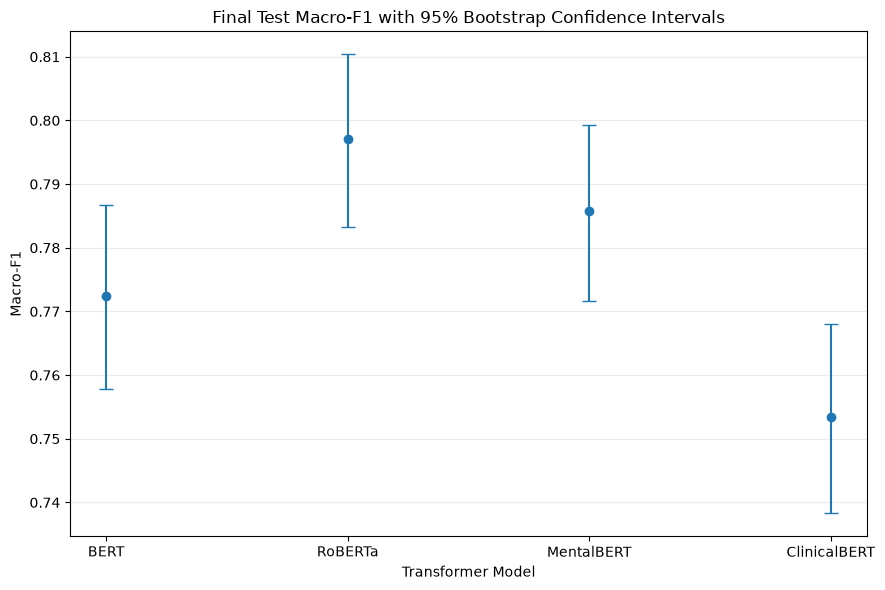

Saved: d:\Thesis_Project\Experiment_2_Transformer-Based Emotion_Classification\outputs\figures\final_test_macro_f1_bootstrap_ci.png


In [332]:
# ============================================================
# EXPERIMENT 2 — PHASE 14 — CELL 18
# MACRO-F1 WITH 95% BOOTSTRAP CI
# ============================================================

plot_df = (
    model_confidence_interval_df
    .copy()
)


x_positions = np.arange(
    len(
        plot_df
    )
)


lower_errors = (
    plot_df[
        "Macro_F1"
    ]
    -
    plot_df[
        "Macro_CI_Lower"
    ]
)


upper_errors = (
    plot_df[
        "Macro_CI_Upper"
    ]
    -
    plot_df[
        "Macro_F1"
    ]
)


plt.figure(
    figsize=(
        9,
        6
    )
)


plt.errorbar(

    x_positions,

    plot_df[
        "Macro_F1"
    ],

    yerr=[
        lower_errors,
        upper_errors
    ],

    fmt="o",

    capsize=5
)


plt.xticks(
    x_positions,
    plot_df[
        "Model"
    ]
)


plt.xlabel(
    "Transformer Model"
)

plt.ylabel(
    "Macro-F1"
)

plt.title(
    "Final Test Macro-F1 with 95% Bootstrap Confidence Intervals"
)

plt.grid(
    axis="y",
    alpha=0.25
)

plt.tight_layout()


MACRO_CI_FIGURE_PATH = (
    FIGURE_DIR
    / "final_test_macro_f1_bootstrap_ci.png"
)


plt.savefig(
    MACRO_CI_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


print(
    "Saved:",
    MACRO_CI_FIGURE_PATH
)

In [333]:
# ============================================================
# EXPERIMENT 2 — PHASE 14 — CELL 19
# SAVE STATISTICAL ANALYSIS RESULTS
# ============================================================

STATISTICS_FINAL_DIR = (
    STATISTICS_DIR
    / "final_test"
)

STATISTICS_FINAL_DIR.mkdir(
    parents=True,
    exist_ok=True
)


MODEL_CI_PATH = (
    STATISTICS_FINAL_DIR
    / "model_bootstrap_confidence_intervals.csv"
)

PAIRED_BOOTSTRAP_PATH = (
    STATISTICS_FINAL_DIR
    / "paired_bootstrap_differences.csv"
)

PERMUTATION_PATH = (
    STATISTICS_FINAL_DIR
    / "paired_permutation_tests.csv"
)

STATISTICAL_COMPARISON_PATH = (
    STATISTICS_FINAL_DIR
    / "final_pairwise_statistical_comparison.csv"
)

JOURNAL_STATISTICAL_PATH = (
    STATISTICS_FINAL_DIR
    / "journal_style_statistical_comparison.csv"
)


model_confidence_interval_df.to_csv(
    MODEL_CI_PATH,
    index=False
)

paired_bootstrap_df.to_csv(
    PAIRED_BOOTSTRAP_PATH,
    index=False
)

pairwise_permutation_df.to_csv(
    PERMUTATION_PATH,
    index=False
)

statistical_comparison_df.to_csv(
    STATISTICAL_COMPARISON_PATH,
    index=False
)

journal_statistical_df.to_csv(
    JOURNAL_STATISTICAL_PATH,
    index=False
)


print("Saved:")
print(MODEL_CI_PATH)
print(PAIRED_BOOTSTRAP_PATH)
print(PERMUTATION_PATH)
print(STATISTICAL_COMPARISON_PATH)
print(JOURNAL_STATISTICAL_PATH)

Saved:
d:\Thesis_Project\Experiment_2_Transformer-Based Emotion_Classification\outputs\statistics\final_test\model_bootstrap_confidence_intervals.csv
d:\Thesis_Project\Experiment_2_Transformer-Based Emotion_Classification\outputs\statistics\final_test\paired_bootstrap_differences.csv
d:\Thesis_Project\Experiment_2_Transformer-Based Emotion_Classification\outputs\statistics\final_test\paired_permutation_tests.csv
d:\Thesis_Project\Experiment_2_Transformer-Based Emotion_Classification\outputs\statistics\final_test\final_pairwise_statistical_comparison.csv
d:\Thesis_Project\Experiment_2_Transformer-Based Emotion_Classification\outputs\statistics\final_test\journal_style_statistical_comparison.csv


In [334]:
# ============================================================
# EXPERIMENT 2 — PHASE 14 — CELL 20
# STATISTICAL ANALYSIS MANIFEST
# ============================================================

statistical_manifest = {

    "analysis":
        "final_locked_test_statistical_analysis",

    "test_samples":
        N_TEST,

    "labels":
        NUM_LABELS,

    "models":
        FINAL_MODEL_ORDER,

    "bootstrap_iterations":
        N_BOOTSTRAP,

    "permutation_iterations":
        N_PERMUTATIONS,

    "confidence_level":
        CONFIDENCE_LEVEL,

    "alpha":
        ALPHA,

    "statistical_seed":
        STATISTICAL_SEED,

    "resampling_unit":
        "complete test sample",

    "bootstrap_type":
        "nonparametric paired sample-level bootstrap",

    "permutation_type":
        "paired sample-level prediction-vector randomization",

    "multiple_comparison_correction":
        "Holm",

    "pairwise_comparisons":
        len(
            MODEL_PAIRS
        ),

    "primary_metric":
        "Macro-F1",

    "secondary_metric":
        "Micro-F1",

    "flattened_label_decisions_used":
        False,

    "model_retraining":
        False,

    "threshold_retuning":
        False,

    "configuration_sha256":
        FINAL_CONFIG_HASH,

    "final_test_results_sha256":
        FINAL_TEST_RESULTS_HASH
}


STATISTICAL_MANIFEST_PATH = (
    STATISTICS_FINAL_DIR
    / "statistical_analysis_manifest.json"
)


with open(
    STATISTICAL_MANIFEST_PATH,
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        statistical_manifest,
        file,
        indent=4,
        ensure_ascii=False
    )


print(
    "Saved:",
    STATISTICAL_MANIFEST_PATH
)

Saved: d:\Thesis_Project\Experiment_2_Transformer-Based Emotion_Classification\outputs\statistics\final_test\statistical_analysis_manifest.json


In [336]:
# ============================================================
# EXPERIMENT 2 — PHASE 14 — CELL 21
# FINAL TEST RESULT LOCK VERIFICATION
# ============================================================

current_test_result_hash = (
    sha256_file(
        FINAL_TEST_COMPARISON_PATH
    )
)


TEST_RESULT_HASH_UNCHANGED = (
    current_test_result_hash
    ==
    FINAL_TEST_RESULTS_HASH
)


print("=" * 82)
print("FINAL TEST RESULT LOCK")
print("=" * 82)

print(
    "Original hash:",
    FINAL_TEST_RESULTS_HASH
)

print(
    "Current hash :",
    current_test_result_hash
)

print()

print(
    "Results unchanged:",
    TEST_RESULT_HASH_UNCHANGED
)

print("=" * 82)


assert (
    TEST_RESULT_HASH_UNCHANGED
)

print(
    "FINAL TEST RESULTS REMAIN UNCHANGED."
)

FINAL TEST RESULT LOCK
Original hash: b0edd8937def432d9d9bc9f316fad4b98e43435024a72a409c69a9fb12085110
Current hash : b0edd8937def432d9d9bc9f316fad4b98e43435024a72a409c69a9fb12085110

Results unchanged: True
FINAL TEST RESULTS REMAIN UNCHANGED.


In [337]:
# ============================================================
# EXPERIMENT 2 — PHASE 14 — CELL 22
# FINAL PHASE 14 VERIFICATION
# ============================================================

phase14_checks = {

    "Four model prediction files loaded":
        len(
            aligned_prediction_frames
        ) == 4,

    "All predictions contain 906 samples":
        all(
            len(
                aligned_prediction_frames[
                    model
                ]
            ) == 906

            for model
            in FINAL_MODEL_ORDER
        ),

    "Frozen predictions reproduced":
        threshold_reproduction_df[
            "Saved_Predictions_Reproduced"
        ].all(),

    "Bootstrap iterations = 5000":
        N_BOOTSTRAP == 5000,

    "Permutation iterations = 5000":
        N_PERMUTATIONS == 5000,

    "Four model CI rows":
        len(
            model_confidence_interval_df
        ) == 4,

    "Six paired bootstrap comparisons":
        len(
            paired_bootstrap_df
        ) == 6,

    "Six paired permutation comparisons":
        len(
            pairwise_permutation_df
        ) == 6,

    "Macro corrected p-values finite":
        np.isfinite(
            pairwise_permutation_df[
                "Macro_P_Holm"
            ]
        ).all(),

    "Micro corrected p-values finite":
        np.isfinite(
            pairwise_permutation_df[
                "Micro_P_Holm"
            ]
        ).all(),

    "No flattened sample-label inference":
        statistical_manifest[
            "flattened_label_decisions_used"
        ] is False,

    "No model retraining":
        statistical_manifest[
            "model_retraining"
        ] is False,

    "No threshold retuning":
        statistical_manifest[
            "threshold_retuning"
        ] is False,

    "Configuration hash unchanged":
        (
            sha256_file(
                FINAL_CONFIGURATION_JSON
            )
            ==
            FINAL_CONFIG_HASH
        ),

    "Final test results unchanged":
        TEST_RESULT_HASH_UNCHANGED,

    "Statistical result file exists":
        STATISTICAL_COMPARISON_PATH.exists(),

    "Statistical manifest exists":
        STATISTICAL_MANIFEST_PATH.exists()
}


print("=" * 86)
print("PHASE 14 — FINAL VERIFICATION")
print("=" * 86)

phase14_passed = True

for check_name, status in (
    phase14_checks.items()
):

    print(
        f"{check_name:<60}: "
        f"{'PASS' if status else 'FAIL'}"
    )

    if not status:

        phase14_passed = False


print("=" * 86)


if phase14_passed:

    print(
        "PHASE 14 STATUS: PASSED"
    )

    print(
        "Bootstrap confidence intervals and "
        "paired statistical comparisons are complete."
    )

    print(
        "All analyses used the original frozen "
        "test predictions."
    )

    print(
        "No post-test model modification was performed."
    )

else:

    print(
        "PHASE 14 STATUS: REVIEW REQUIRED"
    )


print("=" * 86)

PHASE 14 — FINAL VERIFICATION
Four model prediction files loaded                          : PASS
All predictions contain 906 samples                         : PASS
Frozen predictions reproduced                               : PASS
Bootstrap iterations = 5000                                 : PASS
Permutation iterations = 5000                               : PASS
Four model CI rows                                          : PASS
Six paired bootstrap comparisons                            : PASS
Six paired permutation comparisons                          : PASS
Macro corrected p-values finite                             : PASS
Micro corrected p-values finite                             : PASS
No flattened sample-label inference                         : PASS
No model retraining                                         : PASS
No threshold retuning                                       : PASS
Configuration hash unchanged                                : PASS
Final test results unchanged    

# PHASE 15 — Final Per-Label Analysis, ROC/PR Curves and Confusion Matrices

## Objective

This phase performs a detailed class-level diagnostic analysis of the four frozen transformer models using only the final test predictions generated in Phase 13.

No model training, threshold optimization, checkpoint selection, or hyperparameter modification is performed.

## Analyses

For each of the eight emotion labels and each model, the following metrics are reported:

- Precision
- Recall / Sensitivity
- F1-score
- Specificity
- Negative Predictive Value
- False Positive Rate
- False Negative Rate
- Matthews Correlation Coefficient
- Balanced Accuracy
- ROC-AUC
- Average Precision
- Support
- True Positives
- False Positives
- False Negatives
- True Negatives

## Visualizations

Publication-ready diagnostic figures include:

1. Per-emotion ROC curves comparing all four models
2. Per-emotion Precision–Recall curves comparing all four models
3. Micro-average ROC curves
4. Micro-average Precision–Recall curves
5. Per-label confusion matrices for each model
6. Per-label F1 comparison heatmap

## Methodological Rule

All analyses use the original frozen predictions.

The test results are used only for reporting and interpretation.

They cannot be used to:

- change model thresholds,
- retrain any model,
- modify the architecture,
- alter the optimization strategy,
- or perform additional model selection.

Micro-average ROC and Precision–Recall curves flatten sample-label decisions only for descriptive micro-averaging. No inferential statistical test treats those flattened decisions as independent observations.

In [338]:
# ============================================================
# EXPERIMENT 2 — PHASE 15 — CELL 1
# PER-LABEL ANALYSIS DIRECTORIES
# ============================================================

PHASE15_DIR = (
    OUTPUT_DIR
    / "final_per_label_analysis"
)

PHASE15_TABLE_DIR = (
    PHASE15_DIR
    / "tables"
)

PHASE15_ROC_DIR = (
    PHASE15_DIR
    / "roc_curves"
)

PHASE15_PR_DIR = (
    PHASE15_DIR
    / "pr_curves"
)

PHASE15_CM_DIR = (
    PHASE15_DIR
    / "confusion_matrices"
)

PHASE15_FIGURE_DIR = (
    PHASE15_DIR
    / "figures"
)


for directory in [
    PHASE15_DIR,
    PHASE15_TABLE_DIR,
    PHASE15_ROC_DIR,
    PHASE15_PR_DIR,
    PHASE15_CM_DIR,
    PHASE15_FIGURE_DIR
]:

    directory.mkdir(
        parents=True,
        exist_ok=True
    )


print("=" * 82)
print("PHASE 15 — FINAL PER-LABEL ANALYSIS")
print("=" * 82)

print(
    "Models:",
    FINAL_MODEL_ORDER
)

print(
    "Labels:",
    NUM_LABELS
)

print(
    "Test samples:",
    len(test_final_df)
)

print(
    "Model retraining: NO"
)

print(
    "Threshold tuning: NO"
)

print("=" * 82)

PHASE 15 — FINAL PER-LABEL ANALYSIS
Models: ['BERT', 'RoBERTa', 'MentalBERT', 'ClinicalBERT']
Labels: 8
Test samples: 906
Model retraining: NO
Threshold tuning: NO


In [339]:
# ============================================================
# EXPERIMENT 2 — PHASE 15 — CELL 2
# VERIFY FROZEN RESULTS
# ============================================================

phase15_config_hash = (
    sha256_file(
        FINAL_CONFIGURATION_JSON
    )
)

phase15_test_hash = (
    sha256_file(
        FINAL_TEST_COMPARISON_PATH
    )
)


PHASE15_CONFIG_LOCKED = (
    phase15_config_hash
    ==
    FINAL_CONFIG_HASH
)

PHASE15_TEST_RESULTS_LOCKED = (
    phase15_test_hash
    ==
    FINAL_TEST_RESULTS_HASH
)


print("=" * 82)
print("FROZEN RESULT VERIFICATION")
print("=" * 82)

print(
    "Configuration unchanged :",
    PHASE15_CONFIG_LOCKED
)

print(
    "Test results unchanged  :",
    PHASE15_TEST_RESULTS_LOCKED
)

print("=" * 82)


assert PHASE15_CONFIG_LOCKED

assert PHASE15_TEST_RESULTS_LOCKED


print(
    "FROZEN RESULT VERIFICATION: PASSED"
)

FROZEN RESULT VERIFICATION
Configuration unchanged : True
Test results unchanged  : True
FROZEN RESULT VERIFICATION: PASSED


In [340]:
# ============================================================
# EXPERIMENT 2 — PHASE 15 — CELL 3
# RELOAD FINAL TEST PREDICTIONS
# ============================================================

PHASE15_TEST_ID_ORDER = (
    test_final_df[
        "id"
    ]
    .astype(str)
    .tolist()
)


phase15_prediction_frames = {}


for model_name in FINAL_MODEL_ORDER:

    safe_name = (
        model_name
        .lower()
        .replace(
            " ",
            "_"
        )
    )

    prediction_path = (
        FINAL_TEST_PRED_DIR
        / f"{safe_name}_test_predictions.csv"
    )

    df = pd.read_csv(
        prediction_path
    )

    df[
        "id"
    ] = (
        df[
            "id"
        ]
        .astype(str)
    )

    assert (
        df[
            "id"
        ].duplicated().sum()
        == 0
    )

    assert set(
        df[
            "id"
        ]
    ) == set(
        PHASE15_TEST_ID_ORDER
    )

    df = (
        df
        .set_index(
            "id"
        )
        .loc[
            PHASE15_TEST_ID_ORDER
        ]
        .reset_index()
    )

    phase15_prediction_frames[
        model_name
    ] = df

    print(
        f"{model_name:<15}: "
        f"{df.shape}"
    )


print()

print(
    "All final prediction files aligned."
)

BERT           : (906, 28)
RoBERTa        : (906, 28)
MentalBERT     : (906, 28)
ClinicalBERT   : (906, 28)

All final prediction files aligned.


In [341]:
# ============================================================
# EXPERIMENT 2 — PHASE 15 — CELL 4
# EXTRACT FROZEN TEST ARRAYS
# ============================================================

phase15_arrays = {}

phase15_reference_targets = None

prediction_reproduction_rows = []


for model_name in FINAL_MODEL_ORDER:

    df = (
        phase15_prediction_frames[
            model_name
        ]
    )

    y_true = np.column_stack(
        [
            df[
                f"true__{label}"
            ].values

            for label
            in MODEL_LABELS
        ]
    ).astype(int)

    probabilities = np.column_stack(
        [
            df[
                f"prob__{label}"
            ].values

            for label
            in MODEL_LABELS
        ]
    ).astype(float)

    predictions = np.column_stack(
        [
            df[
                f"pred__{label}"
            ].values

            for label
            in MODEL_LABELS
        ]
    ).astype(int)

    threshold = (
        FINAL_THRESHOLDS[
            model_name
        ]
    )

    reproduced = (
        probabilities
        >= threshold
    ).astype(int)

    if phase15_reference_targets is None:

        phase15_reference_targets = (
            y_true.copy()
        )

    else:

        assert np.array_equal(
            phase15_reference_targets,
            y_true
        )

    prediction_reproduction_rows.append(
        {
            "Model":
                model_name,

            "Threshold":
                threshold,

            "Prediction_Reproduced":
                np.array_equal(
                    predictions,
                    reproduced
                )
        }
    )

    phase15_arrays[
        model_name
    ] = {

        "y_true":
            y_true,

        "probabilities":
            probabilities,

        "predictions":
            predictions
    }


prediction_reproduction_df = (
    pd.DataFrame(
        prediction_reproduction_rows
    )
)


display(
    prediction_reproduction_df
)


assert (
    prediction_reproduction_df[
        "Prediction_Reproduced"
    ].all()
)


assert np.array_equal(
    phase15_reference_targets,
    Y_test.astype(int)
)


print(
    "Frozen prediction reproduction: PASSED"
)

,Model,Threshold,Prediction_Reproduced
0,BERT,0.38,True
1,RoBERTa,0.35,True
2,MentalBERT,0.35,True
3,ClinicalBERT,0.34,True


Frozen prediction reproduction: PASSED


In [342]:
# ============================================================
# EXPERIMENT 2 — PHASE 15 — CELL 5
# COMPREHENSIVE PER-LABEL METRICS
# ============================================================

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    matthews_corrcoef,
    balanced_accuracy_score
)


def safe_divide(
    numerator,
    denominator
):

    if denominator == 0:
        return 0.0

    return (
        numerator
        / denominator
    )


def comprehensive_per_label_metrics(
    y_true,
    probabilities,
    predictions
):

    rows = []

    for label_index, label in enumerate(
        MODEL_LABELS
    ):

        true_label = (
            y_true[
                :,
                label_index
            ]
            .astype(int)
        )

        pred_label = (
            predictions[
                :,
                label_index
            ]
            .astype(int)
        )

        prob_label = (
            probabilities[
                :,
                label_index
            ]
        )

        tn, fp, fn, tp = (
            confusion_matrix(
                true_label,
                pred_label,
                labels=[
                    0,
                    1
                ]
            )
            .ravel()
        )

        precision = (
            precision_score(
                true_label,
                pred_label,
                zero_division=0
            )
        )

        recall = (
            recall_score(
                true_label,
                pred_label,
                zero_division=0
            )
        )

        f1 = (
            f1_score(
                true_label,
                pred_label,
                zero_division=0
            )
        )

        specificity = safe_divide(
            tn,
            tn + fp
        )

        negative_predictive_value = (
            safe_divide(
                tn,
                tn + fn
            )
        )

        false_positive_rate = (
            safe_divide(
                fp,
                fp + tn
            )
        )

        false_negative_rate = (
            safe_divide(
                fn,
                fn + tp
            )
        )

        prevalence = (
            true_label.mean()
        )

        predicted_prevalence = (
            pred_label.mean()
        )

        rows.append(
            {
                "Emotion":
                    label,

                "Precision":
                    precision,

                "Recall_Sensitivity":
                    recall,

                "F1":
                    f1,

                "Specificity":
                    specificity,

                "NPV":
                    negative_predictive_value,

                "FPR":
                    false_positive_rate,

                "FNR":
                    false_negative_rate,

                "Balanced_Accuracy":
                    balanced_accuracy_score(
                        true_label,
                        pred_label
                    ),

                "MCC":
                    matthews_corrcoef(
                        true_label,
                        pred_label
                    ),

                "ROC_AUC":
                    roc_auc_score(
                        true_label,
                        prob_label
                    ),

                "Average_Precision":
                    average_precision_score(
                        true_label,
                        prob_label
                    ),

                "Support":
                    int(
                        true_label.sum()
                    ),

                "Prevalence":
                    prevalence,

                "Predicted_Prevalence":
                    predicted_prevalence,

                "TN":
                    int(tn),

                "FP":
                    int(fp),

                "FN":
                    int(fn),

                "TP":
                    int(tp)
            }
        )

    return pd.DataFrame(
        rows
    )


print(
    "Comprehensive per-label metric function created."
)

Comprehensive per-label metric function created.


In [343]:
# ============================================================
# EXPERIMENT 2 — PHASE 15 — CELL 6
# CALCULATE ALL PER-LABEL METRICS
# ============================================================

phase15_per_label_results = {}

combined_phase15_rows = []


for model_name in FINAL_MODEL_ORDER:

    arrays = (
        phase15_arrays[
            model_name
        ]
    )

    model_df = (
        comprehensive_per_label_metrics(

            y_true=arrays[
                "y_true"
            ],

            probabilities=arrays[
                "probabilities"
            ],

            predictions=arrays[
                "predictions"
            ]
        )
    )

    phase15_per_label_results[
        model_name
    ] = model_df

    temp_df = (
        model_df.copy()
    )

    temp_df.insert(
        0,
        "Model",
        model_name
    )

    combined_phase15_rows.append(
        temp_df
    )


phase15_per_label_df = pd.concat(
    combined_phase15_rows,
    ignore_index=True
)


display(
    phase15_per_label_df
)

,Model,Emotion,Precision,Recall_Sensitivity,F1,Specificity,NPV,FPR,FNR,Balanced_Accuracy,MCC,ROC_AUC,Average_Precision,Support,Prevalence,Predicted_Prevalence,TN,FP,FN,TP
0,BERT,anger,0.749280,0.753623,0.751445,0.844920,0.847943,0.155080,0.246377,0.799271,0.597882,0.867501,0.832129,345,0.380795,0.383002,474,87,85,260
1,BERT,brain dysfunction (forget),0.489209,0.397661,0.438710,0.903401,0.865711,0.096599,0.602339,0.650531,0.326883,0.800282,0.521956,171,0.188742,0.153422,664,71,103,68
2,BERT,emptiness,0.731266,0.829912,0.777473,0.815929,0.888247,0.184071,0.170088,0.822921,0.632540,0.898181,0.854812,341,0.376380,0.427152,461,104,58,283
3,BERT,hopelessness,0.826087,0.929022,0.874536,0.544118,0.766839,0.455882,0.070978,0.736570,0.529657,0.878990,0.942837,634,0.699779,0.786976,148,124,45,589
4,BERT,loneliness,0.811530,0.871429,0.840413,0.825103,0.881319,0.174897,0.128571,0.848266,0.694688,0.922778,0.918998,420,0.463576,0.497792,401,85,54,366
5,BERT,sadness,0.834577,0.962697,0.894071,0.363636,0.745098,0.636364,0.037303,0.663167,0.434934,0.874102,0.956312,697,0.769316,0.887417,76,133,26,671
6,BERT,suicide intent,0.783133,0.840517,0.810811,0.919881,0.943683,0.080119,0.159483,0.880199,0.743418,0.947080,0.883824,232,0.256071,0.274834,620,54,37,195
7,BERT,worthlessness,0.743434,0.847926,0.792250,0.730932,0.839416,0.269068,0.152074,0.789429,0.580851,0.872847,0.859741,434,0.479029,0.546358,345,127,66,368
8,RoBERTa,anger,0.731458,0.828986,0.777174,0.812834,0.885437,0.187166,0.171014,0.820910,0.629234,0.892074,0.859123,345,0.380795,0.431567,456,105,59,286
9,RoBERTa,brain dysfunction (forget),0.539683,0.596491,0.566667,0.881633,0.903766,0.118367,0.403509,0.739062,0.460460,0.843597,0.606624,171,0.188742,0.208609,648,87,69,102


In [344]:
# ============================================================
# EXPERIMENT 2 — PHASE 15 — CELL 7
# FINAL TEST LABEL DISTRIBUTION
# ============================================================

label_distribution_rows = []


for label_index, label in enumerate(
    MODEL_LABELS
):

    positives = int(
        phase15_reference_targets[
            :,
            label_index
        ].sum()
    )

    negatives = (
        len(
            phase15_reference_targets
        )
        -
        positives
    )

    prevalence = (
        positives
        /
        len(
            phase15_reference_targets
        )
    )

    label_distribution_rows.append(
        {
            "Emotion":
                label,

            "Positive_Samples":
                positives,

            "Negative_Samples":
                negatives,

            "Prevalence":
                prevalence,

            "Prevalence_%":
                prevalence
                * 100
        }
    )


test_label_distribution_df = (
    pd.DataFrame(
        label_distribution_rows
    )
)


display(
    test_label_distribution_df
)

,Emotion,Positive_Samples,Negative_Samples,Prevalence,Prevalence_%
0,anger,345,561,0.380795,38.079470
1,brain dysfunction (forget),171,735,0.188742,18.874172
2,emptiness,341,565,0.376380,37.637969
3,hopelessness,634,272,0.699779,69.977925
4,loneliness,420,486,0.463576,46.357616
5,sadness,697,209,0.769316,76.931567
6,suicide intent,232,674,0.256071,25.607064
7,worthlessness,434,472,0.479029,47.902870


In [345]:
# ============================================================
# EXPERIMENT 2 — PHASE 15 — CELL 8
# PER-LABEL F1 COMPARISON
# ============================================================

phase15_f1_pivot_df = (
    phase15_per_label_df
    .pivot(
        index="Emotion",
        columns="Model",
        values="F1"
    )
    .reset_index()
)


phase15_f1_pivot_df.columns.name = None


display(
    phase15_f1_pivot_df
)

,Emotion,BERT,ClinicalBERT,MentalBERT,RoBERTa
0,anger,0.751445,0.710938,0.743733,0.777174
1,brain dysfunction (forget),0.438710,0.496732,0.568915,0.566667
2,emptiness,0.777473,0.729767,0.780220,0.791946
3,hopelessness,0.874536,0.859649,0.882440,0.887732
4,loneliness,0.840413,0.808656,0.823121,0.835214
5,sadness,0.894071,0.884591,0.893165,0.903010
6,suicide intent,0.810811,0.781563,0.802444,0.806950
7,worthlessness,0.792250,0.755418,0.791932,0.808017


In [346]:
# ============================================================
# EXPERIMENT 2 — PHASE 15 — CELL 9
# PER-LABEL ROC-AUC COMPARISON
# ============================================================

roc_auc_pivot_df = (
    phase15_per_label_df
    .pivot(
        index="Emotion",
        columns="Model",
        values="ROC_AUC"
    )
    .reset_index()
)


roc_auc_pivot_df.columns.name = None


display(
    roc_auc_pivot_df
)

,Emotion,BERT,ClinicalBERT,MentalBERT,RoBERTa
0,anger,0.867501,0.838952,0.868865,0.892074
1,brain dysfunction (forget),0.800282,0.800549,0.847607,0.843597
2,emptiness,0.898181,0.867537,0.898251,0.913804
3,hopelessness,0.878990,0.850248,0.879509,0.894310
4,loneliness,0.922778,0.899385,0.917703,0.928113
5,sadness,0.874102,0.840001,0.877596,0.893155
6,suicide intent,0.947080,0.930353,0.952257,0.958831
7,worthlessness,0.872847,0.842549,0.879357,0.898217


In [347]:
# ============================================================
# EXPERIMENT 2 — PHASE 15 — CELL 10
# PER-LABEL AVERAGE PRECISION
# ============================================================

average_precision_pivot_df = (
    phase15_per_label_df
    .pivot(
        index="Emotion",
        columns="Model",
        values="Average_Precision"
    )
    .reset_index()
)


average_precision_pivot_df.columns.name = None


display(
    average_precision_pivot_df
)

,Emotion,BERT,ClinicalBERT,MentalBERT,RoBERTa
0,anger,0.832129,0.780350,0.833451,0.859123
1,brain dysfunction (forget),0.521956,0.526306,0.613287,0.606624
2,emptiness,0.854812,0.818857,0.858545,0.868114
3,hopelessness,0.942837,0.929664,0.941815,0.948823
4,loneliness,0.918998,0.901932,0.920822,0.930986
5,sadness,0.956312,0.940973,0.957826,0.963513
6,suicide intent,0.883824,0.852312,0.891204,0.894725
7,worthlessness,0.859741,0.831914,0.877031,0.894346


In [348]:
# ============================================================
# EXPERIMENT 2 — PHASE 15 — CELL 11
# PER-EMOTION DESCRIPTIVE SUMMARY
# ============================================================

emotion_summary_rows = []


for label in MODEL_LABELS:

    label_df = (
        phase15_per_label_df[
            phase15_per_label_df[
                "Emotion"
            ] == label
        ]
        .copy()
    )

    highest_f1_row = (
        label_df
        .sort_values(
            "F1",
            ascending=False
        )
        .iloc[0]
    )

    lowest_f1_row = (
        label_df
        .sort_values(
            "F1",
            ascending=True
        )
        .iloc[0]
    )

    emotion_summary_rows.append(
        {
            "Emotion":
                label,

            "Highest_F1_Model":
                highest_f1_row[
                    "Model"
                ],

            "Highest_F1":
                float(
                    highest_f1_row[
                        "F1"
                    ]
                ),

            "Lowest_F1_Model":
                lowest_f1_row[
                    "Model"
                ],

            "Lowest_F1":
                float(
                    lowest_f1_row[
                        "F1"
                    ]
                ),

            "F1_Range":
                float(
                    highest_f1_row[
                        "F1"
                    ]
                    -
                    lowest_f1_row[
                        "F1"
                    ]
                )
        }
    )


emotion_performance_summary_df = (
    pd.DataFrame(
        emotion_summary_rows
    )
)


display(
    emotion_performance_summary_df
)

,Emotion,Highest_F1_Model,Highest_F1,Lowest_F1_Model,Lowest_F1,F1_Range
0,anger,RoBERTa,0.777174,ClinicalBERT,0.710938,0.066236
1,brain dysfunction (forget),MentalBERT,0.568915,BERT,0.438710,0.130205
2,emptiness,RoBERTa,0.791946,ClinicalBERT,0.729767,0.062180
3,hopelessness,RoBERTa,0.887732,ClinicalBERT,0.859649,0.028083
4,loneliness,BERT,0.840413,ClinicalBERT,0.808656,0.031757
5,sadness,RoBERTa,0.903010,ClinicalBERT,0.884591,0.018419
6,suicide intent,BERT,0.810811,ClinicalBERT,0.781563,0.029248
7,worthlessness,RoBERTa,0.808017,ClinicalBERT,0.755418,0.052599


In [349]:
# ============================================================
# EXPERIMENT 2 — PHASE 15 — CELL 12
# SAVE PER-LABEL TABLES
# ============================================================

phase15_per_label_df.to_csv(
    PHASE15_TABLE_DIR
    / "complete_per_label_metrics.csv",
    index=False
)

test_label_distribution_df.to_csv(
    PHASE15_TABLE_DIR
    / "test_label_distribution.csv",
    index=False
)

phase15_f1_pivot_df.to_csv(
    PHASE15_TABLE_DIR
    / "per_label_f1_comparison.csv",
    index=False
)

roc_auc_pivot_df.to_csv(
    PHASE15_TABLE_DIR
    / "per_label_roc_auc_comparison.csv",
    index=False
)

average_precision_pivot_df.to_csv(
    PHASE15_TABLE_DIR
    / "per_label_average_precision_comparison.csv",
    index=False
)

emotion_performance_summary_df.to_csv(
    PHASE15_TABLE_DIR
    / "per_emotion_performance_summary.csv",
    index=False
)


print(
    "Per-label analysis tables saved."
)

Per-label analysis tables saved.


In [350]:
# ============================================================
# EXPERIMENT 2 — PHASE 15 — CELL 13
# SAFE FIGURE FILENAME HELPER
# ============================================================

import re


def safe_filename(
    text
):

    text = str(
        text
    ).lower()

    text = re.sub(
        r"[^a-z0-9]+",
        "_",
        text
    )

    return text.strip(
        "_"
    )


print(
    "Safe filename helper created."
)

Safe filename helper created.


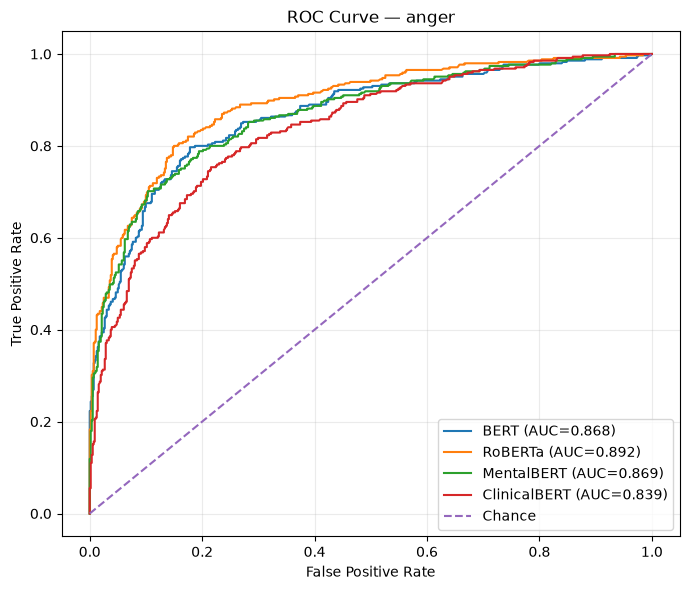

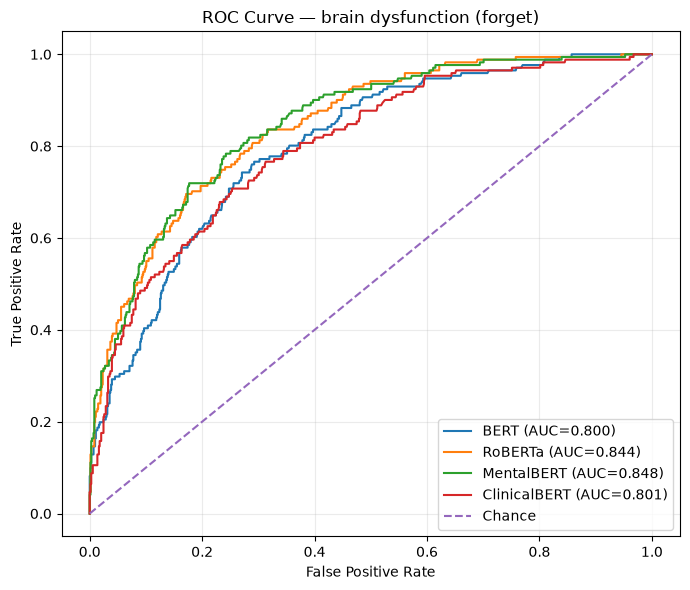

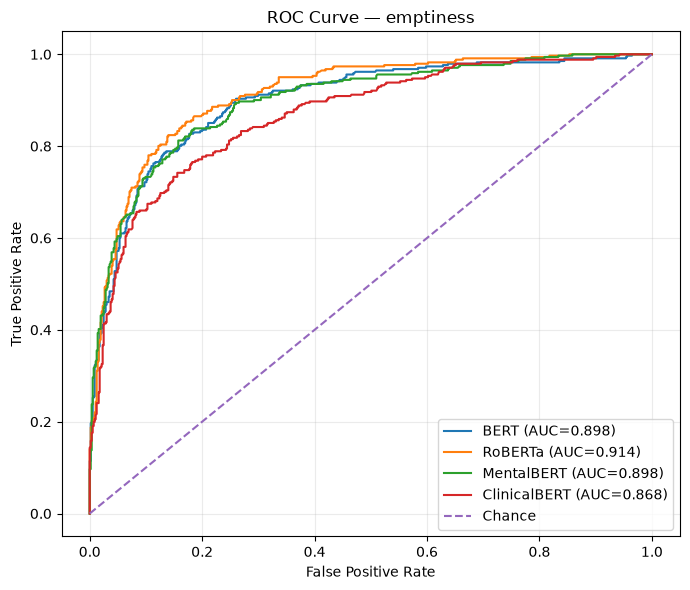

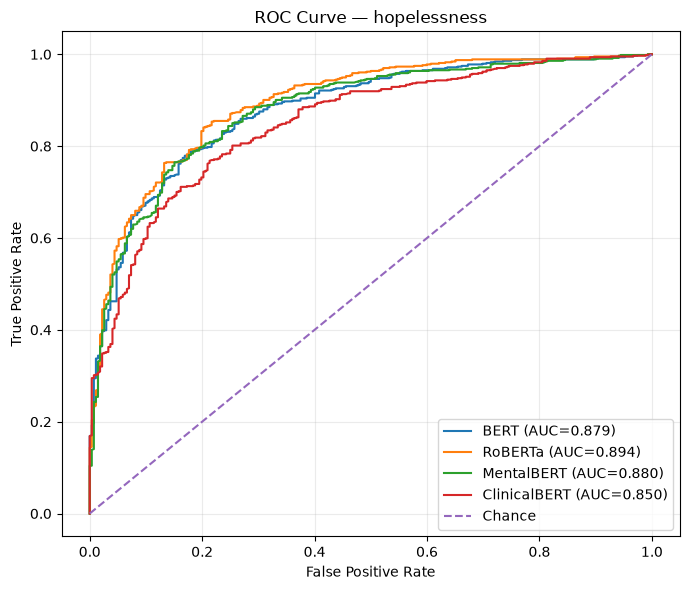

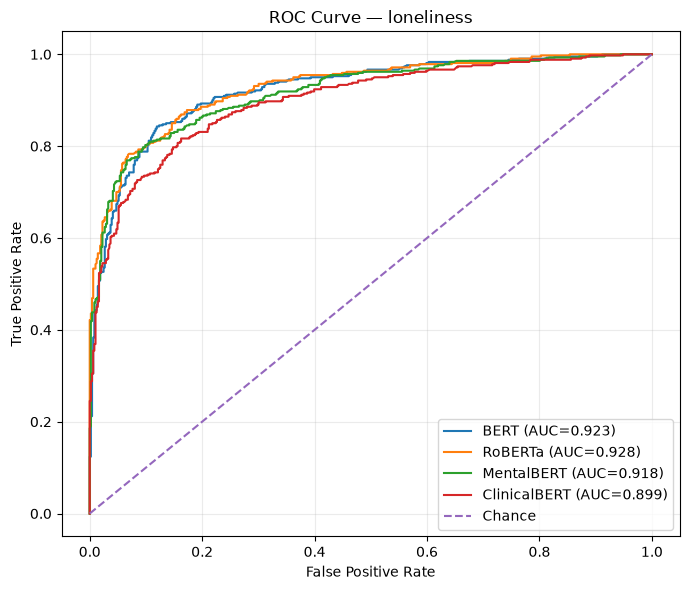

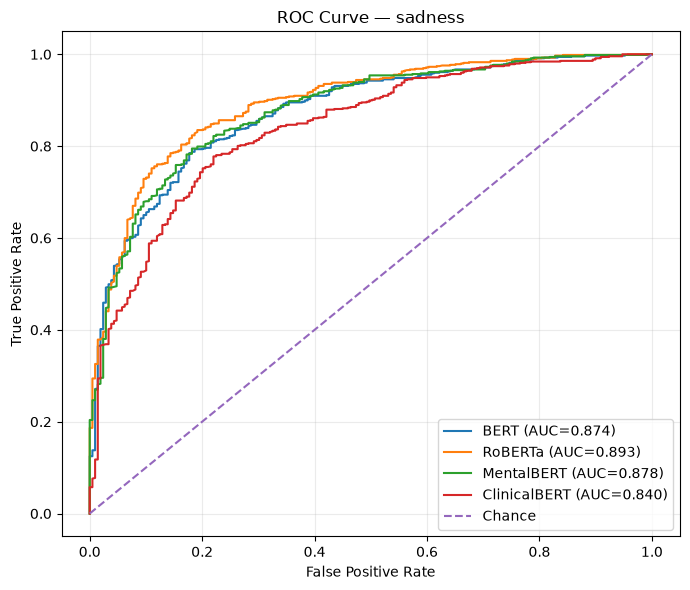

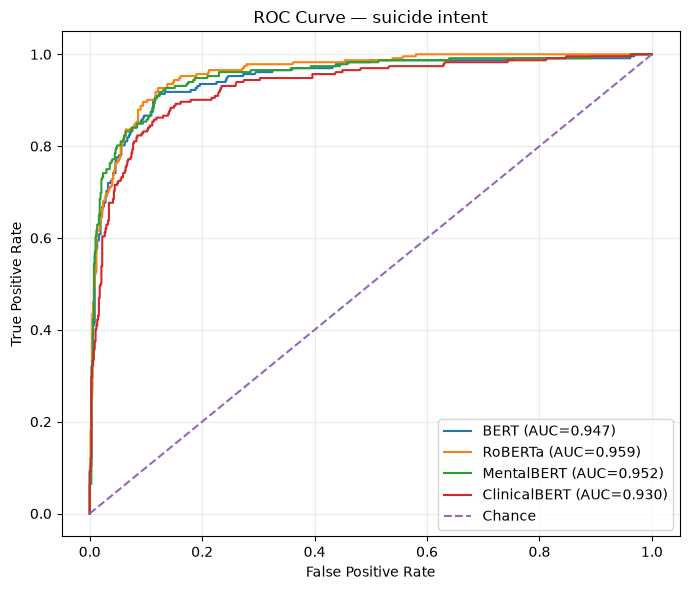

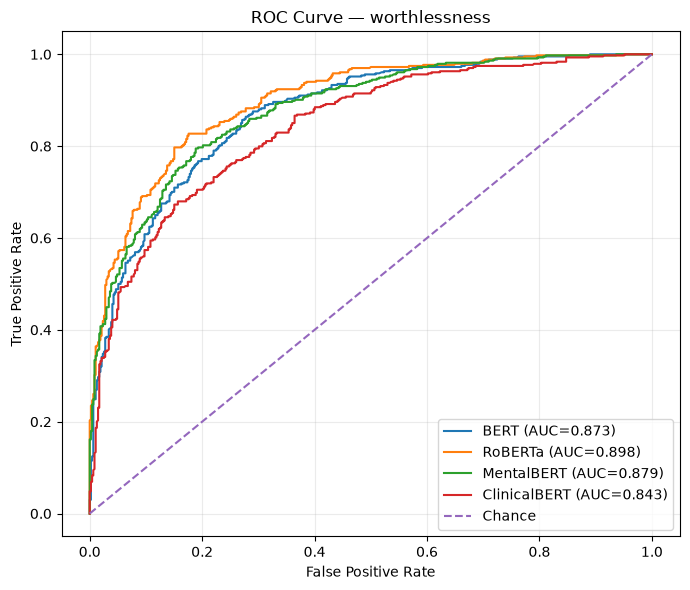

Saved 8 per-emotion ROC figures.


In [351]:
# ============================================================
# EXPERIMENT 2 — PHASE 15 — CELL 14
# PER-EMOTION ROC CURVES
# ============================================================

from sklearn.metrics import (
    roc_curve
)


roc_figure_records = []


for label_index, label in enumerate(
    MODEL_LABELS
):

    plt.figure(
        figsize=(
            7,
            6
        )
    )

    for model_name in FINAL_MODEL_ORDER:

        y_true = (
            phase15_arrays[
                model_name
            ][
                "y_true"
            ][
                :,
                label_index
            ]
        )

        probabilities = (
            phase15_arrays[
                model_name
            ][
                "probabilities"
            ][
                :,
                label_index
            ]
        )

        fpr, tpr, _ = (
            roc_curve(
                y_true,
                probabilities
            )
        )

        auc_value = (
            roc_auc_score(
                y_true,
                probabilities
            )
        )

        plt.plot(
            fpr,
            tpr,
            label=(
                f"{model_name} "
                f"(AUC={auc_value:.3f})"
            )
        )

    plt.plot(
        [
            0,
            1
        ],
        [
            0,
            1
        ],
        linestyle="--",
        label="Chance"
    )

    plt.xlabel(
        "False Positive Rate"
    )

    plt.ylabel(
        "True Positive Rate"
    )

    plt.title(
        f"ROC Curve — {label}"
    )

    plt.legend(
        loc="lower right"
    )

    plt.grid(
        alpha=0.25
    )

    plt.tight_layout()

    figure_path = (
        PHASE15_ROC_DIR
        / (
            f"roc_"
            f"{safe_filename(label)}.png"
        )
    )

    plt.savefig(
        figure_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

    roc_figure_records.append(
        {
            "Emotion":
                label,

            "Figure":
                str(
                    figure_path
                )
        }
    )


print(
    f"Saved {len(roc_figure_records)} "
    "per-emotion ROC figures."
)

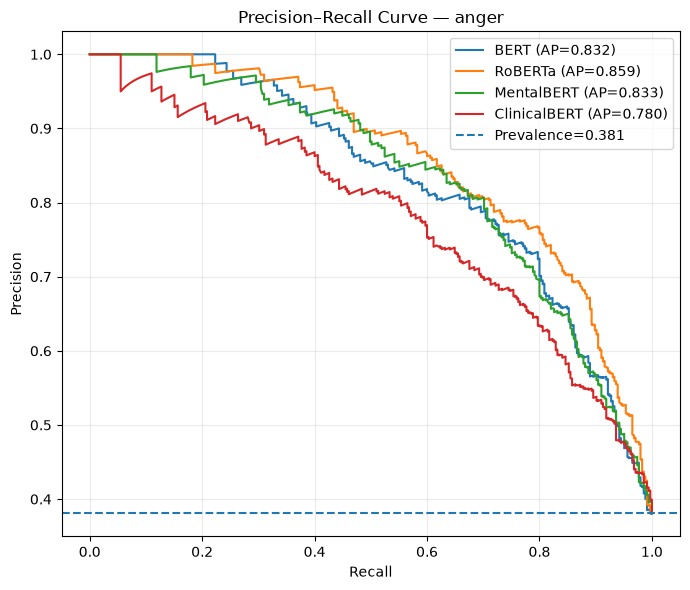

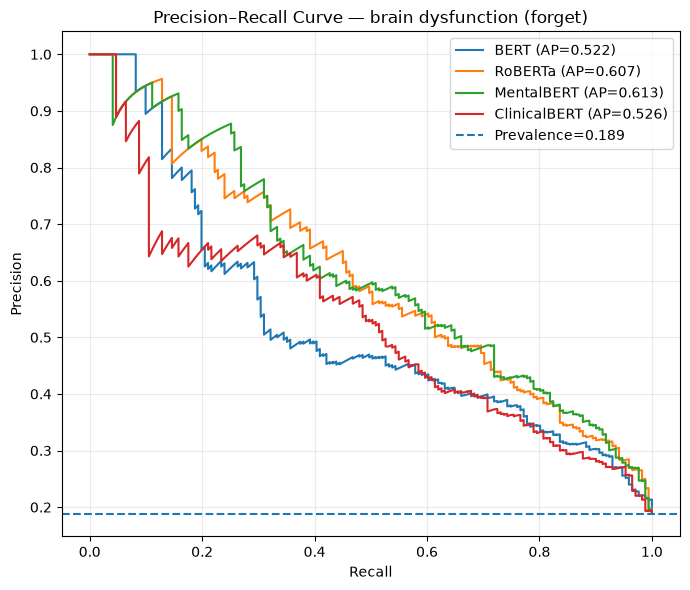

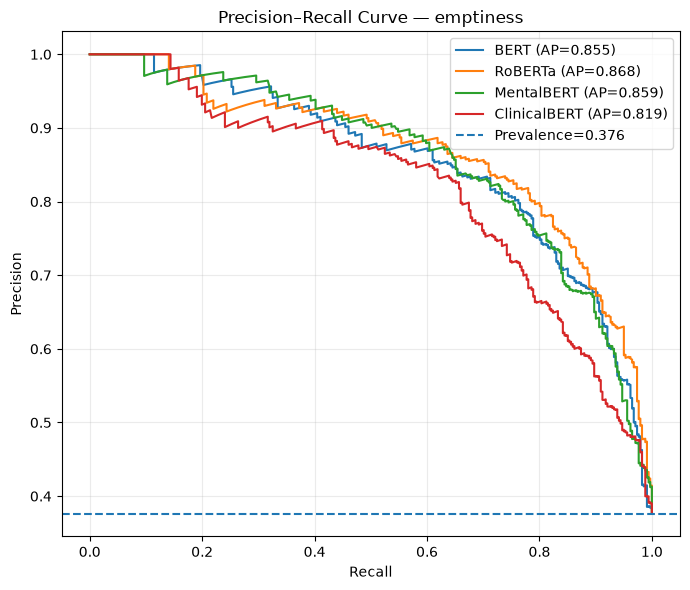

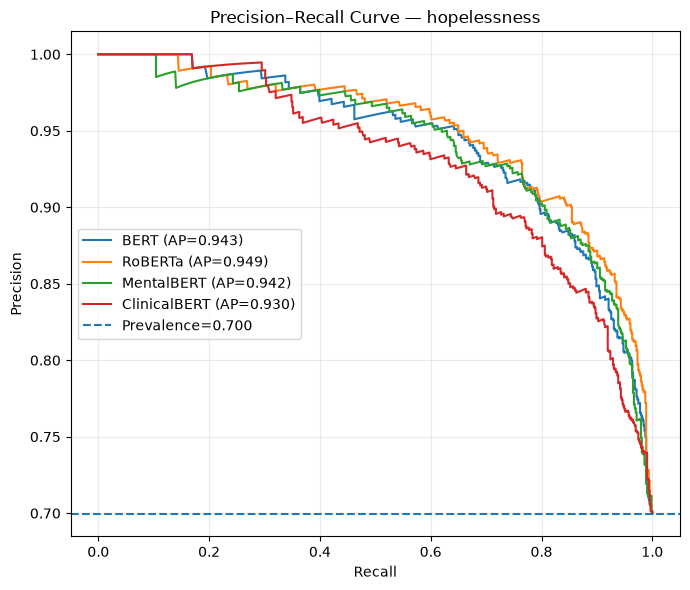

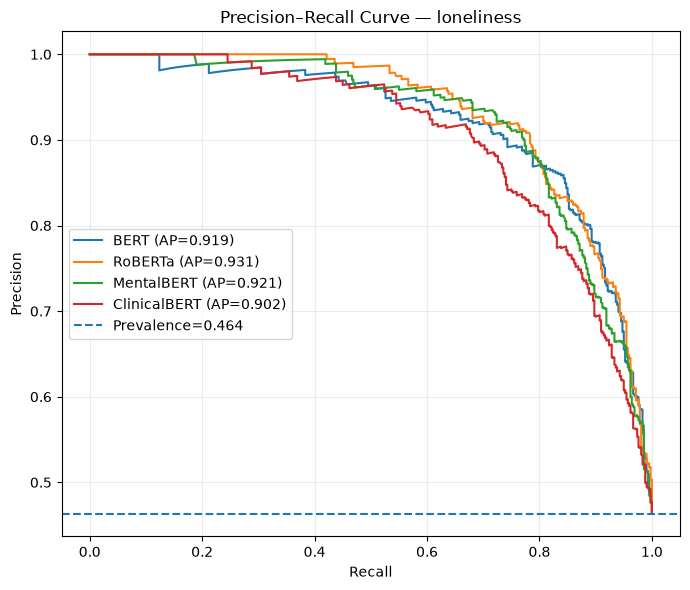

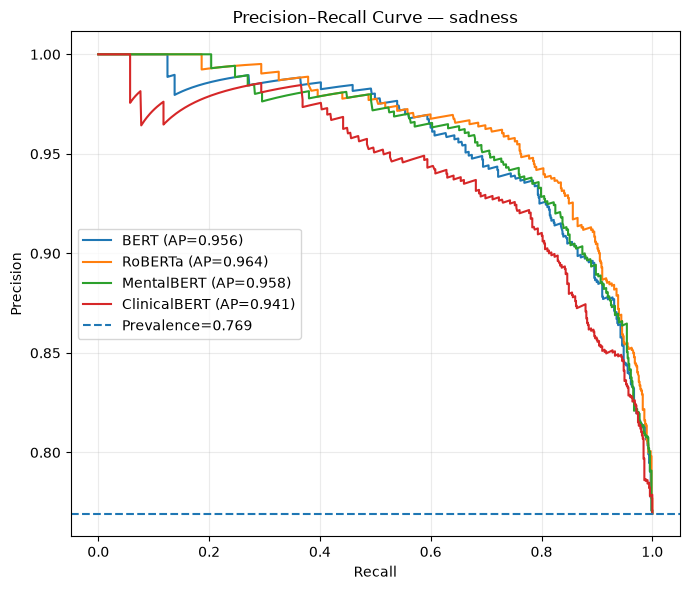

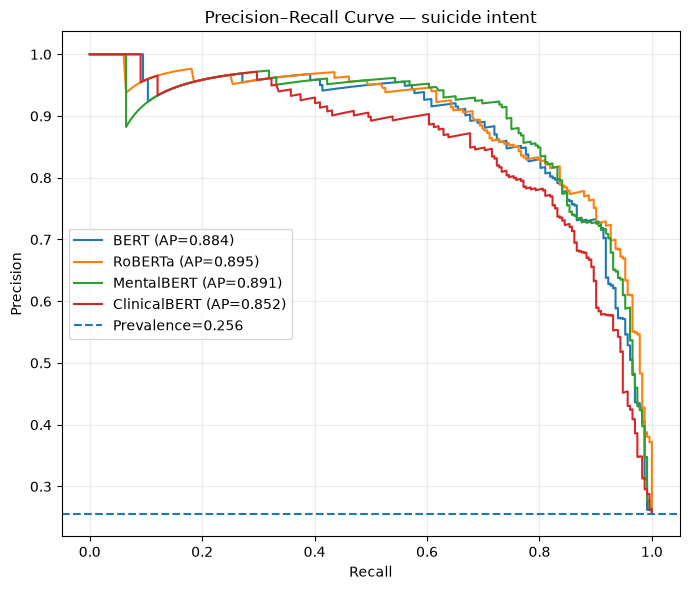

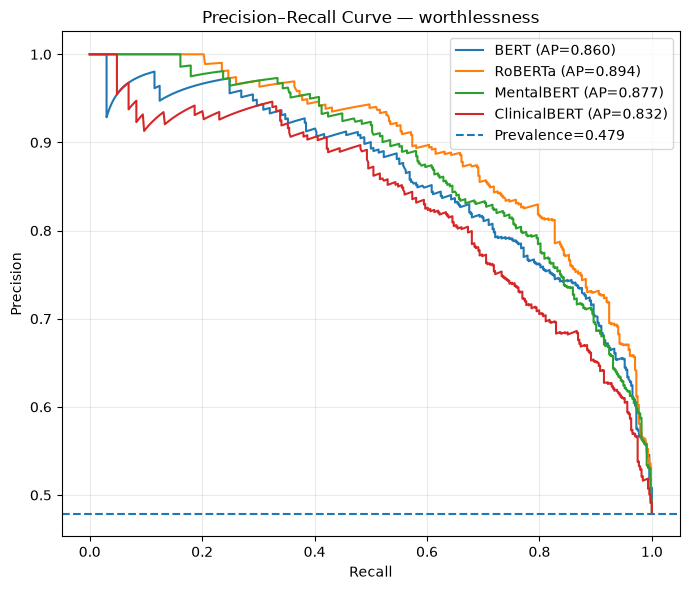

Saved 8 per-emotion PR figures.


In [352]:
# ============================================================
# EXPERIMENT 2 — PHASE 15 — CELL 15
# PER-EMOTION PRECISION-RECALL CURVES
# ============================================================

from sklearn.metrics import (
    precision_recall_curve
)


pr_figure_records = []


for label_index, label in enumerate(
    MODEL_LABELS
):

    plt.figure(
        figsize=(
            7,
            6
        )
    )

    label_prevalence = (
        phase15_reference_targets[
            :,
            label_index
        ].mean()
    )

    for model_name in FINAL_MODEL_ORDER:

        y_true = (
            phase15_arrays[
                model_name
            ][
                "y_true"
            ][
                :,
                label_index
            ]
        )

        probabilities = (
            phase15_arrays[
                model_name
            ][
                "probabilities"
            ][
                :,
                label_index
            ]
        )

        precision_values, recall_values, _ = (
            precision_recall_curve(
                y_true,
                probabilities
            )
        )

        average_precision = (
            average_precision_score(
                y_true,
                probabilities
            )
        )

        plt.plot(
            recall_values,
            precision_values,
            label=(
                f"{model_name} "
                f"(AP={average_precision:.3f})"
            )
        )

    plt.axhline(
        y=label_prevalence,
        linestyle="--",
        label=(
            f"Prevalence="
            f"{label_prevalence:.3f}"
        )
    )

    plt.xlabel(
        "Recall"
    )

    plt.ylabel(
        "Precision"
    )

    plt.title(
        f"Precision–Recall Curve — {label}"
    )

    plt.legend(
        loc="best"
    )

    plt.grid(
        alpha=0.25
    )

    plt.tight_layout()

    figure_path = (
        PHASE15_PR_DIR
        / (
            f"pr_"
            f"{safe_filename(label)}.png"
        )
    )

    plt.savefig(
        figure_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

    pr_figure_records.append(
        {
            "Emotion":
                label,

            "Figure":
                str(
                    figure_path
                )
        }
    )


print(
    f"Saved {len(pr_figure_records)} "
    "per-emotion PR figures."
)

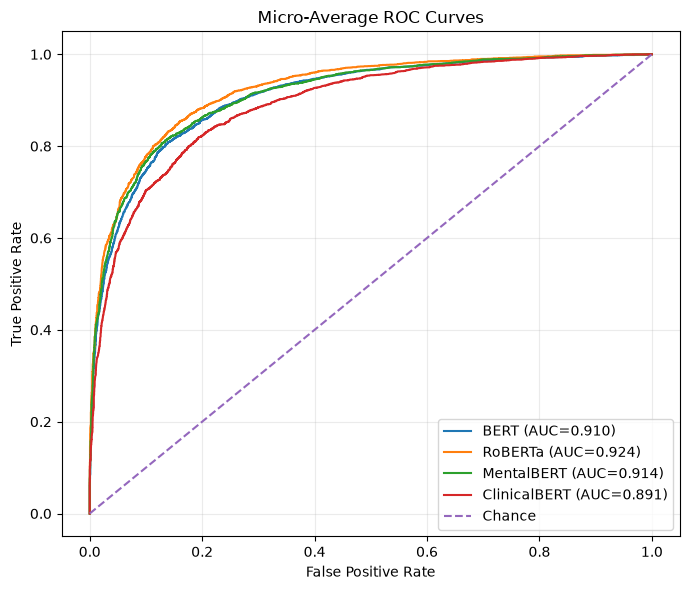

Saved: d:\Thesis_Project\Experiment_2_Transformer-Based Emotion_Classification\outputs\final_per_label_analysis\roc_curves\micro_average_roc_comparison.png


In [353]:
# ============================================================
# EXPERIMENT 2 — PHASE 15 — CELL 16
# MICRO-AVERAGE ROC CURVES
# ============================================================

plt.figure(
    figsize=(
        7,
        6
    )
)


for model_name in FINAL_MODEL_ORDER:

    y_true = (
        phase15_arrays[
            model_name
        ][
            "y_true"
        ]
    )

    probabilities = (
        phase15_arrays[
            model_name
        ][
            "probabilities"
        ]
    )

    micro_fpr, micro_tpr, _ = (
        roc_curve(
            y_true.ravel(),
            probabilities.ravel()
        )
    )

    micro_auc = (
        roc_auc_score(
            y_true,
            probabilities,
            average="micro"
        )
    )

    plt.plot(
        micro_fpr,
        micro_tpr,
        label=(
            f"{model_name} "
            f"(AUC={micro_auc:.3f})"
        )
    )


plt.plot(
    [
        0,
        1
    ],
    [
        0,
        1
    ],
    linestyle="--",
    label="Chance"
)


plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "Micro-Average ROC Curves"
)

plt.legend(
    loc="lower right"
)

plt.grid(
    alpha=0.25
)

plt.tight_layout()


MICRO_ROC_PATH = (
    PHASE15_ROC_DIR
    / "micro_average_roc_comparison.png"
)


plt.savefig(
    MICRO_ROC_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()


print(
    "Saved:",
    MICRO_ROC_PATH
)

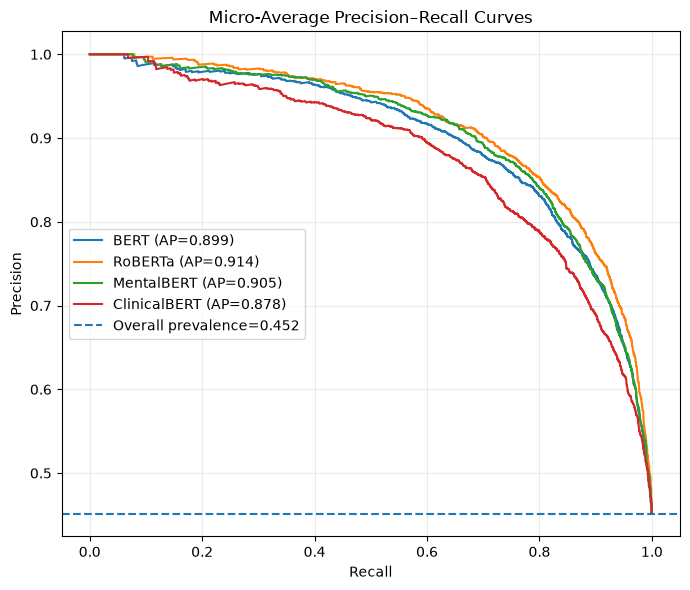

Saved: d:\Thesis_Project\Experiment_2_Transformer-Based Emotion_Classification\outputs\final_per_label_analysis\pr_curves\micro_average_pr_comparison.png


In [354]:
# ============================================================
# EXPERIMENT 2 — PHASE 15 — CELL 17
# MICRO-AVERAGE PRECISION-RECALL CURVES
# ============================================================

plt.figure(
    figsize=(
        7,
        6
    )
)


micro_prevalence = (
    phase15_reference_targets
    .mean()
)


for model_name in FINAL_MODEL_ORDER:

    y_true = (
        phase15_arrays[
            model_name
        ][
            "y_true"
        ]
    )

    probabilities = (
        phase15_arrays[
            model_name
        ][
            "probabilities"
        ]
    )

    micro_precision, micro_recall, _ = (
        precision_recall_curve(
            y_true.ravel(),
            probabilities.ravel()
        )
    )

    micro_ap = (
        average_precision_score(
            y_true,
            probabilities,
            average="micro"
        )
    )

    plt.plot(
        micro_recall,
        micro_precision,
        label=(
            f"{model_name} "
            f"(AP={micro_ap:.3f})"
        )
    )


plt.axhline(
    y=micro_prevalence,
    linestyle="--",
    label=(
        f"Overall prevalence="
        f"{micro_prevalence:.3f}"
    )
)


plt.xlabel(
    "Recall"
)

plt.ylabel(
    "Precision"
)

plt.title(
    "Micro-Average Precision–Recall Curves"
)

plt.legend(
    loc="best"
)

plt.grid(
    alpha=0.25
)

plt.tight_layout()


MICRO_PR_PATH = (
    PHASE15_PR_DIR
    / "micro_average_pr_comparison.png"
)


plt.savefig(
    MICRO_PR_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()


print(
    "Saved:",
    MICRO_PR_PATH
)

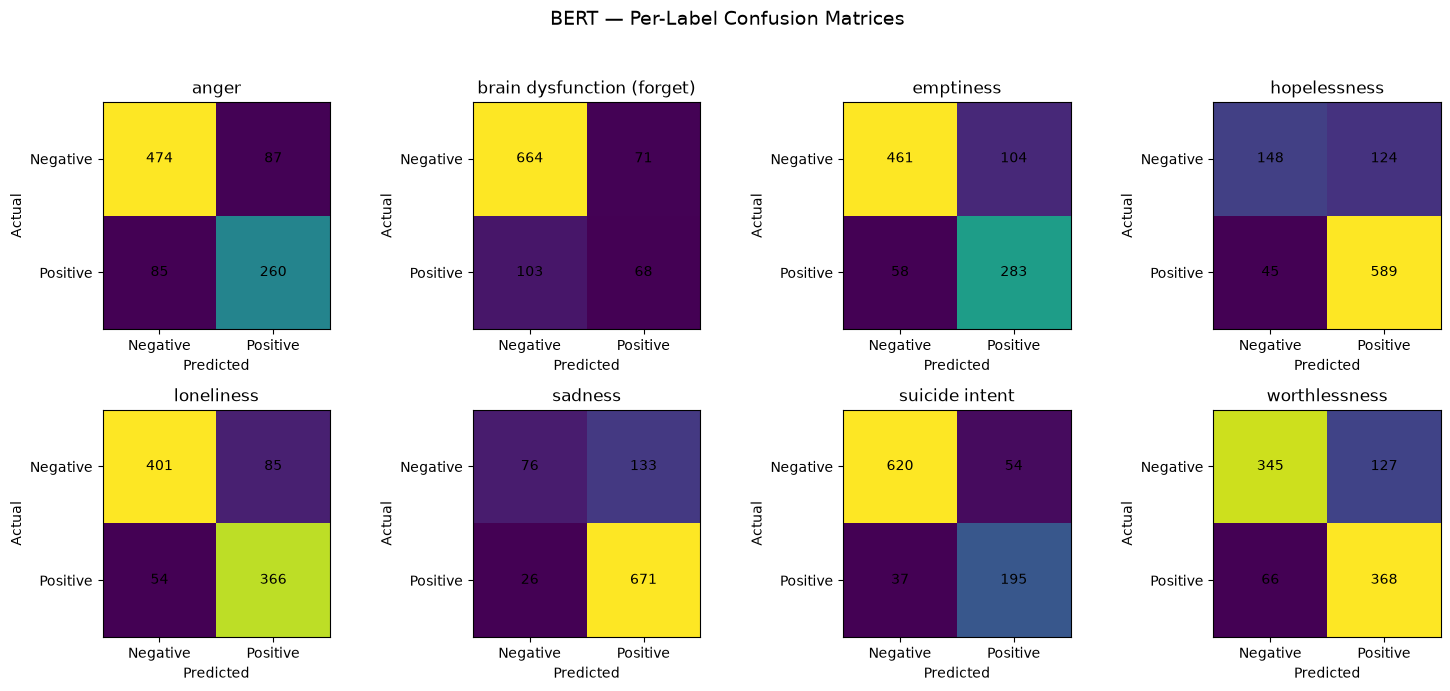

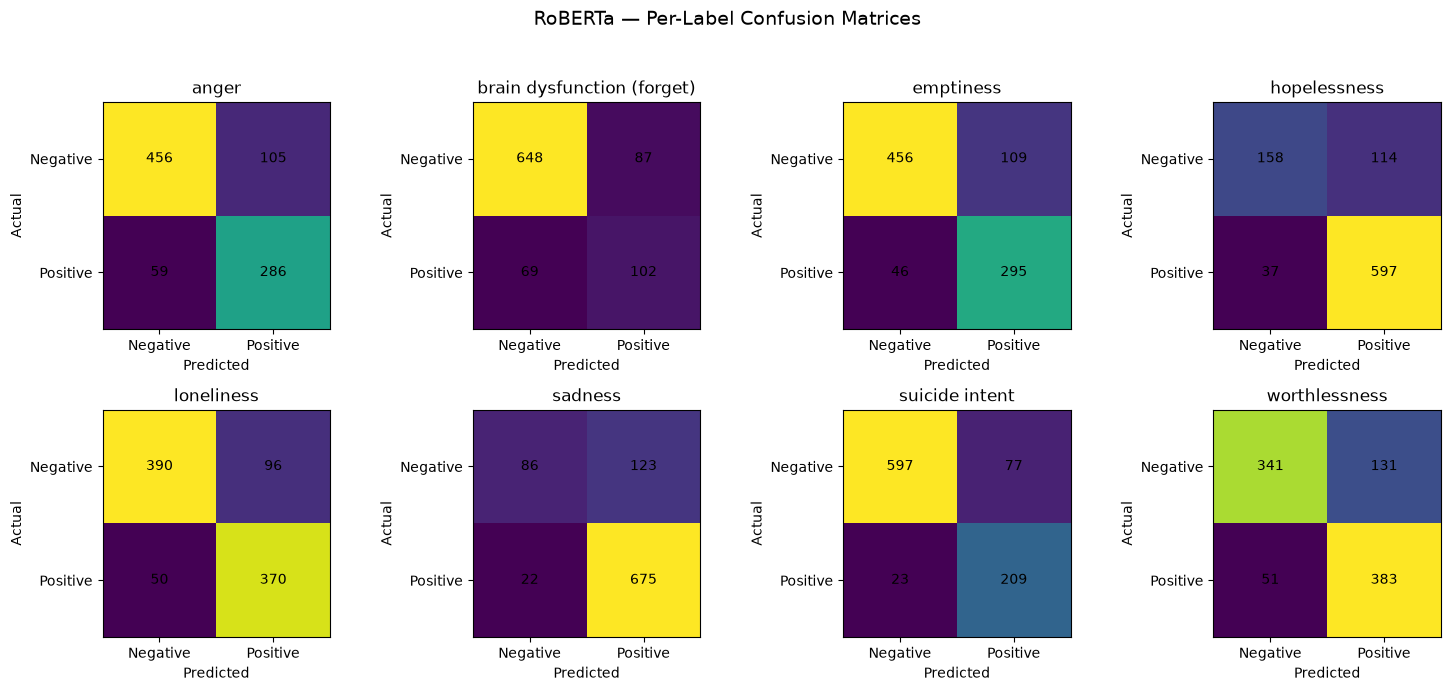

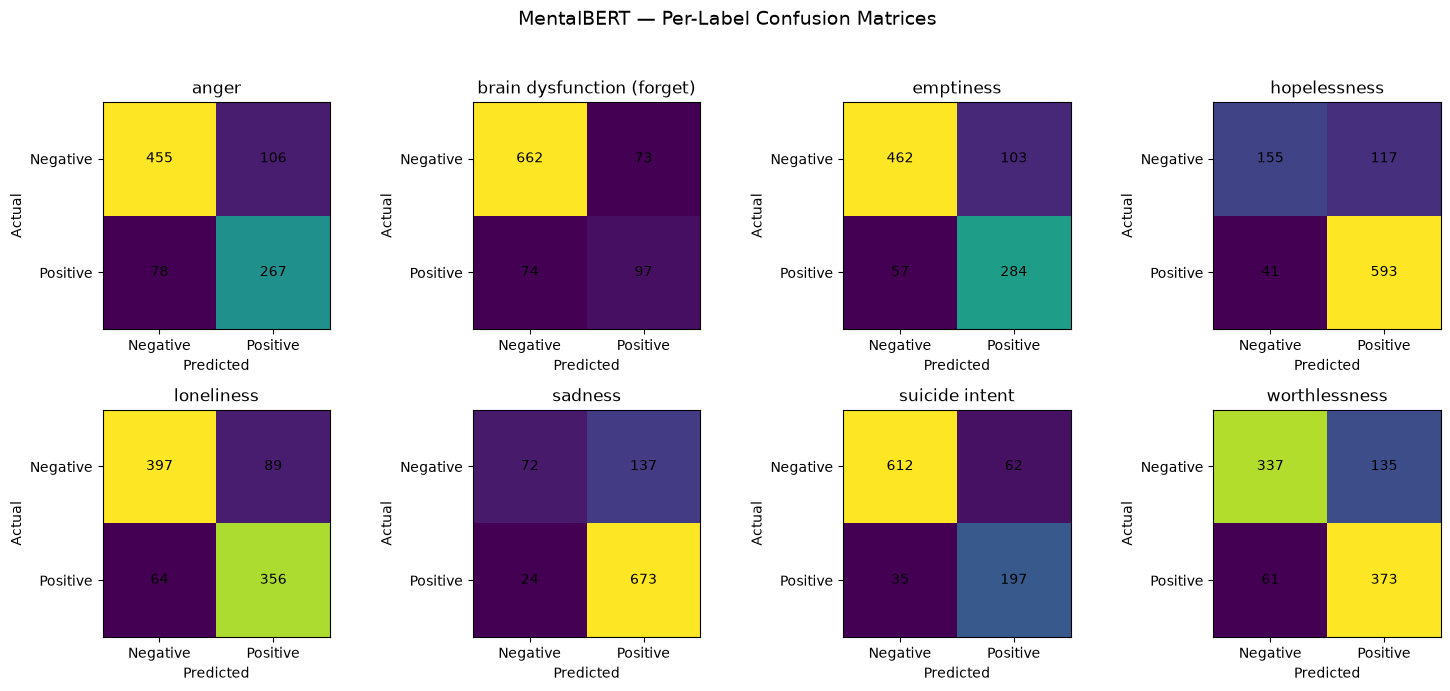

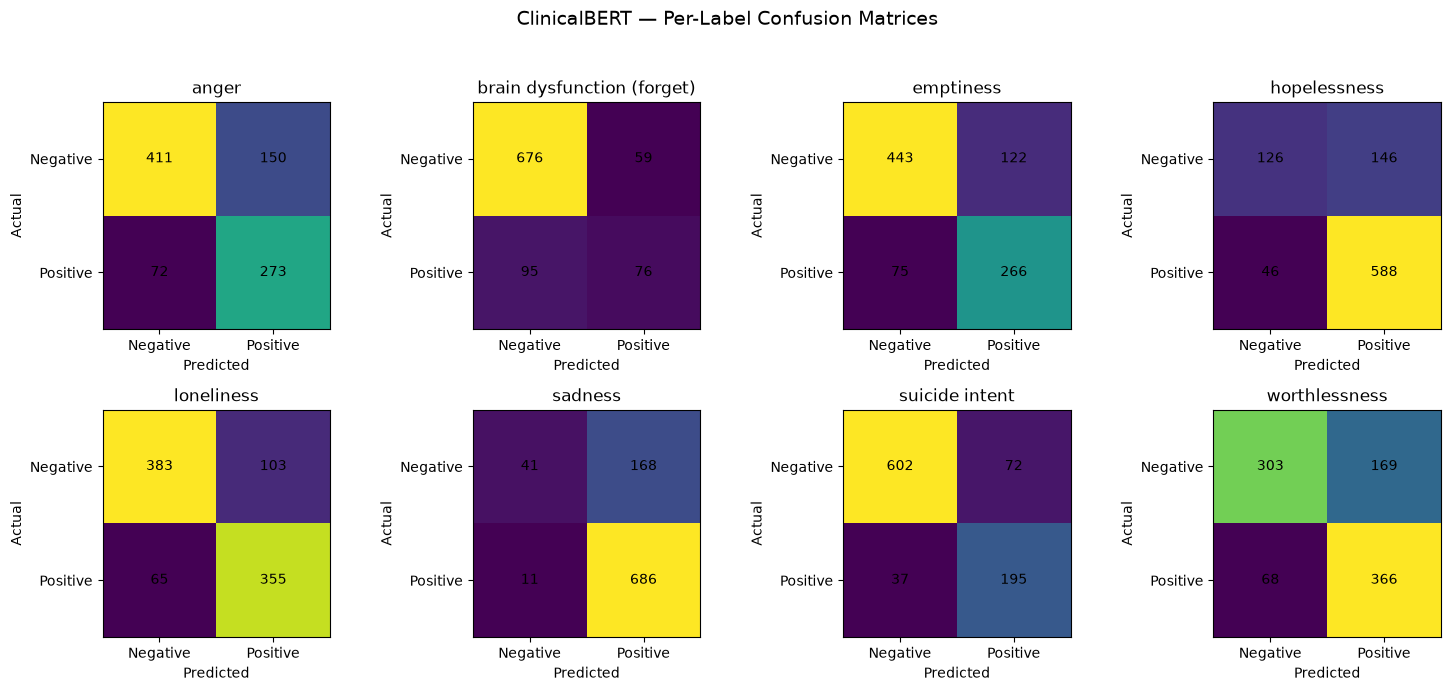

Confusion-matrix figures saved.


In [ ]:
# ============================================================
# EXPERIMENT 2 — PHASE 15 — CELL 18
# PER-MODEL CONFUSION MATRICES
# ============================================================

confusion_figure_records = []


for model_name in FINAL_MODEL_ORDER:

    y_true = (
        phase15_arrays[
            model_name
        ][
            "y_true"
        ]
    )

    predictions = (
        phase15_arrays[
            model_name
        ][
            "predictions"
        ]
    )

    fig, axes = plt.subplots(
        2,
        4,
        figsize=(
            15,
            7
        )
    )

    axes = (
        axes.ravel()
    )

    for label_index, label in enumerate(
        MODEL_LABELS
    ):

        matrix = (
            confusion_matrix(
                y_true[
                    :,
                    label_index
                ],
                predictions[
                    :,
                    label_index
                ],
                labels=[
                    0,
                    1
                ]
            )
        )

        ax = (
            axes[
                label_index
            ]
        )

        image_object = ax.imshow(
            matrix
        )

        for row_index in range(
            2
        ):

            for column_index in range(
                2
            ):

                ax.text(
                    column_index,
                    row_index,
                    str(
                        matrix[
                            row_index,
                            column_index
                        ]
                    ),
                    ha="center",
                    va="center"
                )

        ax.set_xticks(
            [
                0,
                1
            ]
        )

        ax.set_yticks(
            [
                0,
                1
            ]
        )

        ax.set_xticklabels(
            [
                "Negative",
                "Positive"
            ]
        )

        ax.set_yticklabels(
            [
                "Negative",
                "Positive"
            ]
        )

        ax.set_xlabel(
            "Predicted"
        )

        ax.set_ylabel(
            "Actual"
        )

        ax.set_title(
            label
        )

    fig.suptitle(
        f"{model_name} — Per-Label Confusion Matrices",
        fontsize=14
    )

    plt.tight_layout(
        rect=[
            0,
            0,
            1,
            0.95
        ]
    )

    safe_model = (
        safe_filename(
            model_name
        )
    )

    figure_path = (
        PHASE15_CM_DIR
        / (
            f"{safe_model}_"
            f"confusion_matrices.png"
        )
    )

    plt.savefig(
        figure_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

    confusion_figure_records.append(
        {
            "Model":
                model_name,

            "Figure":
                str(
                    figure_path
                )
        }
    )


print(
    "Confusion-matrix figures saved."
)

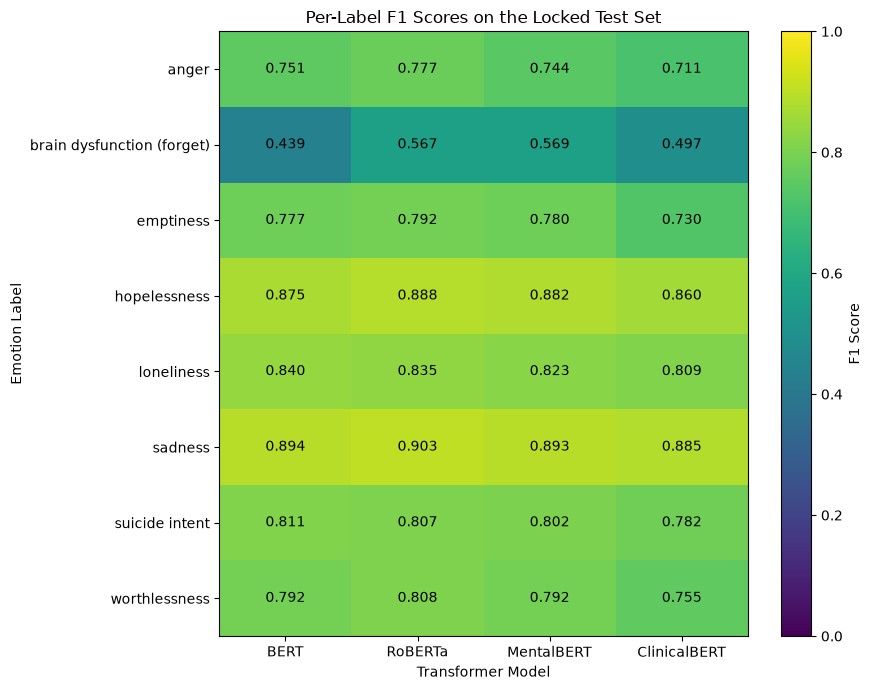

Saved: d:\Thesis_Project\Experiment_2_Transformer-Based Emotion_Classification\outputs\final_per_label_analysis\figures\per_label_f1_heatmap.png


In [356]:
# ============================================================
# EXPERIMENT 2 — PHASE 15 — CELL 19
# PER-LABEL F1 HEATMAP
# ============================================================

f1_heatmap_df = (
    phase15_per_label_df
    .pivot(
        index="Emotion",
        columns="Model",
        values="F1"
    )
    .reindex(
        MODEL_LABELS
    )
    [
        FINAL_MODEL_ORDER
    ]
)


fig, ax = plt.subplots(
    figsize=(
        9,
        7
    )
)


image_object = ax.imshow(
    f1_heatmap_df.values,
    aspect="auto",
    vmin=0,
    vmax=1
)


ax.set_xticks(
    np.arange(
        len(
            FINAL_MODEL_ORDER
        )
    )
)

ax.set_xticklabels(
    FINAL_MODEL_ORDER
)


ax.set_yticks(
    np.arange(
        len(
            MODEL_LABELS
        )
    )
)

ax.set_yticklabels(
    MODEL_LABELS
)


for row_index in range(
    len(
        MODEL_LABELS
    )
):

    for column_index in range(
        len(
            FINAL_MODEL_ORDER
        )
    ):

        value = (
            f1_heatmap_df
            .iloc[
                row_index,
                column_index
            ]
        )

        ax.text(
            column_index,
            row_index,
            f"{value:.3f}",
            ha="center",
            va="center"
        )


ax.set_title(
    "Per-Label F1 Scores on the Locked Test Set"
)

ax.set_xlabel(
    "Transformer Model"
)

ax.set_ylabel(
    "Emotion Label"
)


fig.colorbar(
    image_object,
    ax=ax,
    label="F1 Score"
)


plt.tight_layout()


F1_HEATMAP_PATH = (
    PHASE15_FIGURE_DIR
    / "per_label_f1_heatmap.png"
)


plt.savefig(
    F1_HEATMAP_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()


print(
    "Saved:",
    F1_HEATMAP_PATH
)

In [357]:
# ============================================================
# EXPERIMENT 2 — PHASE 15 — CELL 20
# FALSE-NEGATIVE RATE COMPARISON
# ============================================================

fnr_pivot_df = (
    phase15_per_label_df
    .pivot(
        index="Emotion",
        columns="Model",
        values="FNR"
    )
    .reindex(
        MODEL_LABELS
    )
    [
        FINAL_MODEL_ORDER
    ]
)


display(
    fnr_pivot_df.reset_index()
)


fnr_pivot_df.reset_index().to_csv(
    PHASE15_TABLE_DIR
    / "per_label_false_negative_rate.csv",
    index=False
)

Model,Emotion,BERT,RoBERTa,MentalBERT,ClinicalBERT
0,anger,0.246377,0.171014,0.226087,0.208696
1,brain dysfunction (forget),0.602339,0.403509,0.432749,0.555556
2,emptiness,0.170088,0.134897,0.167155,0.219941
3,hopelessness,0.070978,0.058360,0.064669,0.072555
4,loneliness,0.128571,0.119048,0.152381,0.154762
5,sadness,0.037303,0.031564,0.034433,0.015782
6,suicide intent,0.159483,0.099138,0.150862,0.159483
7,worthlessness,0.152074,0.117512,0.140553,0.156682


In [358]:
# ============================================================
# EXPERIMENT 2 — PHASE 15 — CELL 21
# PUBLICATION FIGURE INDEX
# ============================================================

figure_index_rows = []


for record in roc_figure_records:

    figure_index_rows.append(
        {
            "Figure_Type":
                "Per-label ROC",

            "Subject":
                record[
                    "Emotion"
                ],

            "Path":
                record[
                    "Figure"
                ]
        }
    )


for record in pr_figure_records:

    figure_index_rows.append(
        {
            "Figure_Type":
                "Per-label Precision-Recall",

            "Subject":
                record[
                    "Emotion"
                ],

            "Path":
                record[
                    "Figure"
                ]
        }
    )


for record in confusion_figure_records:

    figure_index_rows.append(
        {
            "Figure_Type":
                "Confusion Matrices",

            "Subject":
                record[
                    "Model"
                ],

            "Path":
                record[
                    "Figure"
                ]
        }
    )


figure_index_rows.extend(
    [
        {
            "Figure_Type":
                "Micro-average ROC",

            "Subject":
                "All models",

            "Path":
                str(
                    MICRO_ROC_PATH
                )
        },

        {
            "Figure_Type":
                "Micro-average Precision-Recall",

            "Subject":
                "All models",

            "Path":
                str(
                    MICRO_PR_PATH
                )
        },

        {
            "Figure_Type":
                "F1 Heatmap",

            "Subject":
                "All models and labels",

            "Path":
                str(
                    F1_HEATMAP_PATH
                )
        }
    ]
)


phase15_figure_index_df = (
    pd.DataFrame(
        figure_index_rows
    )
)


display(
    phase15_figure_index_df
)


phase15_figure_index_df.to_csv(
    PHASE15_DIR
    / "publication_figure_index.csv",
    index=False
)

,Figure_Type,Subject,Path
0,Per-label ROC,anger,d:\Thesis_Project\Experiment_2_Transformer-Based Emotion_Classification\outputs\final_per_label_analysis\roc_curves\roc_anger.png
1,Per-label ROC,brain dysfunction (forget),d:\Thesis_Project\Experiment_2_Transformer-Based Emotion_Classification\outputs\final_per_label_analysis\roc_curves\roc_brain_dysfunction_forget.png
2,Per-label ROC,emptiness,d:\Thesis_Project\Experiment_2_Transformer-Based Emotion_Classification\outputs\final_per_label_analysis\roc_curves\roc_emptiness.png
3,Per-label ROC,hopelessness,d:\Thesis_Project\Experiment_2_Transformer-Based Emotion_Classification\outputs\final_per_label_analysis\roc_curves\roc_hopelessness.png
4,Per-label ROC,loneliness,d:\Thesis_Project\Experiment_2_Transformer-Based Emotion_Classification\outputs\final_per_label_analysis\roc_curves\roc_loneliness.png
5,Per-label ROC,sadness,d:\Thesis_Project\Experiment_2_Transformer-Based Emotion_Classification\outputs\final_per_label_analysis\roc_curves\roc_sadness.png
6,Per-label ROC,suicide intent,d:\Thesis_Project\Experiment_2_Transformer-Based Emotion_Classification\outputs\final_per_label_analysis\roc_curves\roc_suicide_intent.png
7,Per-label ROC,worthlessness,d:\Thesis_Project\Experiment_2_Transformer-Based Emotion_Classification\outputs\final_per_label_analysis\roc_curves\roc_worthlessness.png
8,Per-label Precision-Recall,anger,d:\Thesis_Project\Experiment_2_Transformer-Based Emotion_Classification\outputs\final_per_label_analysis\pr_curves\pr_anger.png
9,Per-label Precision-Recall,brain dysfunction (forget),d:\Thesis_Project\Experiment_2_Transformer-Based Emotion_Classification\outputs\final_per_label_analysis\pr_curves\pr_brain_dysfunction_forget.png


In [359]:
# ============================================================
# EXPERIMENT 2 — PHASE 15 — CELL 22
# FINAL PER-LABEL ANALYSIS MANIFEST
# ============================================================

phase15_manifest = {

    "phase":
        "final_per_label_diagnostic_analysis",

    "test_samples":
        906,

    "number_of_labels":
        NUM_LABELS,

    "labels":
        MODEL_LABELS,

    "models":
        FINAL_MODEL_ORDER,

    "source":
        "frozen Phase 13 final test predictions",

    "configuration_sha256":
        FINAL_CONFIG_HASH,

    "final_test_results_sha256":
        FINAL_TEST_RESULTS_HASH,

    "thresholds":
        {
            model:
                float(
                    FINAL_THRESHOLDS[
                        model
                    ]
                )

            for model
            in FINAL_MODEL_ORDER
        },

    "per_label_metrics":
        [
            "Precision",
            "Recall/Sensitivity",
            "F1",
            "Specificity",
            "NPV",
            "FPR",
            "FNR",
            "Balanced Accuracy",
            "MCC",
            "ROC-AUC",
            "Average Precision"
        ],

    "micro_curve_flattening":
        "descriptive visualization only",

    "inferential_test_on_flattened_decisions":
        False,

    "threshold_retuning":
        False,

    "model_retraining":
        False,

    "checkpoint_selection":
        False
}


PHASE15_MANIFEST_PATH = (
    PHASE15_DIR
    / "phase15_analysis_manifest.json"
)


with open(
    PHASE15_MANIFEST_PATH,
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        phase15_manifest,
        file,
        indent=4,
        ensure_ascii=False
    )


print(
    "Saved:",
    PHASE15_MANIFEST_PATH
)

Saved: d:\Thesis_Project\Experiment_2_Transformer-Based Emotion_Classification\outputs\final_per_label_analysis\phase15_analysis_manifest.json


In [360]:
# ============================================================
# EXPERIMENT 2 — PHASE 15 — CELL 23
# POST-ANALYSIS LOCK CHECK
# ============================================================

post_phase15_config_hash = (
    sha256_file(
        FINAL_CONFIGURATION_JSON
    )
)

post_phase15_test_hash = (
    sha256_file(
        FINAL_TEST_COMPARISON_PATH
    )
)


PHASE15_CONFIG_HASH_MATCH = (
    post_phase15_config_hash
    ==
    FINAL_CONFIG_HASH
)

PHASE15_TEST_HASH_MATCH = (
    post_phase15_test_hash
    ==
    FINAL_TEST_RESULTS_HASH
)


print("=" * 82)
print("POST-ANALYSIS LOCK CHECK")
print("=" * 82)

print(
    "Configuration unchanged:",
    PHASE15_CONFIG_HASH_MATCH
)

print(
    "Test results unchanged :",
    PHASE15_TEST_HASH_MATCH
)

print("=" * 82)


assert PHASE15_CONFIG_HASH_MATCH
assert PHASE15_TEST_HASH_MATCH

POST-ANALYSIS LOCK CHECK
Configuration unchanged: True
Test results unchanged : True


In [361]:
# ============================================================
# EXPERIMENT 2 — PHASE 15 — CELL 24
# FINAL PHASE 15 VERIFICATION
# ============================================================

phase15_checks = {

    "Four models analyzed":
        len(
            phase15_per_label_results
        ) == 4,

    "Eight emotion labels analyzed":
        len(
            MODEL_LABELS
        ) == 8,

    "Total per-label rows = 32":
        len(
            phase15_per_label_df
        ) == 32,

    "All frozen predictions reproduced":
        prediction_reproduction_df[
            "Prediction_Reproduced"
        ].all(),

    "All F1 scores finite":
        np.isfinite(
            phase15_per_label_df[
                "F1"
            ]
        ).all(),

    "All ROC-AUC scores finite":
        np.isfinite(
            phase15_per_label_df[
                "ROC_AUC"
            ]
        ).all(),

    "All Average Precision scores finite":
        np.isfinite(
            phase15_per_label_df[
                "Average_Precision"
            ]
        ).all(),

    "Eight ROC figures created":
        len(
            roc_figure_records
        ) == 8,

    "Eight PR figures created":
        len(
            pr_figure_records
        ) == 8,

    "Four confusion-matrix figures created":
        len(
            confusion_figure_records
        ) == 4,

    "Micro ROC figure exists":
        MICRO_ROC_PATH.exists(),

    "Micro PR figure exists":
        MICRO_PR_PATH.exists(),

    "F1 heatmap exists":
        F1_HEATMAP_PATH.exists(),

    "No threshold retuning":
        phase15_manifest[
            "threshold_retuning"
        ] is False,

    "No model retraining":
        phase15_manifest[
            "model_retraining"
        ] is False,

    "No flattened inferential analysis":
        phase15_manifest[
            "inferential_test_on_flattened_decisions"
        ] is False,

    "Configuration unchanged":
        PHASE15_CONFIG_HASH_MATCH,

    "Final test results unchanged":
        PHASE15_TEST_HASH_MATCH,

    "Analysis manifest exists":
        PHASE15_MANIFEST_PATH.exists()
}


print("=" * 88)
print("PHASE 15 — FINAL VERIFICATION")
print("=" * 88)

phase15_passed = True


for check_name, status in (
    phase15_checks.items()
):

    print(
        f"{check_name:<62}: "
        f"{'PASS' if status else 'FAIL'}"
    )

    if not status:

        phase15_passed = False


print("=" * 88)


if phase15_passed:

    print(
        "PHASE 15 STATUS: PASSED"
    )

    print(
        "Final per-label diagnostic analysis "
        "and publication figures are complete."
    )

    print(
        "All analyses used frozen test predictions."
    )

    print(
        "No post-test model modification was performed."
    )

else:

    print(
        "PHASE 15 STATUS: REVIEW REQUIRED"
    )


print("=" * 88)

PHASE 15 — FINAL VERIFICATION
Four models analyzed                                          : PASS
Eight emotion labels analyzed                                 : PASS
Total per-label rows = 32                                     : PASS
All frozen predictions reproduced                             : PASS
All F1 scores finite                                          : PASS
All ROC-AUC scores finite                                     : PASS
All Average Precision scores finite                           : PASS
Eight ROC figures created                                     : PASS
Eight PR figures created                                      : PASS
Four confusion-matrix figures created                         : PASS
Micro ROC figure exists                                       : PASS
Micro PR figure exists                                        : PASS
F1 heatmap exists                                             : PASS
No threshold retuning                                         : PASS
No m

# PHASE 16 — Structured Error Analysis

## Objective

This phase performs a structured post-hoc error analysis of the frozen final test predictions generated in Phase 13.

No model is retrained and no threshold, hyperparameter, checkpoint, or architecture is modified.

## Analyses

The error analysis examines:

1. Sample-level exact-match failures
2. Number of incorrect label decisions per sample
3. False-positive and false-negative errors
4. Performance by true label cardinality
5. Samples that are difficult for multiple models
6. Errors shared by all four models
7. Pairwise prediction disagreement
8. High-confidence false-positive and false-negative predictions
9. Per-label false-negative and false-positive patterns
10. Model agreement and disagreement on difficult samples

## Error Unit

A sample-level error is analyzed using the complete eight-label prediction vector.

Individual label errors are also reported descriptively, but they are not treated as statistically independent observations.

## Important Methodological Rule

The frozen test predictions are used only for interpretation and reporting.

The results of this phase cannot be used to:

- retrain a model,
- change a threshold,
- select a new checkpoint,
- change an architecture,
- modify hyperparameters,
- or repeat the final test evaluation with a modified configuration.

In [362]:
# ============================================================
# EXPERIMENT 2 — PHASE 16 — CELL 1
# ERROR ANALYSIS DIRECTORIES
# ============================================================

PHASE16_DIR = (
    OUTPUT_DIR
    / "structured_error_analysis"
)

PHASE16_TABLE_DIR = (
    PHASE16_DIR
    / "tables"
)

PHASE16_FIGURE_DIR = (
    PHASE16_DIR
    / "figures"
)

for directory in [
    PHASE16_DIR,
    PHASE16_TABLE_DIR,
    PHASE16_FIGURE_DIR
]:

    directory.mkdir(
        parents=True,
        exist_ok=True
    )


print("=" * 82)
print("PHASE 16 — STRUCTURED ERROR ANALYSIS")
print("=" * 82)

print(
    "Test samples      :",
    len(test_final_df)
)

print(
    "Models            :",
    len(FINAL_MODEL_ORDER)
)

print(
    "Emotion labels    :",
    NUM_LABELS
)

print(
    "Retraining        : NO"
)

print(
    "Threshold tuning  : NO"
)

print("=" * 82)

PHASE 16 — STRUCTURED ERROR ANALYSIS
Test samples      : 906
Models            : 4
Emotion labels    : 8
Retraining        : NO
Threshold tuning  : NO


In [363]:
# ============================================================
# EXPERIMENT 2 — PHASE 16 — CELL 2
# PRE-ANALYSIS LOCK VERIFICATION
# ============================================================

phase16_config_hash = (
    sha256_file(
        FINAL_CONFIGURATION_JSON
    )
)

phase16_test_hash = (
    sha256_file(
        FINAL_TEST_COMPARISON_PATH
    )
)


PHASE16_CONFIG_LOCKED = (
    phase16_config_hash
    ==
    FINAL_CONFIG_HASH
)

PHASE16_TEST_LOCKED = (
    phase16_test_hash
    ==
    FINAL_TEST_RESULTS_HASH
)


print("=" * 82)
print("PRE-ANALYSIS LOCK CHECK")
print("=" * 82)

print(
    "Configuration unchanged :",
    PHASE16_CONFIG_LOCKED
)

print(
    "Test results unchanged  :",
    PHASE16_TEST_LOCKED
)

print("=" * 82)


assert PHASE16_CONFIG_LOCKED
assert PHASE16_TEST_LOCKED

print(
    "LOCK VERIFICATION: PASSED"
)

PRE-ANALYSIS LOCK CHECK
Configuration unchanged : True
Test results unchanged  : True
LOCK VERIFICATION: PASSED


In [364]:
# ============================================================
# EXPERIMENT 2 — PHASE 16 — CELL 3
# ERROR ANALYSIS HELPERS
# ============================================================

def binary_vector_to_labels(
    vector
):

    return [
        MODEL_LABELS[index]

        for index, value
        in enumerate(vector)

        if int(value) == 1
    ]


def binary_vector_to_string(
    vector
):

    labels = (
        binary_vector_to_labels(
            vector
        )
    )

    if len(labels) == 0:
        return "NONE"

    return " | ".join(
        labels
    )


def mask_to_label_string(
    mask
):

    labels = [
        MODEL_LABELS[index]

        for index, value
        in enumerate(mask)

        if bool(value)
    ]

    if len(labels) == 0:
        return "NONE"

    return " | ".join(
        labels
    )


def sample_jaccard_scores(
    y_true,
    y_pred
):

    intersection = (
        (
            y_true == 1
        )
        &
        (
            y_pred == 1
        )
    ).sum(
        axis=1
    )

    union = (
        (
            y_true == 1
        )
        |
        (
            y_pred == 1
        )
    ).sum(
        axis=1
    )

    scores = np.divide(

        intersection,

        union,

        out=np.ones(
            len(
                y_true
            ),
            dtype=float
        ),

        where=(
            union != 0
        )
    )

    return scores


print(
    "Error-analysis helper functions created."
)

Error-analysis helper functions created.


In [365]:
# ============================================================
# EXPERIMENT 2 — PHASE 16 — CELL 4
# MASTER SAMPLE-LEVEL ERROR TABLE
# ============================================================

PHASE16_TEST_ID_ORDER = (
    test_final_df[
        "id"
    ]
    .astype(str)
    .tolist()
)


sample_error_df = (
    test_final_df
    .copy()
)

sample_error_df[
    "id"
] = (
    sample_error_df[
        "id"
    ]
    .astype(str)
)

sample_error_df = (
    sample_error_df
    .set_index(
        "id"
    )
    .loc[
        PHASE16_TEST_ID_ORDER
    ]
    .reset_index()
)


reference_targets = (
    phase15_reference_targets
    .astype(int)
)


sample_error_df[
    "true_label_count"
] = (
    reference_targets.sum(
        axis=1
    )
)


sample_error_df[
    "true_labels"
] = [
    binary_vector_to_string(
        row
    )

    for row
    in reference_targets
]


MODEL_SAFE_NAMES = {
    model_name:
        safe_filename(
            model_name
        )

    for model_name
    in FINAL_MODEL_ORDER
}


for model_name in FINAL_MODEL_ORDER:

    safe_name = (
        MODEL_SAFE_NAMES[
            model_name
        ]
    )

    predictions = (
        phase15_arrays[
            model_name
        ][
            "predictions"
        ]
        .astype(int)
    )

    false_negative_mask = (
        (
            reference_targets == 1
        )
        &
        (
            predictions == 0
        )
    )

    false_positive_mask = (
        (
            reference_targets == 0
        )
        &
        (
            predictions == 1
        )
    )

    label_error_count = (
        (
            reference_targets
            !=
            predictions
        )
        .sum(
            axis=1
        )
    )

    exact_match = (
        label_error_count
        == 0
    ).astype(int)

    sample_error_df[
        f"{safe_name}_pred_labels"
    ] = [
        binary_vector_to_string(
            row
        )

        for row
        in predictions
    ]

    sample_error_df[
        f"{safe_name}_label_errors"
    ] = label_error_count

    sample_error_df[
        f"{safe_name}_false_negatives"
    ] = (
        false_negative_mask
        .sum(
            axis=1
        )
    )

    sample_error_df[
        f"{safe_name}_false_positives"
    ] = (
        false_positive_mask
        .sum(
            axis=1
        )
    )

    sample_error_df[
        f"{safe_name}_fn_labels"
    ] = [
        mask_to_label_string(
            row
        )

        for row
        in false_negative_mask
    ]

    sample_error_df[
        f"{safe_name}_fp_labels"
    ] = [
        mask_to_label_string(
            row
        )

        for row
        in false_positive_mask
    ]

    sample_error_df[
        f"{safe_name}_exact_match"
    ] = exact_match

    sample_error_df[
        f"{safe_name}_jaccard"
    ] = (
        sample_jaccard_scores(
            reference_targets,
            predictions
        )
    )


exact_match_columns = [
    (
        f"{MODEL_SAFE_NAMES[model]}_"
        f"exact_match"
    )

    for model
    in FINAL_MODEL_ORDER
]


error_count_columns = [
    (
        f"{MODEL_SAFE_NAMES[model]}_"
        f"label_errors"
    )

    for model
    in FINAL_MODEL_ORDER
]


sample_error_df[
    "models_exact_match"
] = (
    sample_error_df[
        exact_match_columns
    ]
    .sum(
        axis=1
    )
)


sample_error_df[
    "models_with_exact_match_failure"
] = (
    len(
        FINAL_MODEL_ORDER
    )
    -
    sample_error_df[
        "models_exact_match"
    ]
)


sample_error_df[
    "total_label_errors_across_models"
] = (
    sample_error_df[
        error_count_columns
    ]
    .sum(
        axis=1
    )
)


sample_error_df[
    "all_models_exact_match"
] = (
    sample_error_df[
        "models_exact_match"
    ]
    ==
    len(
        FINAL_MODEL_ORDER
    )
).astype(int)


sample_error_df[
    "all_models_failed_exact_match"
] = (
    sample_error_df[
        "models_exact_match"
    ]
    ==
    0
).astype(int)


print(
    "Master sample-level error table:",
    sample_error_df.shape
)

display(
    sample_error_df.head()
)

Master sample-level error table: (906, 47)


,id,title,post,text,upvotes,date,emotions,label_id,true_label_count,true_labels,...,clinicalbert_false_positives,clinicalbert_fn_labels,clinicalbert_fp_labels,clinicalbert_exact_match,clinicalbert_jaccard,models_exact_match,models_with_exact_match_failure,total_label_errors_across_models,all_models_exact_match,all_models_failed_exact_match
0,w83pst,"I worry the best i can ever do is cope, not heal","On a good day, I can cope with my feelings and the trauma I've experienced. I can try to live a normal life. I've tried many different treatments over the past 5 years, and sometimes I feel like my health has even gotten worse. I have horrible episodes. I definitely don't feel like I've improve...","I worry the best i can ever do is cope, not heal ### On a good day, I can cope with my feelings and the trauma I've experienced. I can try to live a normal life. I've tried many different treatments over the past 5 years, and sometimes I feel like my health has even gotten worse. I have horrible...",105.0,2022-07-25 23:29:55,"[hopelessness, sadness]",10100,2,hopelessness | sadness,...,0,NONE,NONE,1,1.000000,1,3,3,0,0
1,f2234m,I don’t know what to do:(,He tells me it’s only my fault and I don’t know what to do I just listen:( I cry all the time and I do anything I can that doesn’t make him mad or upset,I don’t know what to do:( ### He tells me it’s only my fault and I don’t know what to do I just listen:( I cry all the time and I do anything I can that doesn’t make him mad or upset,1.0,2020-02-11 03:08:39,"[hopelessness, sadness]",10100,2,hopelessness | sadness,...,2,NONE,anger | worthlessness,0,0.500000,2,2,4,0,0
2,17d3zn2,I want to improve my self worth,I just wish that I could look at myself and see someone that is deserving of love and of life. I always feel like I am a waste of space and that I shouldn't even try. My whole life I have always felt like I was nothing in comparison to others. People tell me that I am beautiful and I am talented...,I want to improve my self worth ### I just wish that I could look at myself and see someone that is deserving of love and of life. I always feel like I am a waste of space and that I shouldn't even try. My whole life I have always felt like I was nothing in comparison to others. People tell me t...,1.0,2023-10-21 14:37:03,"[worthlessness, hopelessness, emptiness, sadness, loneliness, anger]",10111101,6,anger | emptiness | hopelessness | loneliness | sadness | worthlessness,...,0,anger,NONE,0,0.833333,1,3,3,0,0
3,fn48mt,I don't know,I don't know what to do. I don't know how to solve this problem. I don't know what's wrong with me. I don't know what I'm doing wrong. I just don't and it's eating me alive. \n\nThe most random things can trigger a deep feeling of hopelessness which can last for days. After 33 years on this eart...,I don't know ### I don't know what to do. I don't know how to solve this problem. I don't know what's wrong with me. I don't know what I'm doing wrong. I just don't and it's eating me alive. The most random things can trigger a deep feeling of hopelessness which can last for days. After 33 years...,18.0,2020-03-22 18:17:45,"[hopelessness, sadness, worthlessness, loneliness]",11101,4,hopelessness | loneliness | sadness | worthlessness,...,1,NONE,emptiness,0,0.800000,0,4,7,0,1
4,11w2im7,Any coping suggestions for loneliness?,"Please don't tell ""Go meet people"" BS. \n\nI am just using the internet for coping, It's just making me insane. Is there any skill/activity that I can enjoy alone and forget that I am lonely?","Any coping suggestions for loneliness? ### Please don't tell ""Go meet people"" BS. I am just using the internet for coping, It's just making me insane. Is there any skill/activity that I can enjoy alone and forget that I am lonely?",6.0,2023-03-20 00:12:04,[loneliness],1000,1,loneliness,...,3,NONE,emptiness | hopelessness | sadness,0,0.250000,1,3,5,0,0


In [366]:
# ============================================================
# EXPERIMENT 2 — PHASE 16 — CELL 5
# SAMPLE-LEVEL ERROR SUMMARY
# ============================================================

sample_error_summary_rows = []


for model_name in FINAL_MODEL_ORDER:

    safe_name = (
        MODEL_SAFE_NAMES[
            model_name
        ]
    )

    exact_match = (
        sample_error_df[
            f"{safe_name}_exact_match"
        ]
    )

    label_errors = (
        sample_error_df[
            f"{safe_name}_label_errors"
        ]
    )

    false_negatives = (
        sample_error_df[
            f"{safe_name}_false_negatives"
        ]
    )

    false_positives = (
        sample_error_df[
            f"{safe_name}_false_positives"
        ]
    )

    jaccard = (
        sample_error_df[
            f"{safe_name}_jaccard"
        ]
    )

    sample_error_summary_rows.append(
        {
            "Model":
                model_name,

            "Exact_Match_Samples":
                int(
                    exact_match.sum()
                ),

            "Exact_Match_Rate":
                float(
                    exact_match.mean()
                ),

            "Samples_With_Any_Error":
                int(
                    (
                        exact_match == 0
                    ).sum()
                ),

            "Mean_Label_Errors":
                float(
                    label_errors.mean()
                ),

            "Median_Label_Errors":
                float(
                    label_errors.median()
                ),

            "Total_False_Negatives":
                int(
                    false_negatives.sum()
                ),

            "Total_False_Positives":
                int(
                    false_positives.sum()
                ),

            "Mean_Jaccard":
                float(
                    jaccard.mean()
                )
        }
    )


sample_error_summary_df = (
    pd.DataFrame(
        sample_error_summary_rows
    )
)


display(
    sample_error_summary_df
)

,Model,Exact_Match_Samples,Exact_Match_Rate,Samples_With_Any_Error,Mean_Label_Errors,Median_Label_Errors,Total_False_Negatives,Total_False_Positives,Mean_Jaccard
0,BERT,214,0.236203,692,1.389625,1.0,474,785,0.670680
1,RoBERTa,244,0.269316,662,1.323400,1.0,357,842,0.698396
2,MentalBERT,225,0.248344,681,1.386313,1.0,434,822,0.679887
3,ClinicalBERT,157,0.173289,749,1.609272,1.0,469,989,0.635561


In [367]:
# ============================================================
# EXPERIMENT 2 — PHASE 16 — CELL 6
# ERROR BY TRUE LABEL CARDINALITY
# ============================================================

cardinality_rows = []


for cardinality in sorted(
    sample_error_df[
        "true_label_count"
    ].unique()
):

    subset = (
        sample_error_df[
            sample_error_df[
                "true_label_count"
            ] == cardinality
        ]
    )

    row = {

        "True_Label_Count":
            int(
                cardinality
            ),

        "Samples":
            len(
                subset
            )
    }

    for model_name in FINAL_MODEL_ORDER:

        safe_name = (
            MODEL_SAFE_NAMES[
                model_name
            ]
        )

        row[
            f"{model_name}_Exact_Match"
        ] = float(
            subset[
                f"{safe_name}_exact_match"
            ].mean()
        )

        row[
            f"{model_name}_Mean_Label_Errors"
        ] = float(
            subset[
                f"{safe_name}_label_errors"
            ].mean()
        )

        row[
            f"{model_name}_Mean_Jaccard"
        ] = float(
            subset[
                f"{safe_name}_jaccard"
            ].mean()
        )

    cardinality_rows.append(
        row
    )


error_by_cardinality_df = (
    pd.DataFrame(
        cardinality_rows
    )
)


display(
    error_by_cardinality_df
)


,True_Label_Count,Samples,BERT_Exact_Match,BERT_Mean_Label_Errors,BERT_Mean_Jaccard,RoBERTa_Exact_Match,RoBERTa_Mean_Label_Errors,RoBERTa_Mean_Jaccard,MentalBERT_Exact_Match,MentalBERT_Mean_Label_Errors,MentalBERT_Mean_Jaccard,ClinicalBERT_Exact_Match,ClinicalBERT_Mean_Label_Errors,ClinicalBERT_Mean_Jaccard
0,1,181,0.265193,1.453039,0.479282,0.342541,1.287293,0.544620,0.298343,1.419890,0.508748,0.165746,1.834254,0.409853
1,2,136,0.191176,1.433824,0.578676,0.250000,1.316176,0.628624,0.213235,1.419118,0.589828,0.183824,1.573529,0.560207
2,3,126,0.182540,1.484127,0.650841,0.158730,1.579365,0.644586,0.222222,1.539683,0.654157,0.079365,1.960317,0.574320
3,4,158,0.240506,1.360759,0.736611,0.227848,1.405063,0.744470,0.202532,1.417722,0.733009,0.164557,1.563291,0.705350
4,5,126,0.285714,1.317460,0.779837,0.285714,1.404762,0.777305,0.277778,1.309524,0.780263,0.230159,1.444444,0.764645
5,6,100,0.160000,1.450000,0.781786,0.230000,1.270000,0.810714,0.180000,1.390000,0.792321,0.120000,1.420000,0.788095
6,7,51,0.254902,1.137255,0.845238,0.313725,0.843137,0.886204,0.254902,1.058824,0.855742,0.215686,1.274510,0.825630
7,8,28,0.500000,1.071429,0.866071,0.607143,0.678571,0.915179,0.571429,1.071429,0.866071,0.500000,1.035714,0.870536


In [368]:
# ============================================================
# EXPERIMENT 2 — PHASE 16 — CELL 7
# HARDEST TEST SAMPLES
# ============================================================

hard_sample_df = (
    sample_error_df
    .sort_values(
        [
            "models_with_exact_match_failure",
            "total_label_errors_across_models"
        ],
        ascending=[
            False,
            False
        ]
    )
    .copy()
)


hard_sample_display_df = (
    hard_sample_df[
        [
            "id",
            "true_label_count",
            "true_labels",
            "models_exact_match",
            "models_with_exact_match_failure",
            "total_label_errors_across_models",
            "bert_pred_labels",
            "roberta_pred_labels",
            "mentalbert_pred_labels",
            "clinicalbert_pred_labels",
            "text"
        ]
    ]
    .head(
        20
    )
    .copy()
)


hard_sample_display_df[
    "text"
] = (
    hard_sample_display_df[
        "text"
    ]
    .astype(str)
    .str.slice(
        0,
        250
    )
)


display(
    hard_sample_display_df
)

,id,true_label_count,true_labels,models_exact_match,models_with_exact_match_failure,total_label_errors_across_models,bert_pred_labels,roberta_pred_labels,mentalbert_pred_labels,clinicalbert_pred_labels,text
699,15b612t,2,hopelessness | sadness,0,4,22,anger | brain dysfunction (forget) | emptiness | hopelessness | loneliness | sadness | suicide intent | worthlessness,brain dysfunction (forget) | emptiness | hopelessness | loneliness | sadness | suicide intent | worthlessness,anger | brain dysfunction (forget) | emptiness | hopelessness | loneliness | sadness | suicide intent | worthlessness,anger | emptiness | hopelessness | loneliness | sadness | suicide intent | worthlessness,"My girlfriend is the only thing keeping me going ### I have been going in and out of depressive episodes for about 4 years, and I’m so fucking over it. I just want to be dead at this point because every time I get better I eventually become so much f"
352,ytnsnb,1,sadness,0,4,20,anger | emptiness | hopelessness | loneliness | sadness | worthlessness,anger | emptiness | hopelessness | loneliness | sadness | suicide intent | worthlessness,anger | hopelessness | loneliness | sadness | worthlessness,anger | emptiness | hopelessness | loneliness | sadness | worthlessness,I'm tired of being me ### Who else is tired of being themselves? I wish I was someone else. Someone with a better life who was happier. I would not want my life.
689,16vdg97,8,anger | brain dysfunction (forget) | emptiness | hopelessness | loneliness | sadness | suicide intent | worthlessness,0,4,19,hopelessness | loneliness | sadness,brain dysfunction (forget) | hopelessness | sadness,brain dysfunction (forget) | hopelessness | sadness,brain dysfunction (forget) | hopelessness | sadness | worthlessness,"One thing no one mentions about death ### Is how perpetual the weight of the loss can feel. It’s like riding an emotional roller coaster the rest of your life. Months can go by and you are fine and things feel as normal and then boom, there’s a remin"
259,kg44cr,4,emptiness | sadness | suicide intent | worthlessness,0,4,18,anger | brain dysfunction (forget) | emptiness | hopelessness | loneliness | sadness | worthlessness,anger | brain dysfunction (forget) | emptiness | hopelessness | loneliness | sadness | suicide intent | worthlessness,anger | brain dysfunction (forget) | emptiness | hopelessness | loneliness | sadness | worthlessness,anger | hopelessness | sadness | worthlessness,Deleted my Instagram account. ### Sick of the fake happiness.
270,11xek50,6,anger | emptiness | hopelessness | loneliness | sadness | worthlessness,0,4,18,hopelessness | sadness,hopelessness | sadness,sadness,hopelessness | sadness | suicide intent,Is this ok? ### I'm currently doing all my assignments so naturally I'm a little stressed. I feel like this is normal so I shrug it off and continue with life. I'm always hiding my emotions and just doing what I'm told without speaking out. However r
843,kgz6ct,1,brain dysfunction (forget),0,4,18,emptiness | hopelessness | loneliness | sadness,emptiness | loneliness | sadness,emptiness | hopelessness | loneliness | sadness,emptiness | loneliness | sadness,"Has anyone else forgotten what’s it’s like to have friends? ### It’s been so long since I’ve been with any of my friends. I just want to hang out with them, text them, play games with them, have a best friend to go through life with. I got none of th"
173,143mpu6,1,loneliness,0,4,17,emptiness | hopelessness | loneliness | sadness | worthlessness,emptiness | hopelessness | loneliness | sadness | worthlessness,emptiness | hopelessness | loneliness | sadness | worthlessness,brain dysfunction (forget) | emptiness | hopelessness | loneliness | sadness | worthlessness,Feeling horrible because I self isolate when I'm going thru hell mentally ### As the title says I feel so bad for my friends and family when I get into this mood. I literally told my friend I had something to tell her(it was 4am) went to sleep and wo
377,17cs

In [369]:
# ============================================================
# EXPERIMENT 2 — PHASE 16 — CELL 8
# CROSS-MODEL EXACT-MATCH AGREEMENT
# ============================================================

exact_match_agreement_df = (
    sample_error_df[
        "models_exact_match"
    ]
    .value_counts()
    .sort_index()
    .rename_axis(
        "Models_With_Exact_Match"
    )
    .reset_index(
        name="Samples"
    )
)


exact_match_agreement_df[
    "Percentage"
] = (
    exact_match_agreement_df[
        "Samples"
    ]
    /
    len(
        sample_error_df
    )
    *
    100
)


display(
    exact_match_agreement_df
)


print(
    "Samples correctly classified exactly by all 4 models:",
    int(
        sample_error_df[
            "all_models_exact_match"
        ].sum()
    )
)


print(
    "Samples where all 4 models failed exact match:",
    int(
        sample_error_df[
            "all_models_failed_exact_match"
        ].sum()
    )
)

,Models_With_Exact_Match,Samples,Percentage
0,0,523,57.726269
1,1,138,15.231788
2,2,88,9.713024
3,3,102,11.258278
4,4,55,6.070640


Samples correctly classified exactly by all 4 models: 55
Samples where all 4 models failed exact match: 523


In [370]:
# ============================================================
# EXPERIMENT 2 — PHASE 16 — CELL 9
# SHARED FALSE NEGATIVES
# ============================================================

shared_fn_rows = []


for label_index, label in enumerate(
    MODEL_LABELS
):

    true_positive_samples = (
        reference_targets[
            :,
            label_index
        ]
        == 1
    )

    miss_counts = np.zeros(
        len(
            reference_targets
        ),
        dtype=int
    )

    for model_name in FINAL_MODEL_ORDER:

        predictions = (
            phase15_arrays[
                model_name
            ][
                "predictions"
            ]
        )

        miss_counts += (
            true_positive_samples
            &
            (
                predictions[
                    :,
                    label_index
                ]
                == 0
            )
        ).astype(int)

    support = int(
        true_positive_samples.sum()
    )

    shared_fn_rows.append(
        {
            "Emotion":
                label,

            "Support":
                support,

            "Missed_By_All_4":
                int(
                    (
                        true_positive_samples
                        &
                        (
                            miss_counts == 4
                        )
                    ).sum()
                ),

            "Missed_By_At_Least_3":
                int(
                    (
                        true_positive_samples
                        &
                        (
                            miss_counts >= 3
                        )
                    ).sum()
                ),

            "Missed_By_At_Least_2":
                int(
                    (
                        true_positive_samples
                        &
                        (
                            miss_counts >= 2
                        )
                    ).sum()
                ),

            "Missed_By_Any_Model":
                int(
                    (
                        true_positive_samples
                        &
                        (
                            miss_counts >= 1
                        )
                    ).sum()
                )
        }
    )


shared_false_negative_df = (
    pd.DataFrame(
        shared_fn_rows
    )
)


shared_false_negative_df[
    "All_4_Miss_Rate"
] = (
    shared_false_negative_df[
        "Missed_By_All_4"
    ]
    /
    shared_false_negative_df[
        "Support"
    ]
)


display(
    shared_false_negative_df
)

,Emotion,Support,Missed_By_All_4,Missed_By_At_Least_3,Missed_By_At_Least_2,Missed_By_Any_Model,All_4_Miss_Rate
0,anger,345,34,59,80,121,0.098551
1,brain dysfunction (forget),171,44,71,104,122,0.257310
2,emptiness,341,29,43,69,95,0.085044
3,hopelessness,634,13,25,44,87,0.020505
4,loneliness,420,22,51,64,96,0.052381
5,sadness,697,4,11,23,45,0.005739
6,suicide intent,232,14,29,36,53,0.060345
7,worthlessness,434,17,44,70,115,0.039171


In [371]:
# ============================================================
# EXPERIMENT 2 — PHASE 16 — CELL 10
# SHARED FALSE POSITIVES
# ============================================================

shared_fp_rows = []


for label_index, label in enumerate(
    MODEL_LABELS
):

    true_negative_samples = (
        reference_targets[
            :,
            label_index
        ]
        == 0
    )

    fp_counts = np.zeros(
        len(
            reference_targets
        ),
        dtype=int
    )

    for model_name in FINAL_MODEL_ORDER:

        predictions = (
            phase15_arrays[
                model_name
            ][
                "predictions"
            ]
        )

        fp_counts += (
            true_negative_samples
            &
            (
                predictions[
                    :,
                    label_index
                ]
                == 1
            )
        ).astype(int)

    negative_support = int(
        true_negative_samples.sum()
    )

    shared_fp_rows.append(
        {
            "Emotion":
                label,

            "Negative_Support":
                negative_support,

            "False_Positive_By_All_4":
                int(
                    (
                        true_negative_samples
                        &
                        (
                            fp_counts == 4
                        )
                    ).sum()
                ),

            "False_Positive_By_At_Least_3":
                int(
                    (
                        true_negative_samples
                        &
                        (
                            fp_counts >= 3
                        )
                    ).sum()
                ),

            "False_Positive_By_At_Least_2":
                int(
                    (
                        true_negative_samples
                        &
                        (
                            fp_counts >= 2
                        )
                    ).sum()
                ),

            "False_Positive_By_Any_Model":
                int(
                    (
                        true_negative_samples
                        &
                        (
                            fp_counts >= 1
                        )
                    ).sum()
                )
        }
    )


shared_false_positive_df = (
    pd.DataFrame(
        shared_fp_rows
    )
)


shared_false_positive_df[
    "All_4_FP_Rate"
] = (
    shared_false_positive_df[
        "False_Positive_By_All_4"
    ]
    /
    shared_false_positive_df[
        "Negative_Support"
    ]
)


display(
    shared_false_positive_df
)

,Emotion,Negative_Support,False_Positive_By_All_4,False_Positive_By_At_Least_3,False_Positive_By_At_Least_2,False_Positive_By_Any_Model,All_4_FP_Rate
0,anger,561,46,78,121,203,0.081996
1,brain dysfunction (forget),735,21,49,80,140,0.028571
2,emptiness,565,58,86,117,177,0.102655
3,hopelessness,272,79,102,131,189,0.290441
4,loneliness,486,42,72,101,158,0.086420
5,sadness,209,91,133,154,183,0.435407
6,suicide intent,674,31,50,68,116,0.045994
7,worthlessness,472,76,115,153,218,0.161017


In [372]:
# ============================================================
# EXPERIMENT 2 — PHASE 16 — CELL 11
# LABEL-LEVEL ERROR BURDEN
# ============================================================

label_error_burden_rows = []


for label in MODEL_LABELS:

    label_metrics = (
        phase15_per_label_df[
            phase15_per_label_df[
                "Emotion"
            ] == label
        ]
    )

    fn_row = (
        shared_false_negative_df[
            shared_false_negative_df[
                "Emotion"
            ] == label
        ]
        .iloc[0]
    )

    fp_row = (
        shared_false_positive_df[
            shared_false_positive_df[
                "Emotion"
            ] == label
        ]
        .iloc[0]
    )

    label_error_burden_rows.append(
        {
            "Emotion":
                label,

            "Mean_F1_Across_Models":
                float(
                    label_metrics[
                        "F1"
                    ].mean()
                ),

            "Minimum_F1":
                float(
                    label_metrics[
                        "F1"
                    ].min()
                ),

            "Maximum_F1":
                float(
                    label_metrics[
                        "F1"
                    ].max()
                ),

            "Mean_FNR":
                float(
                    label_metrics[
                        "FNR"
                    ].mean()
                ),

            "Mean_FPR":
                float(
                    label_metrics[
                        "FPR"
                    ].mean()
                ),

            "Missed_By_All_4":
                int(
                    fn_row[
                        "Missed_By_All_4"
                    ]
                ),

            "FP_By_All_4":
                int(
                    fp_row[
                        "False_Positive_By_All_4"
                    ]
                )
        }
    )


label_error_burden_df = (
    pd.DataFrame(
        label_error_burden_rows
    )
    .sort_values(
        "Mean_F1_Across_Models",
        ascending=True
    )
)


display(
    label_error_burden_df
)

,Emotion,Mean_F1_Across_Models,Minimum_F1,Maximum_F1,Mean_FNR,Mean_FPR,Missed_By_All_4,FP_By_All_4
1,brain dysfunction (forget),0.517756,0.438710,0.568915,0.498538,0.098639,44,21
0,anger,0.745822,0.710938,0.777174,0.213043,0.199643,34,46
2,emptiness,0.769851,0.729767,0.791946,0.173021,0.193805,29,58
7,worthlessness,0.786904,0.755418,0.808017,0.141705,0.297669,17,76
6,suicide intent,0.800442,0.781563,0.810811,0.142241,0.098294,14,31
4,loneliness,0.826851,0.808656,0.840413,0.138690,0.191872,22,42
3,hopelessness,0.876089,0.859649,0.887732,0.066640,0.460478,13,79
5,sadness,0.893709,0.884591,0.903010,0.029770,0.671053,4,91


In [373]:
# ============================================================
# EXPERIMENT 2 — PHASE 16 — CELL 12
# PAIRWISE MODEL DISAGREEMENT
# ============================================================

sample_disagreement_matrix = pd.DataFrame(

    0.0,

    index=FINAL_MODEL_ORDER,

    columns=FINAL_MODEL_ORDER
)


label_disagreement_matrix = pd.DataFrame(

    0.0,

    index=FINAL_MODEL_ORDER,

    columns=FINAL_MODEL_ORDER
)


for model_a in FINAL_MODEL_ORDER:

    pred_a = (
        phase15_arrays[
            model_a
        ][
            "predictions"
        ]
    )

    for model_b in FINAL_MODEL_ORDER:

        pred_b = (
            phase15_arrays[
                model_b
            ][
                "predictions"
        ]
    )

    sample_disagreement = (
        np.any(
            pred_a
            !=
            pred_b,
            axis=1
        )
        .mean()
    )

    label_disagreement = (
        (
            pred_a
            !=
            pred_b
        )
        .mean()
    )

    sample_disagreement_matrix.loc[
        model_a,
        model_b
    ] = sample_disagreement

    label_disagreement_matrix.loc[
        model_a,
        model_b
    ] = label_disagreement


print(
    "Sample-level disagreement:"
)

display(
    sample_disagreement_matrix
)


print(
    "Label-decision disagreement:"
)

display(
    label_disagreement_matrix
)

Sample-level disagreement:


,BERT,RoBERTa,MentalBERT,ClinicalBERT
BERT,0.0,0.0,0.0,0.611479
RoBERTa,0.0,0.0,0.0,0.668874
MentalBERT,0.0,0.0,0.0,0.628035
ClinicalBERT,0.0,0.0,0.0,0.000000


Label-decision disagreement:


,BERT,RoBERTa,MentalBERT,ClinicalBERT
BERT,0.0,0.0,0.0,0.119895
RoBERTa,0.0,0.0,0.0,0.140039
MentalBERT,0.0,0.0,0.0,0.127208
ClinicalBERT,0.0,0.0,0.0,0.000000


In [374]:
# ============================================================
# EXPERIMENT 2 — PHASE 16 — CELL 13
# HIGH-CONFIDENCE ERROR DATASET
# ============================================================

text_lookup = (
    sample_error_df
    .set_index(
        "id"
    )[
        "text"
    ]
    .astype(str)
    .to_dict()
)


true_label_lookup = (
    sample_error_df
    .set_index(
        "id"
    )[
        "true_labels"
    ]
    .to_dict()
)


high_confidence_error_rows = []


for model_name in FINAL_MODEL_ORDER:

    arrays = (
        phase15_arrays[
            model_name
        ]
    )

    probabilities = (
        arrays[
            "probabilities"
        ]
    )

    predictions = (
        arrays[
            "predictions"
        ]
    )

    y_true = (
        arrays[
            "y_true"
        ]
    )

    threshold = float(
        FINAL_THRESHOLDS[
            model_name
        ]
    )

    for label_index, label in enumerate(
        MODEL_LABELS
    ):

        for sample_index, sample_id in enumerate(
            PHASE16_TEST_ID_ORDER
        ):

            true_value = int(
                y_true[
                    sample_index,
                    label_index
                ]
            )

            predicted_value = int(
                predictions[
                    sample_index,
                    label_index
                ]
            )

            probability = float(
                probabilities[
                    sample_index,
                    label_index
                ]
            )

            if (
                true_value == 0
                and
                predicted_value == 1
            ):

                error_type = (
                    "False Positive"
                )

                confidence_margin = (
                    probability
                    -
                    threshold
                )

            elif (
                true_value == 1
                and
                predicted_value == 0
            ):

                error_type = (
                    "False Negative"
                )

                confidence_margin = (
                    threshold
                    -
                    probability
                )

            else:

                continue

            high_confidence_error_rows.append(
                {
                    "Model":
                        model_name,

                    "ID":
                        sample_id,

                    "Emotion":
                        label,

                    "Error_Type":
                        error_type,

                    "Probability":
                        probability,

                    "Threshold":
                        threshold,

                    "Confidence_Margin":
                        confidence_margin,

                    "True_Labels":
                        true_label_lookup[
                            sample_id
                        ],

                    "Text":
                        text_lookup[
                            sample_id
                        ]
                }
            )


high_confidence_error_df = (
    pd.DataFrame(
        high_confidence_error_rows
    )
    .sort_values(
        "Confidence_Margin",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)


print(
    "Total individual label errors:",
    len(
        high_confidence_error_df
    )
)

display(
    high_confidence_error_df.head(
        20
    )
)

Total individual label errors: 5172


,Model,ID,Emotion,Error_Type,Probability,Threshold,Confidence_Margin,True_Labels,Text
0,ClinicalBERT,ytnsnb,hopelessness,False Positive,0.980129,0.34,0.640129,sadness,I'm tired of being me ### Who else is tired of being themselves? I wish I was someone else. Someone with a better life who was happier. I would not want my life.
1,MentalBERT,kg44cr,hopelessness,False Positive,0.989551,0.35,0.639551,emptiness | sadness | suicide intent | worthlessness,Deleted my Instagram account. ### Sick of the fake happiness.
2,RoBERTa,i3xump,suicide intent,False Positive,0.988799,0.35,0.638799,sadness,"Just launched a free app for finding support and mental health advice from peers and professionals called Avalo. (www.avalo.app) ### Was suicidal myself several years ago, decided to try and make a social app that makes it easier to find peer and professional mental health support and advice. mo..."
3,MentalBERT,i1ec30,hopelessness,False Positive,0.988131,0.35,0.638131,emptiness | loneliness | sadness | worthlessness,I’m not important (enough) to my friends ### I’m always the one who ask to hang out and meet and if I don’t do that then I’ll be lonely and at home. I’m not the person to be like ‘I asked you so you have to ask me now’ but it would feel nice to feel a wanted enough so people hit you up on their ...
4,MentalBERT,17a2cml,loneliness,False Positive,0.987900,0.35,0.637900,anger | hopelessness | sadness | worthlessness,I'm trying so hard but just....feel like it's not enough ### I've spent a good amount of my life dedicated to taking care of others...ik im not perfect but...this person I knew and had cared for doesnt talk to me as much anymore...and now here she is talking to other people normally when it take...
5,RoBERTa,kg44cr,hopelessness,False Positive,0.986675,0.35,0.636675,emptiness | sadness | suicide intent | worthlessness,Deleted my Instagram account. ### Sick of the fake happiness.
6,MentalBERT,mnnvpg,suicide intent,False Positive,0.986520,0.35,0.636520,anger | emptiness | hopelessness | loneliness | sadness | worthlessness,"Yesterday my girlfriend died ### I found her in the bathtub, just lying there. I don't know what to do. I don't think she ment to kill herself she been cutting for ages"
7,MentalBERT,15b612t,suicide intent,False Positive,0.986310,0.35,0.636311,hopelessness | sadness,"My girlfriend is the only thing keeping me going ### I have been going in and out of depressive episodes for about 4 years, and I’m so fucking over it. I just want to be dead at this point because every time I get better I eventually become so much fucking worse. I’m chronically bored, I have so..."
8,MentalBERT,14uhyn7,anger,False Positive,0.985552,0.35,0.635552,hopelessness | sadness,"Just disappointed ### I literally had all my eggs in 1 basket. Trusted everything about our marriage and longevity. And I’m not sad and angry anymore even tho it does kick in every now and then, I’m just disappointed. I had a career for 12 years, decided to change it and do something different. ..."
9,ClinicalBERT,14uhyn7,anger,False Positive,0.974773,0.34,0.634773,hopelessness | sadness,"Just disappointed ### I literally had all my eggs in 1 basket. Trusted everything about our marriage and longevity. And I’m not sad and angry anymore even tho it does kick in every now and then, I’m just disappointed. I had a career for 12 years, decided to change it and do something different. ..."


In [375]:
# ============================================================
# EXPERIMENT 2 — PHASE 16 — CELL 14
# TOP HIGH-CONFIDENCE ERRORS
# ============================================================

top_confident_errors_df = (
    high_confidence_error_df
    .head(
        50
    )
    .copy()
)


top_confident_errors_display_df = (
    top_confident_errors_df
    .head(
        25
    )
    .copy()
)


top_confident_errors_display_df[
    "Text"
] = (
    top_confident_errors_display_df[
        "Text"
    ]
    .str.slice(
        0,
        250
    )
)


display(
    top_confident_errors_display_df[
        [
            "Model",
            "ID",
            "Emotion",
            "Error_Type",
            "Probability",
            "Threshold",
            "Confidence_Margin",
            "True_Labels",
            "Text"
        ]
    ]
)

,Model,ID,Emotion,Error_Type,Probability,Threshold,Confidence_Margin,True_Labels,Text
0,ClinicalBERT,ytnsnb,hopelessness,False Positive,0.980129,0.34,0.640129,sadness,I'm tired of being me ### Who else is tired of being themselves? I wish I was someone else. Someone with a better life who was happier. I would not want my life.
1,MentalBERT,kg44cr,hopelessness,False Positive,0.989551,0.35,0.639551,emptiness | sadness | suicide intent | worthlessness,Deleted my Instagram account. ### Sick of the fake happiness.
2,RoBERTa,i3xump,suicide intent,False Positive,0.988799,0.35,0.638799,sadness,"Just launched a free app for finding support and mental health advice from peers and professionals called Avalo. (www.avalo.app) ### Was suicidal myself several years ago, decided to try and make a social app that makes it easier to find peer and pro"
3,MentalBERT,i1ec30,hopelessness,False Positive,0.988131,0.35,0.638131,emptiness | loneliness | sadness | worthlessness,I’m not important (enough) to my friends ### I’m always the one who ask to hang out and meet and if I don’t do that then I’ll be lonely and at home. I’m not the person to be like ‘I asked you so you have to ask me now’ but it would feel nice to feel
4,MentalBERT,17a2cml,loneliness,False Positive,0.987900,0.35,0.637900,anger | hopelessness | sadness | worthlessness,I'm trying so hard but just....feel like it's not enough ### I've spent a good amount of my life dedicated to taking care of others...ik im not perfect but...this person I knew and had cared for doesnt talk to me as much anymore...and now here she is
5,RoBERTa,kg44cr,hopelessness,False Positive,0.986675,0.35,0.636675,emptiness | sadness | suicide intent | worthlessness,Deleted my Instagram account. ### Sick of the fake happiness.
6,MentalBERT,mnnvpg,suicide intent,False Positive,0.986520,0.35,0.636520,anger | emptiness | hopelessness | loneliness | sadness | worthlessness,"Yesterday my girlfriend died ### I found her in the bathtub, just lying there. I don't know what to do. I don't think she ment to kill herself she been cutting for ages"
7,MentalBERT,15b612t,suicide intent,False Positive,0.986310,0.35,0.636311,hopelessness | sadness,"My girlfriend is the only thing keeping me going ### I have been going in and out of depressive episodes for about 4 years, and I’m so fucking over it. I just want to be dead at this point because every time I get better I eventually become so much f"
8,MentalBERT,14uhyn7,anger,False Positive,0.985552,0.35,0.635552,hopelessness | sadness,"Just disappointed ### I literally had all my eggs in 1 basket. Trusted everything about our marriage and longevity. And I’m not sad and angry anymore even tho it does kick in every now and then, I’m just disappointed. I had a career for 12 years, dec"
9,ClinicalBERT,14uhyn7,anger,False Positive,0.974773,0.34,0.634773,hopelessness | sadness,"Just disappointed ### I literally had all my eggs in 1 basket. Trusted everything about our marriage and longevity. And I’m not sad and angry anymore even tho it does kick in every now and then, I’m just disappointed. I had a career for 12 years, dec"


In [376]:
# ============================================================
# EXPERIMENT 2 — PHASE 16 — CELL 15
# FNR AND FPR MATRICES
# ============================================================

phase16_fnr_df = (
    phase15_per_label_df
    .pivot(
        index="Emotion",
        columns="Model",
        values="FNR"
    )
    .reindex(
        MODEL_LABELS
    )
    [
        FINAL_MODEL_ORDER
    ]
)


phase16_fpr_df = (
    phase15_per_label_df
    .pivot(
        index="Emotion",
        columns="Model",
        values="FPR"
    )
    .reindex(
        MODEL_LABELS
    )
    [
        FINAL_MODEL_ORDER
    ]
)


print(
    "False-Negative Rates:"
)

display(
    phase16_fnr_df.reset_index()
)


print(
    "False-Positive Rates:"
)

display(
    phase16_fpr_df.reset_index()
)

False-Negative Rates:


Model,Emotion,BERT,RoBERTa,MentalBERT,ClinicalBERT
0,anger,0.246377,0.171014,0.226087,0.208696
1,brain dysfunction (forget),0.602339,0.403509,0.432749,0.555556
2,emptiness,0.170088,0.134897,0.167155,0.219941
3,hopelessness,0.070978,0.058360,0.064669,0.072555
4,loneliness,0.128571,0.119048,0.152381,0.154762
5,sadness,0.037303,0.031564,0.034433,0.015782
6,suicide intent,0.159483,0.099138,0.150862,0.159483
7,worthlessness,0.152074,0.117512,0.140553,0.156682


False-Positive Rates:


Model,Emotion,BERT,RoBERTa,MentalBERT,ClinicalBERT
0,anger,0.155080,0.187166,0.188948,0.267380
1,brain dysfunction (forget),0.096599,0.118367,0.099320,0.080272
2,emptiness,0.184071,0.192920,0.182301,0.215929
3,hopelessness,0.455882,0.419118,0.430147,0.536765
4,loneliness,0.174897,0.197531,0.183128,0.211934
5,sadness,0.636364,0.588517,0.655502,0.803828
6,suicide intent,0.080119,0.114243,0.091988,0.106825
7,worthlessness,0.269068,0.277542,0.286017,0.358051


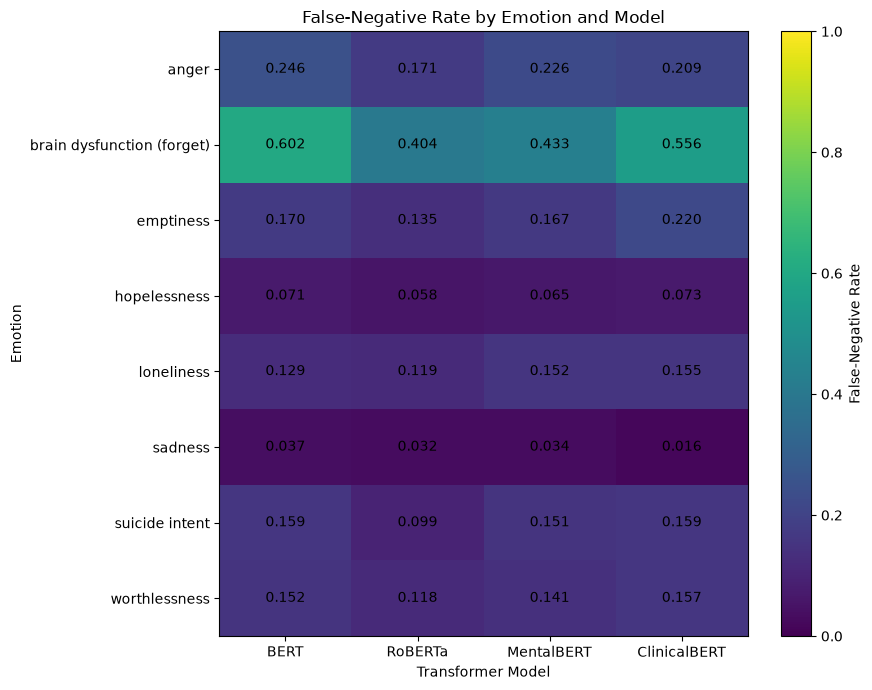

Saved: d:\Thesis_Project\Experiment_2_Transformer-Based Emotion_Classification\outputs\structured_error_analysis\figures\false_negative_rate_heatmap.png


In [377]:
# ============================================================
# EXPERIMENT 2 — PHASE 16 — CELL 16
# FNR HEATMAP
# ============================================================

fig, ax = plt.subplots(
    figsize=(
        9,
        7
    )
)


image_object = ax.imshow(
    phase16_fnr_df.values,
    aspect="auto",
    vmin=0,
    vmax=1
)


ax.set_xticks(
    np.arange(
        len(
            FINAL_MODEL_ORDER
        )
    )
)

ax.set_xticklabels(
    FINAL_MODEL_ORDER
)


ax.set_yticks(
    np.arange(
        len(
            MODEL_LABELS
        )
    )
)

ax.set_yticklabels(
    MODEL_LABELS
)


for row_index in range(
    len(
        MODEL_LABELS
    )
):

    for column_index in range(
        len(
            FINAL_MODEL_ORDER
        )
    ):

        value = (
            phase16_fnr_df
            .iloc[
                row_index,
                column_index
            ]
        )

        ax.text(
            column_index,
            row_index,
            f"{value:.3f}",
            ha="center",
            va="center"
        )


ax.set_title(
    "False-Negative Rate by Emotion and Model"
)

ax.set_xlabel(
    "Transformer Model"
)

ax.set_ylabel(
    "Emotion"
)


fig.colorbar(
    image_object,
    ax=ax,
    label="False-Negative Rate"
)


plt.tight_layout()


FNR_HEATMAP_PATH = (
    PHASE16_FIGURE_DIR
    / "false_negative_rate_heatmap.png"
)


plt.savefig(
    FNR_HEATMAP_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()


print(
    "Saved:",
    FNR_HEATMAP_PATH
)

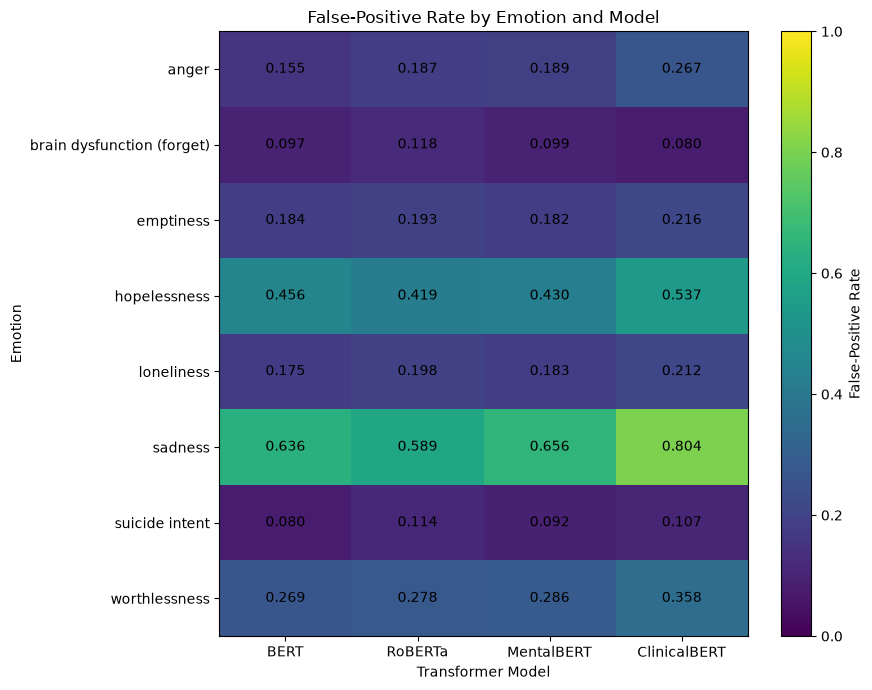

Saved: d:\Thesis_Project\Experiment_2_Transformer-Based Emotion_Classification\outputs\structured_error_analysis\figures\false_positive_rate_heatmap.png


In [378]:
# ============================================================
# EXPERIMENT 2 — PHASE 16 — CELL 17
# FPR HEATMAP
# ============================================================

fig, ax = plt.subplots(
    figsize=(
        9,
        7
    )
)


image_object = ax.imshow(
    phase16_fpr_df.values,
    aspect="auto",
    vmin=0,
    vmax=1
)


ax.set_xticks(
    np.arange(
        len(
            FINAL_MODEL_ORDER
        )
    )
)

ax.set_xticklabels(
    FINAL_MODEL_ORDER
)


ax.set_yticks(
    np.arange(
        len(
            MODEL_LABELS
        )
    )
)

ax.set_yticklabels(
    MODEL_LABELS
)


for row_index in range(
    len(
        MODEL_LABELS
    )
):

    for column_index in range(
        len(
            FINAL_MODEL_ORDER
        )
    ):

        value = (
            phase16_fpr_df
            .iloc[
                row_index,
                column_index
            ]
        )

        ax.text(
            column_index,
            row_index,
            f"{value:.3f}",
            ha="center",
            va="center"
        )


ax.set_title(
    "False-Positive Rate by Emotion and Model"
)

ax.set_xlabel(
    "Transformer Model"
)

ax.set_ylabel(
    "Emotion"
)


fig.colorbar(
    image_object,
    ax=ax,
    label="False-Positive Rate"
)


plt.tight_layout()


FPR_HEATMAP_PATH = (
    PHASE16_FIGURE_DIR
    / "false_positive_rate_heatmap.png"
)


plt.savefig(
    FPR_HEATMAP_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()


print(
    "Saved:",
    FPR_HEATMAP_PATH
)

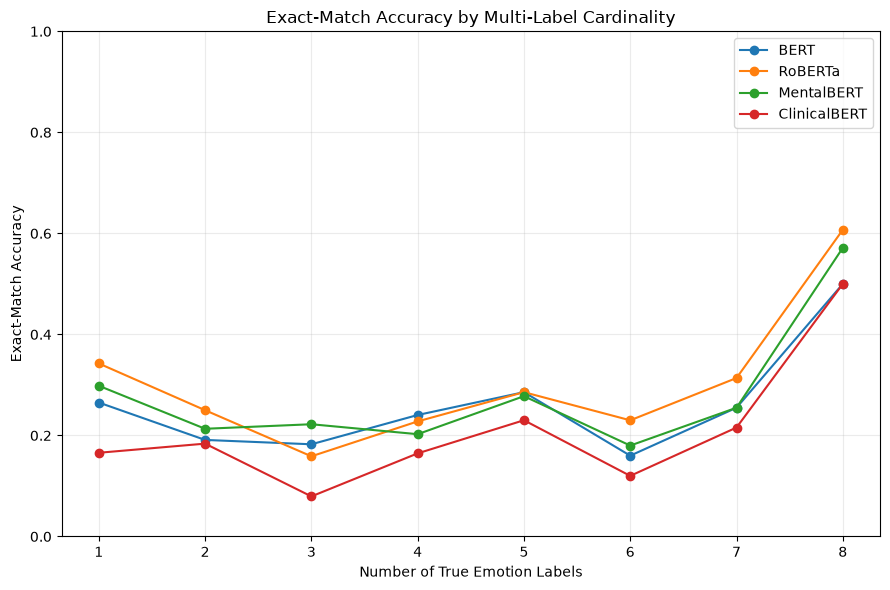

Saved: d:\Thesis_Project\Experiment_2_Transformer-Based Emotion_Classification\outputs\structured_error_analysis\figures\exact_match_by_label_cardinality.png


In [379]:
# ============================================================
# EXPERIMENT 2 — PHASE 16 — CELL 18
# EXACT MATCH BY LABEL CARDINALITY
# ============================================================

plt.figure(
    figsize=(
        9,
        6
    )
)


for model_name in FINAL_MODEL_ORDER:

    plt.plot(

        error_by_cardinality_df[
            "True_Label_Count"
        ],

        error_by_cardinality_df[
            f"{model_name}_Exact_Match"
        ],

        marker="o",

        label=model_name
    )


plt.xlabel(
    "Number of True Emotion Labels"
)

plt.ylabel(
    "Exact-Match Accuracy"
)

plt.title(
    "Exact-Match Accuracy by Multi-Label Cardinality"
)

plt.ylim(
    0,
    1
)

plt.legend()

plt.grid(
    alpha=0.25
)

plt.tight_layout()


CARDINALITY_FIGURE_PATH = (
    PHASE16_FIGURE_DIR
    / "exact_match_by_label_cardinality.png"
)


plt.savefig(
    CARDINALITY_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()


print(
    "Saved:",
    CARDINALITY_FIGURE_PATH
)

,Models_Failing_Exact_Match,Samples,Percentage
0,0,55,6.070640
1,1,102,11.258278
2,2,88,9.713024
3,3,138,15.231788
4,4,523,57.726269


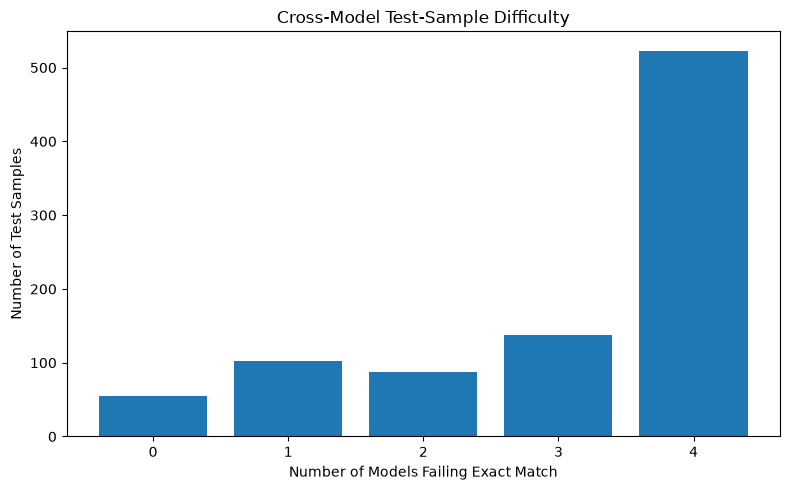

In [380]:
# ============================================================
# EXPERIMENT 2 — PHASE 16 — CELL 19
# CROSS-MODEL DIFFICULTY DISTRIBUTION
# ============================================================

difficulty_distribution_df = (
    sample_error_df[
        "models_with_exact_match_failure"
    ]
    .value_counts()
    .sort_index()
    .rename_axis(
        "Models_Failing_Exact_Match"
    )
    .reset_index(
        name="Samples"
    )
)


difficulty_distribution_df[
    "Percentage"
] = (
    difficulty_distribution_df[
        "Samples"
    ]
    /
    len(
        sample_error_df
    )
    *
    100
)


display(
    difficulty_distribution_df
)


plt.figure(
    figsize=(
        8,
        5
    )
)


plt.bar(
    difficulty_distribution_df[
        "Models_Failing_Exact_Match"
    ],
    difficulty_distribution_df[
        "Samples"
    ]
)


plt.xlabel(
    "Number of Models Failing Exact Match"
)

plt.ylabel(
    "Number of Test Samples"
)

plt.title(
    "Cross-Model Test-Sample Difficulty"
)

plt.xticks(
    [
        0,
        1,
        2,
        3,
        4
    ]
)

plt.tight_layout()


DIFFICULTY_FIGURE_PATH = (
    PHASE16_FIGURE_DIR
    / "cross_model_sample_difficulty.png"
)


plt.savefig(
    DIFFICULTY_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

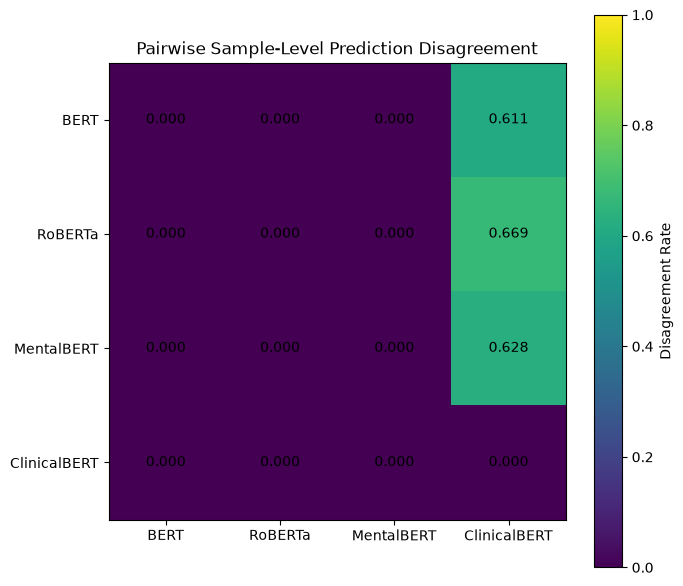

Saved: d:\Thesis_Project\Experiment_2_Transformer-Based Emotion_Classification\outputs\structured_error_analysis\figures\pairwise_sample_disagreement.png


In [381]:
# ============================================================
# EXPERIMENT 2 — PHASE 16 — CELL 20
# MODEL DISAGREEMENT HEATMAP
# ============================================================

fig, ax = plt.subplots(
    figsize=(
        7,
        6
    )
)


image_object = ax.imshow(
    sample_disagreement_matrix.values,
    vmin=0,
    vmax=1
)


ax.set_xticks(
    np.arange(
        len(
            FINAL_MODEL_ORDER
        )
    )
)

ax.set_xticklabels(
    FINAL_MODEL_ORDER
)


ax.set_yticks(
    np.arange(
        len(
            FINAL_MODEL_ORDER
        )
    )
)

ax.set_yticklabels(
    FINAL_MODEL_ORDER
)


for row_index in range(
    len(
        FINAL_MODEL_ORDER
    )
):

    for column_index in range(
        len(
            FINAL_MODEL_ORDER
        )
    ):

        value = (
            sample_disagreement_matrix
            .iloc[
                row_index,
                column_index
            ]
        )

        ax.text(
            column_index,
            row_index,
            f"{value:.3f}",
            ha="center",
            va="center"
        )


ax.set_title(
    "Pairwise Sample-Level Prediction Disagreement"
)


fig.colorbar(
    image_object,
    ax=ax,
    label="Disagreement Rate"
)


plt.tight_layout()


DISAGREEMENT_FIGURE_PATH = (
    PHASE16_FIGURE_DIR
    / "pairwise_sample_disagreement.png"
)


plt.savefig(
    DISAGREEMENT_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()


print(
    "Saved:",
    DISAGREEMENT_FIGURE_PATH
)

In [382]:
# ============================================================
# EXPERIMENT 2 — PHASE 16 — CELL 21
# SAVE ERROR ANALYSIS TABLES
# ============================================================

sample_error_df.to_csv(
    PHASE16_TABLE_DIR
    / "sample_level_error_analysis.csv",
    index=False
)

sample_error_summary_df.to_csv(
    PHASE16_TABLE_DIR
    / "model_sample_error_summary.csv",
    index=False
)

error_by_cardinality_df.to_csv(
    PHASE16_TABLE_DIR
    / "error_by_label_cardinality.csv",
    index=False
)

hard_sample_df.to_csv(
    PHASE16_TABLE_DIR
    / "ranked_hard_test_samples.csv",
    index=False
)

exact_match_agreement_df.to_csv(
    PHASE16_TABLE_DIR
    / "cross_model_exact_match_agreement.csv",
    index=False
)

shared_false_negative_df.to_csv(
    PHASE16_TABLE_DIR
    / "shared_false_negatives.csv",
    index=False
)

shared_false_positive_df.to_csv(
    PHASE16_TABLE_DIR
    / "shared_false_positives.csv",
    index=False
)

label_error_burden_df.to_csv(
    PHASE16_TABLE_DIR
    / "label_error_burden.csv",
    index=False
)

sample_disagreement_matrix.to_csv(
    PHASE16_TABLE_DIR
    / "pairwise_sample_disagreement.csv"
)

label_disagreement_matrix.to_csv(
    PHASE16_TABLE_DIR
    / "pairwise_label_decision_disagreement.csv"
)

high_confidence_error_df.to_csv(
    PHASE16_TABLE_DIR
    / "all_high_confidence_errors.csv",
    index=False
)

top_confident_errors_df.to_csv(
    PHASE16_TABLE_DIR
    / "top_50_high_confidence_errors.csv",
    index=False
)

phase16_fnr_df.to_csv(
    PHASE16_TABLE_DIR
    / "false_negative_rate_matrix.csv"
)

phase16_fpr_df.to_csv(
    PHASE16_TABLE_DIR
    / "false_positive_rate_matrix.csv"
)

difficulty_distribution_df.to_csv(
    PHASE16_TABLE_DIR
    / "sample_difficulty_distribution.csv",
    index=False
)


print(
    "Structured error-analysis tables saved."
)

Structured error-analysis tables saved.


In [383]:
# ============================================================
# EXPERIMENT 2 — PHASE 16 — CELL 22
# ERROR ANALYSIS MANIFEST
# ============================================================

phase16_manifest = {

    "phase":
        "structured_final_test_error_analysis",

    "source":
        "frozen Phase 13 test predictions",

    "test_samples":
        len(
            sample_error_df
        ),

    "models":
        FINAL_MODEL_ORDER,

    "labels":
        MODEL_LABELS,

    "configuration_sha256":
        FINAL_CONFIG_HASH,

    "final_test_results_sha256":
        FINAL_TEST_RESULTS_HASH,

    "analyses":
        [
            "sample-level exact-match errors",
            "label error counts",
            "false positives",
            "false negatives",
            "label cardinality",
            "cross-model disagreement",
            "shared model errors",
            "high-confidence errors"
        ],

    "post_test_threshold_tuning":
        False,

    "post_test_retraining":
        False,

    "post_test_checkpoint_selection":
        False,

    "post_test_hyperparameter_change":
        False,

    "inferential_independence_assumed_for_label_cells":
        False
}


PHASE16_MANIFEST_PATH = (
    PHASE16_DIR
    / "phase16_error_analysis_manifest.json"
)


with open(
    PHASE16_MANIFEST_PATH,
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        phase16_manifest,
        file,
        indent=4,
        ensure_ascii=False
    )


print(
    "Saved:",
    PHASE16_MANIFEST_PATH
)

Saved: d:\Thesis_Project\Experiment_2_Transformer-Based Emotion_Classification\outputs\structured_error_analysis\phase16_error_analysis_manifest.json


In [384]:
# ============================================================
# EXPERIMENT 2 — PHASE 16 — CELL 23
# POST-ANALYSIS LOCK CHECK
# ============================================================

post_phase16_config_hash = (
    sha256_file(
        FINAL_CONFIGURATION_JSON
    )
)

post_phase16_test_hash = (
    sha256_file(
        FINAL_TEST_COMPARISON_PATH
    )
)


PHASE16_CONFIG_HASH_MATCH = (
    post_phase16_config_hash
    ==
    FINAL_CONFIG_HASH
)

PHASE16_TEST_HASH_MATCH = (
    post_phase16_test_hash
    ==
    FINAL_TEST_RESULTS_HASH
)


print("=" * 82)
print("POST-ERROR-ANALYSIS LOCK CHECK")
print("=" * 82)

print(
    "Configuration unchanged:",
    PHASE16_CONFIG_HASH_MATCH
)

print(
    "Test results unchanged :",
    PHASE16_TEST_HASH_MATCH
)

print("=" * 82)


assert PHASE16_CONFIG_HASH_MATCH
assert PHASE16_TEST_HASH_MATCH

POST-ERROR-ANALYSIS LOCK CHECK
Configuration unchanged: True
Test results unchanged : True


In [385]:
# ============================================================
# EXPERIMENT 2 — PHASE 16 — CELL 24
# FINAL PHASE 16 VERIFICATION
# ============================================================

phase16_checks = {

    "906 samples analyzed":
        len(
            sample_error_df
        ) == 906,

    "Four models analyzed":
        len(
            sample_error_summary_df
        ) == 4,

    "Eight labels in shared FN analysis":
        len(
            shared_false_negative_df
        ) == 8,

    "Eight labels in shared FP analysis":
        len(
            shared_false_positive_df
        ) == 8,

    "Eight labels in error burden table":
        len(
            label_error_burden_df
        ) == 8,

    "Pairwise sample matrix = 4x4":
        sample_disagreement_matrix.shape
        ==
        (
            4,
            4
        ),

    "Pairwise label matrix = 4x4":
        label_disagreement_matrix.shape
        ==
        (
            4,
            4
        ),

    "High-confidence error table non-empty":
        len(
            high_confidence_error_df
        ) > 0,

    "FNR heatmap exists":
        FNR_HEATMAP_PATH.exists(),

    "FPR heatmap exists":
        FPR_HEATMAP_PATH.exists(),

    "Cardinality figure exists":
        CARDINALITY_FIGURE_PATH.exists(),

    "Difficulty figure exists":
        DIFFICULTY_FIGURE_PATH.exists(),

    "Disagreement figure exists":
        DISAGREEMENT_FIGURE_PATH.exists(),

    "No threshold tuning":
        phase16_manifest[
            "post_test_threshold_tuning"
        ] is False,

    "No retraining":
        phase16_manifest[
            "post_test_retraining"
        ] is False,

    "No checkpoint reselection":
        phase16_manifest[
            "post_test_checkpoint_selection"
        ] is False,

    "Configuration unchanged":
        PHASE16_CONFIG_HASH_MATCH,

    "Final test results unchanged":
        PHASE16_TEST_HASH_MATCH,

    "Manifest exists":
        PHASE16_MANIFEST_PATH.exists()
}


print("=" * 88)
print("PHASE 16 — FINAL VERIFICATION")
print("=" * 88)

phase16_passed = True


for check_name, status in (
    phase16_checks.items()
):

    print(
        f"{check_name:<64}: "
        f"{'PASS' if status else 'FAIL'}"
    )

    if not status:

        phase16_passed = False


print("=" * 88)


if phase16_passed:

    print(
        "PHASE 16 STATUS: PASSED"
    )

    print(
        "Structured error analysis is complete."
    )

    print(
        "All analyses used the original "
        "frozen test predictions."
    )

    print(
        "No post-test model modification was performed."
    )

else:

    print(
        "PHASE 16 STATUS: REVIEW REQUIRED"
    )


print("=" * 88)

PHASE 16 — FINAL VERIFICATION
906 samples analyzed                                            : PASS
Four models analyzed                                            : PASS
Eight labels in shared FN analysis                              : PASS
Eight labels in shared FP analysis                              : PASS
Eight labels in error burden table                              : PASS
Pairwise sample matrix = 4x4                                    : PASS
Pairwise label matrix = 4x4                                     : PASS
High-confidence error table non-empty                           : PASS
FNR heatmap exists                                              : PASS
FPR heatmap exists                                              : PASS
Cardinality figure exists                                       : PASS
Difficulty figure exists                                        : PASS
Disagreement figure exists                                      : PASS
No threshold tuning                            